<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%91%D0%B0%D0%B7%D0%BE%D0%B2%D1%8B%D0%B9_%D0%B1%D0%BB%D0%BE%D0%BA_%7C_%D0%90%D1%80%D1%85%D0%B8%D1%82%D0%B5%D0%BA%D1%82%D1%83%D1%80%D0%B0_%D0%B0%D0%B2%D1%82%D0%BE%D0%BA%D0%BE%D0%B4%D0%B8%D1%80%D0%BE%D0%B2%D1%89%D0%B8%D0%BA%D0%B0_(Autoencoder)_%7C_%D0%94%D0%97_Pro_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Задание Pro


1.Выберите 10 самых красивых по вашему мнению изображений с цифрой «5» из тренировочной выборки MNIST и сохраните их в отдельный файл.
2.Создайте датасет, где объектами будут все изображения с цифрой «5» из обучающей выборки MNIST, а метками — случайно выбранные изображения из вашего списка «красивых» пятерок.
3.Постройте автокодировщик и убедитесь, что размеры его выхода и входа совпадают.
4.Обучите автокодировщик на созданном датасете.
5.Добейтесь того, чтобы ошибка MSE на тренировочной выборке была меньше 0,05.
6.Посмотрите, как выглядят изображения с цифрой «5» из тестовой выборки после обработки обученным автокодировщиком.

## Импорт библиотек

In [1]:
# Для операций с тензорами
import numpy as np

# Для отрисвоки
import matplotlib.pyplot as plt

# Для создания модели
from tensorflow.keras.models import Model

# Необходимые слои
from tensorflow.keras.layers import Input, Conv2DTranspose, MaxPooling2D, Conv2D, BatchNormalization

# Слои для латентного пространства модели
from tensorflow.keras.layers import Flatten, Reshape, Dense

# Оптимизатор
from tensorflow.keras.optimizers import Adam

# Для загрузки базы
from tensorflow.keras.datasets import mnist

## Загрузка данных

In [2]:
# Загрузка датасета
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Нормализация данных
X_train = X_train.astype('float32')/255.
X_test = X_test.astype('float32')/255.

In [4]:
# Приведение формы к удобной для Keras
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [5]:
# Отбор пятерок
mask = y_train == 5
X_train = X_train[mask]
y_train = y_train[mask]

In [6]:
# Аналогично для тестирования
mask = y_test == 5
X_test = X_test[mask]
y_test = y_test[mask]

## Отбор красивых пятерок

(5421, 28, 28, 1)

(5421,)

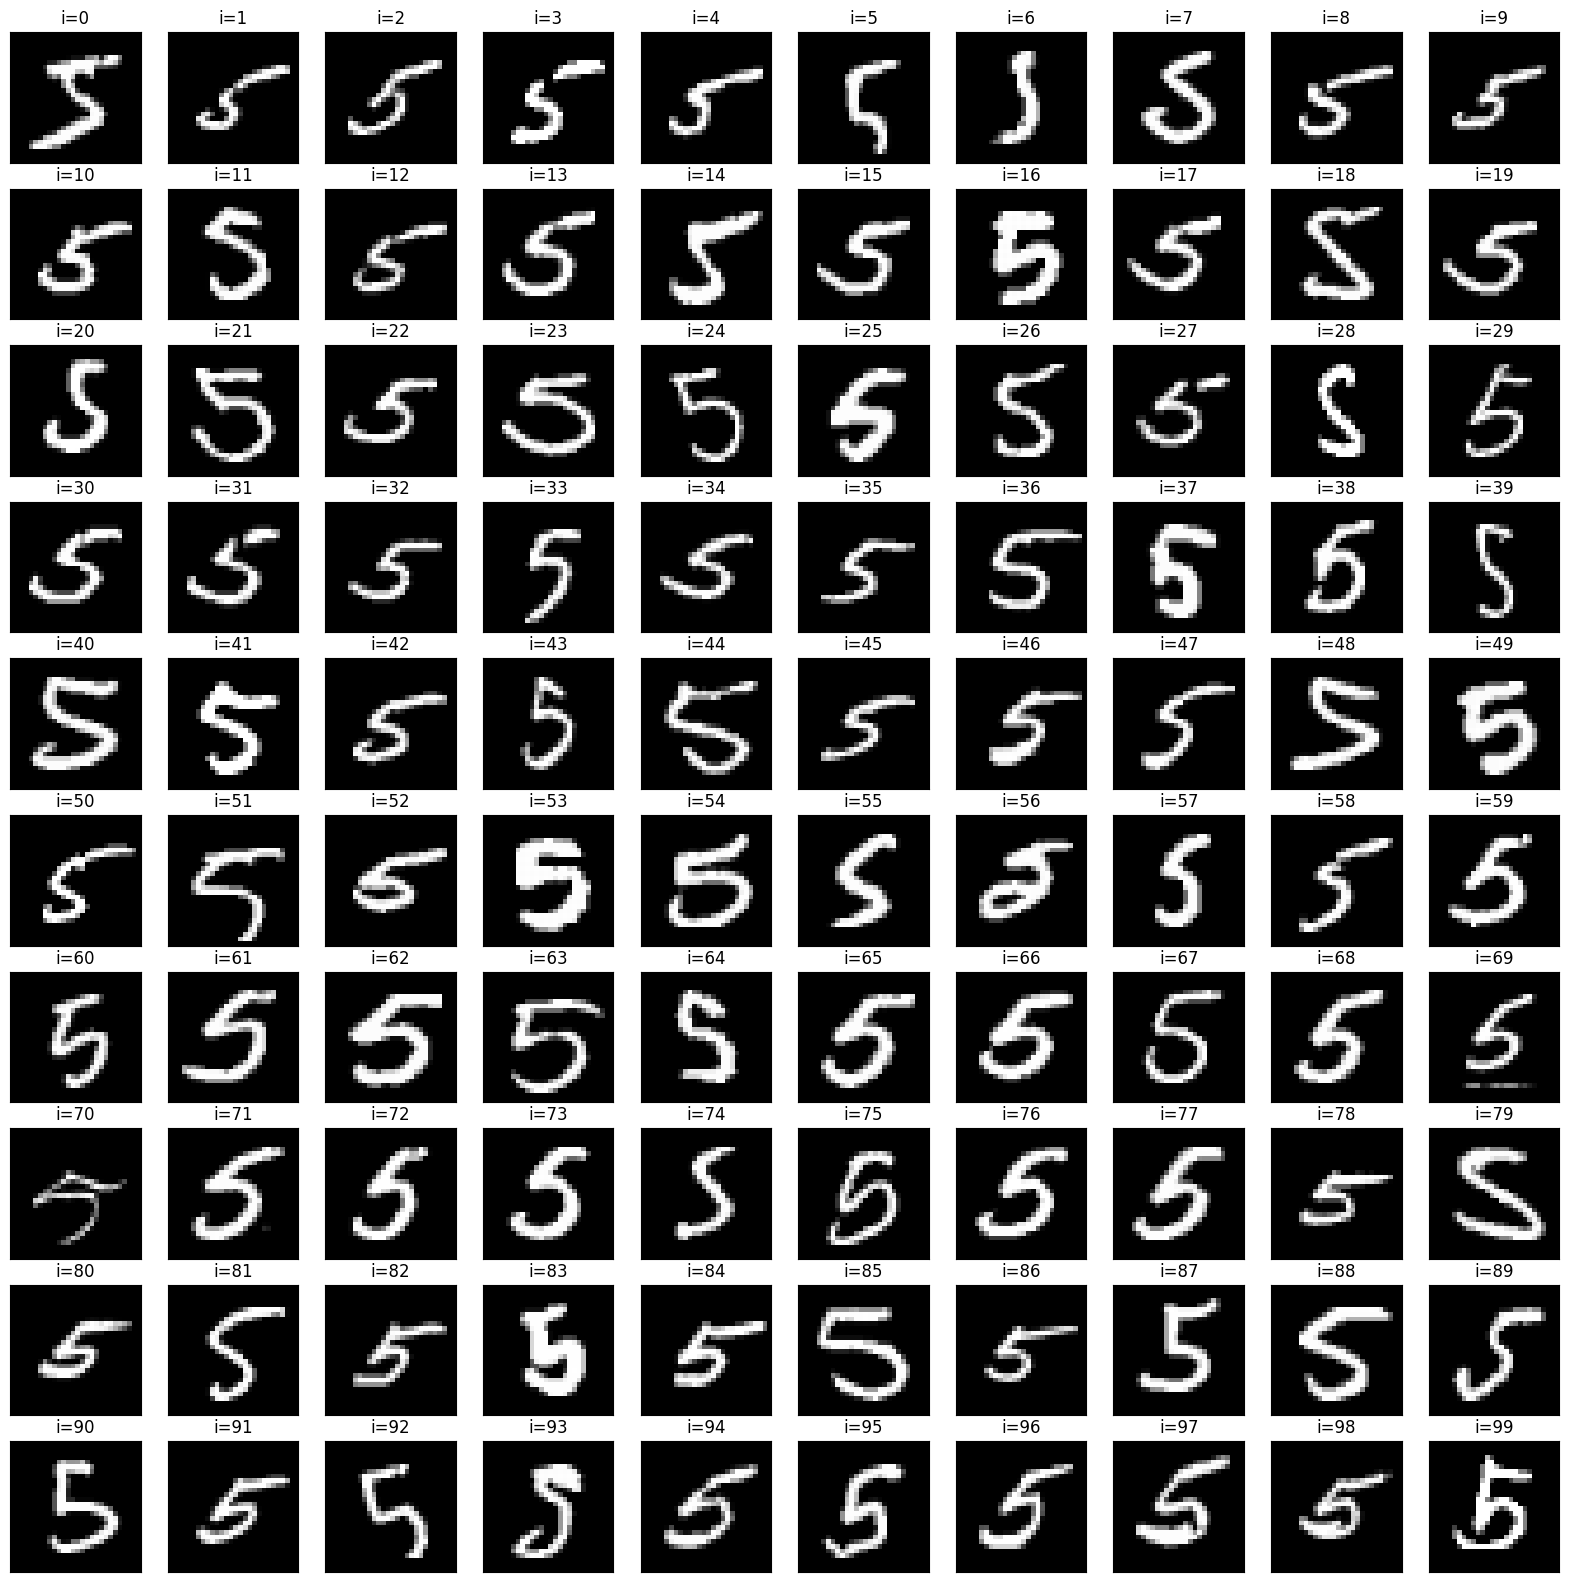

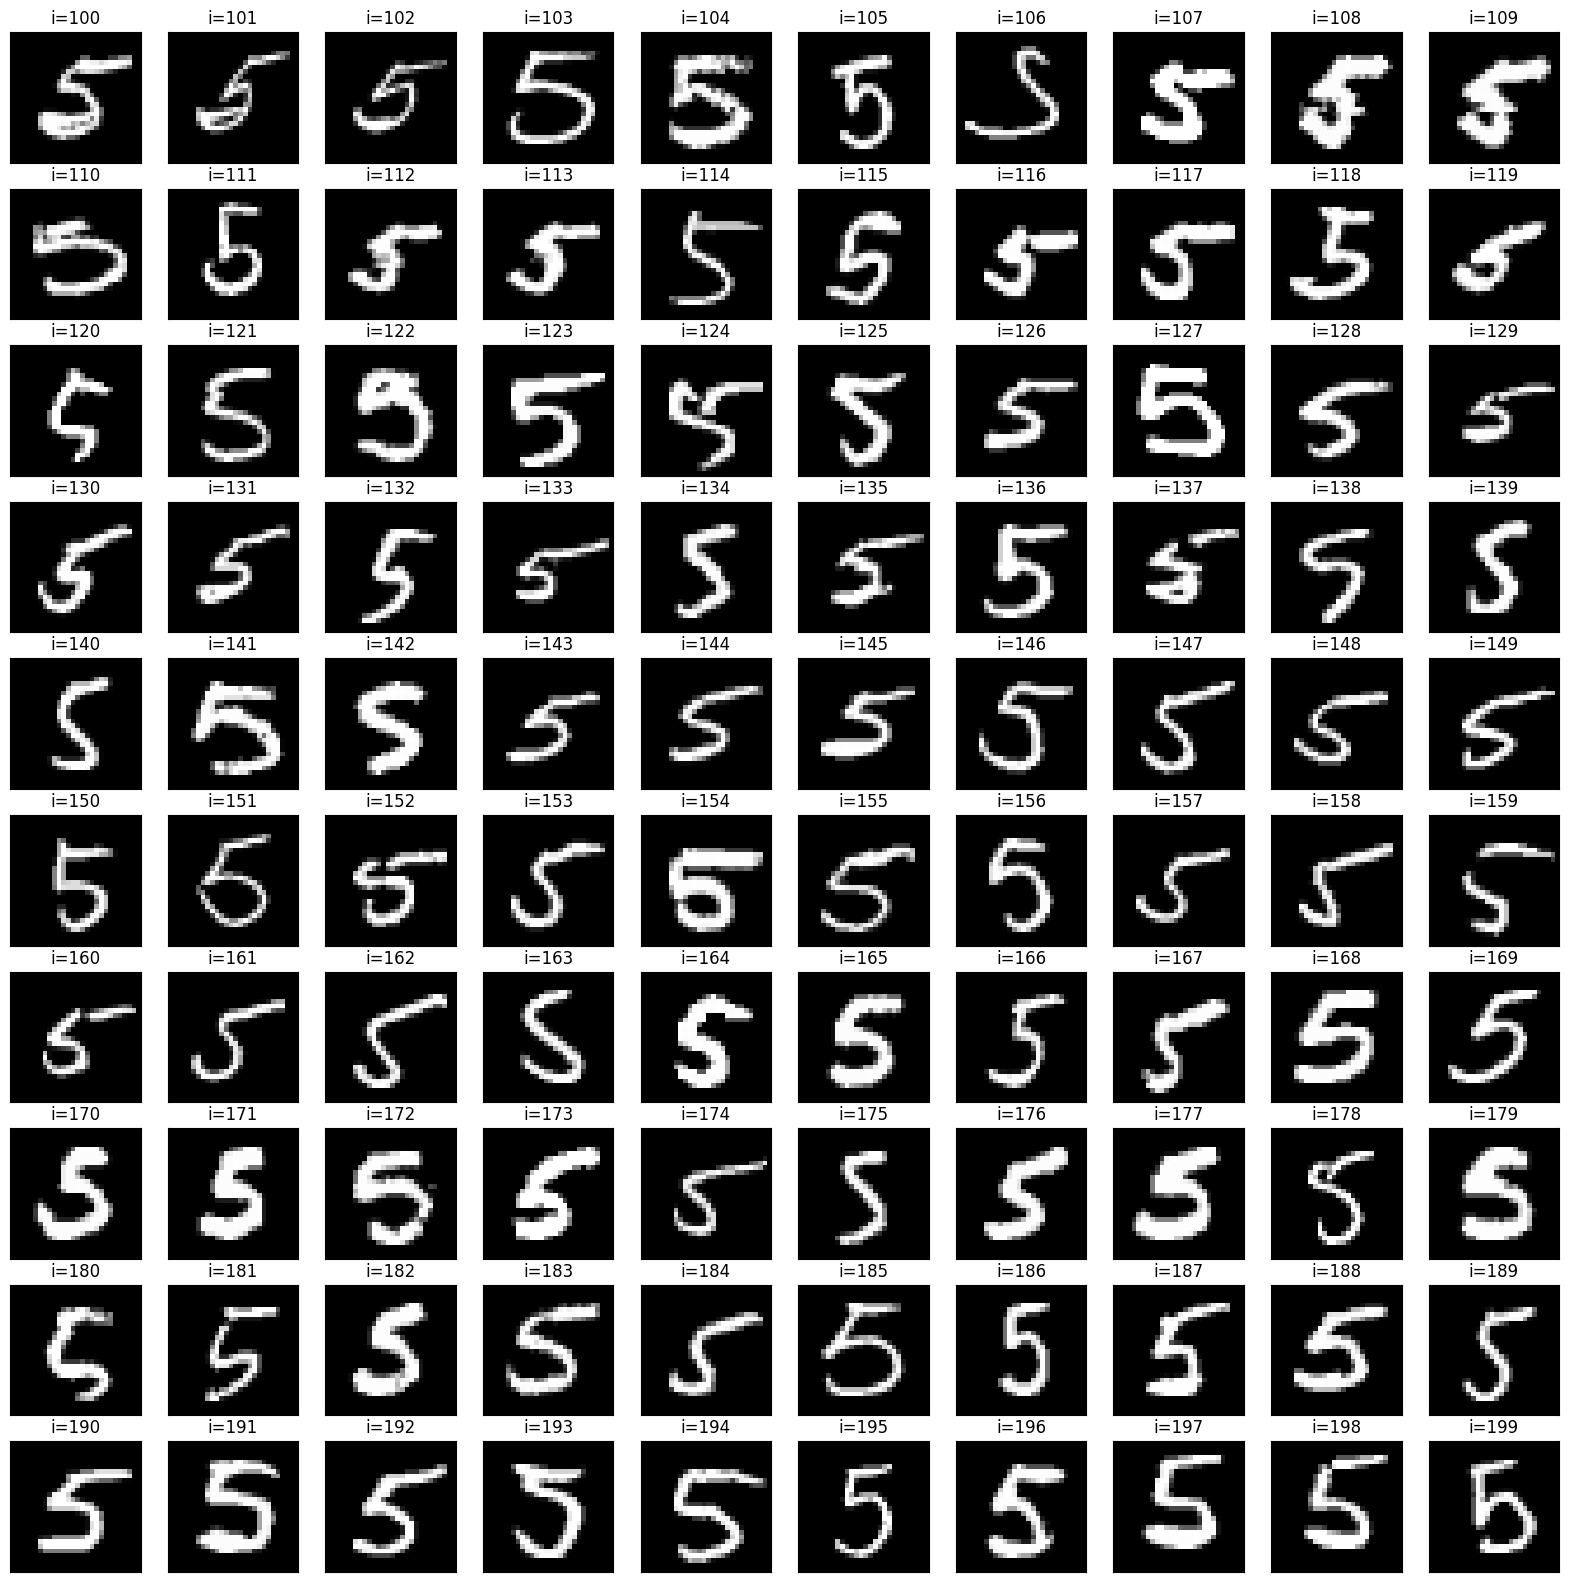

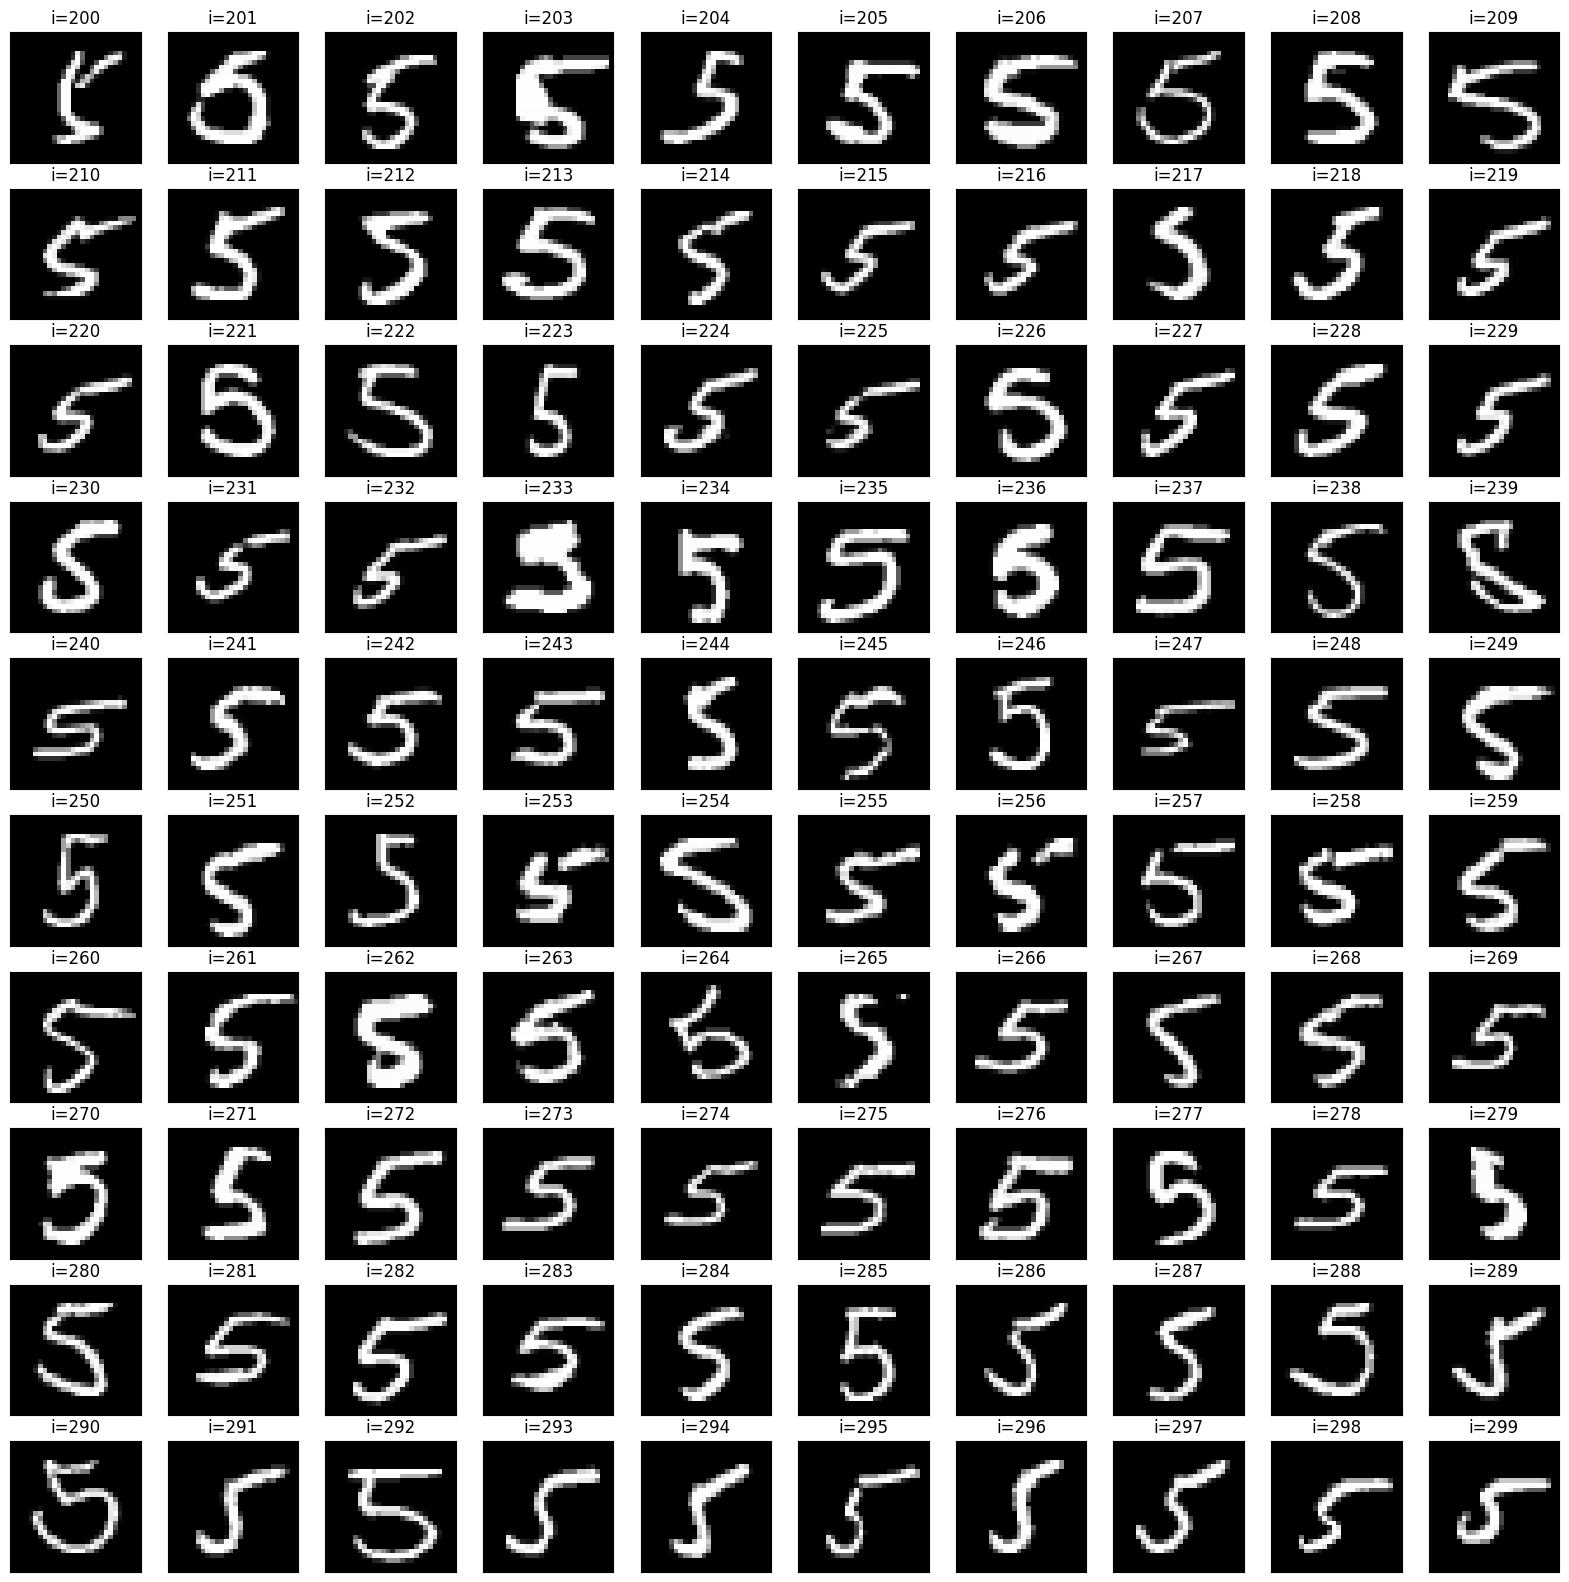

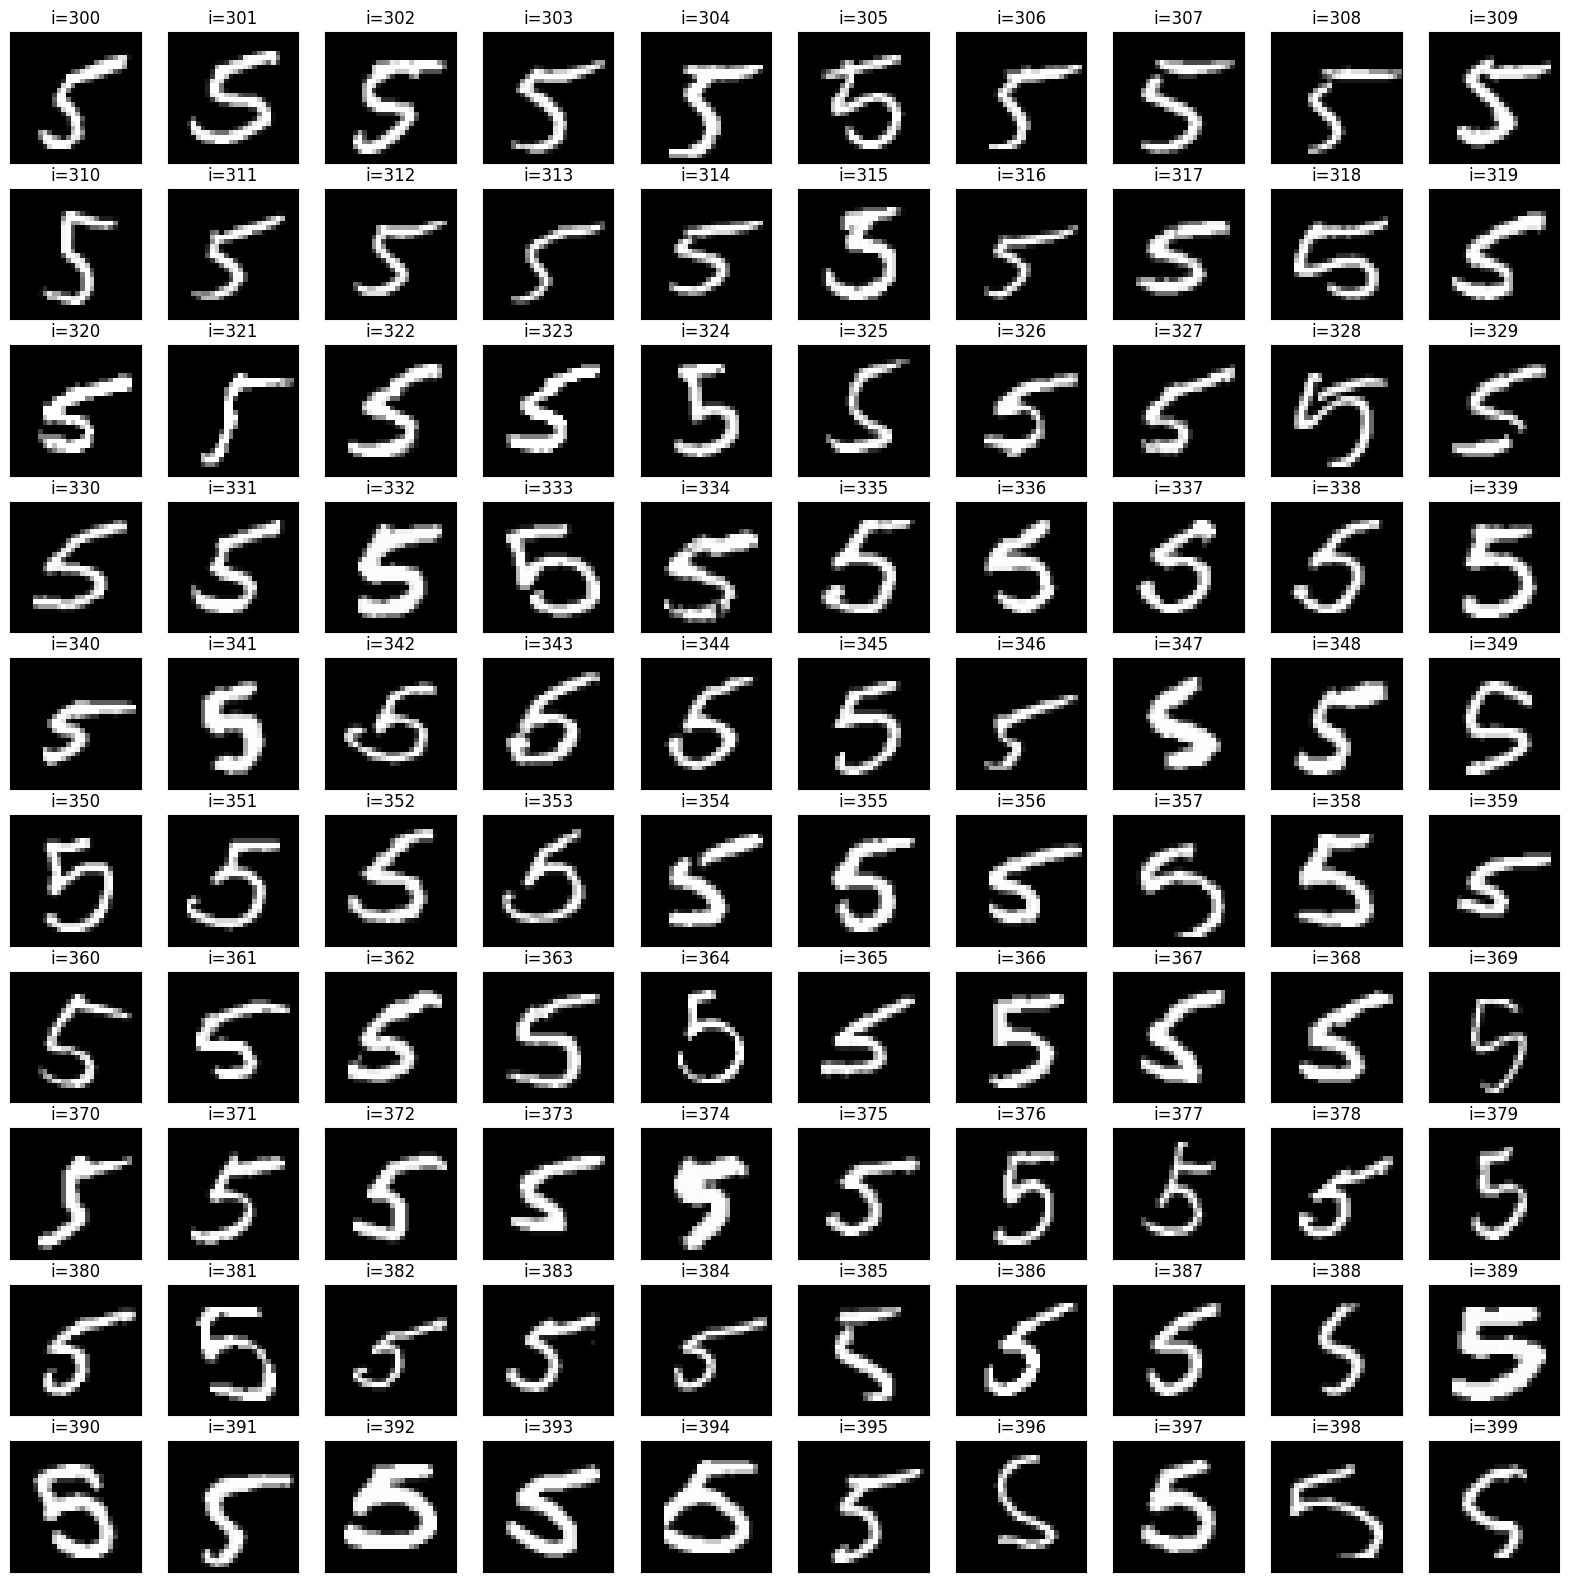

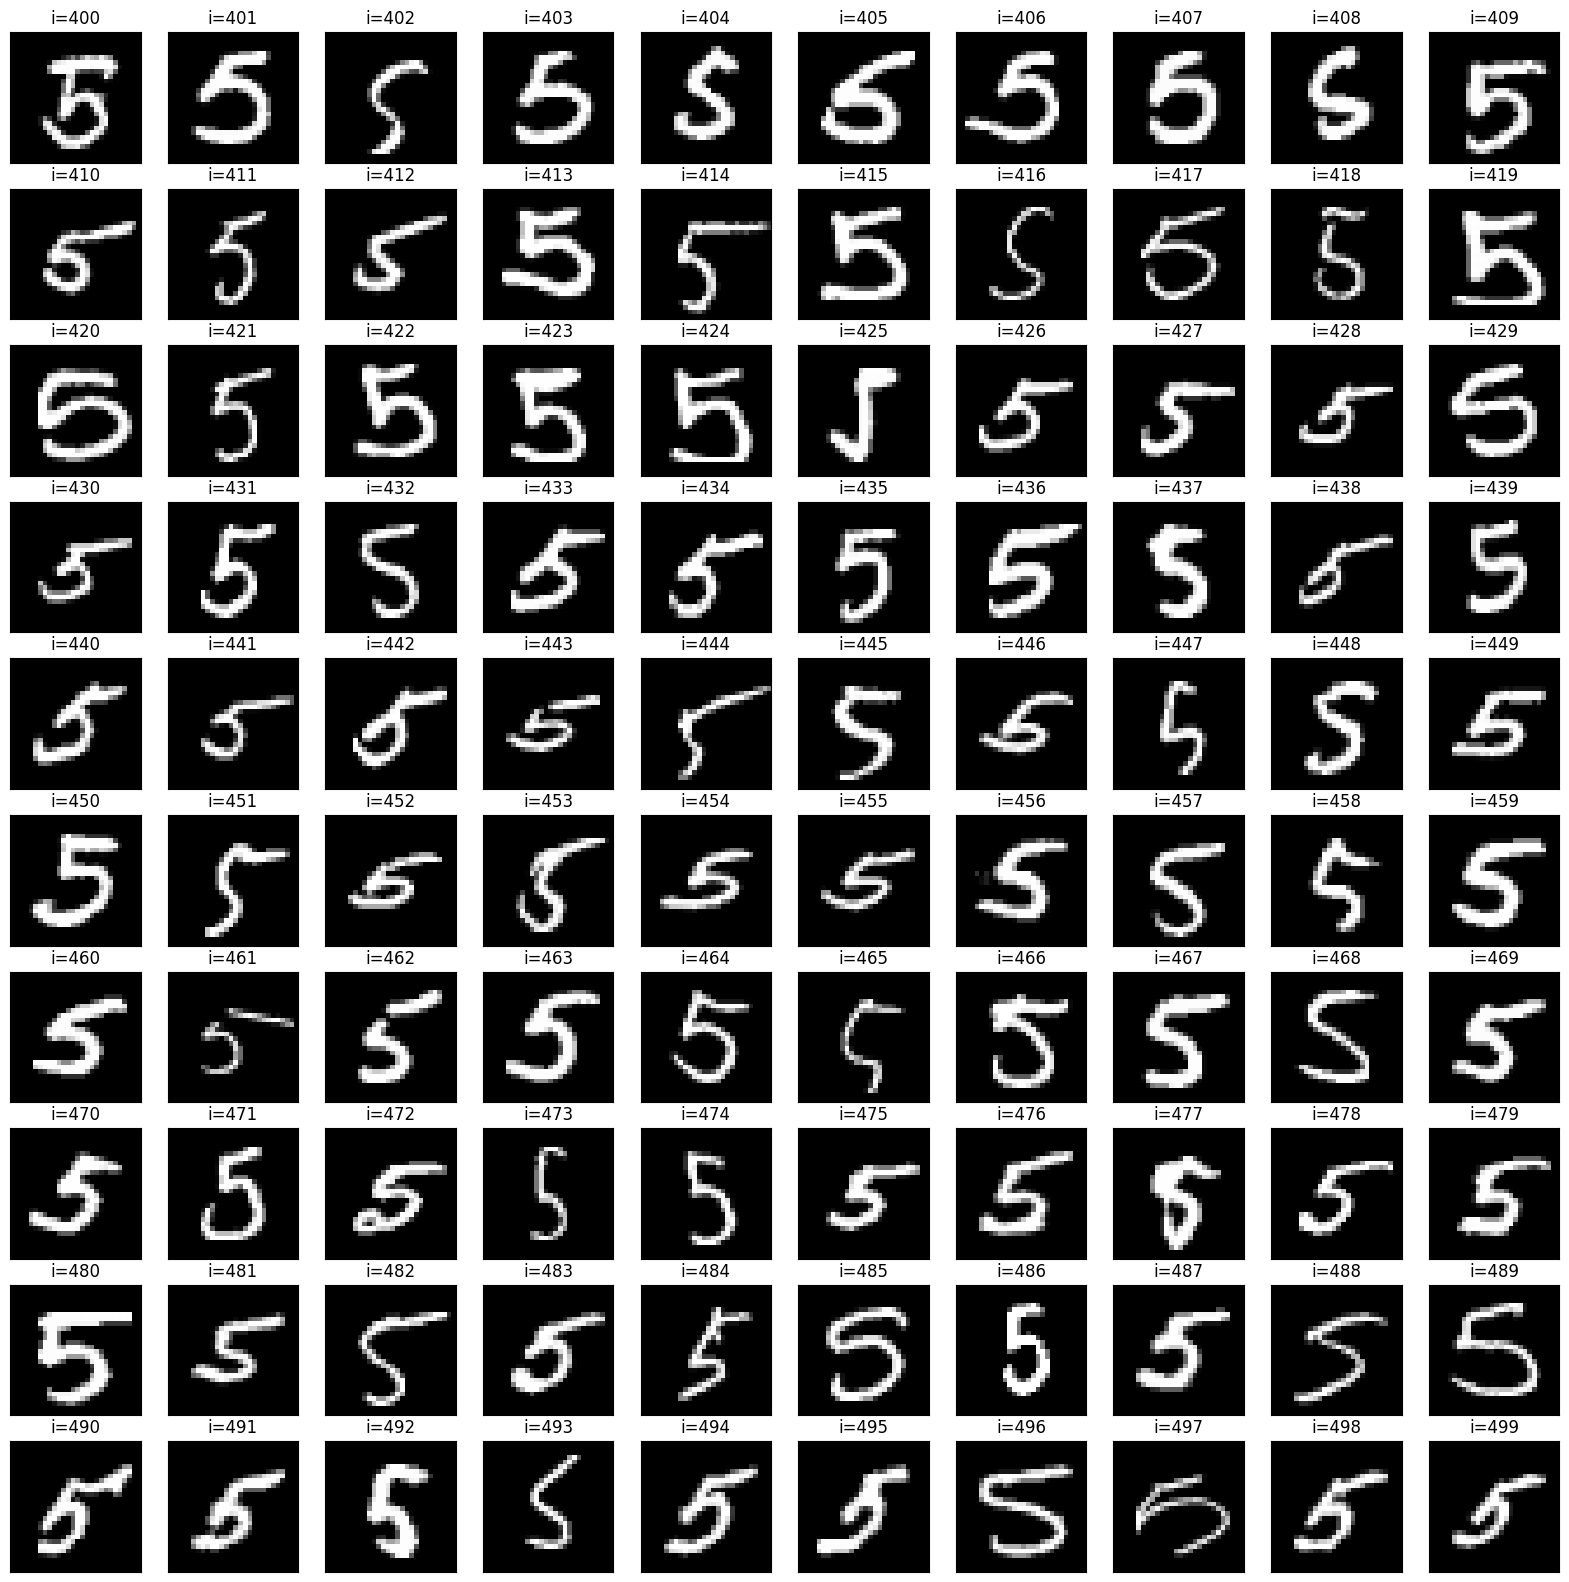

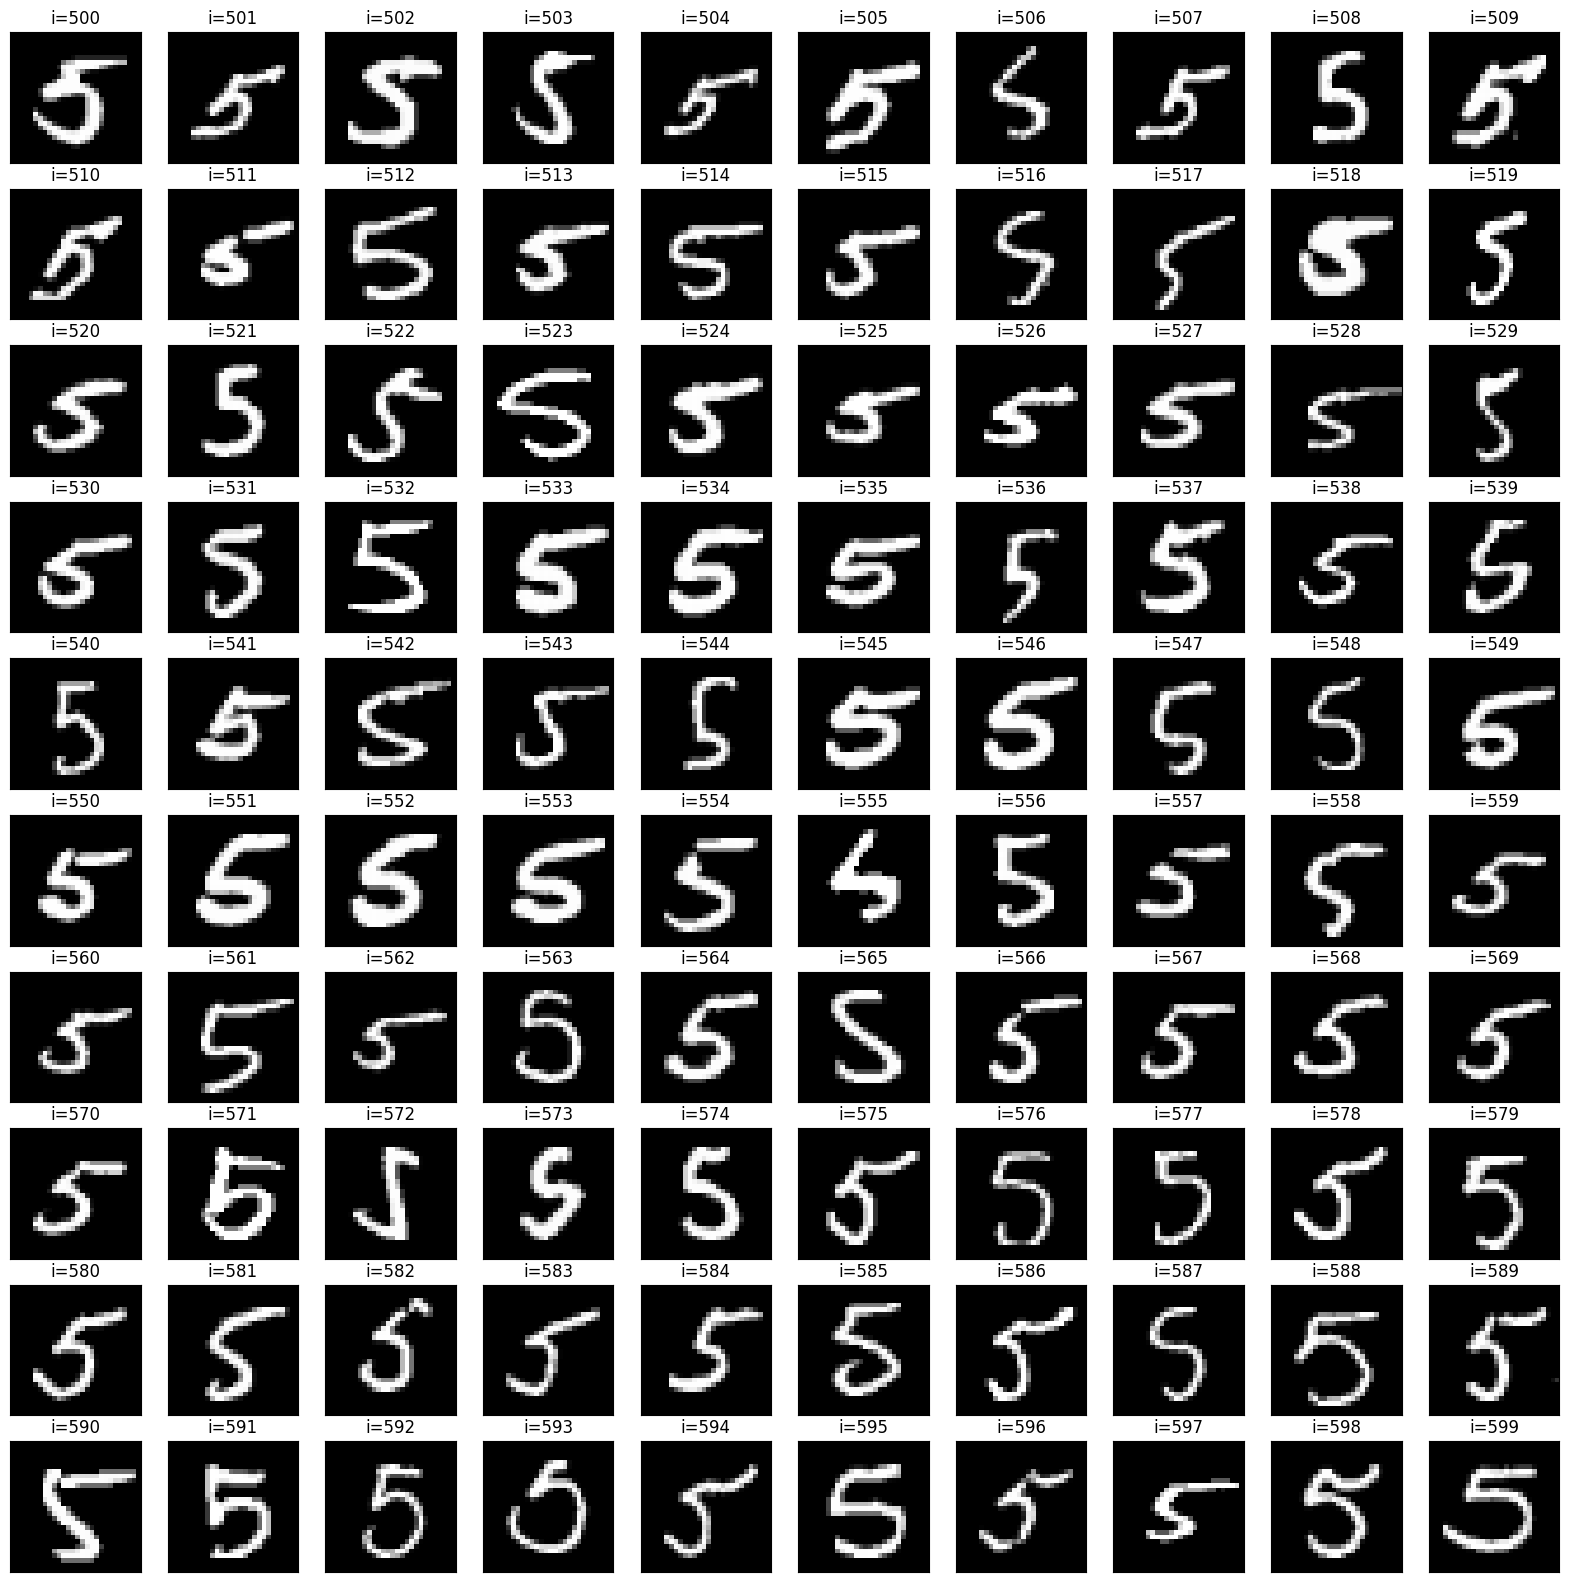

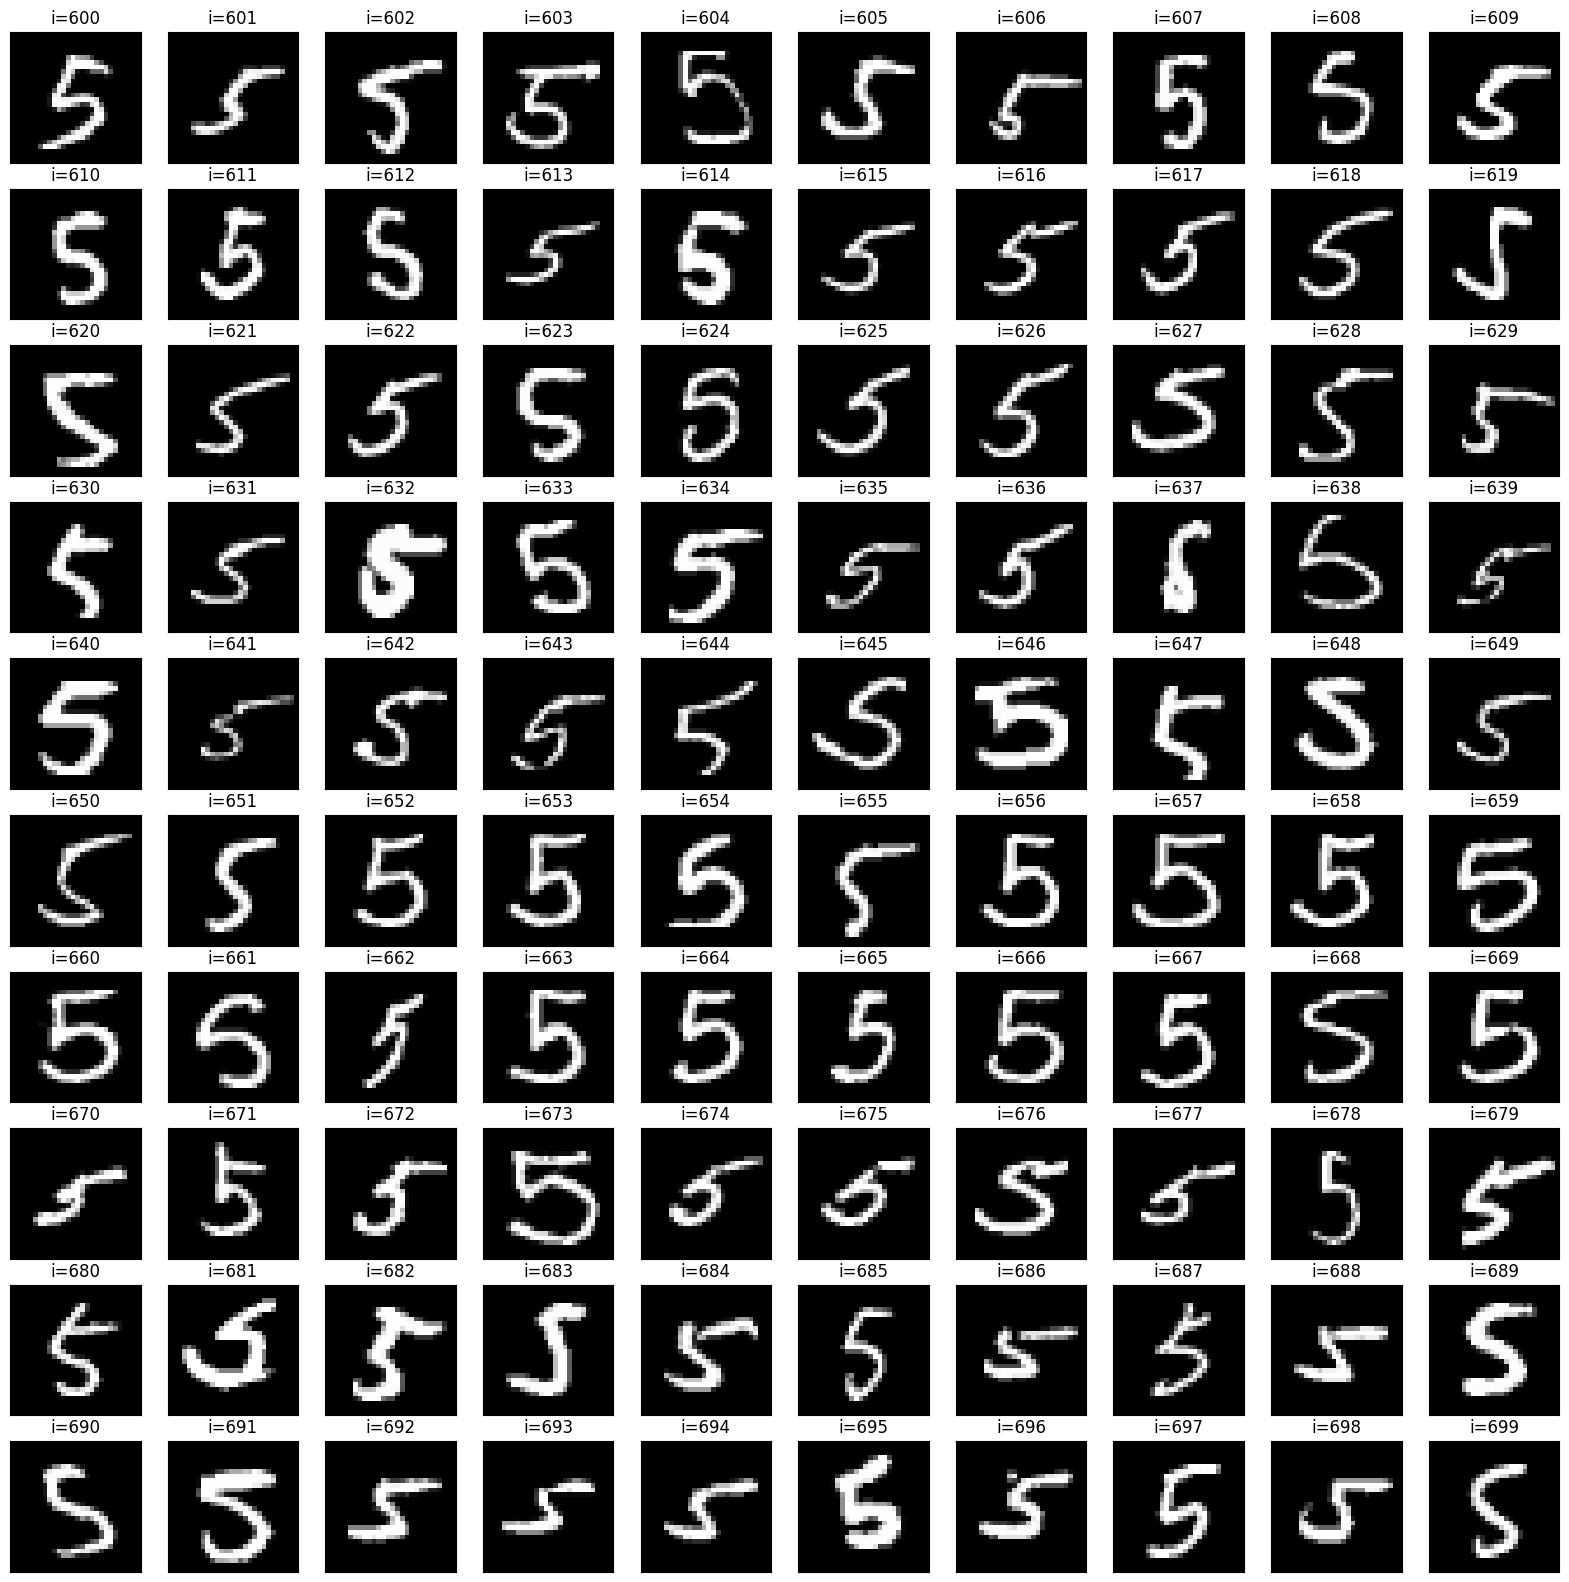

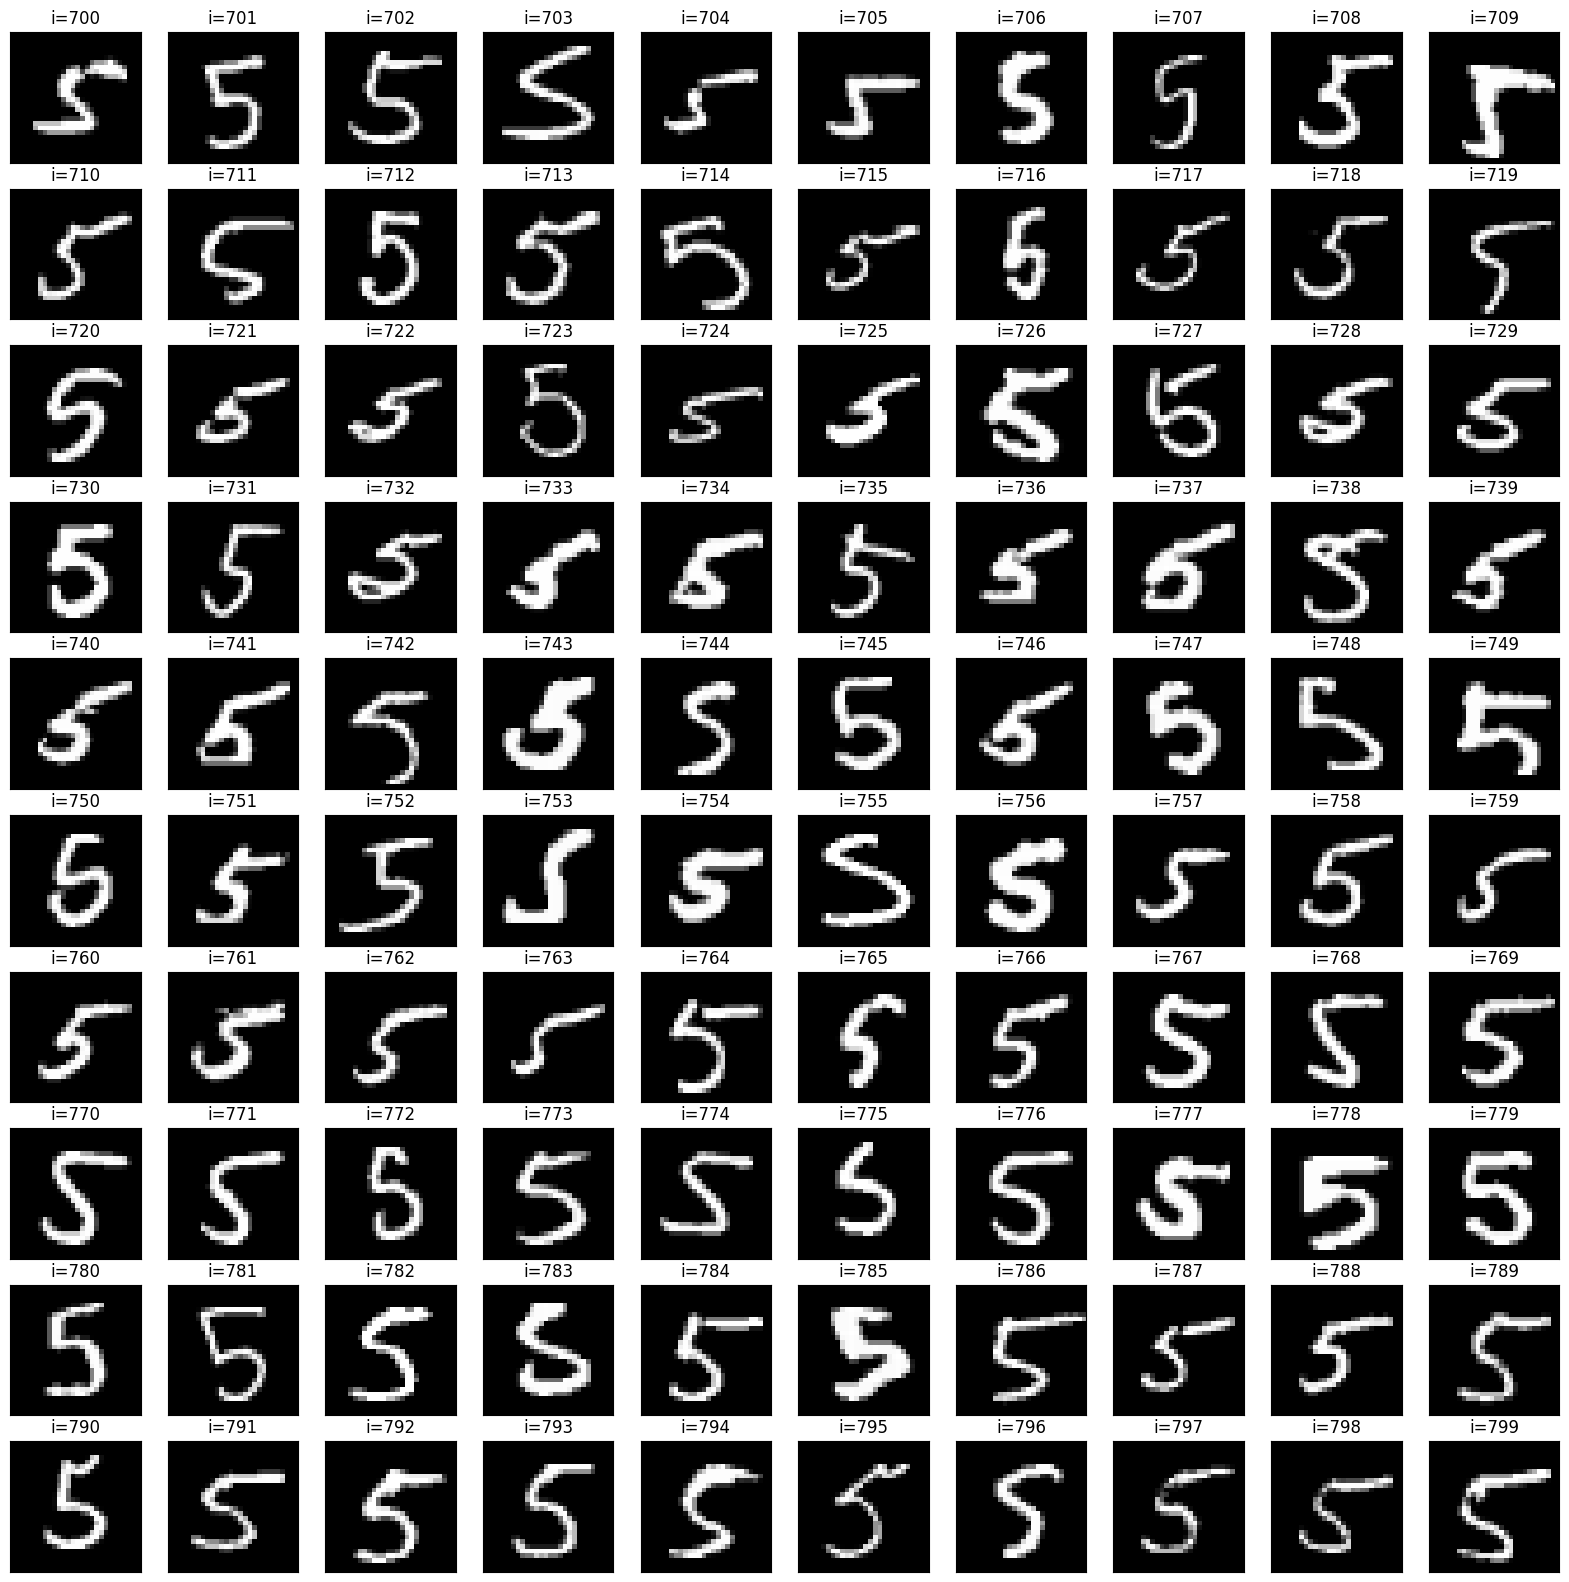

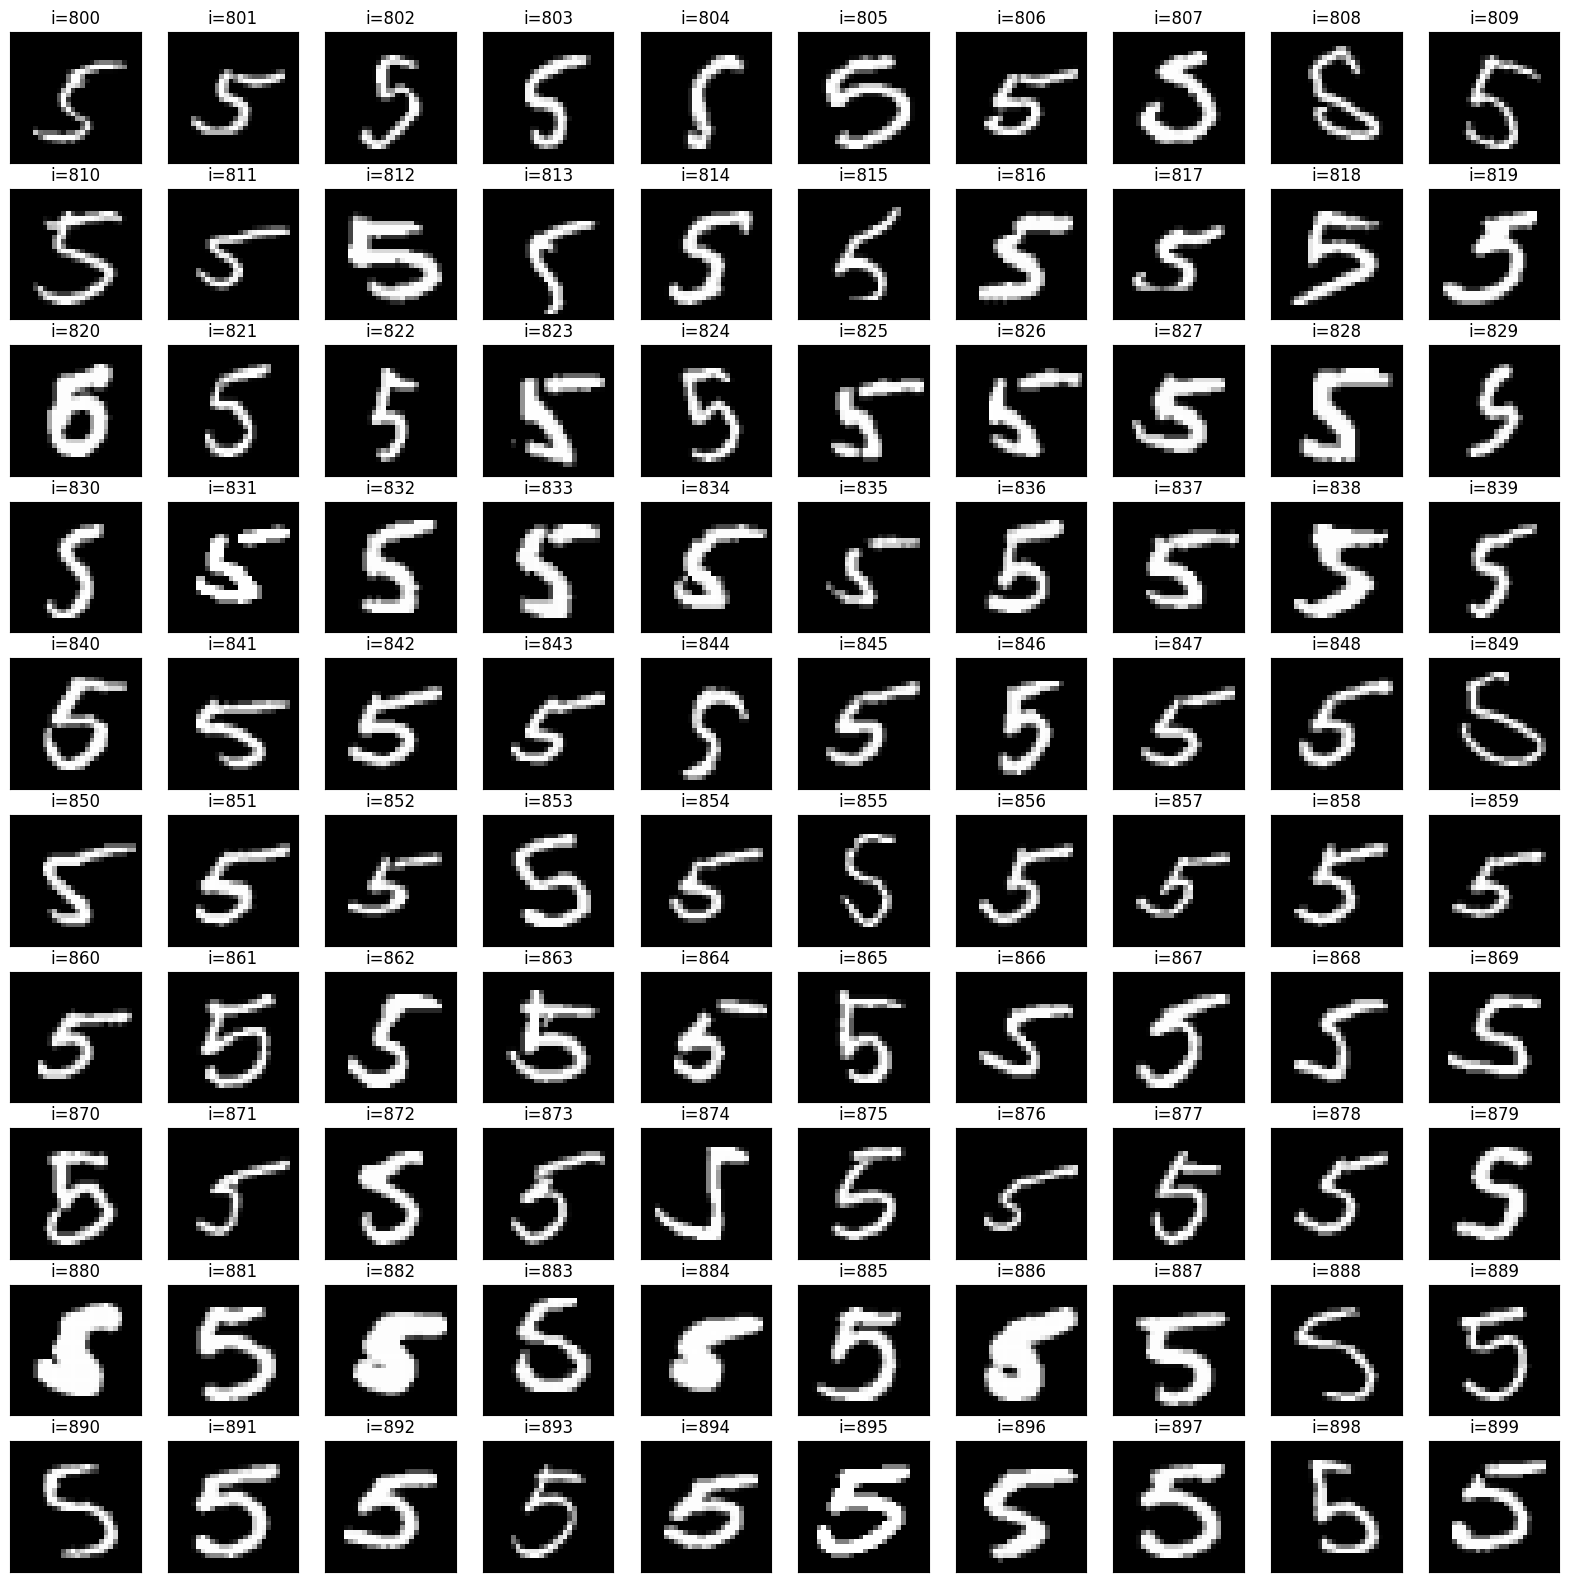

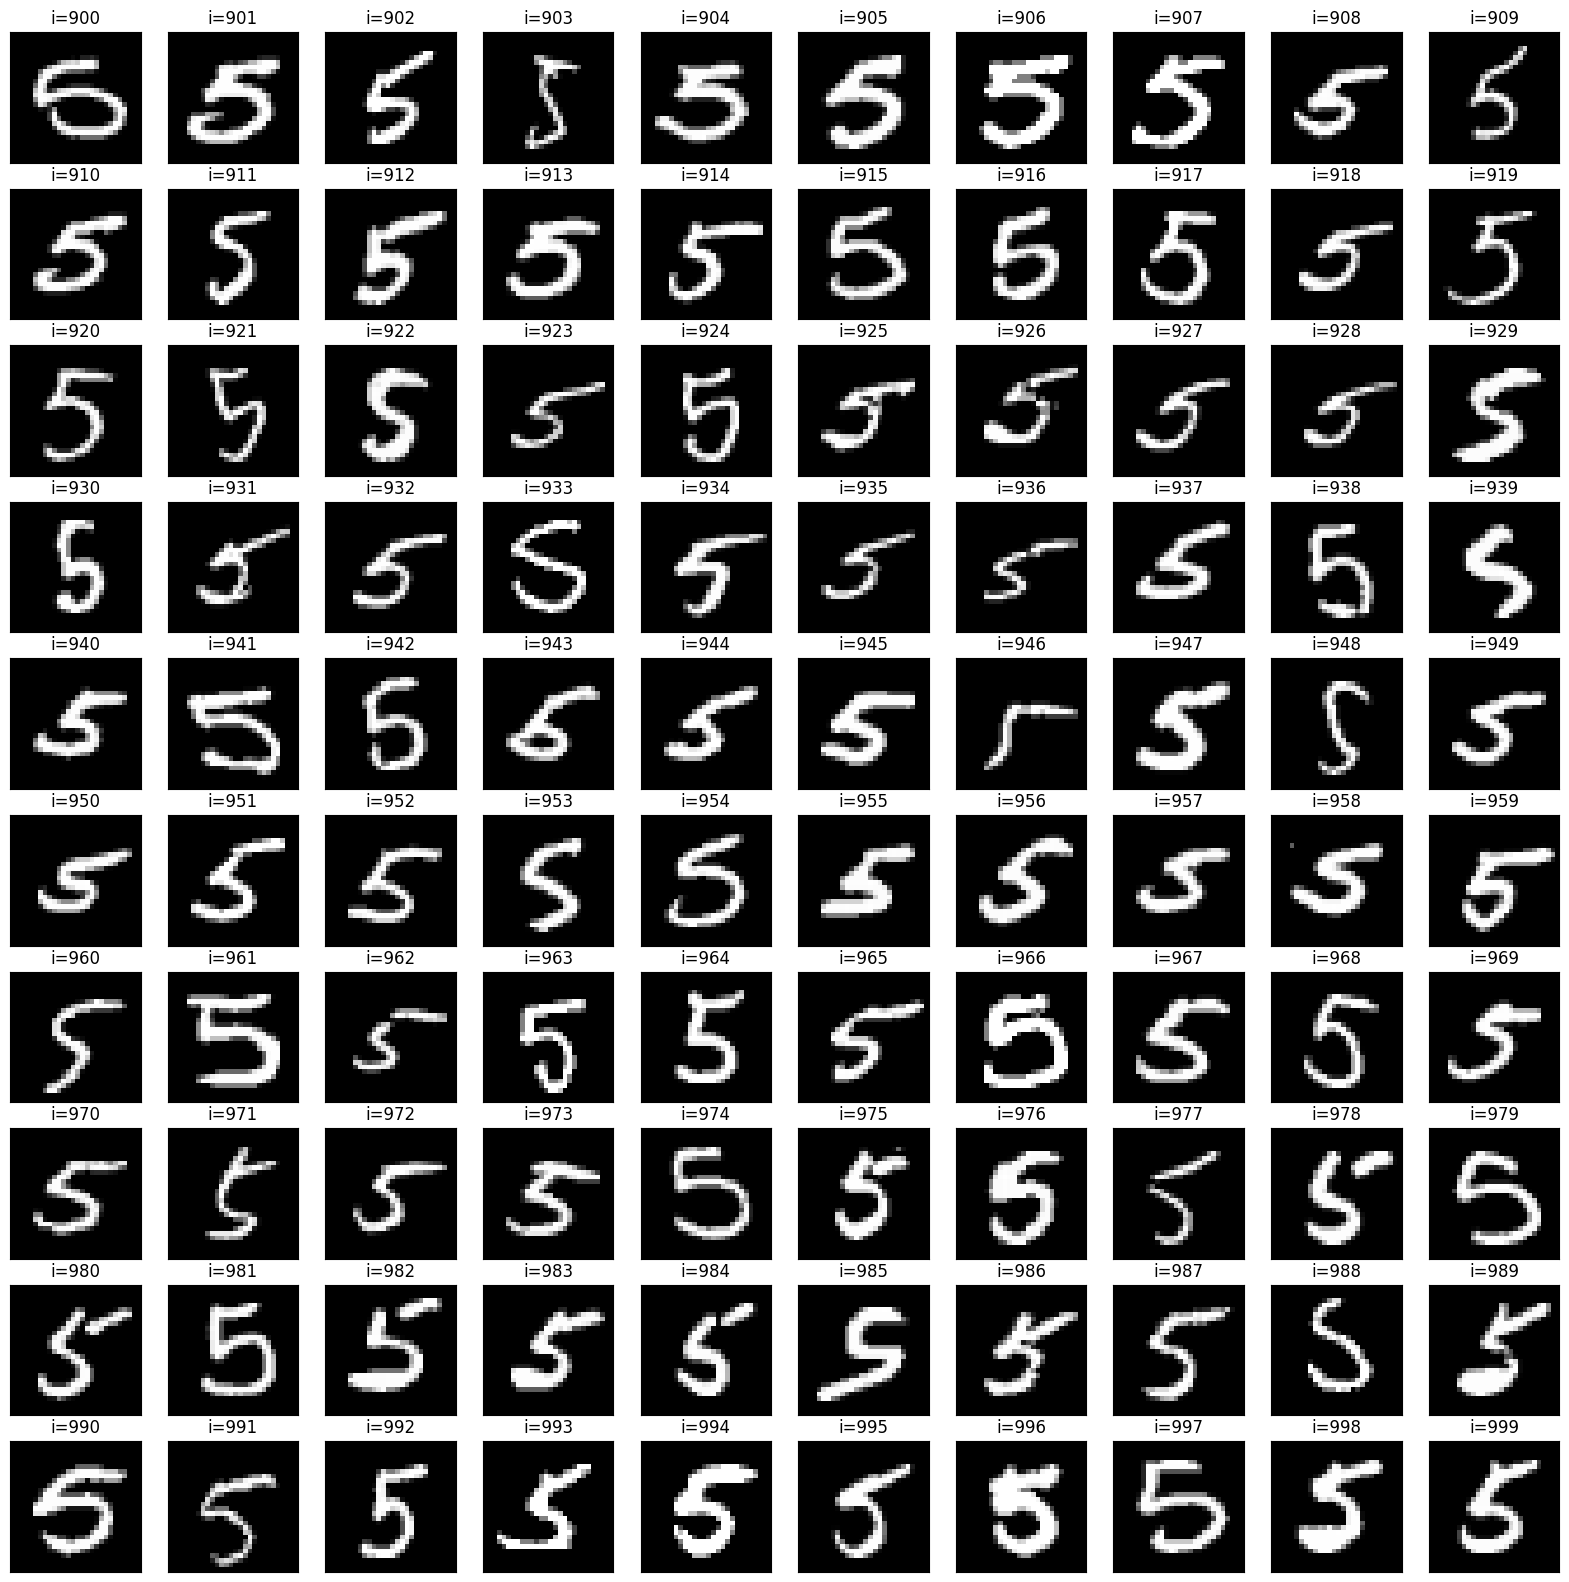

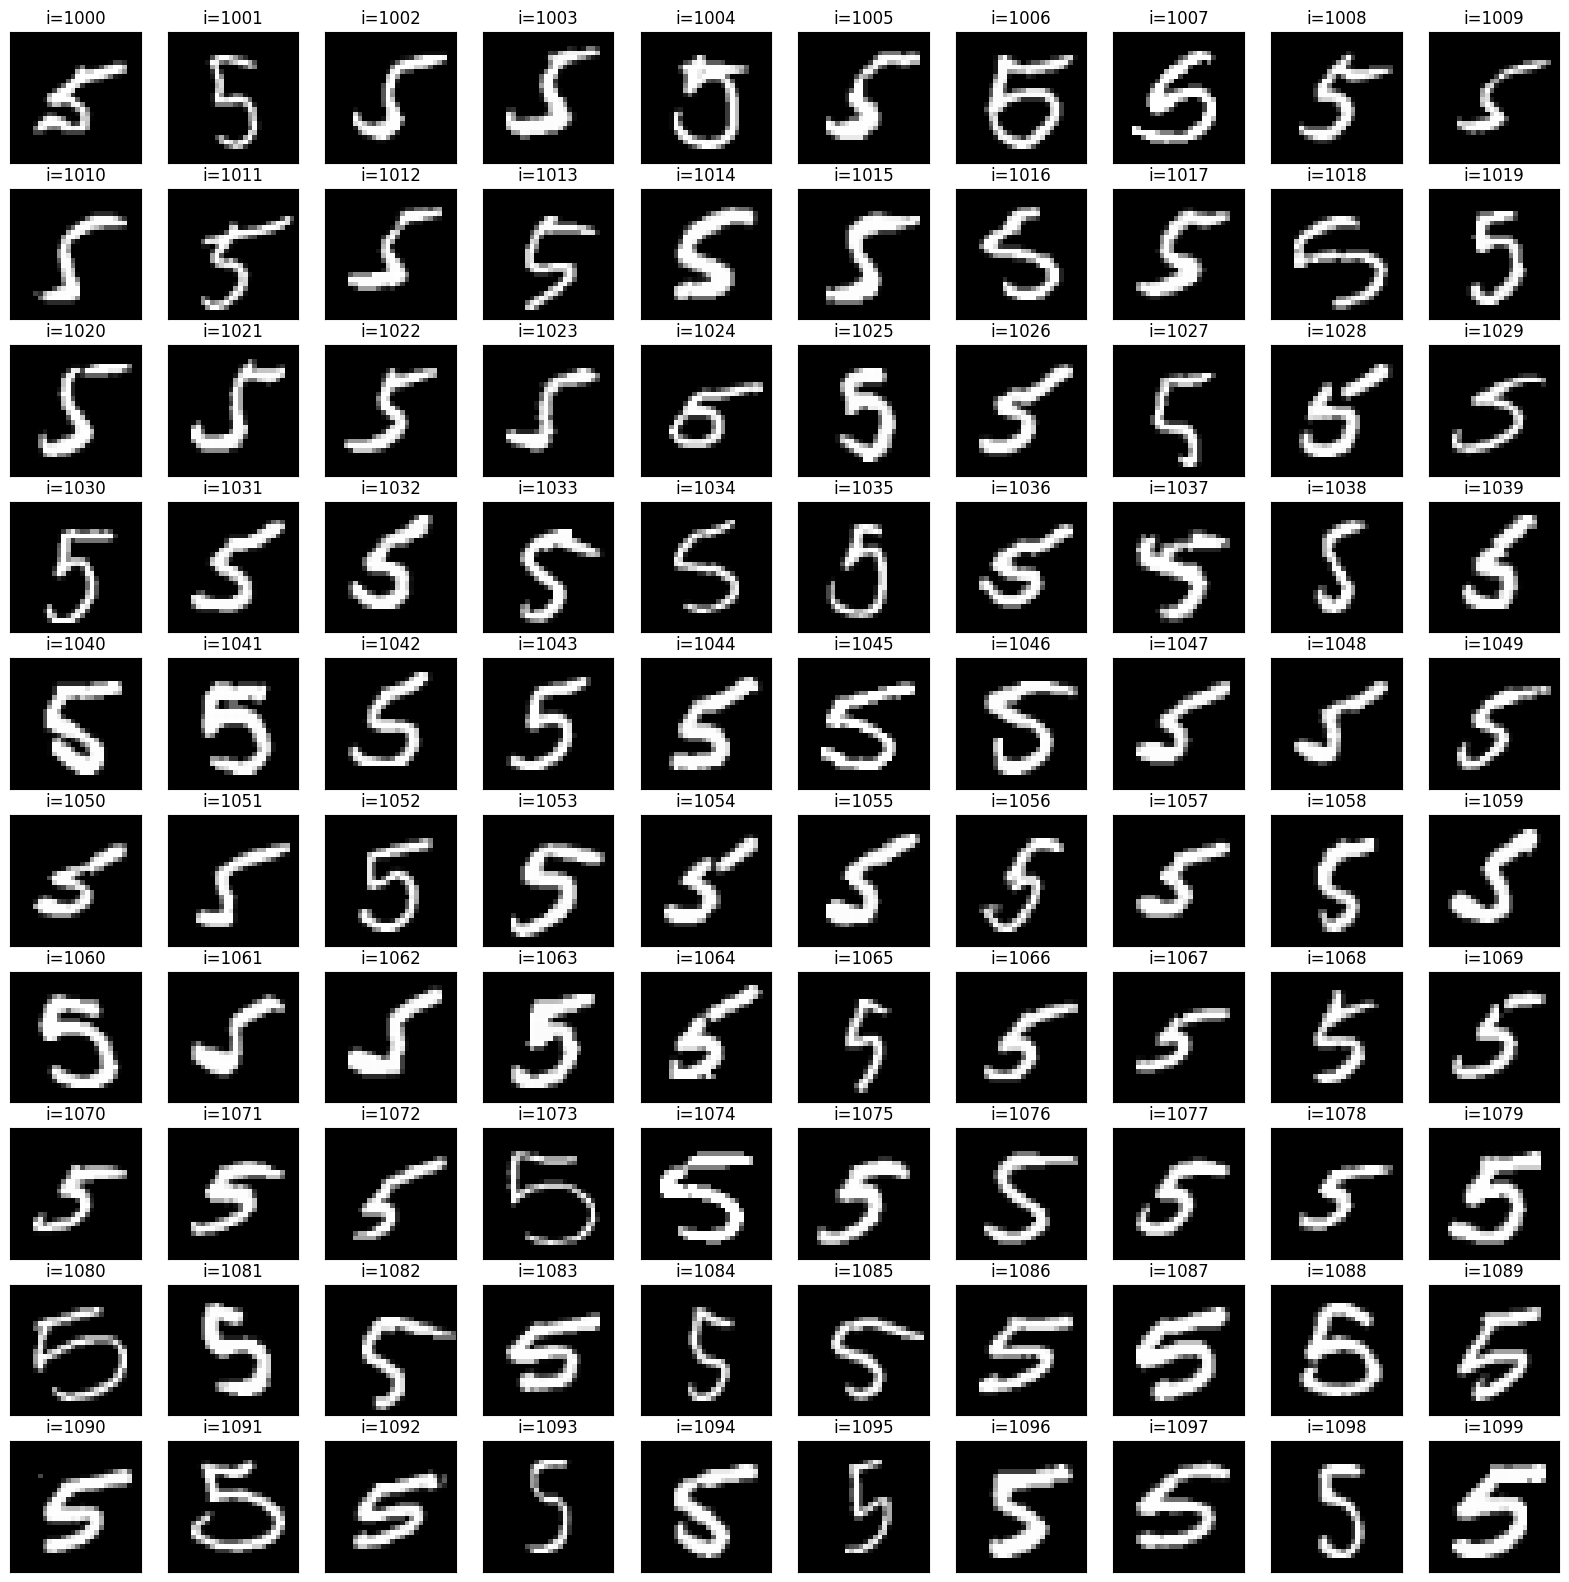

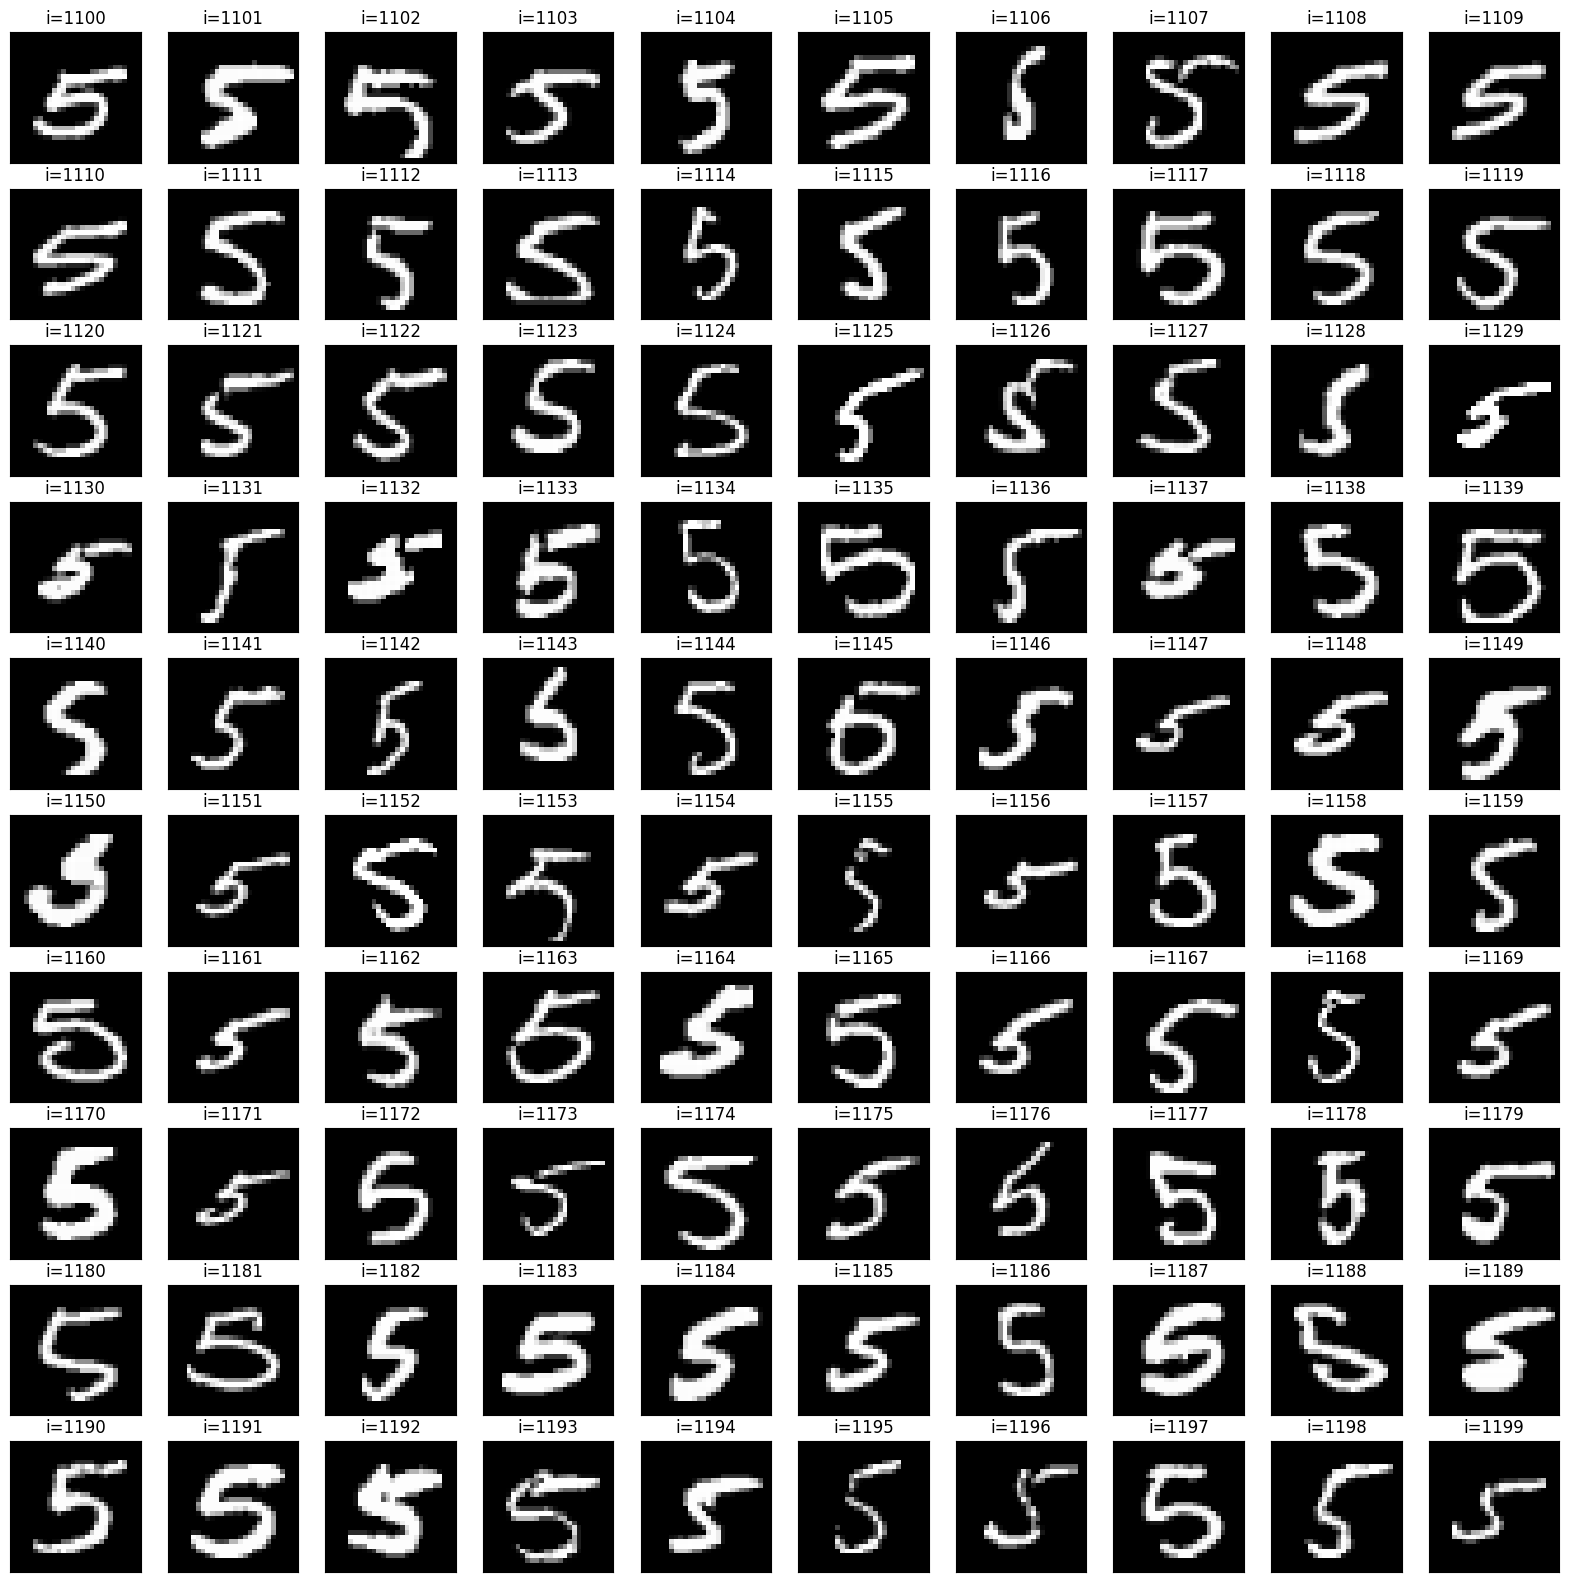

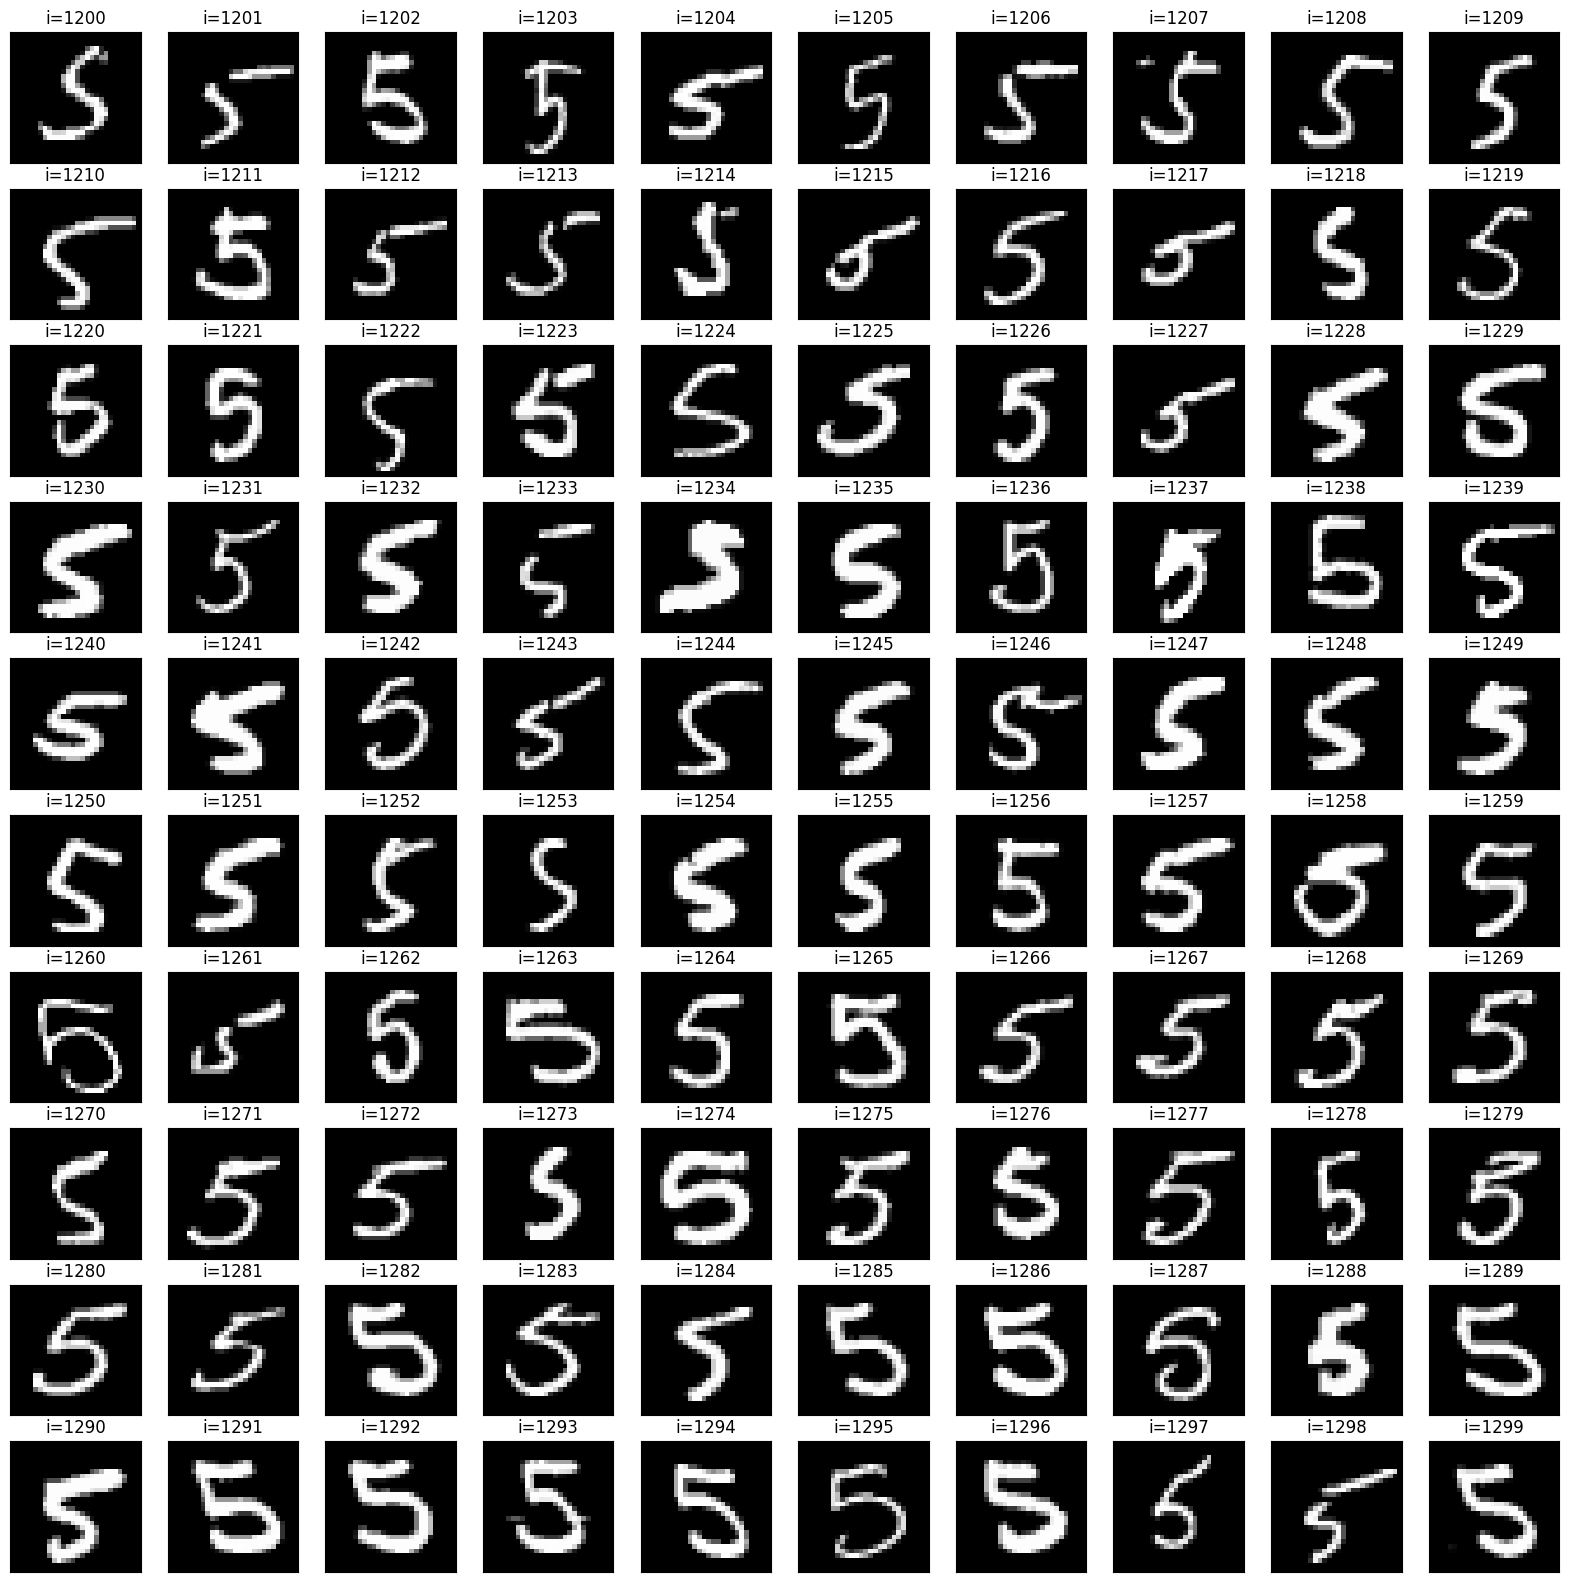

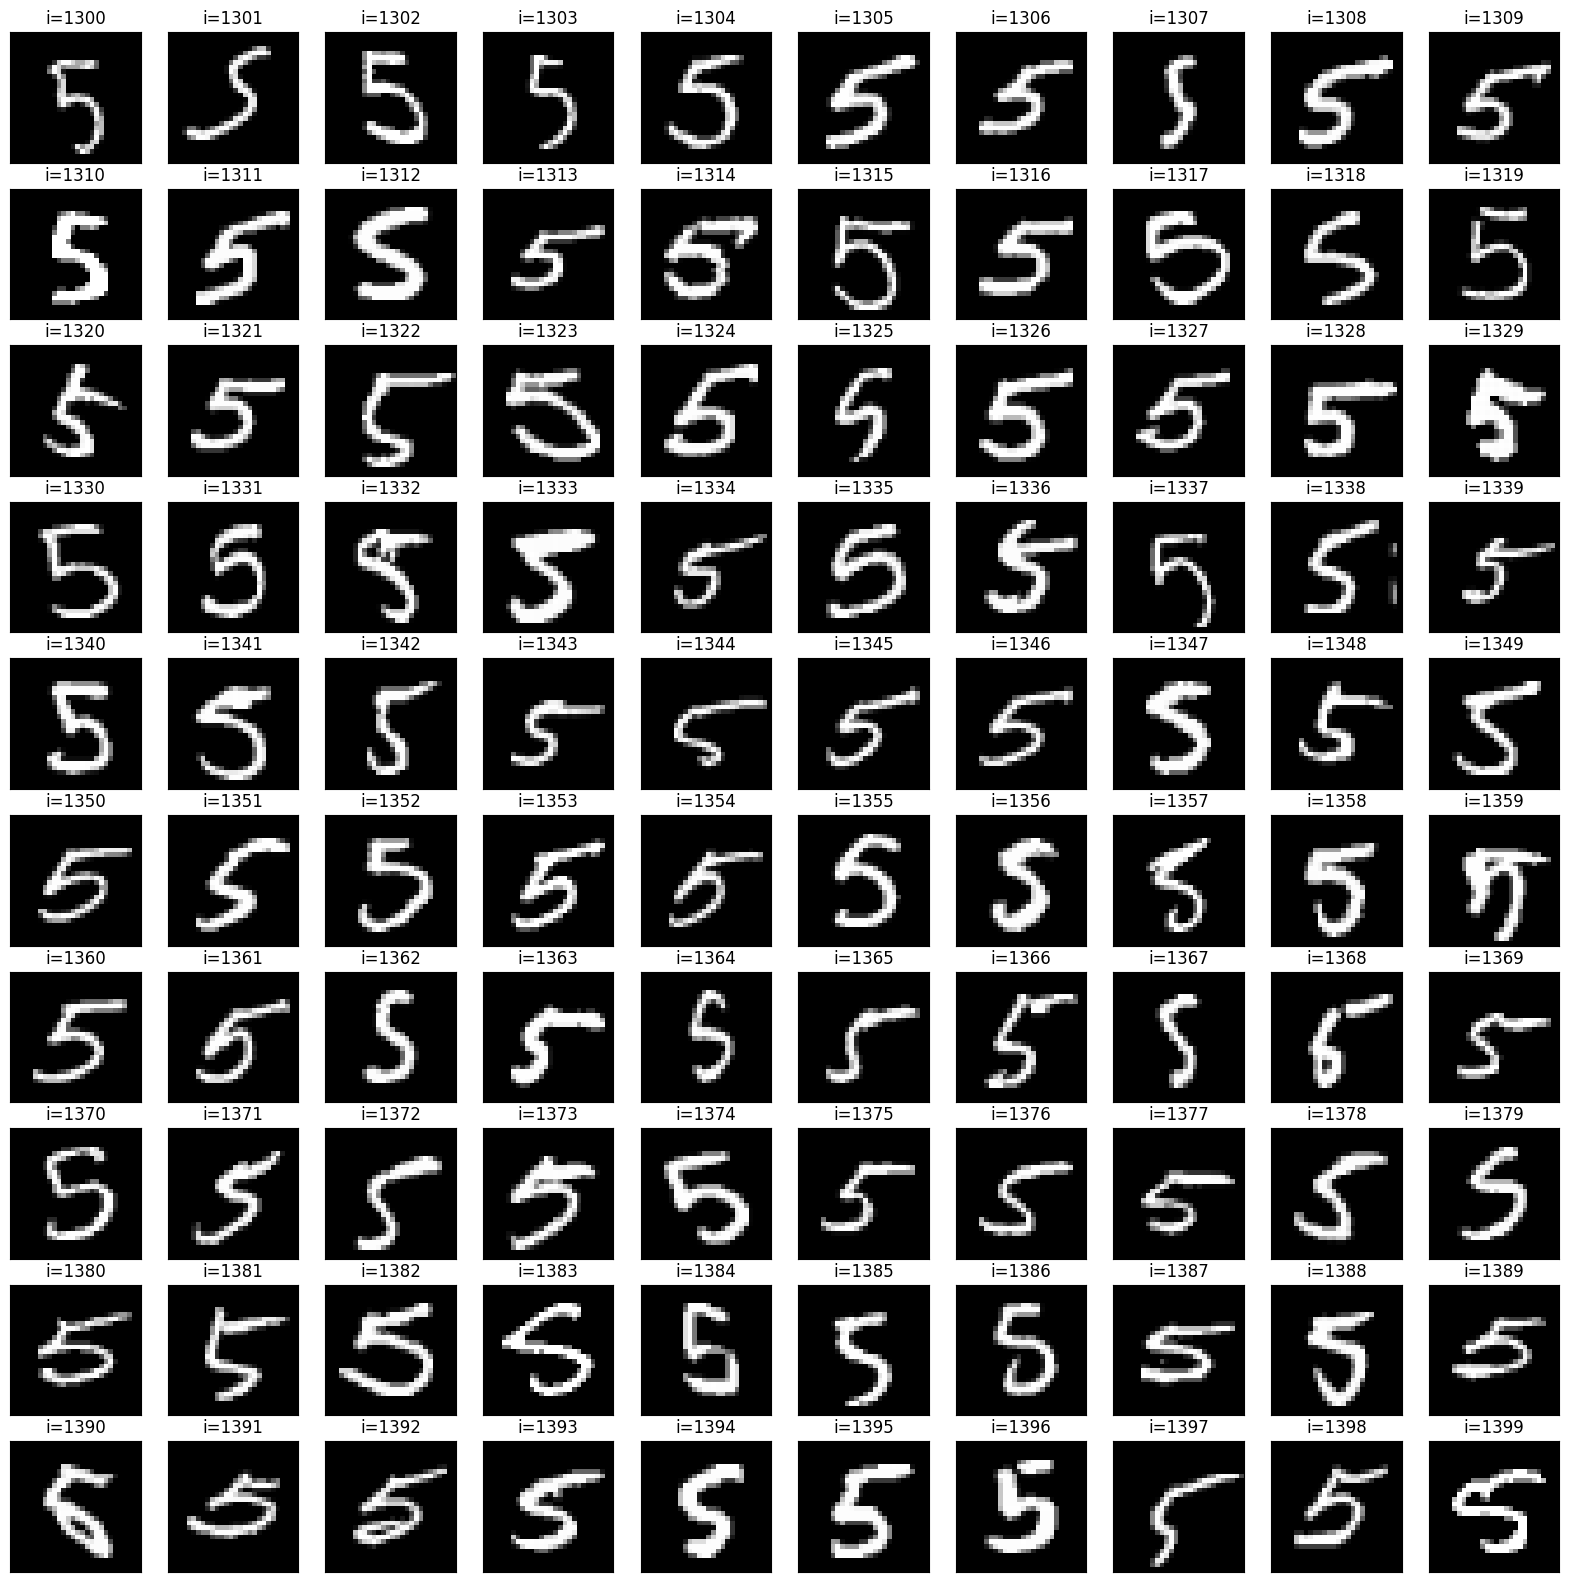

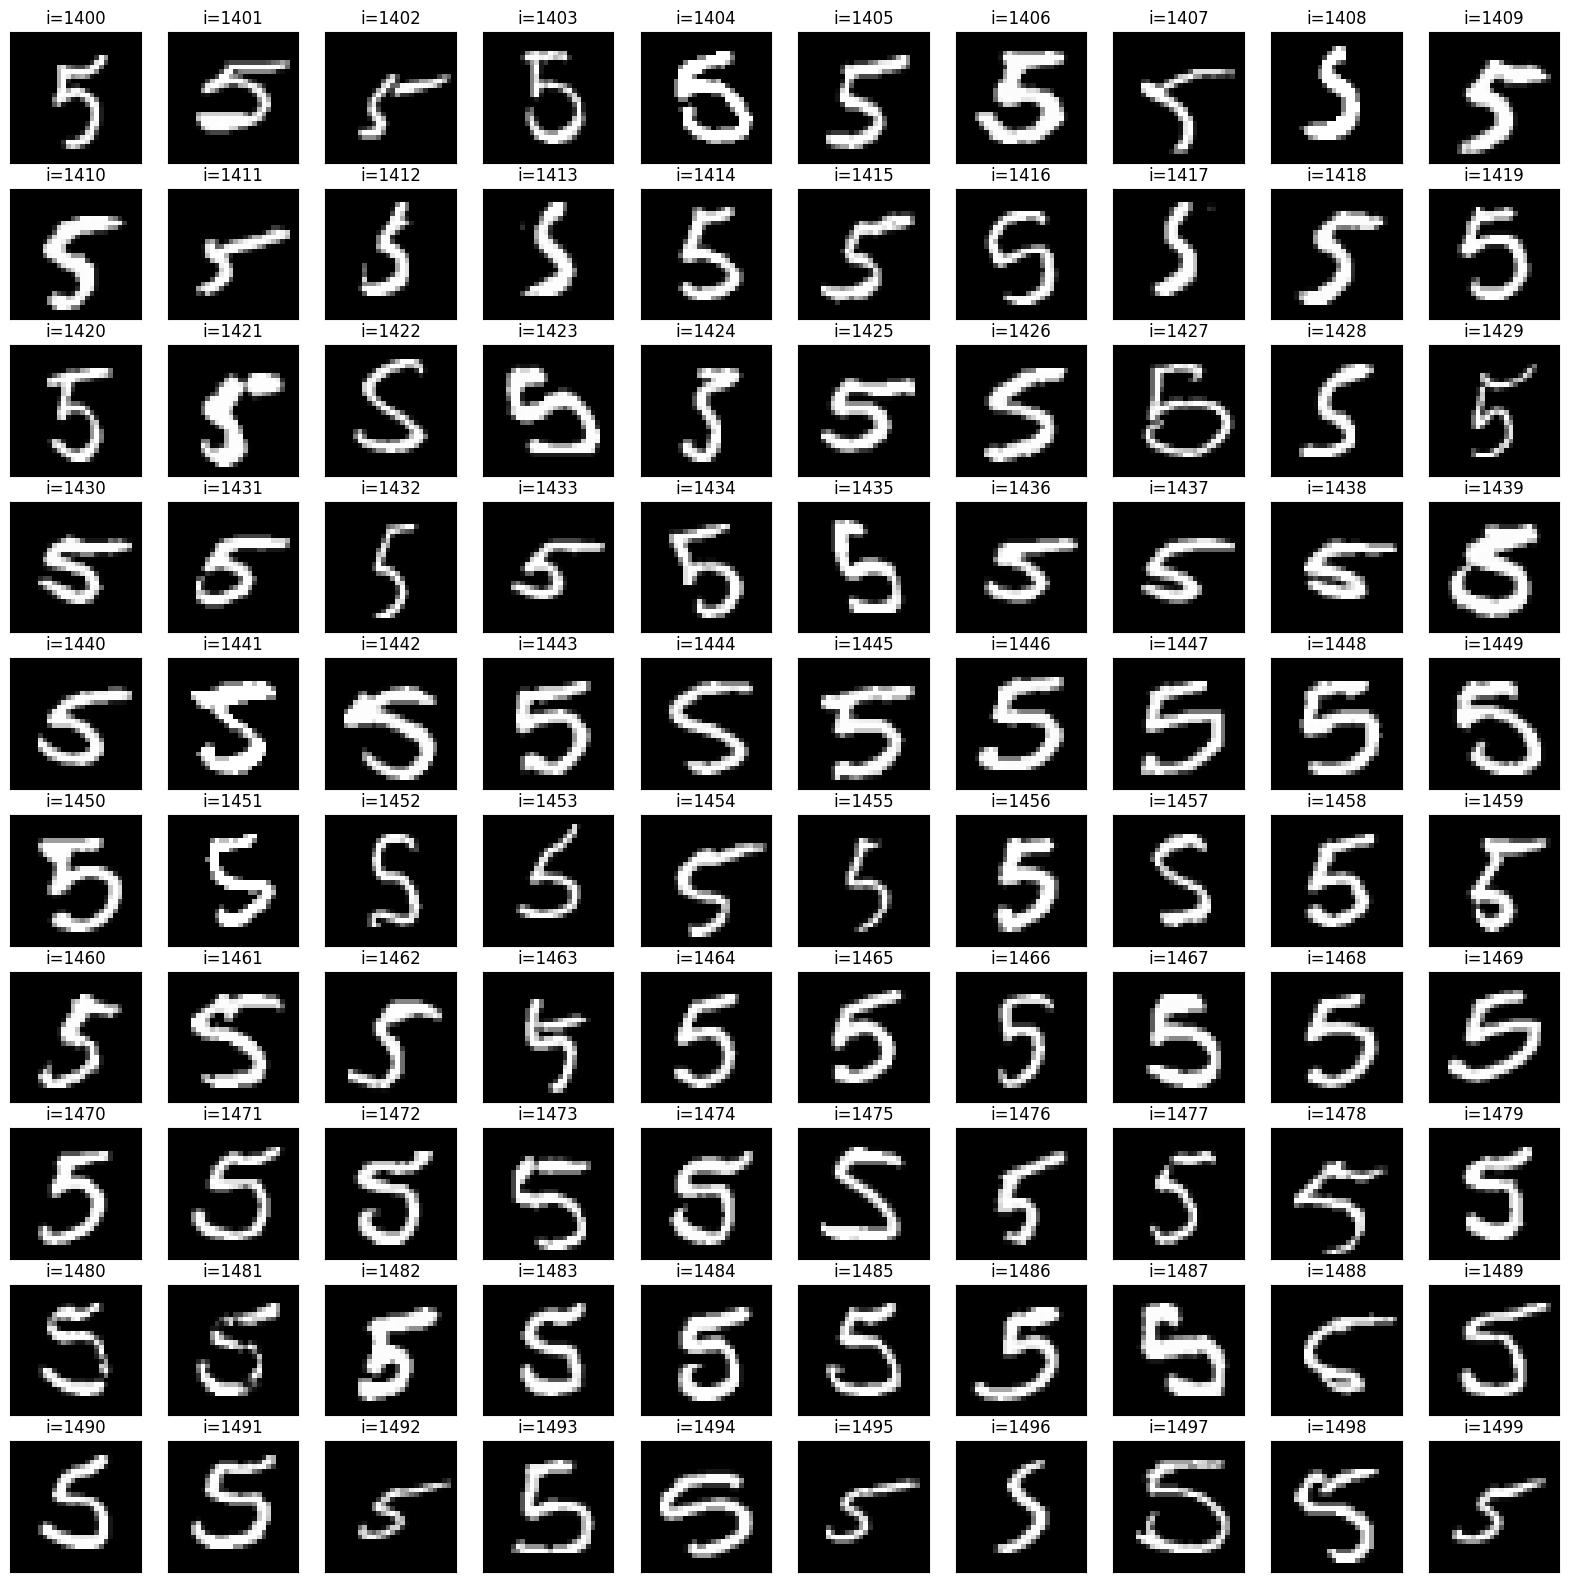

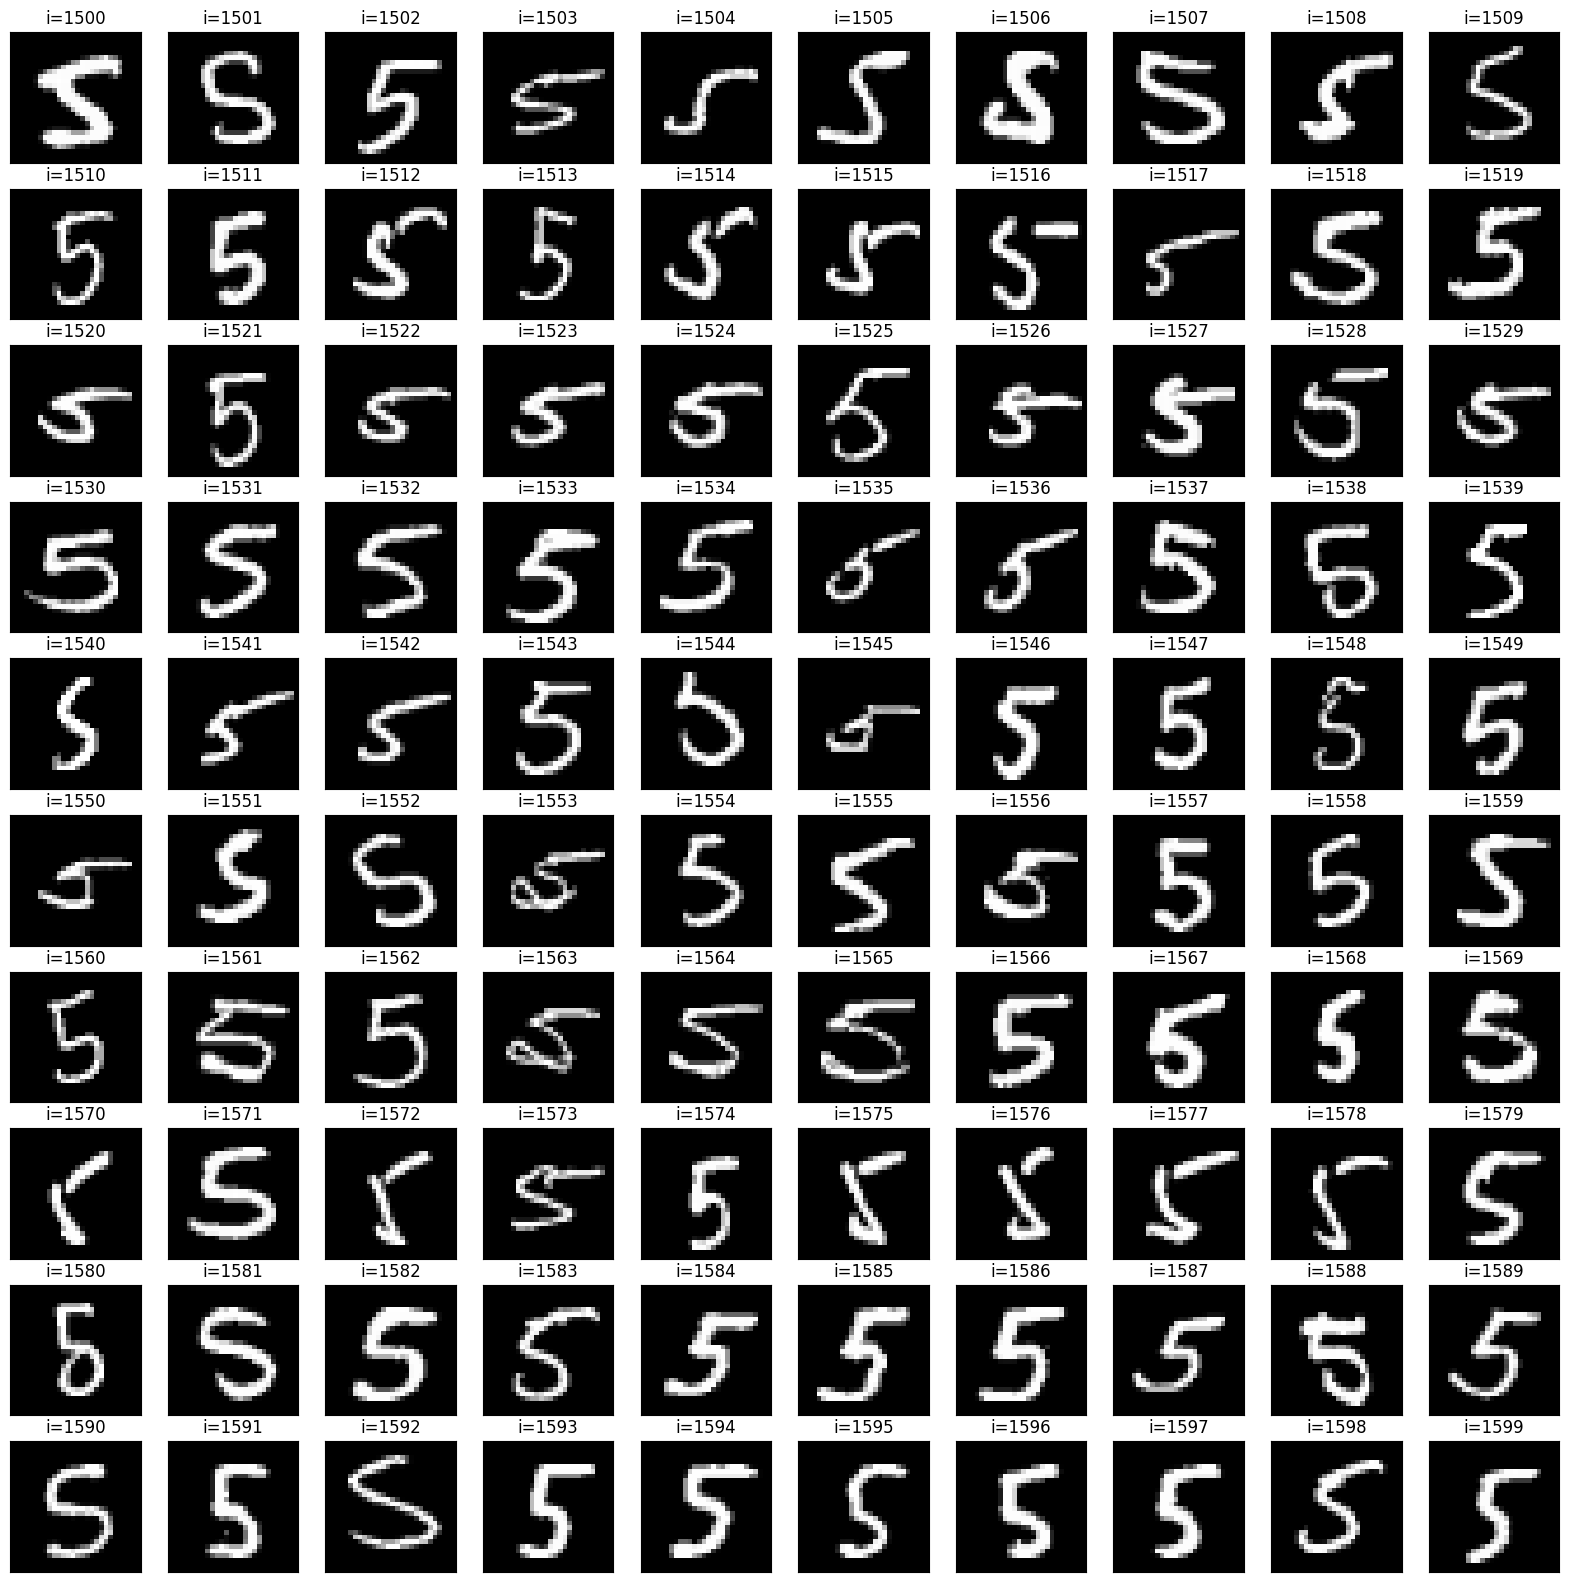

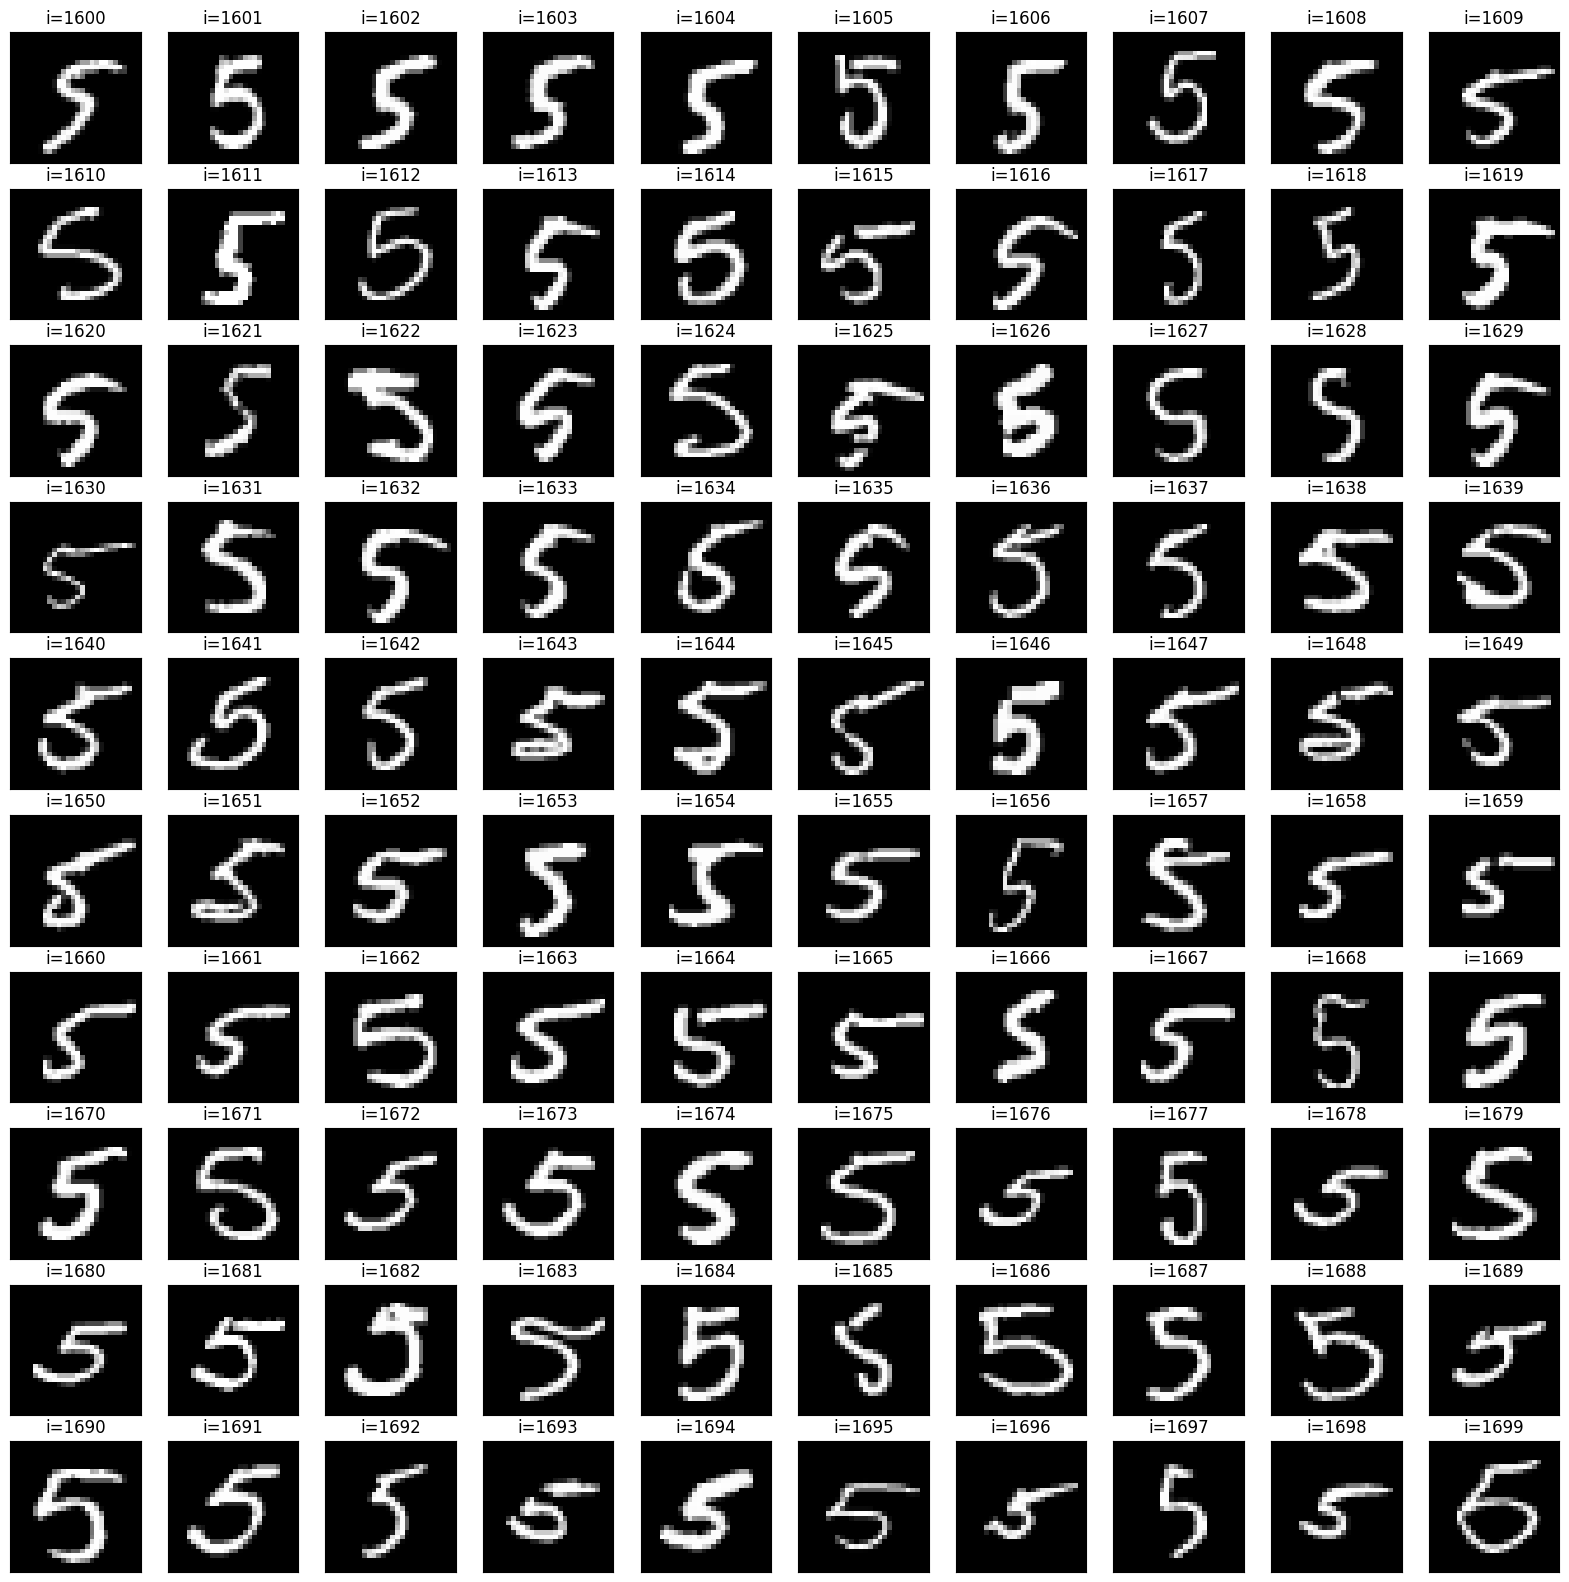

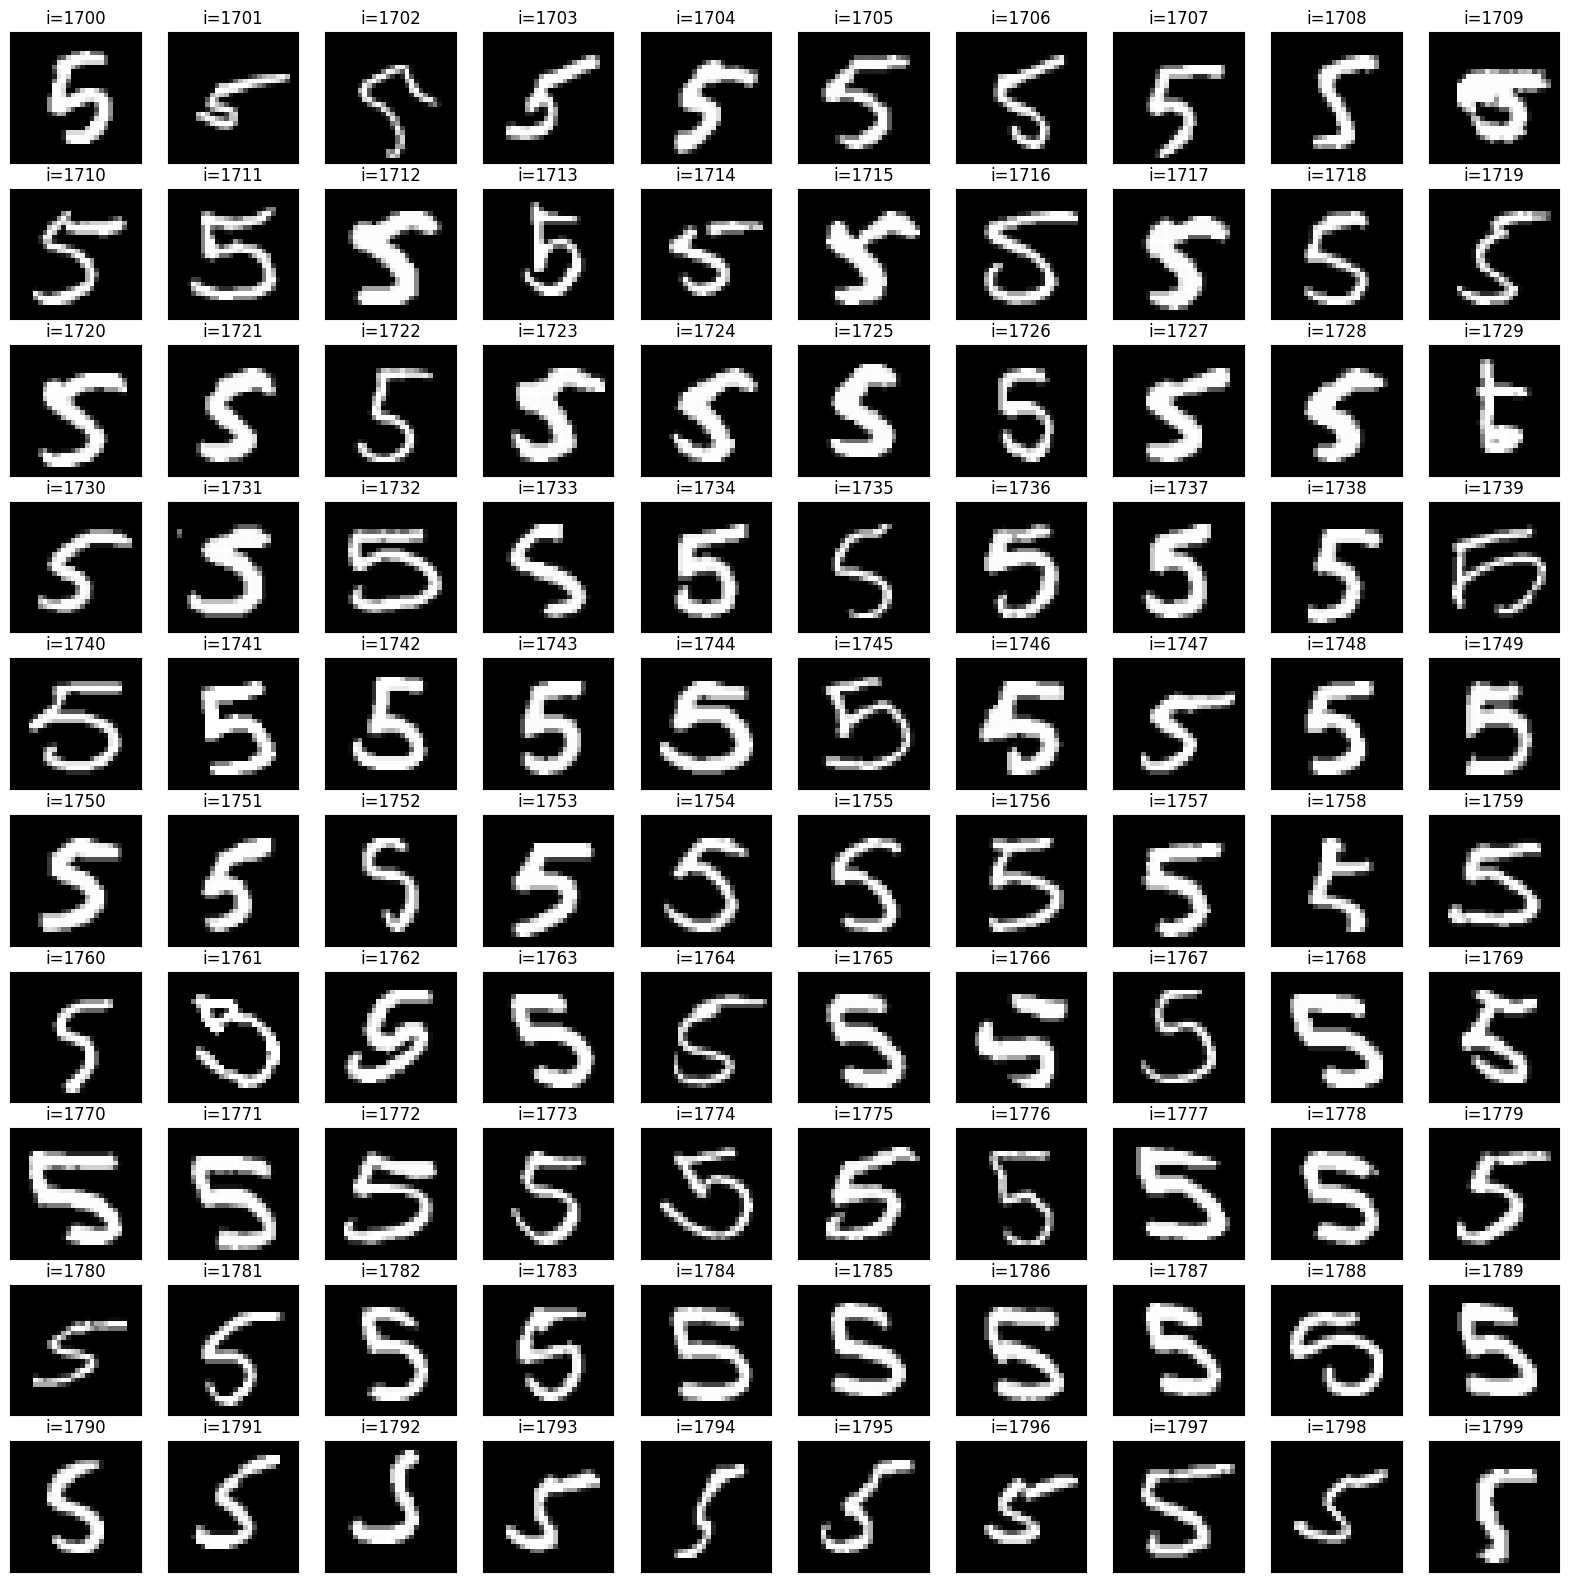

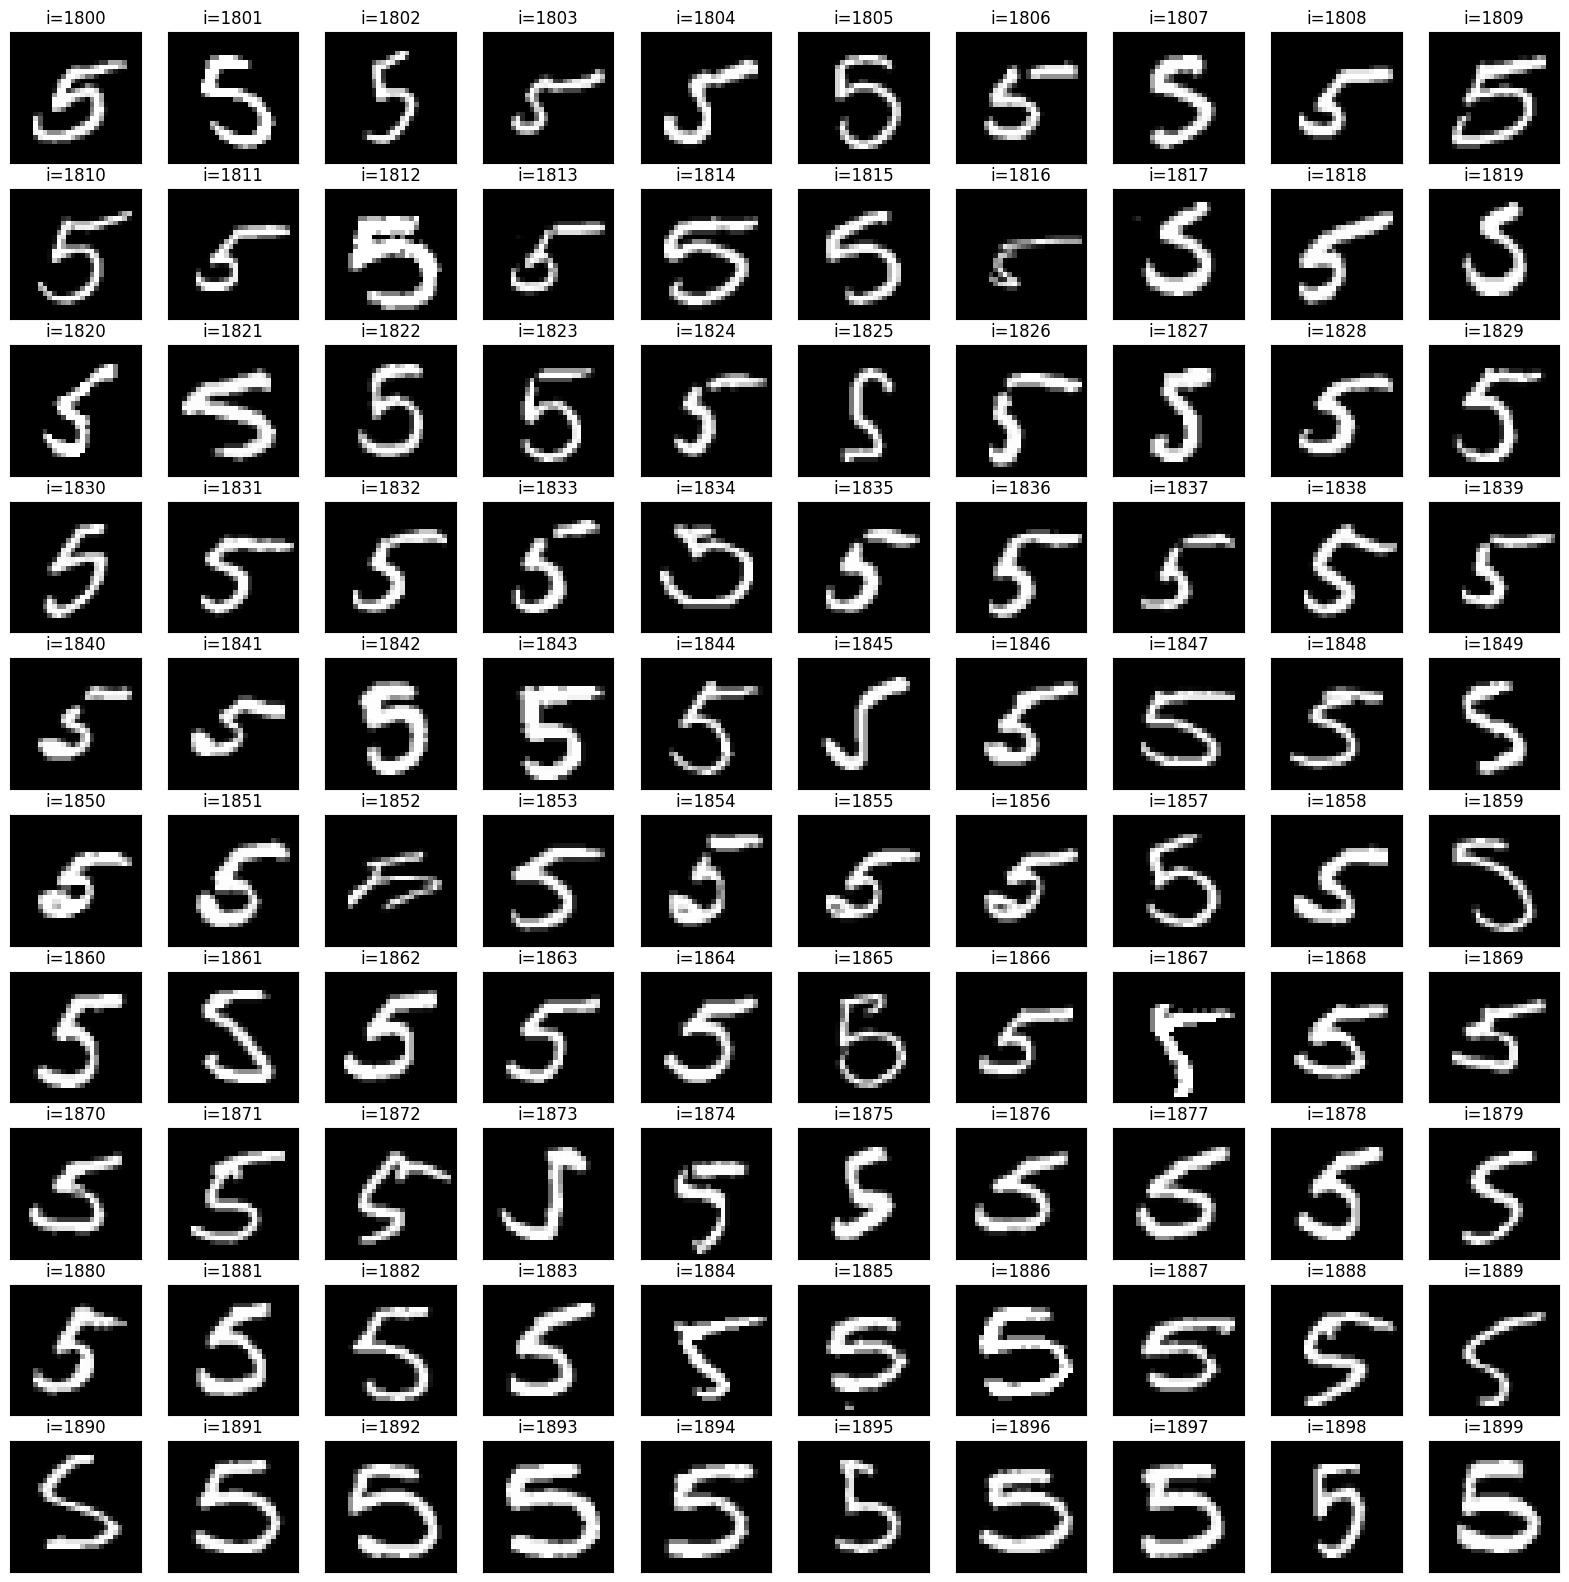

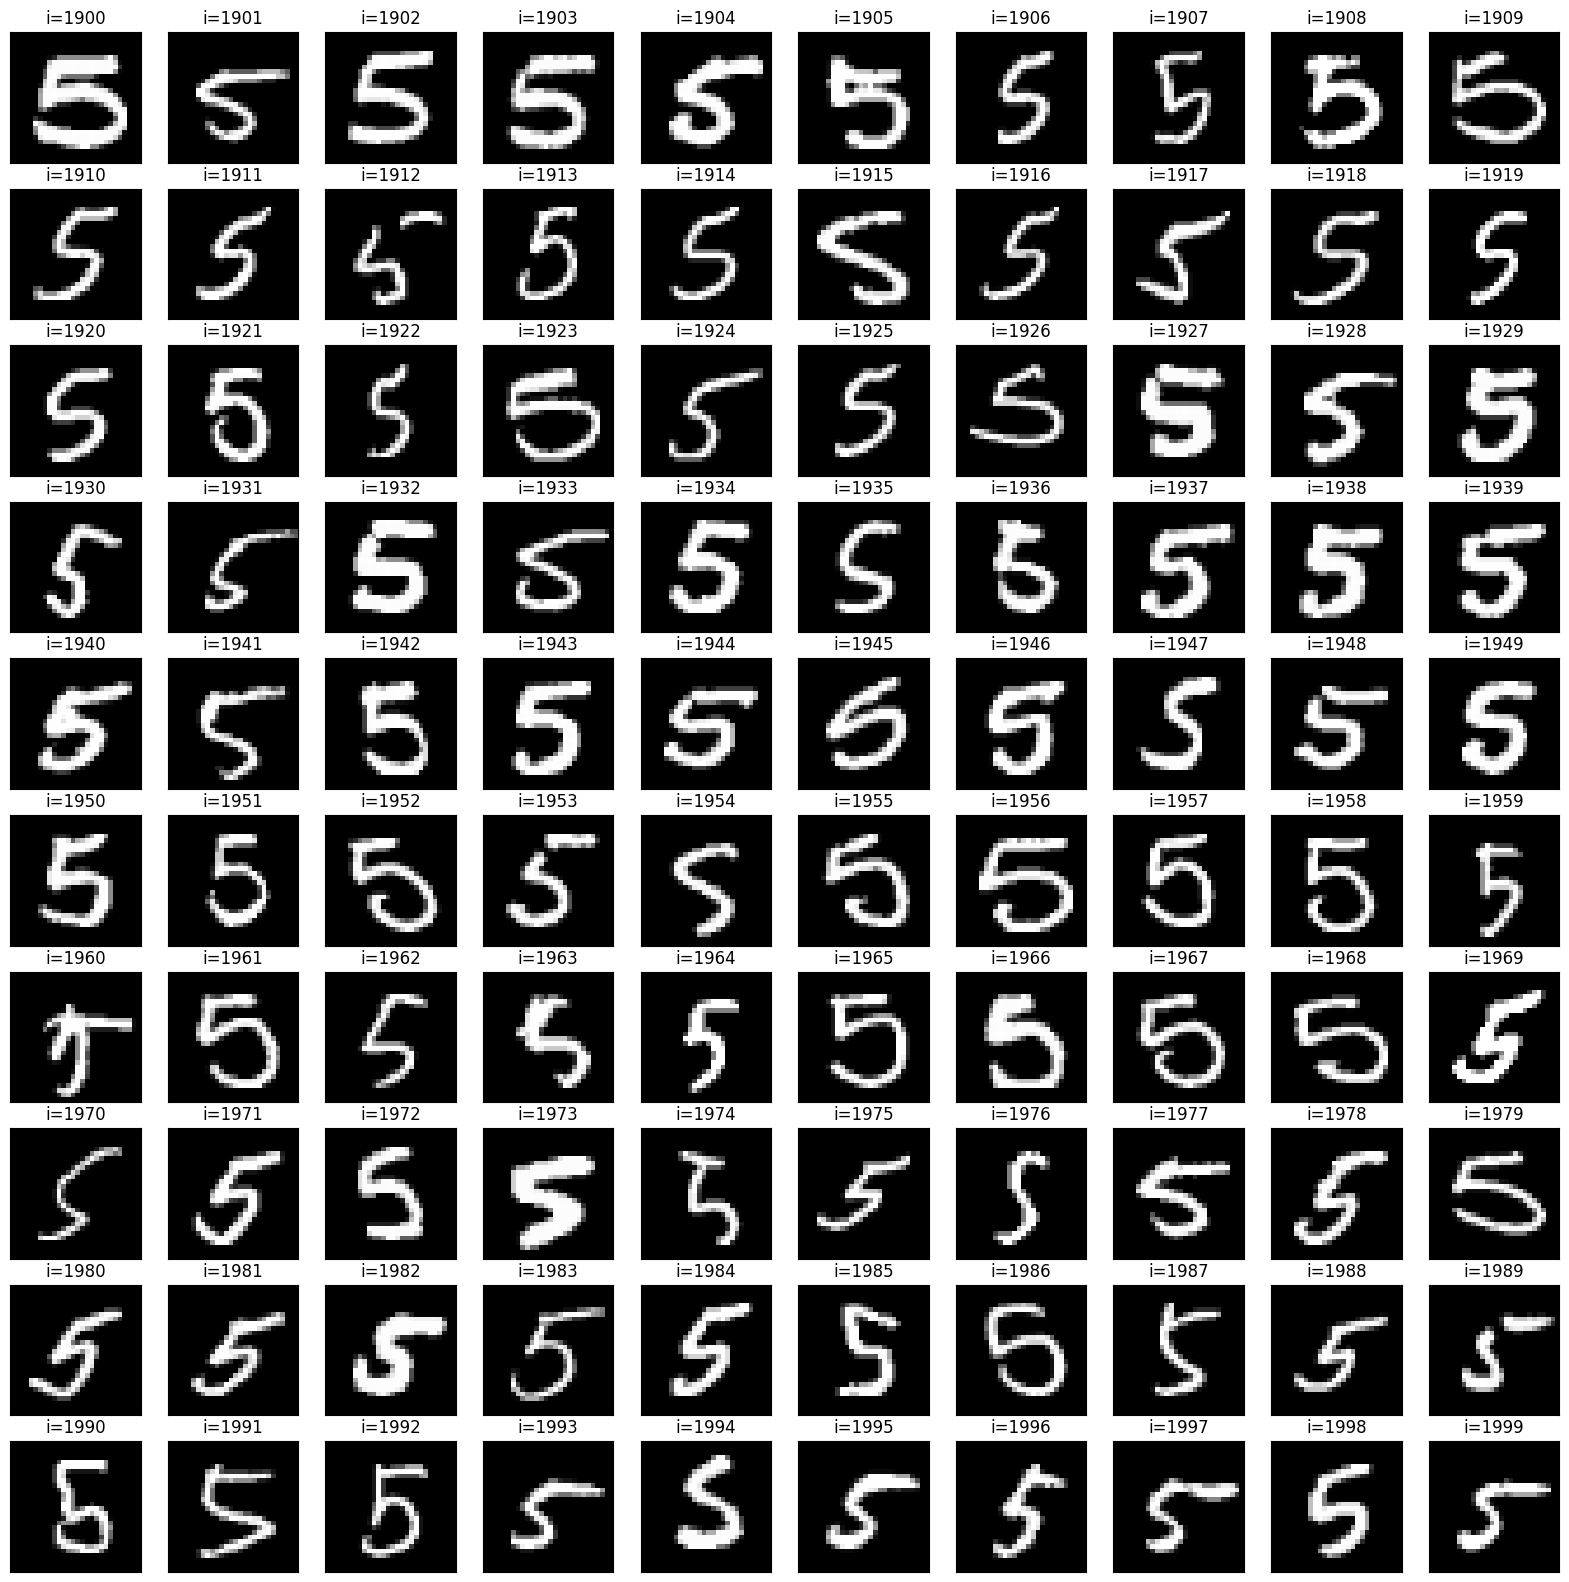

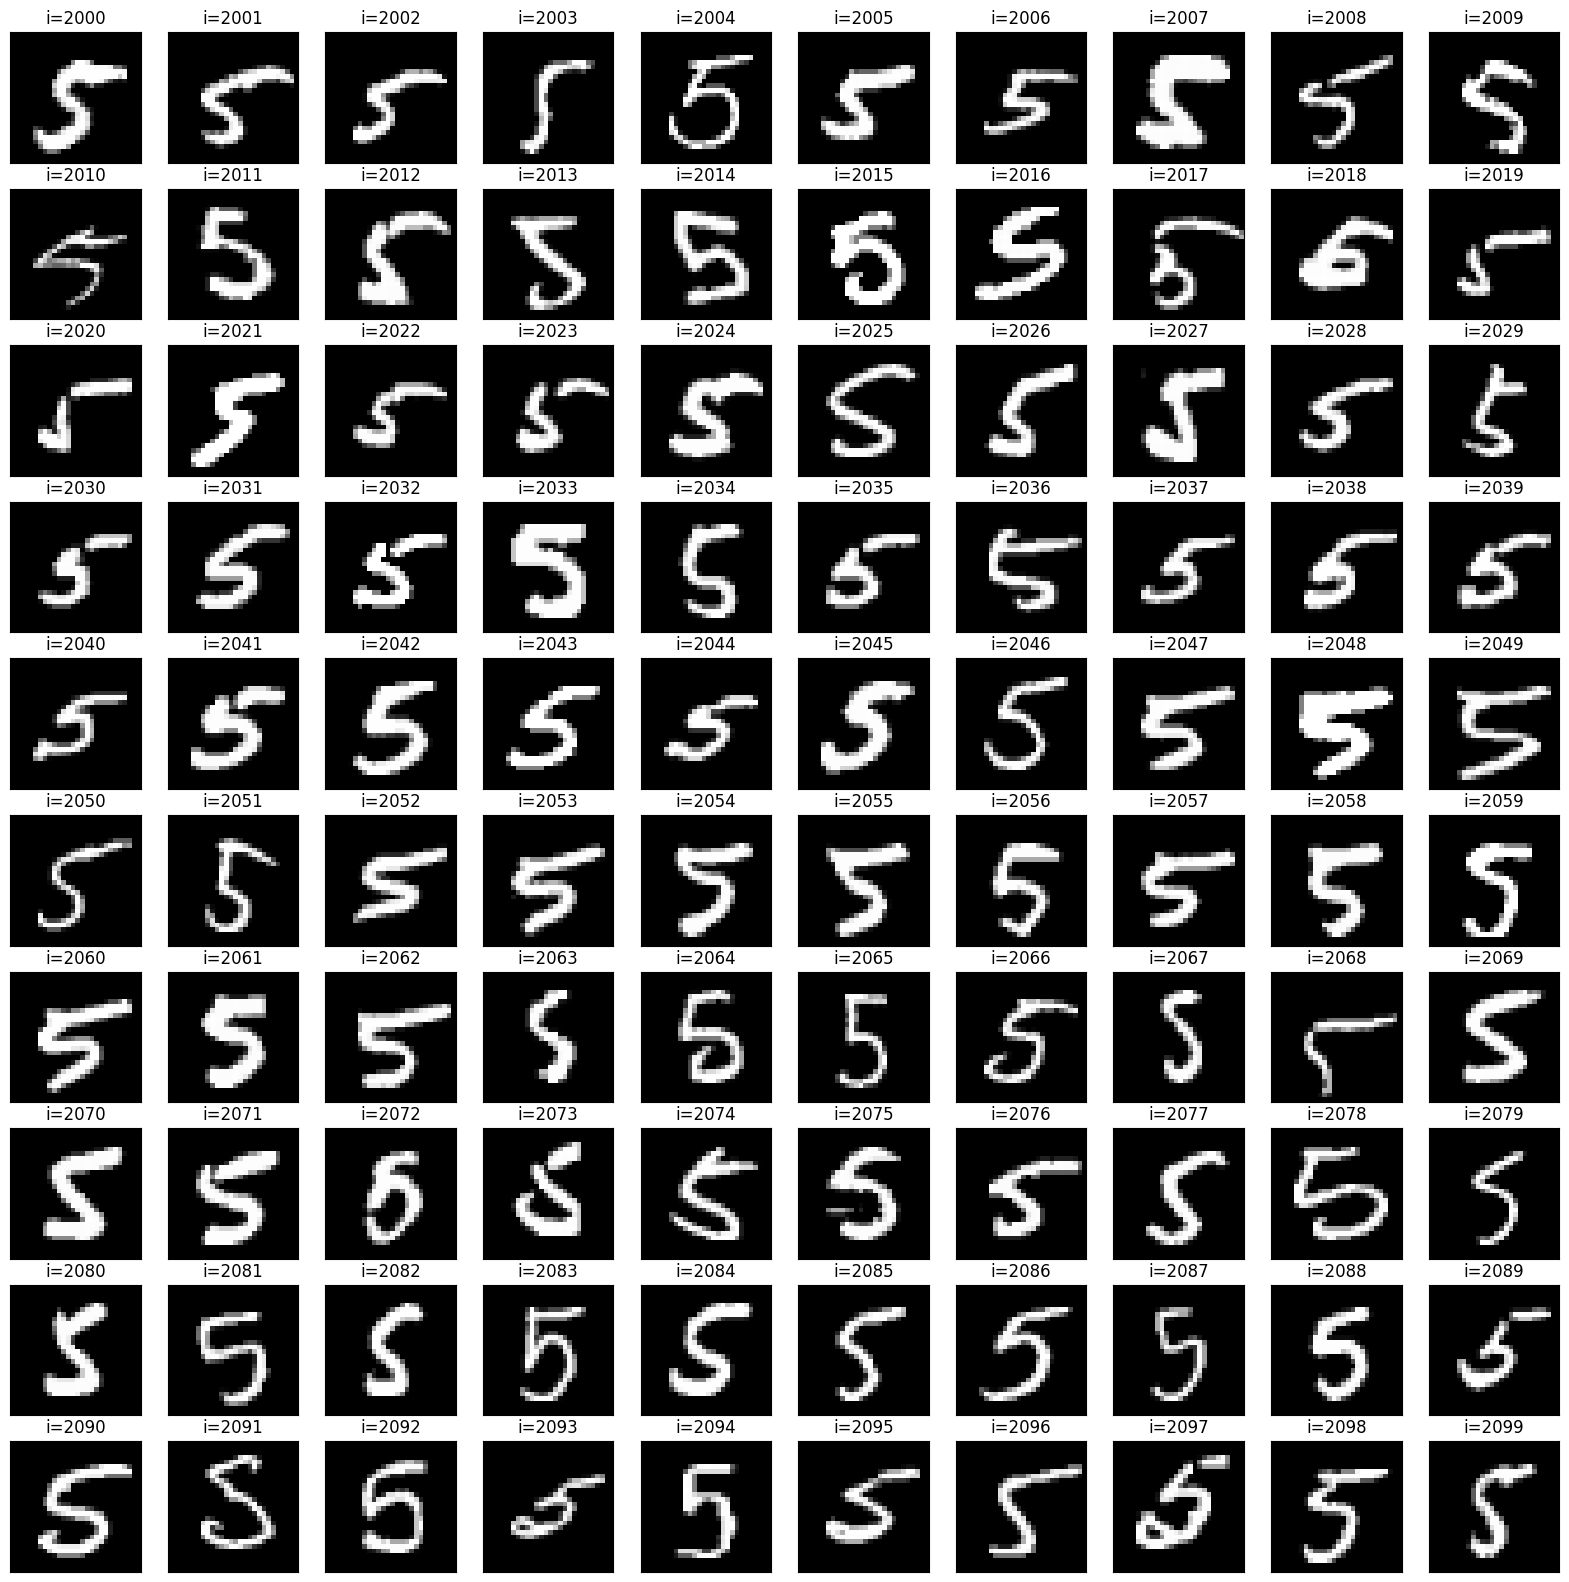

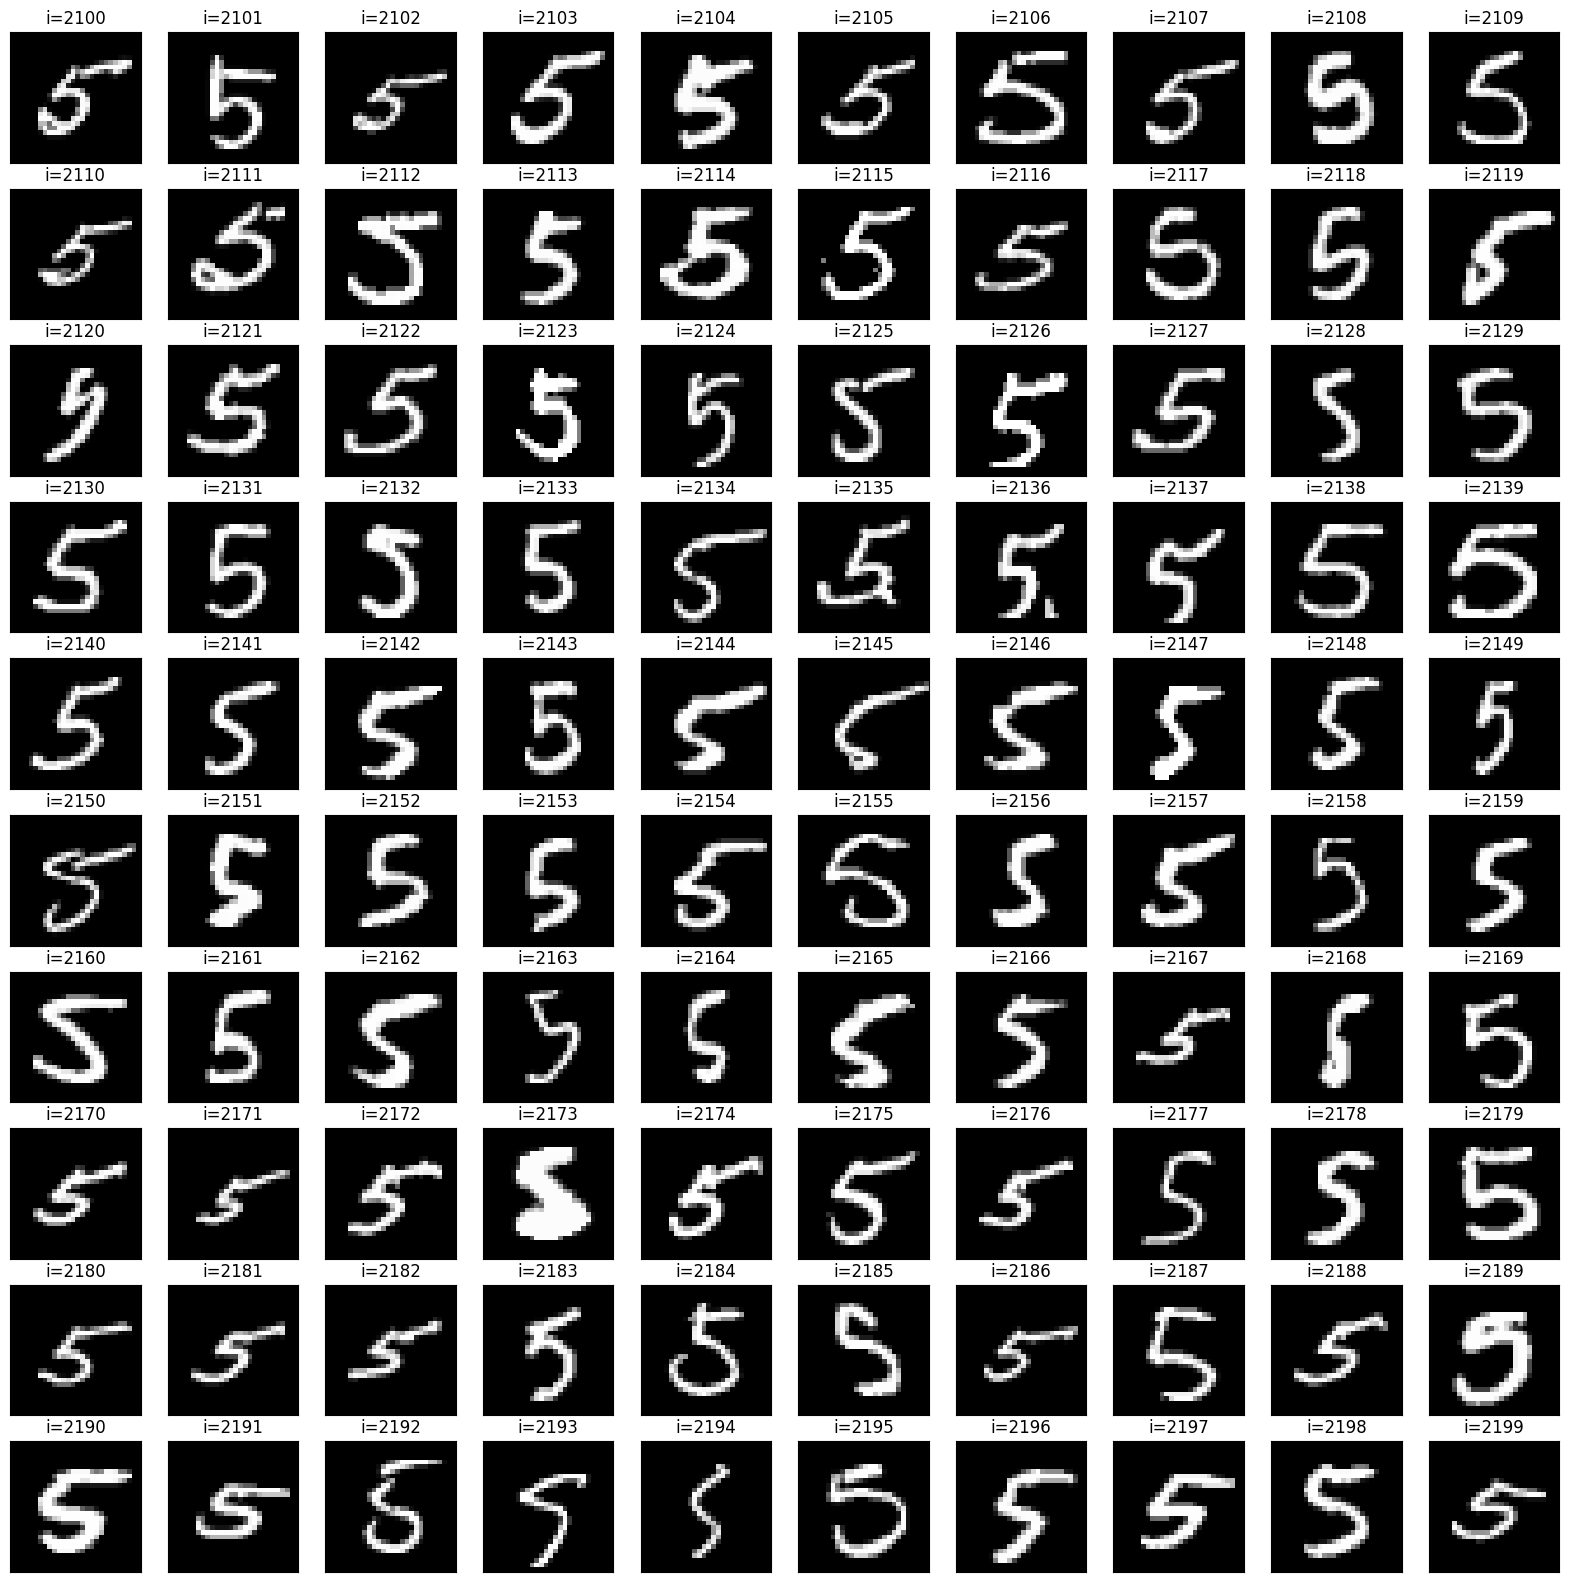

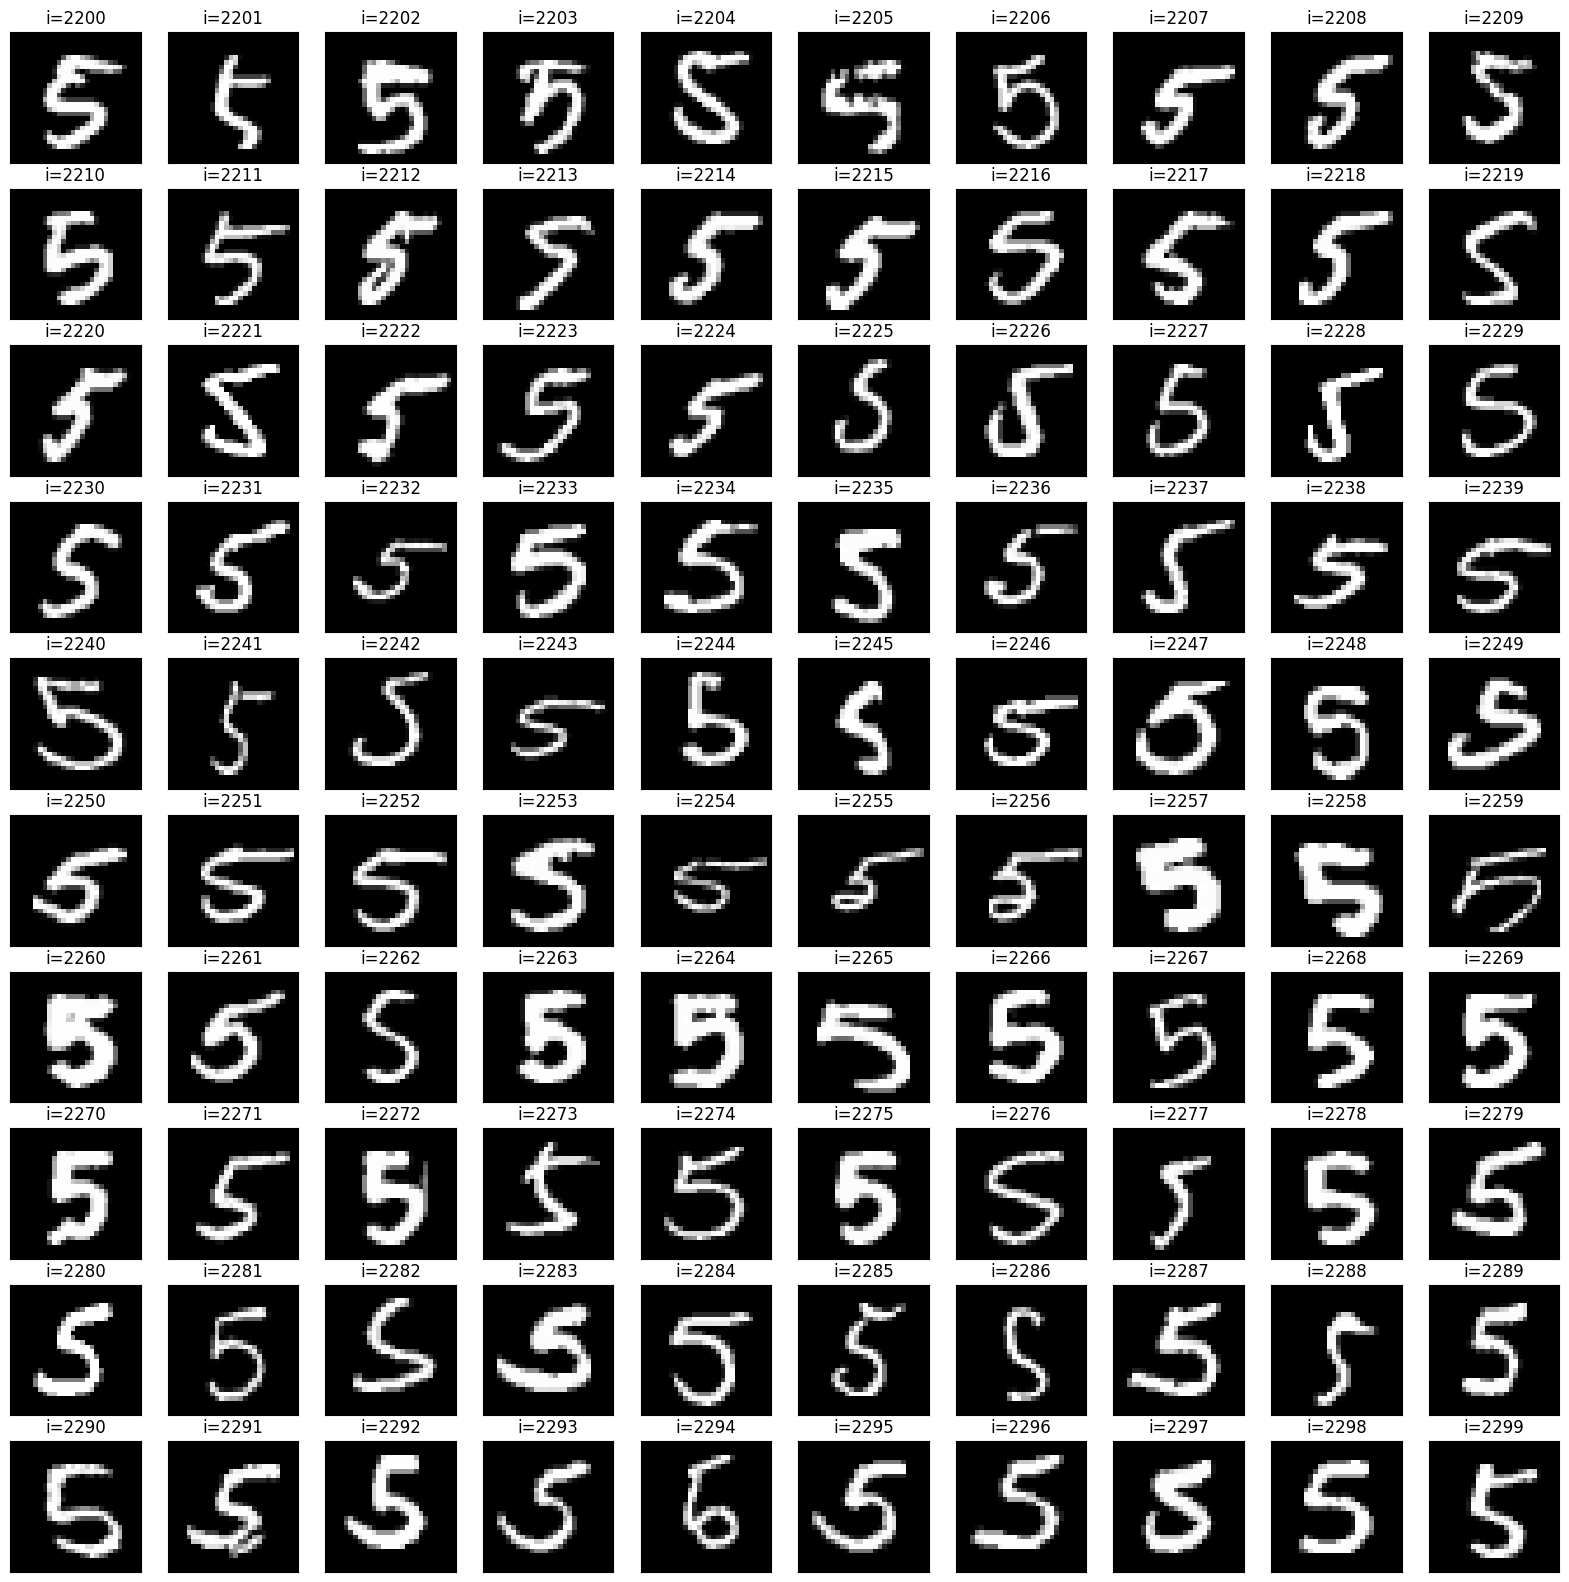

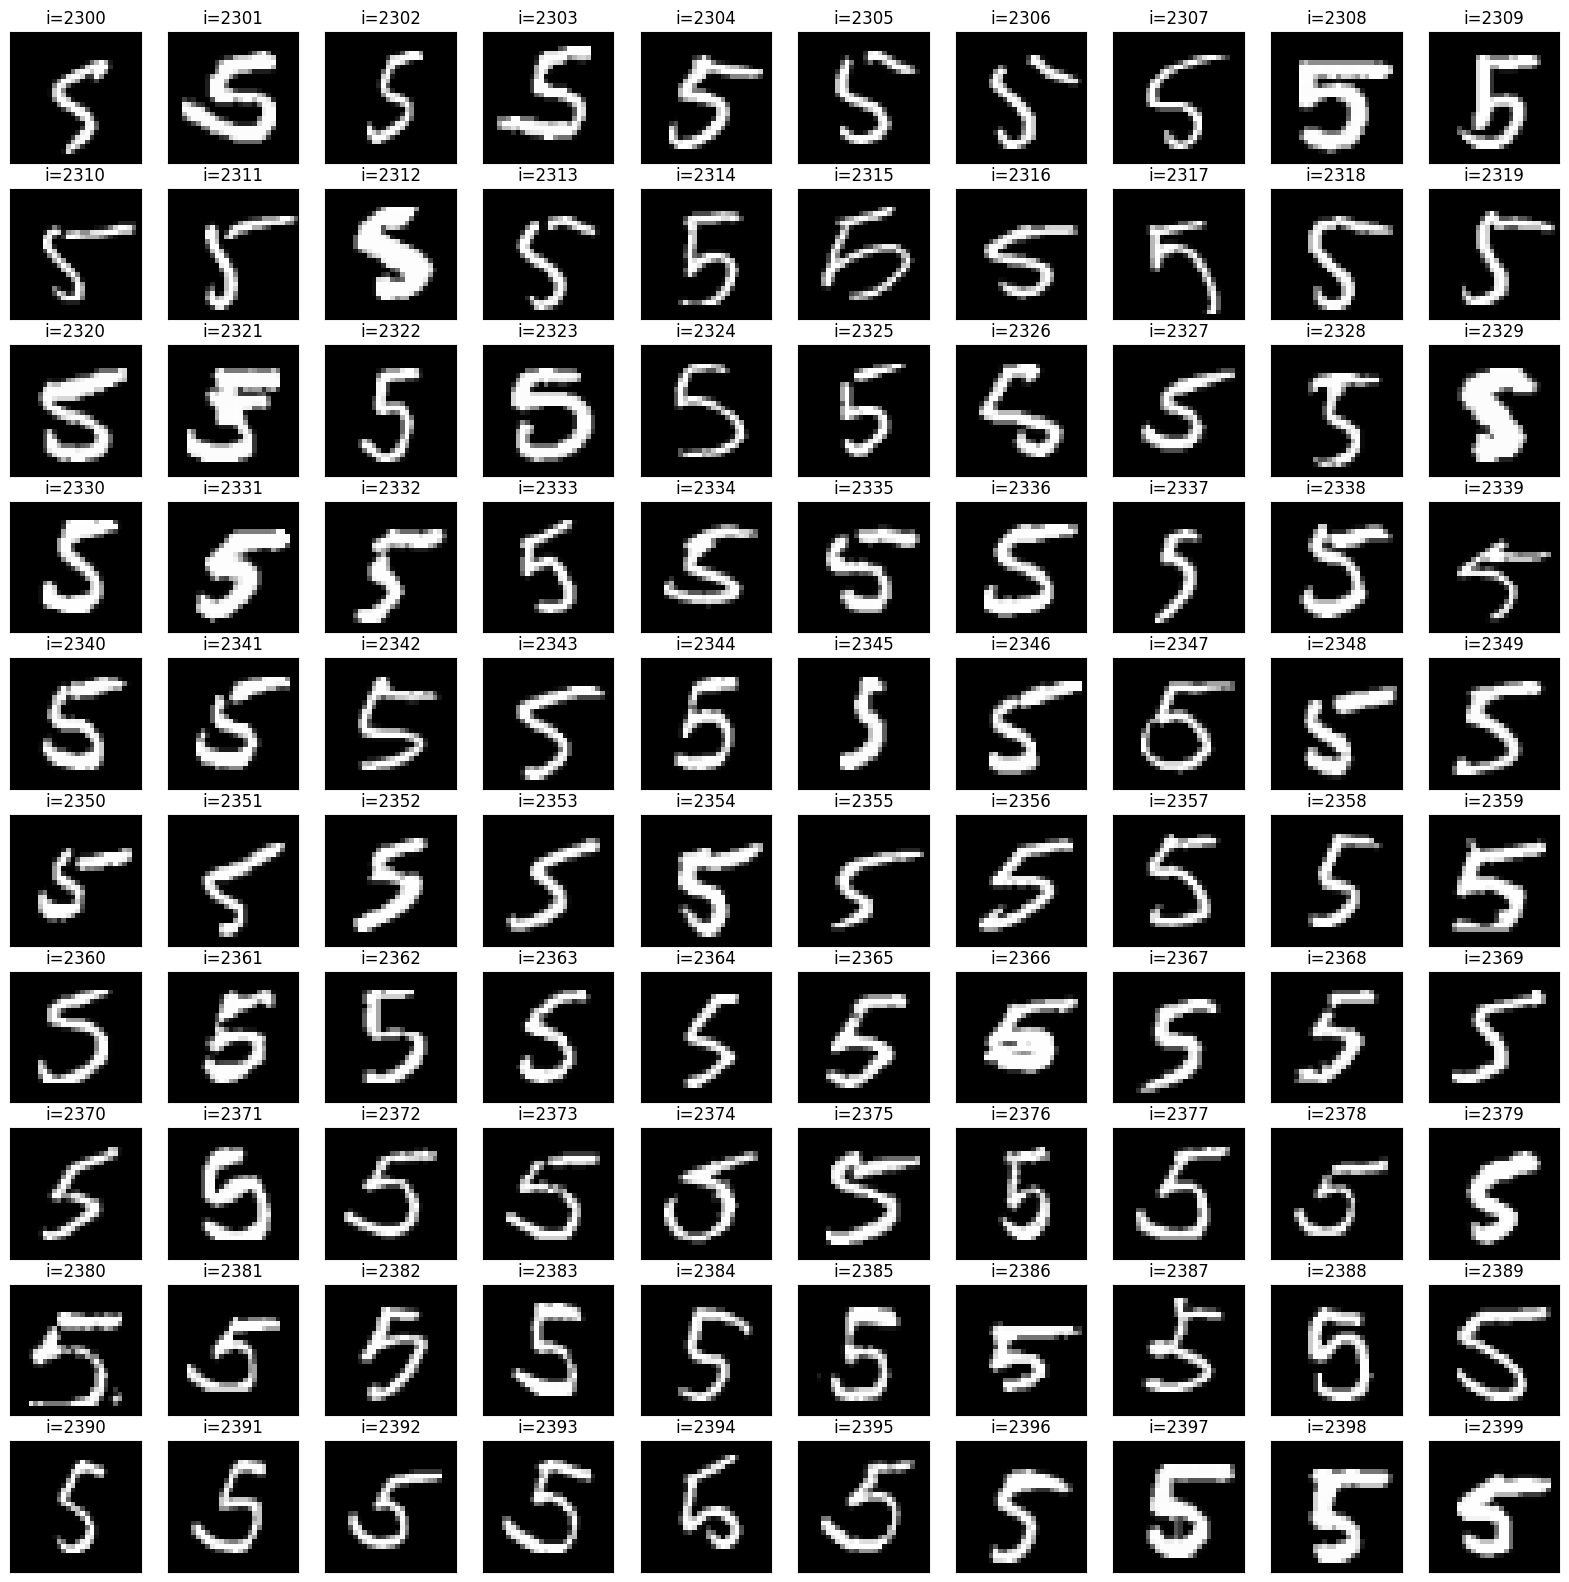

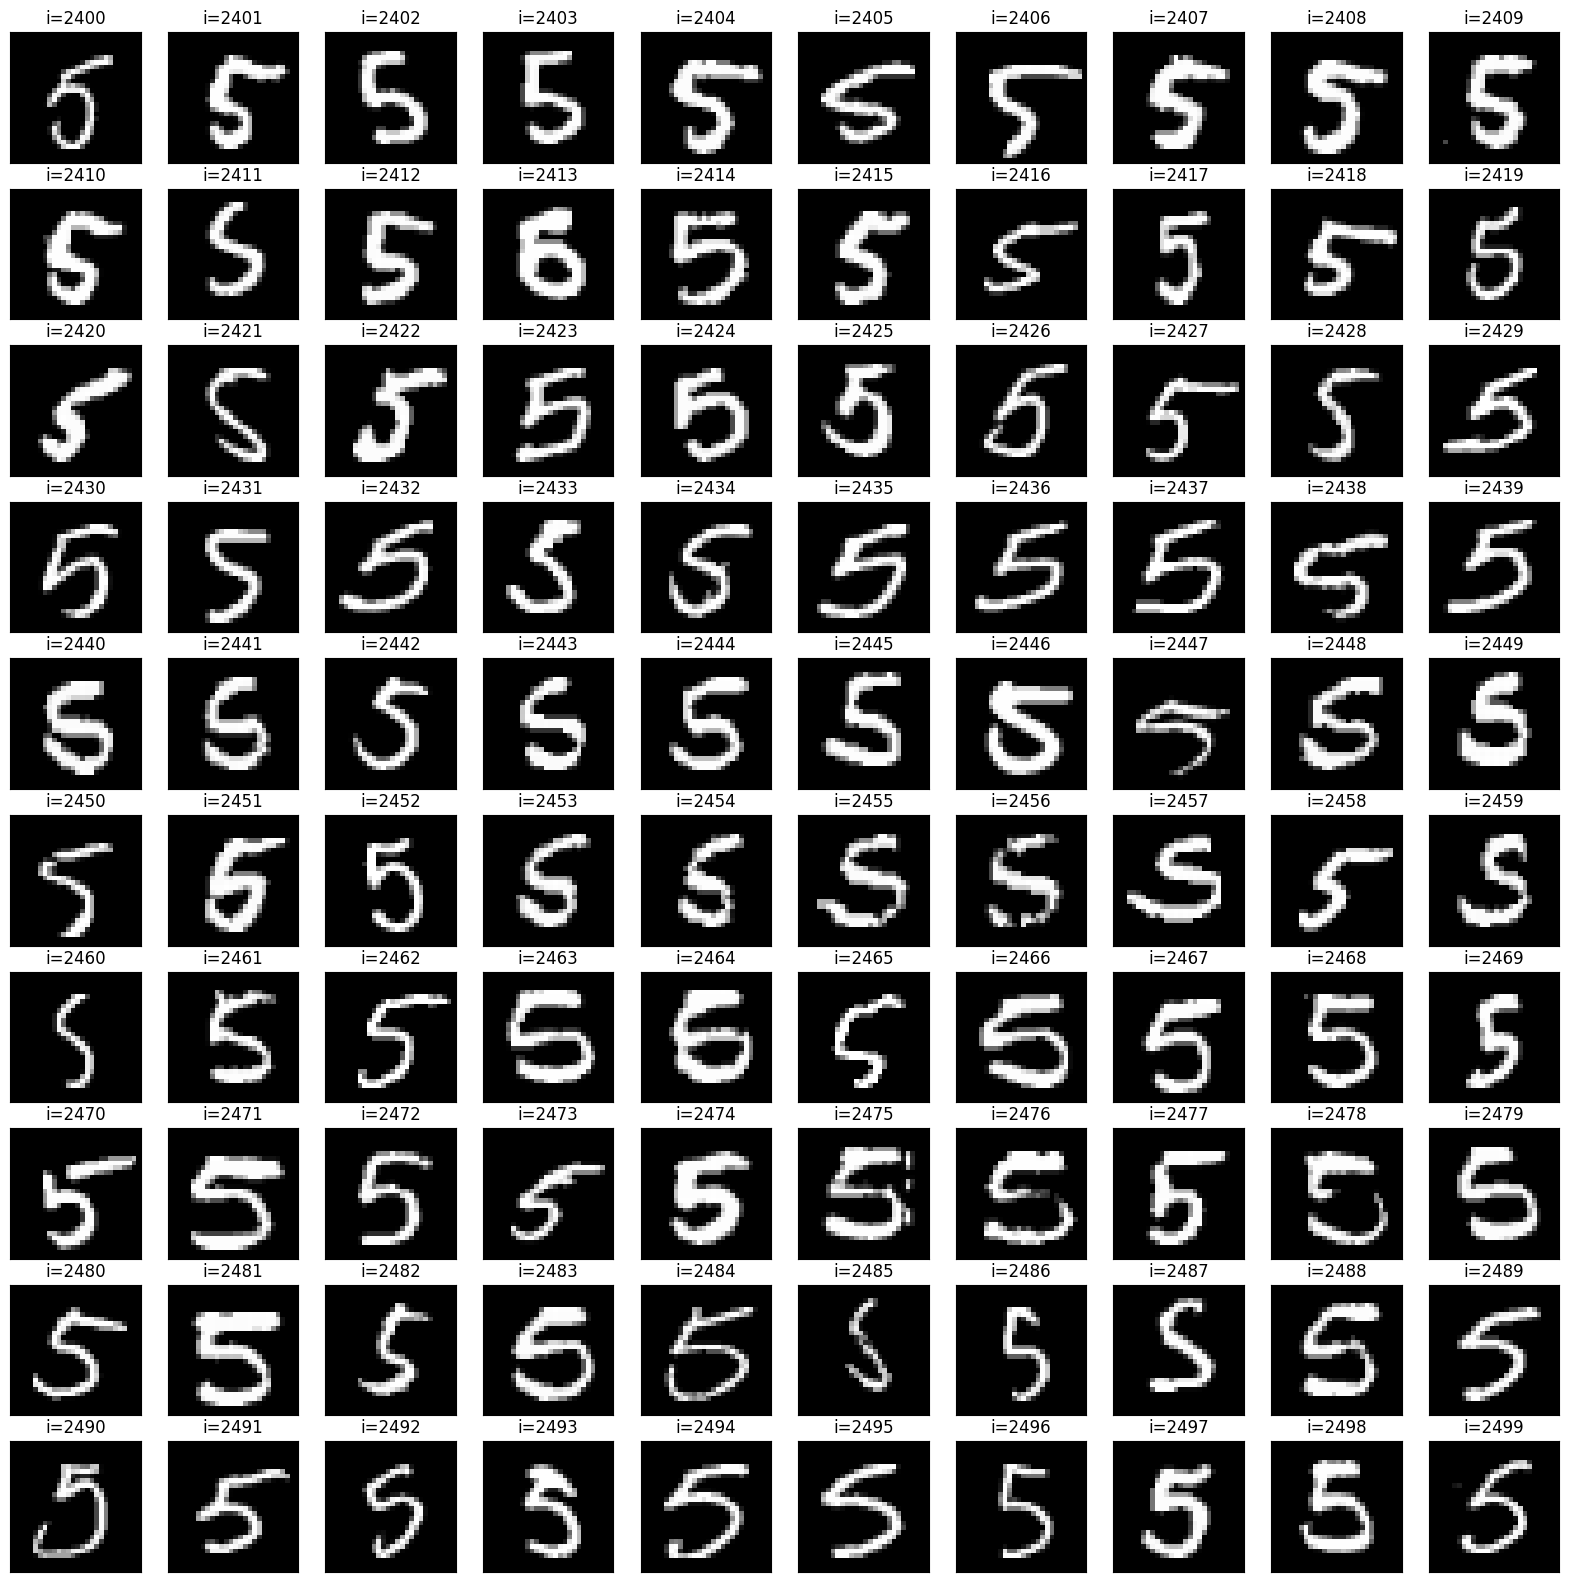

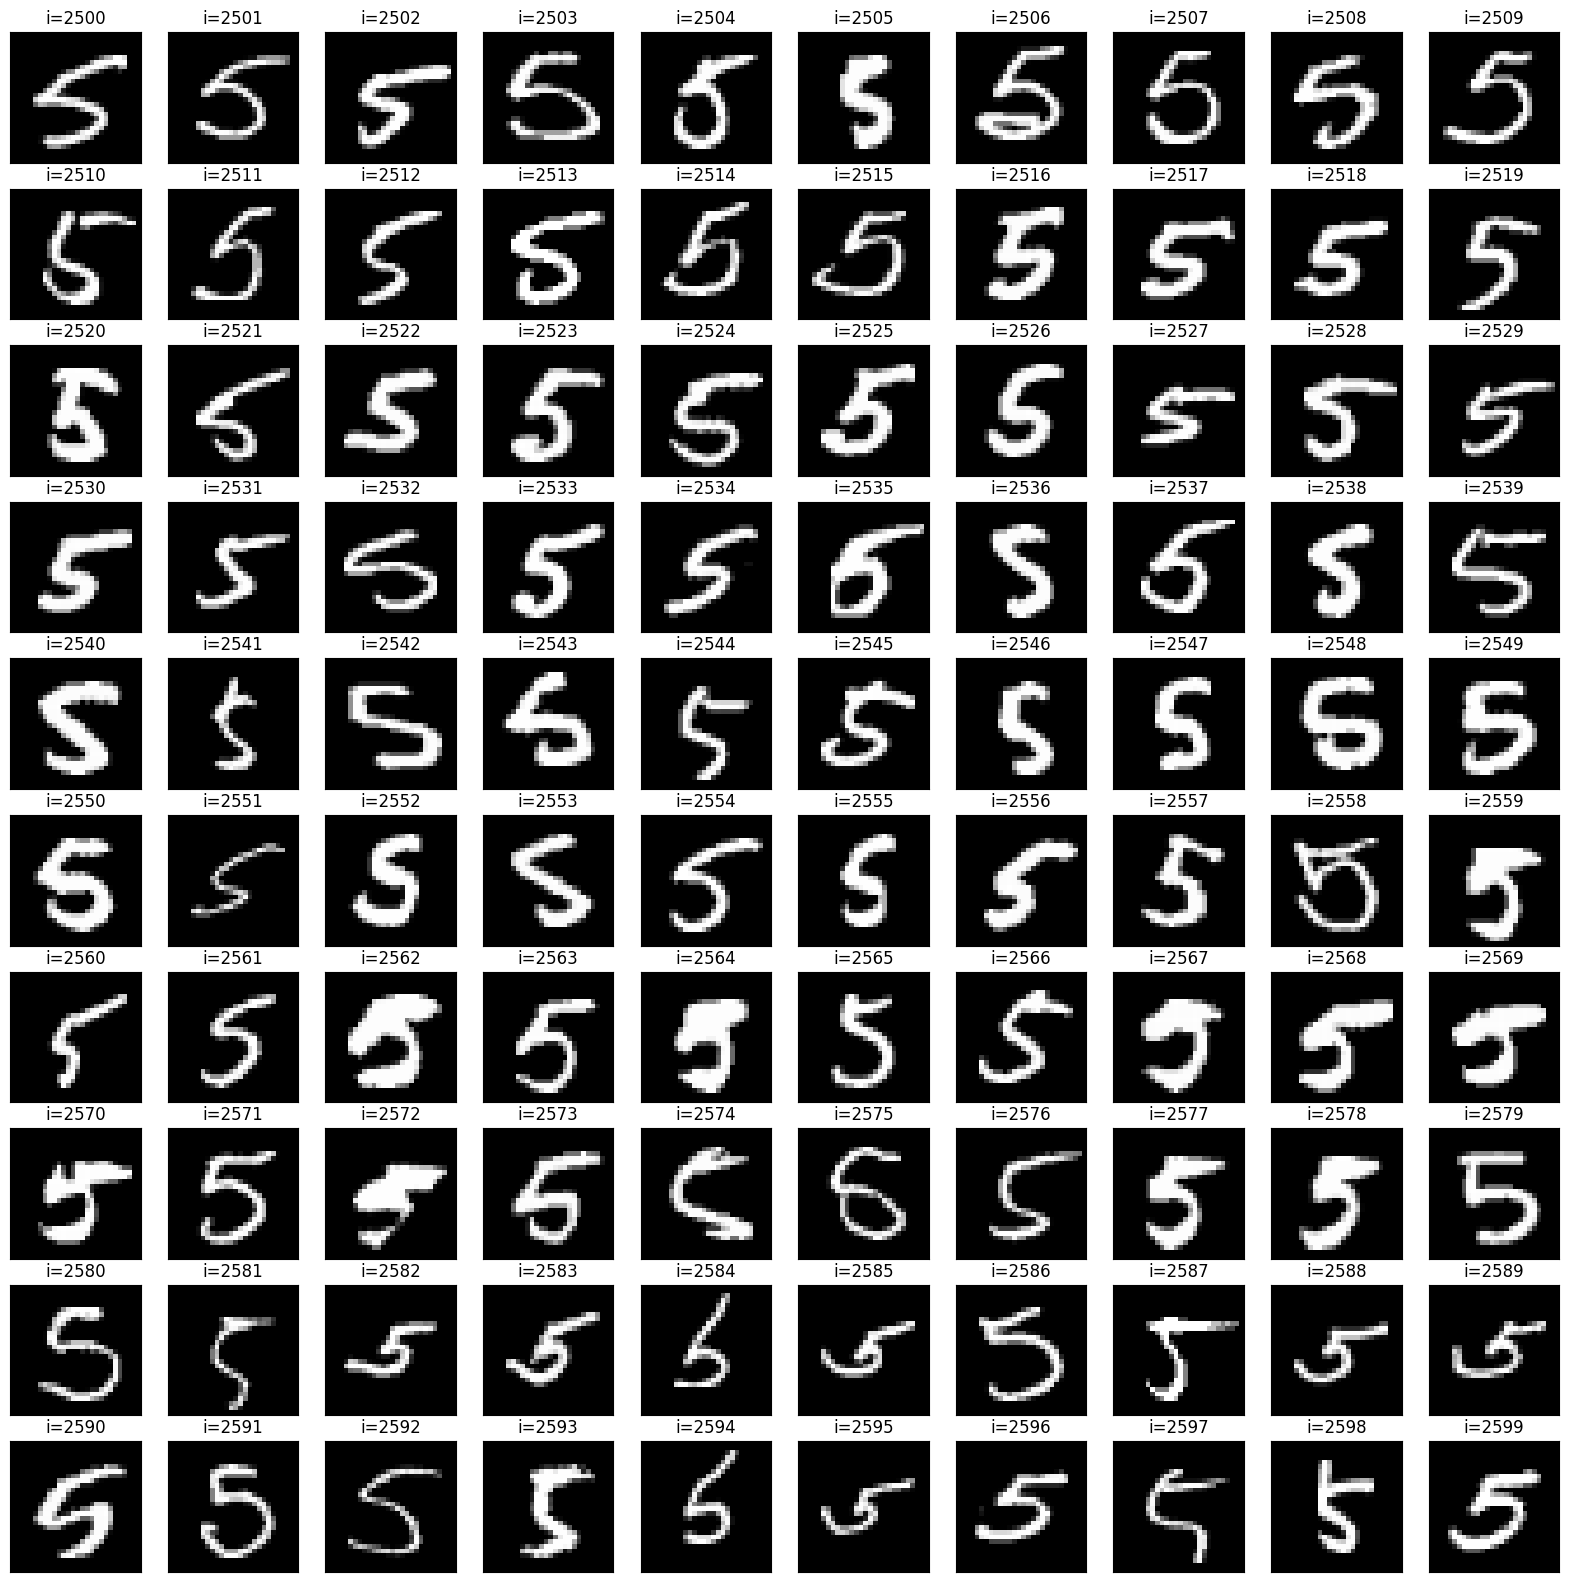

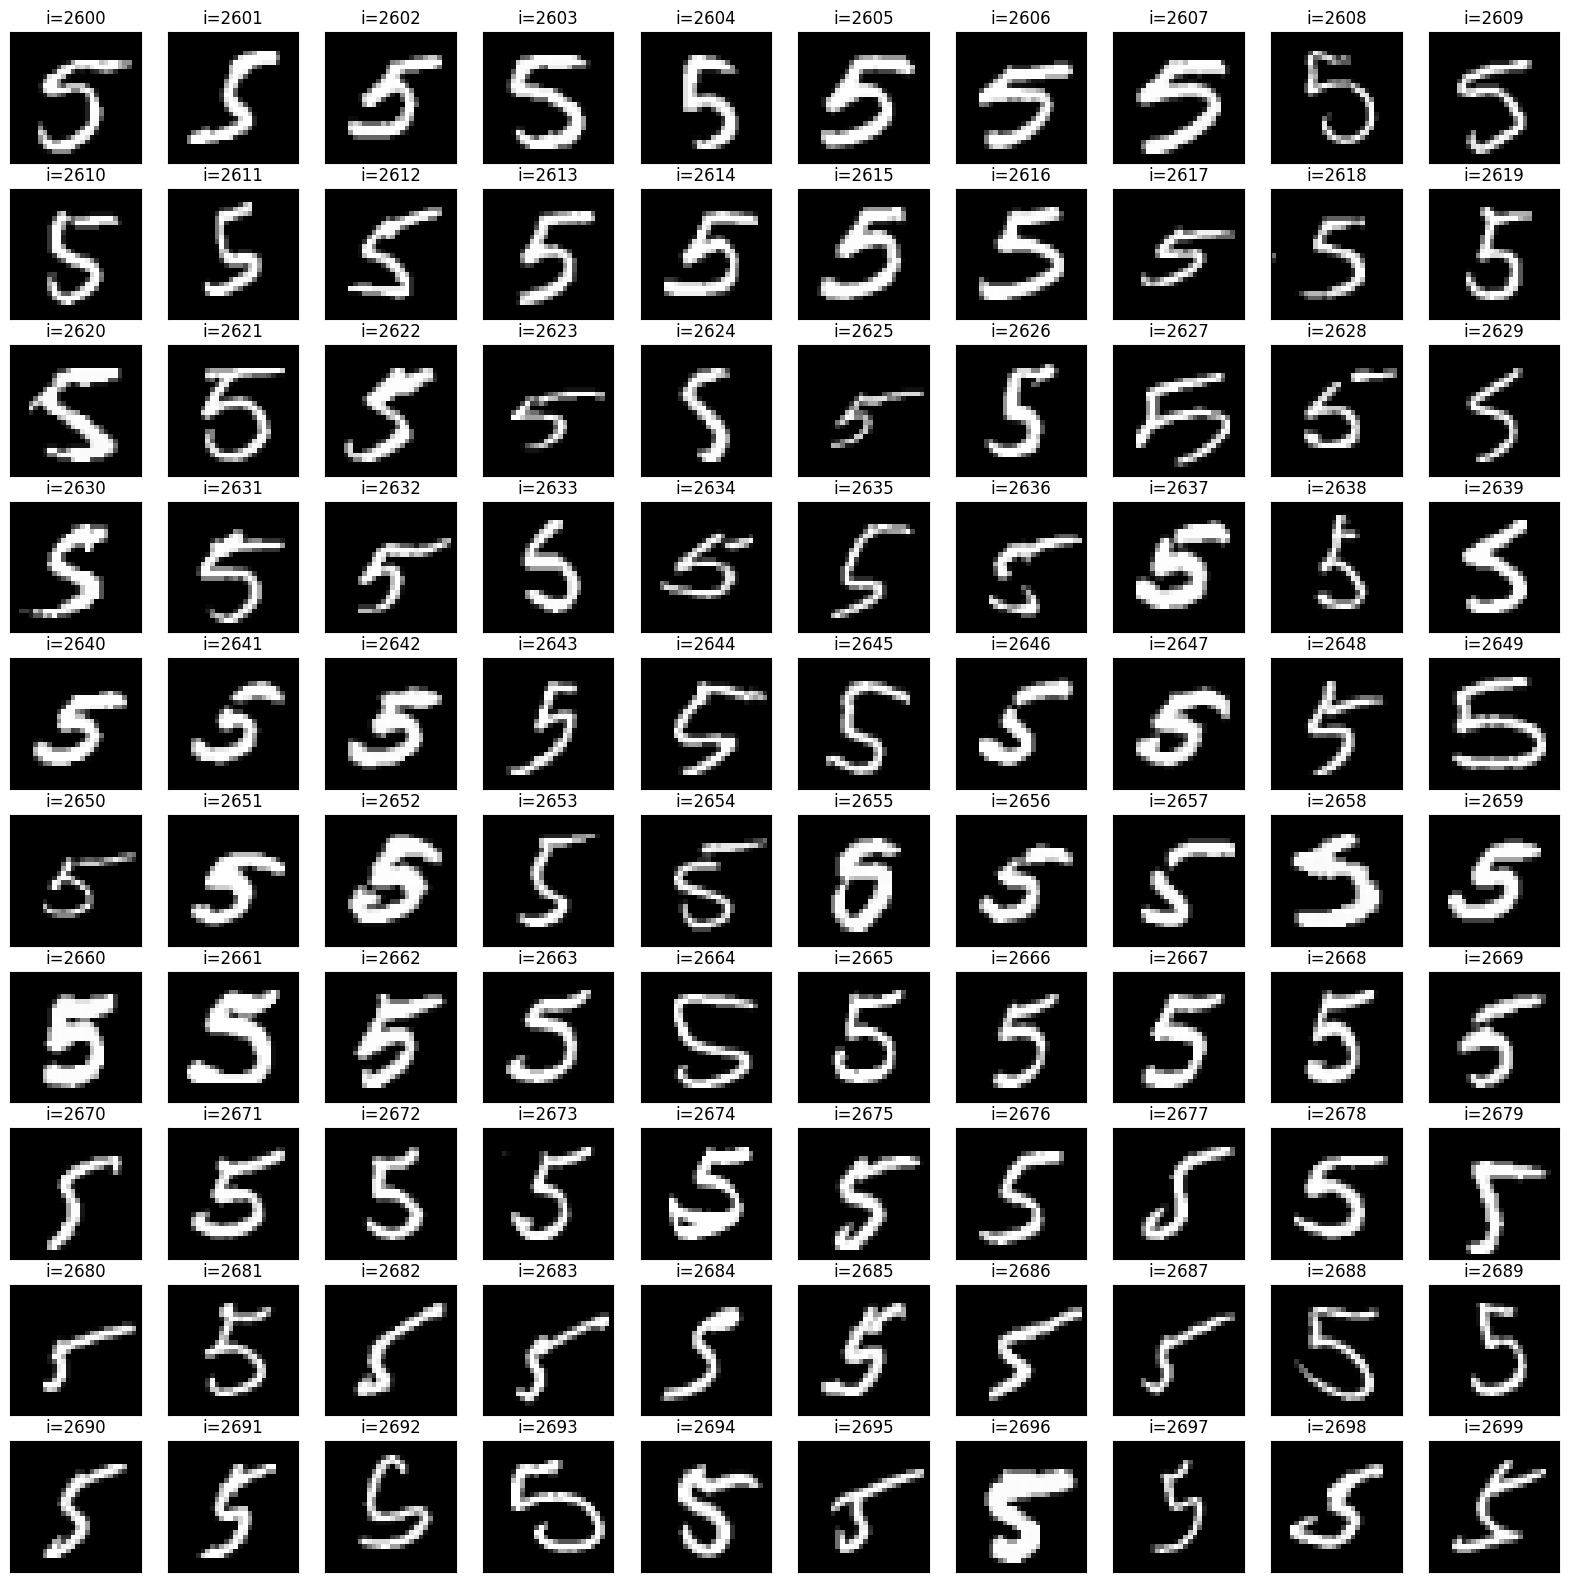

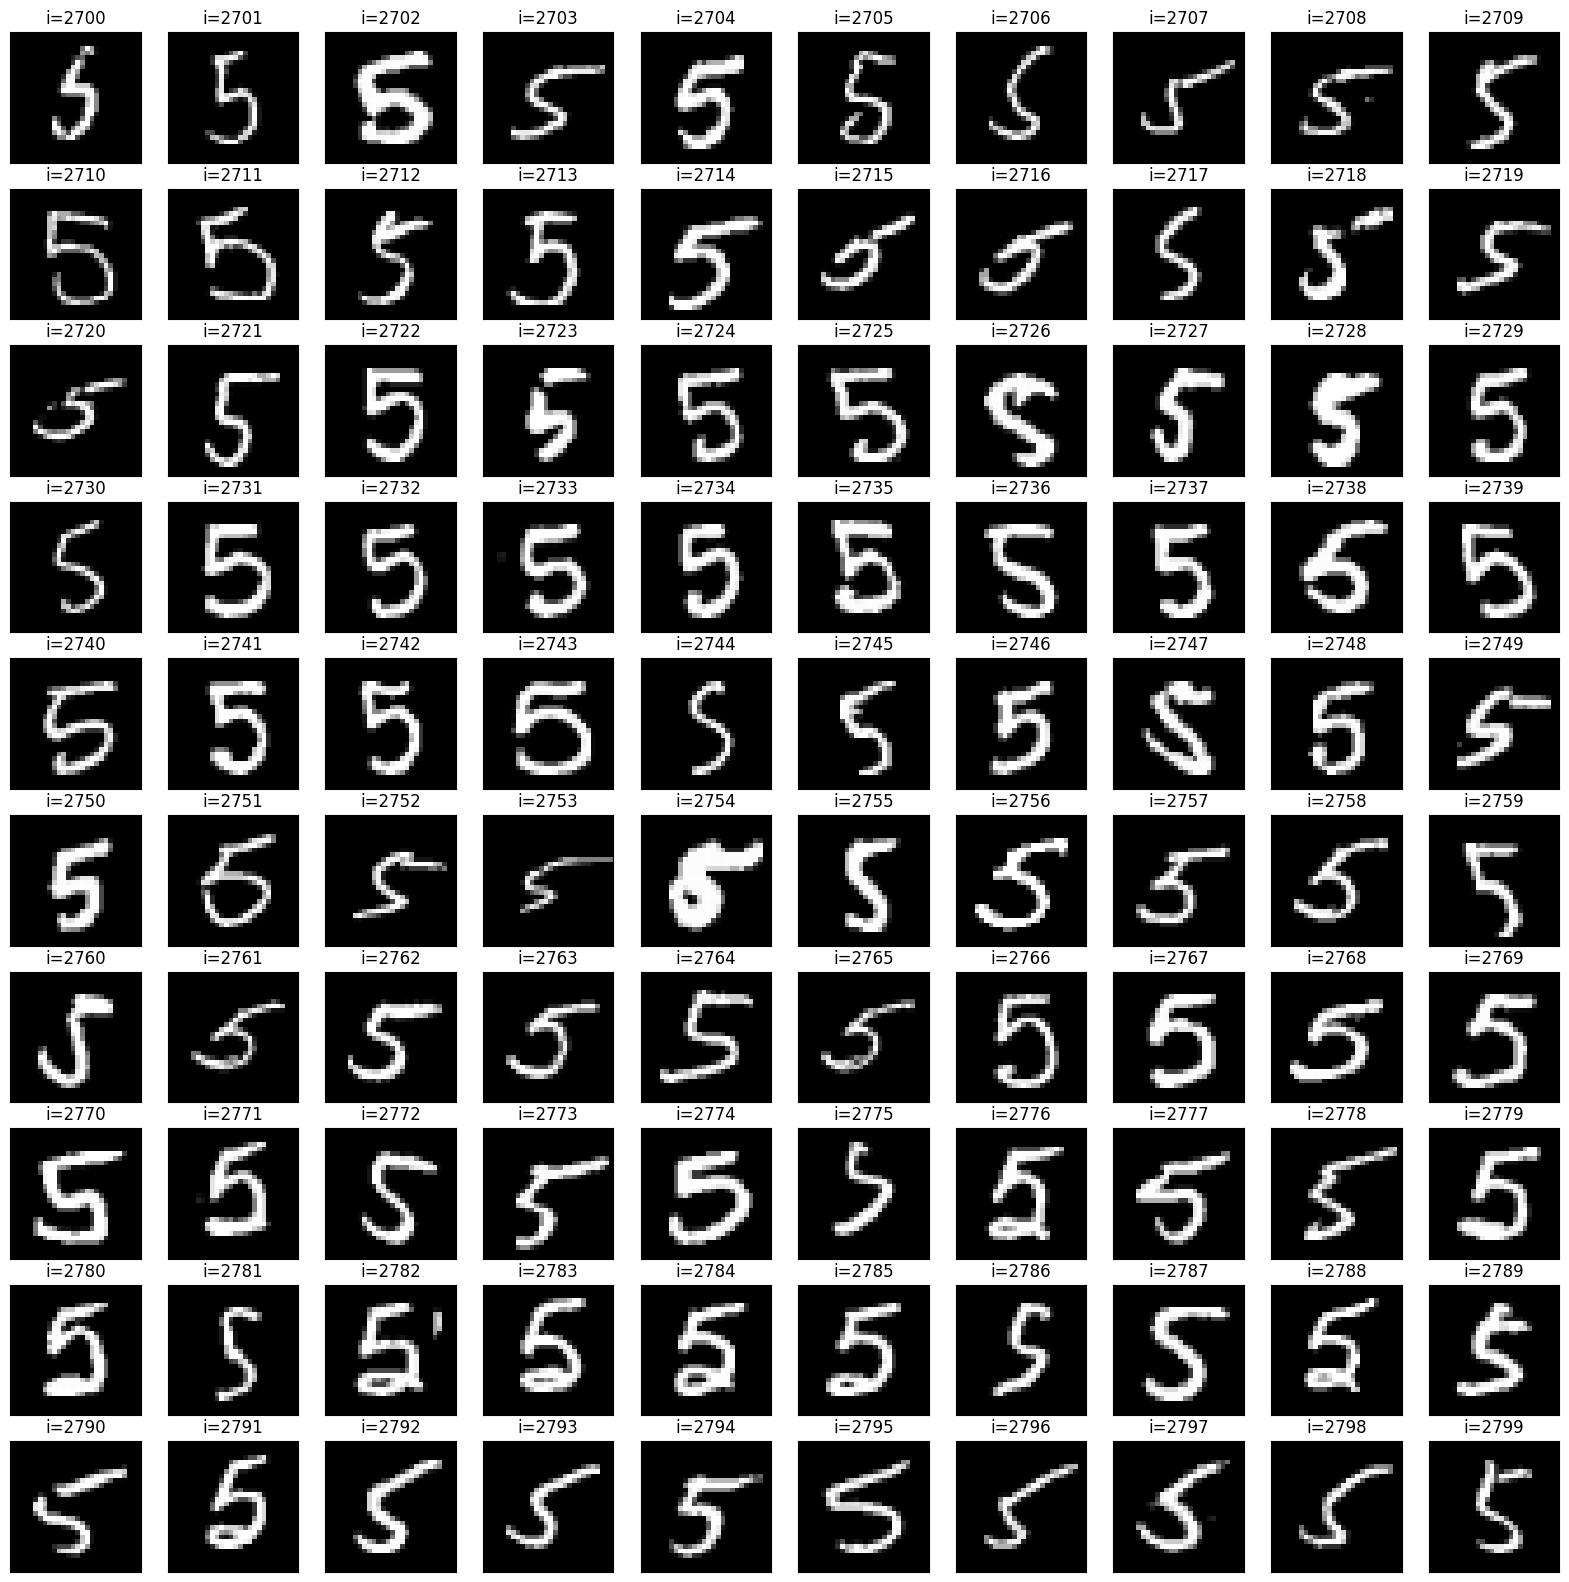

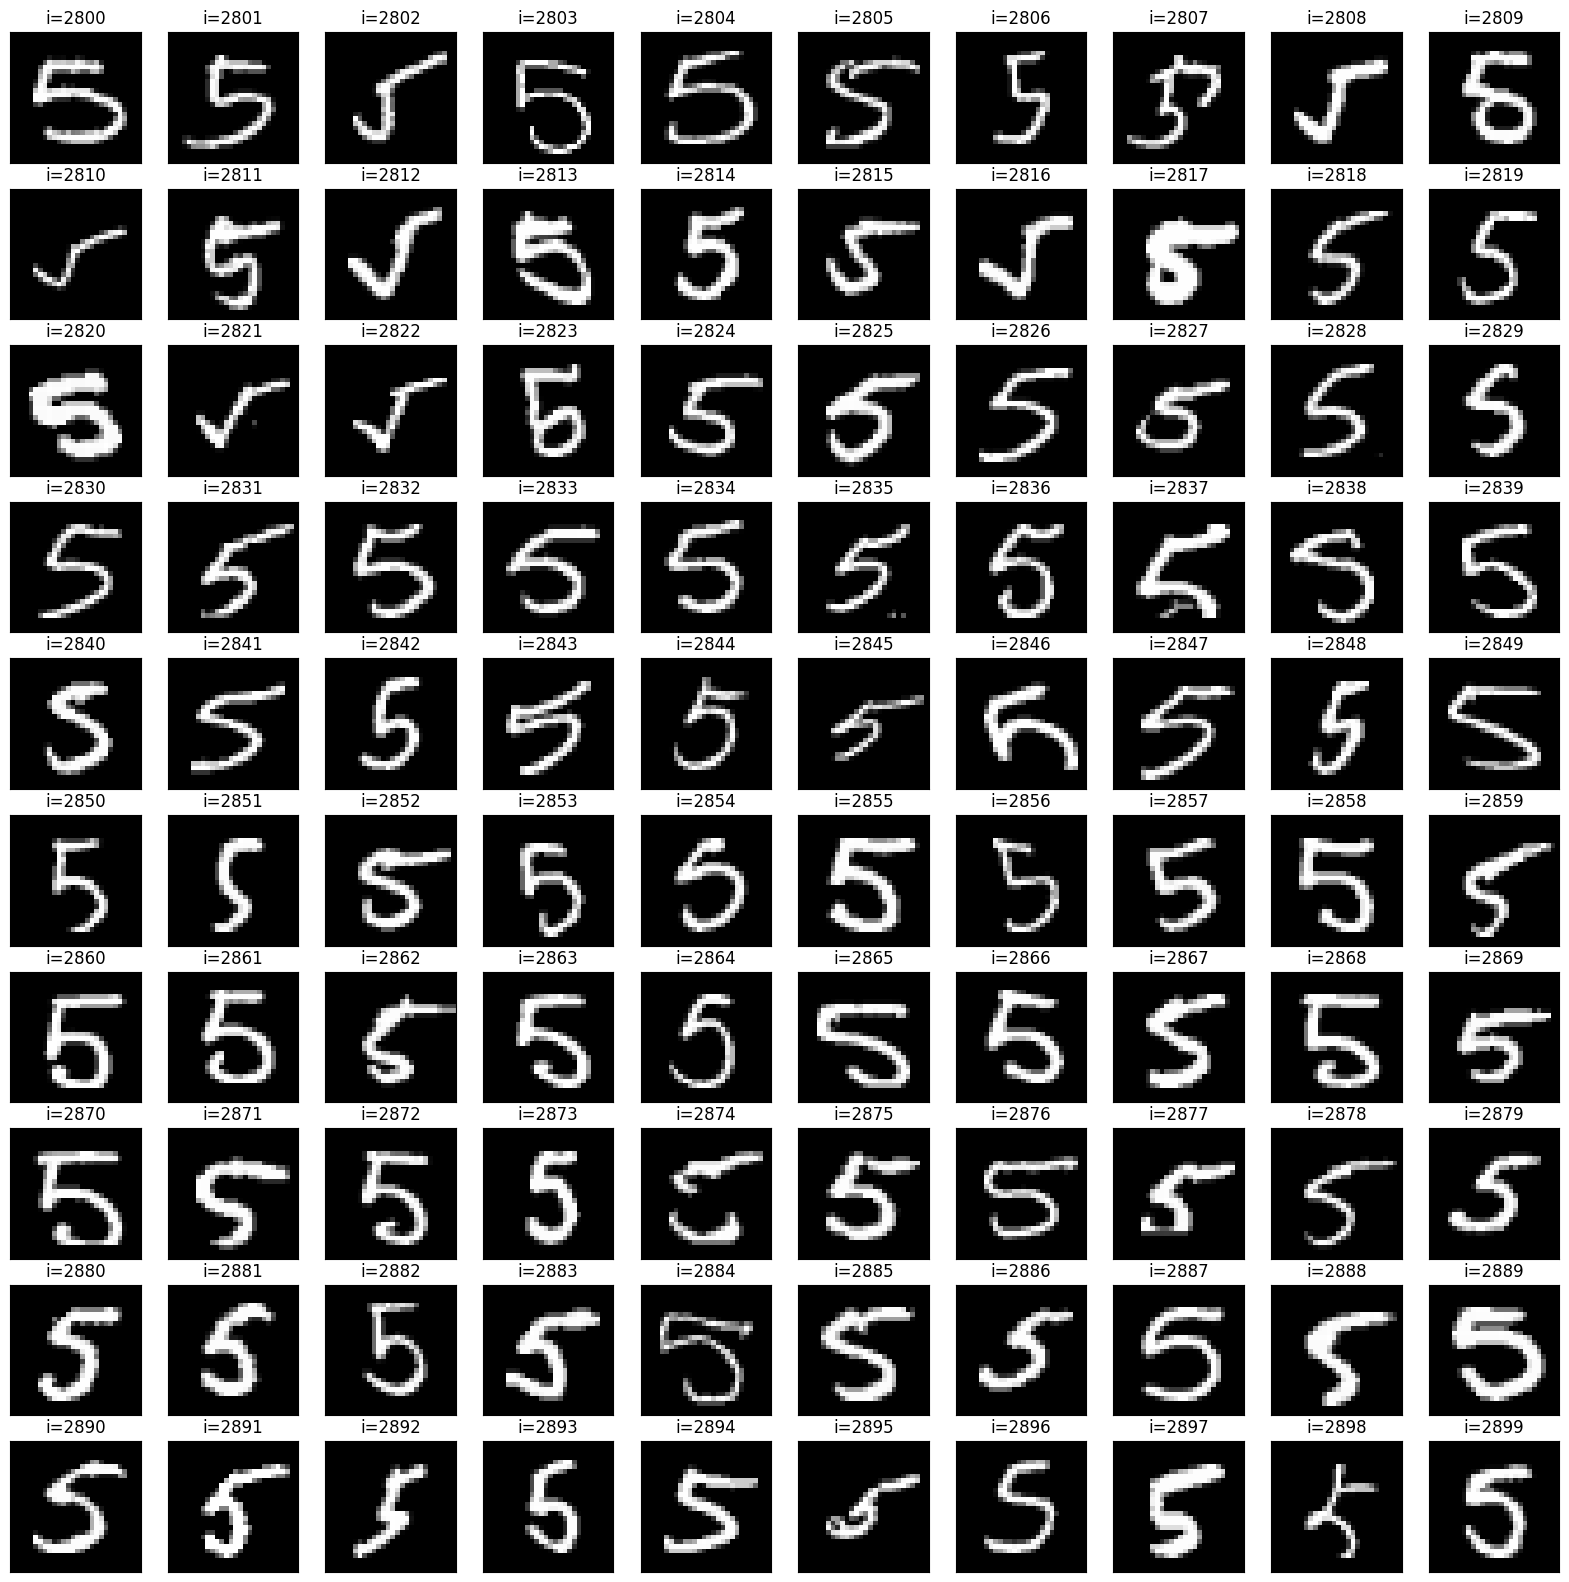

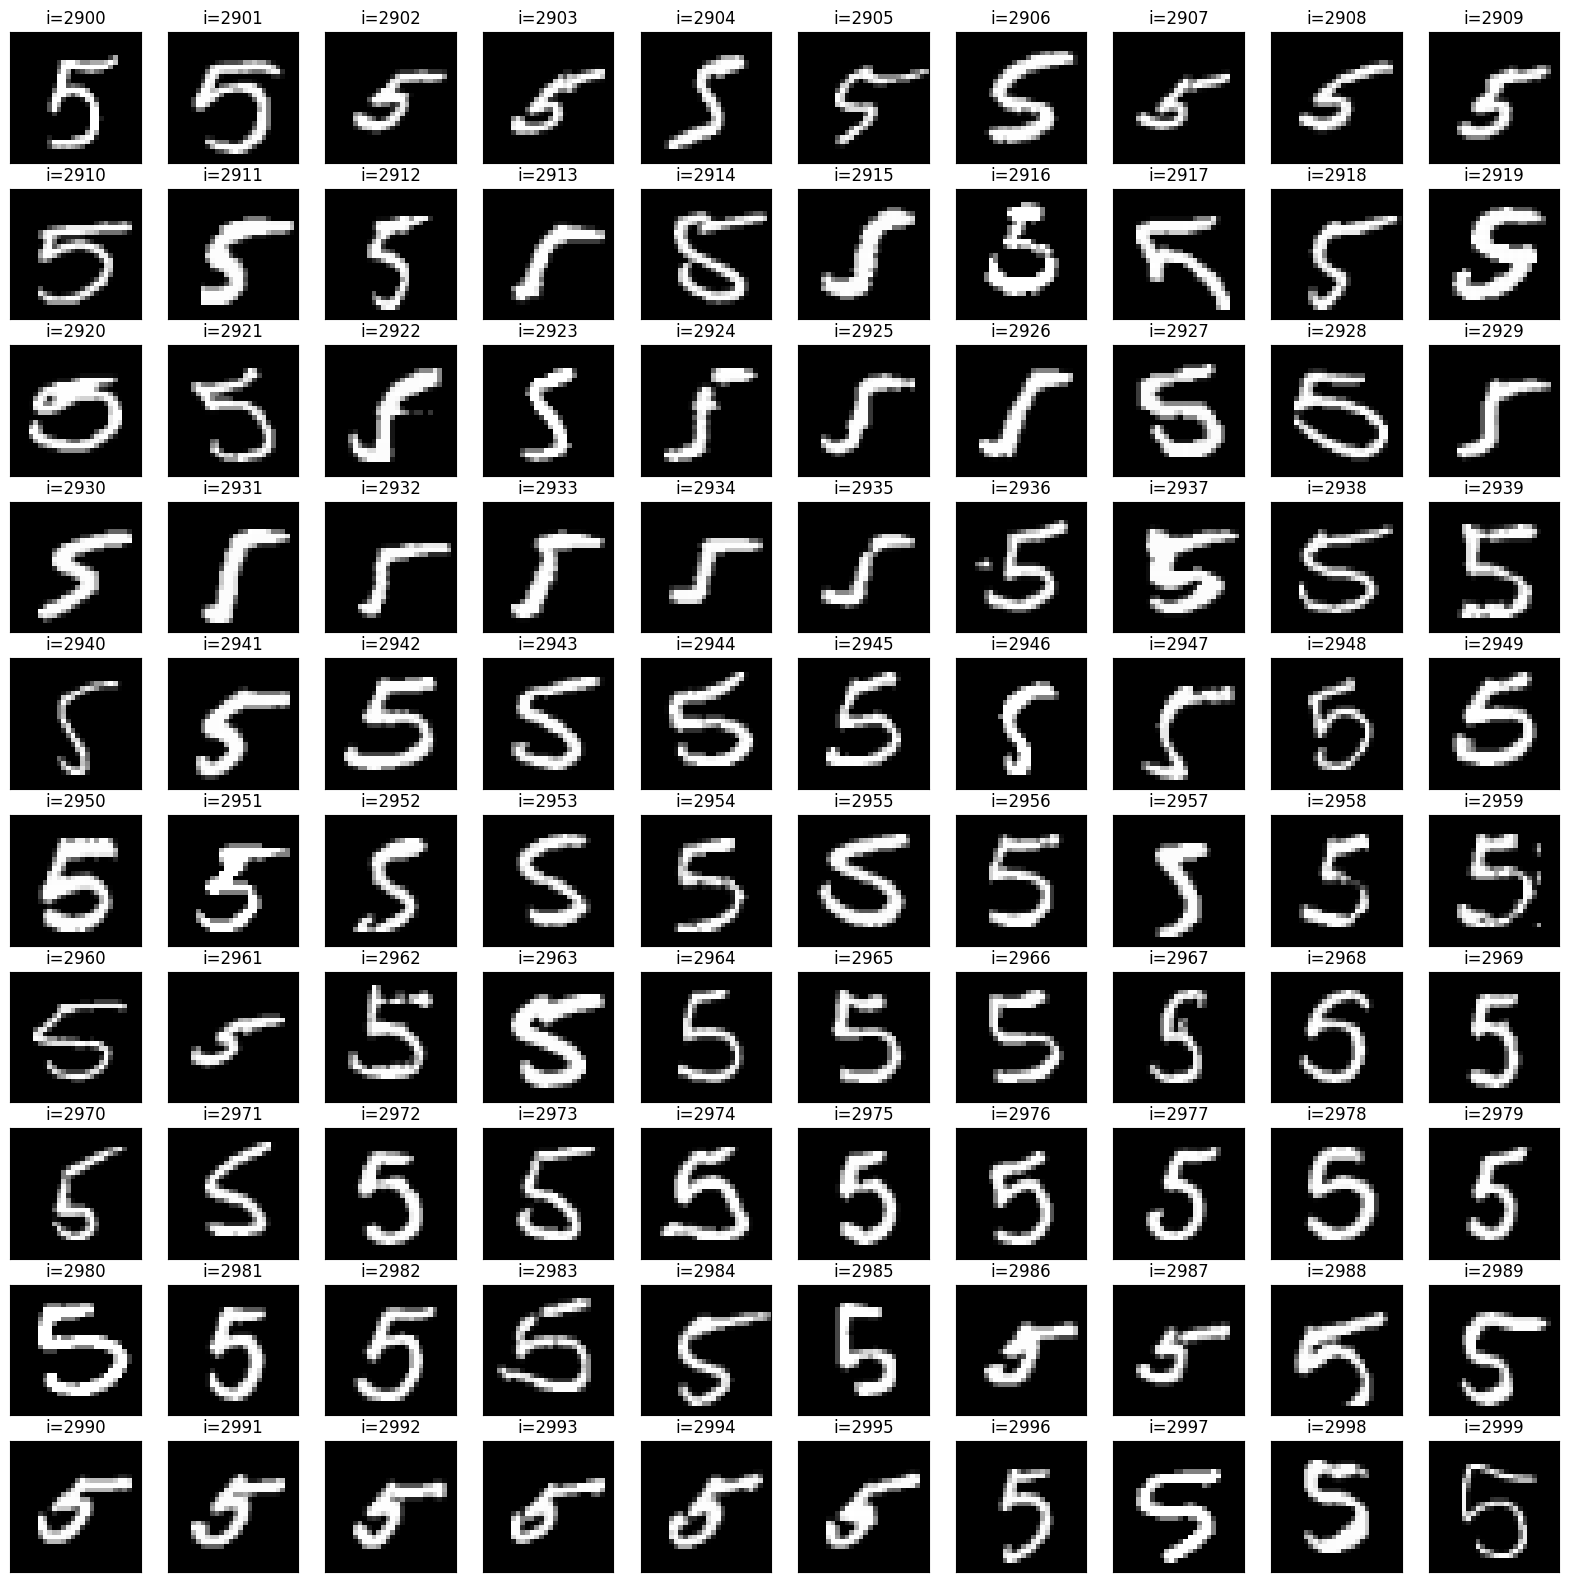

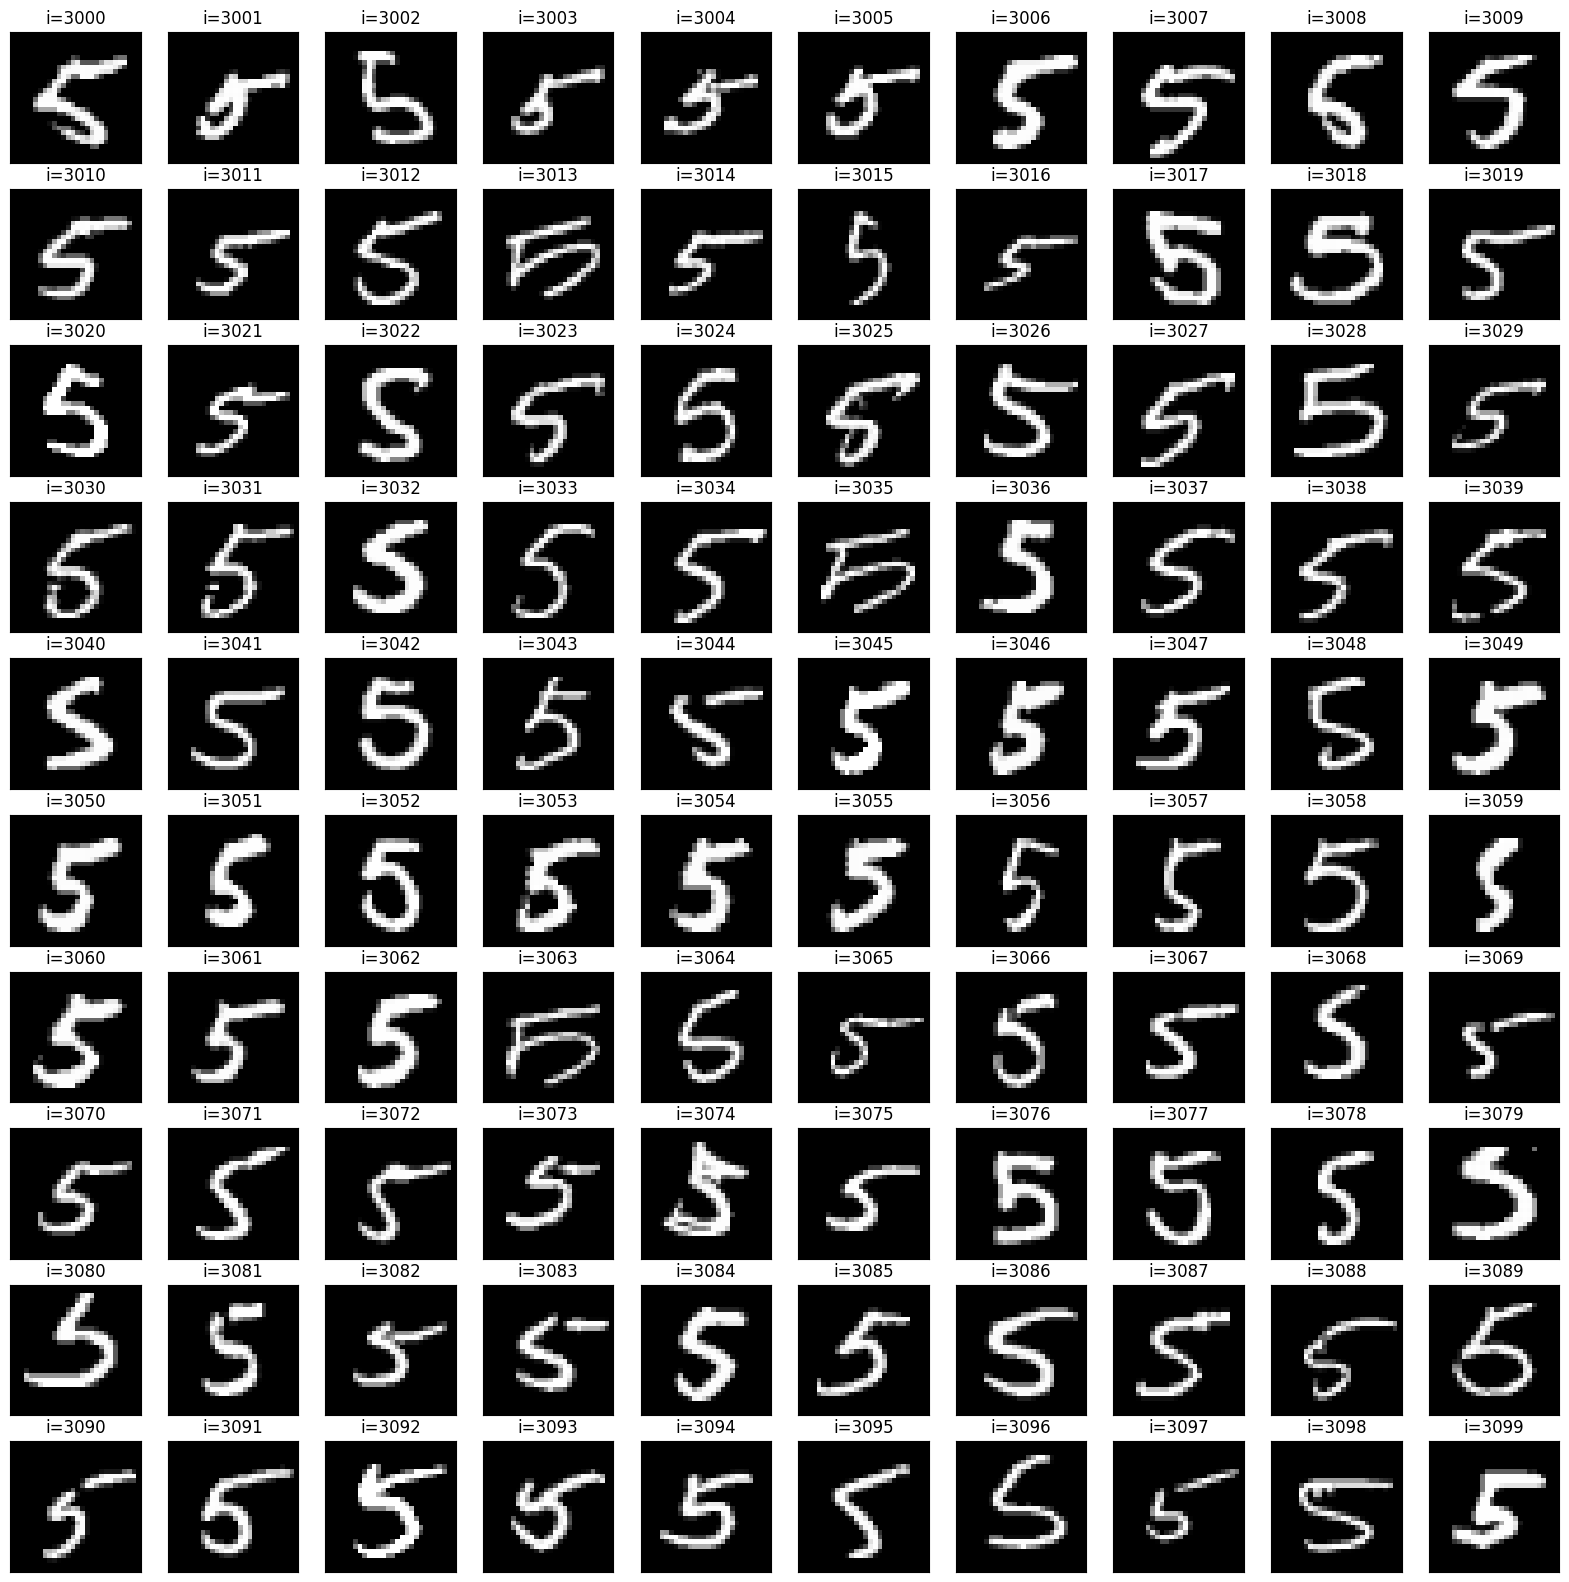

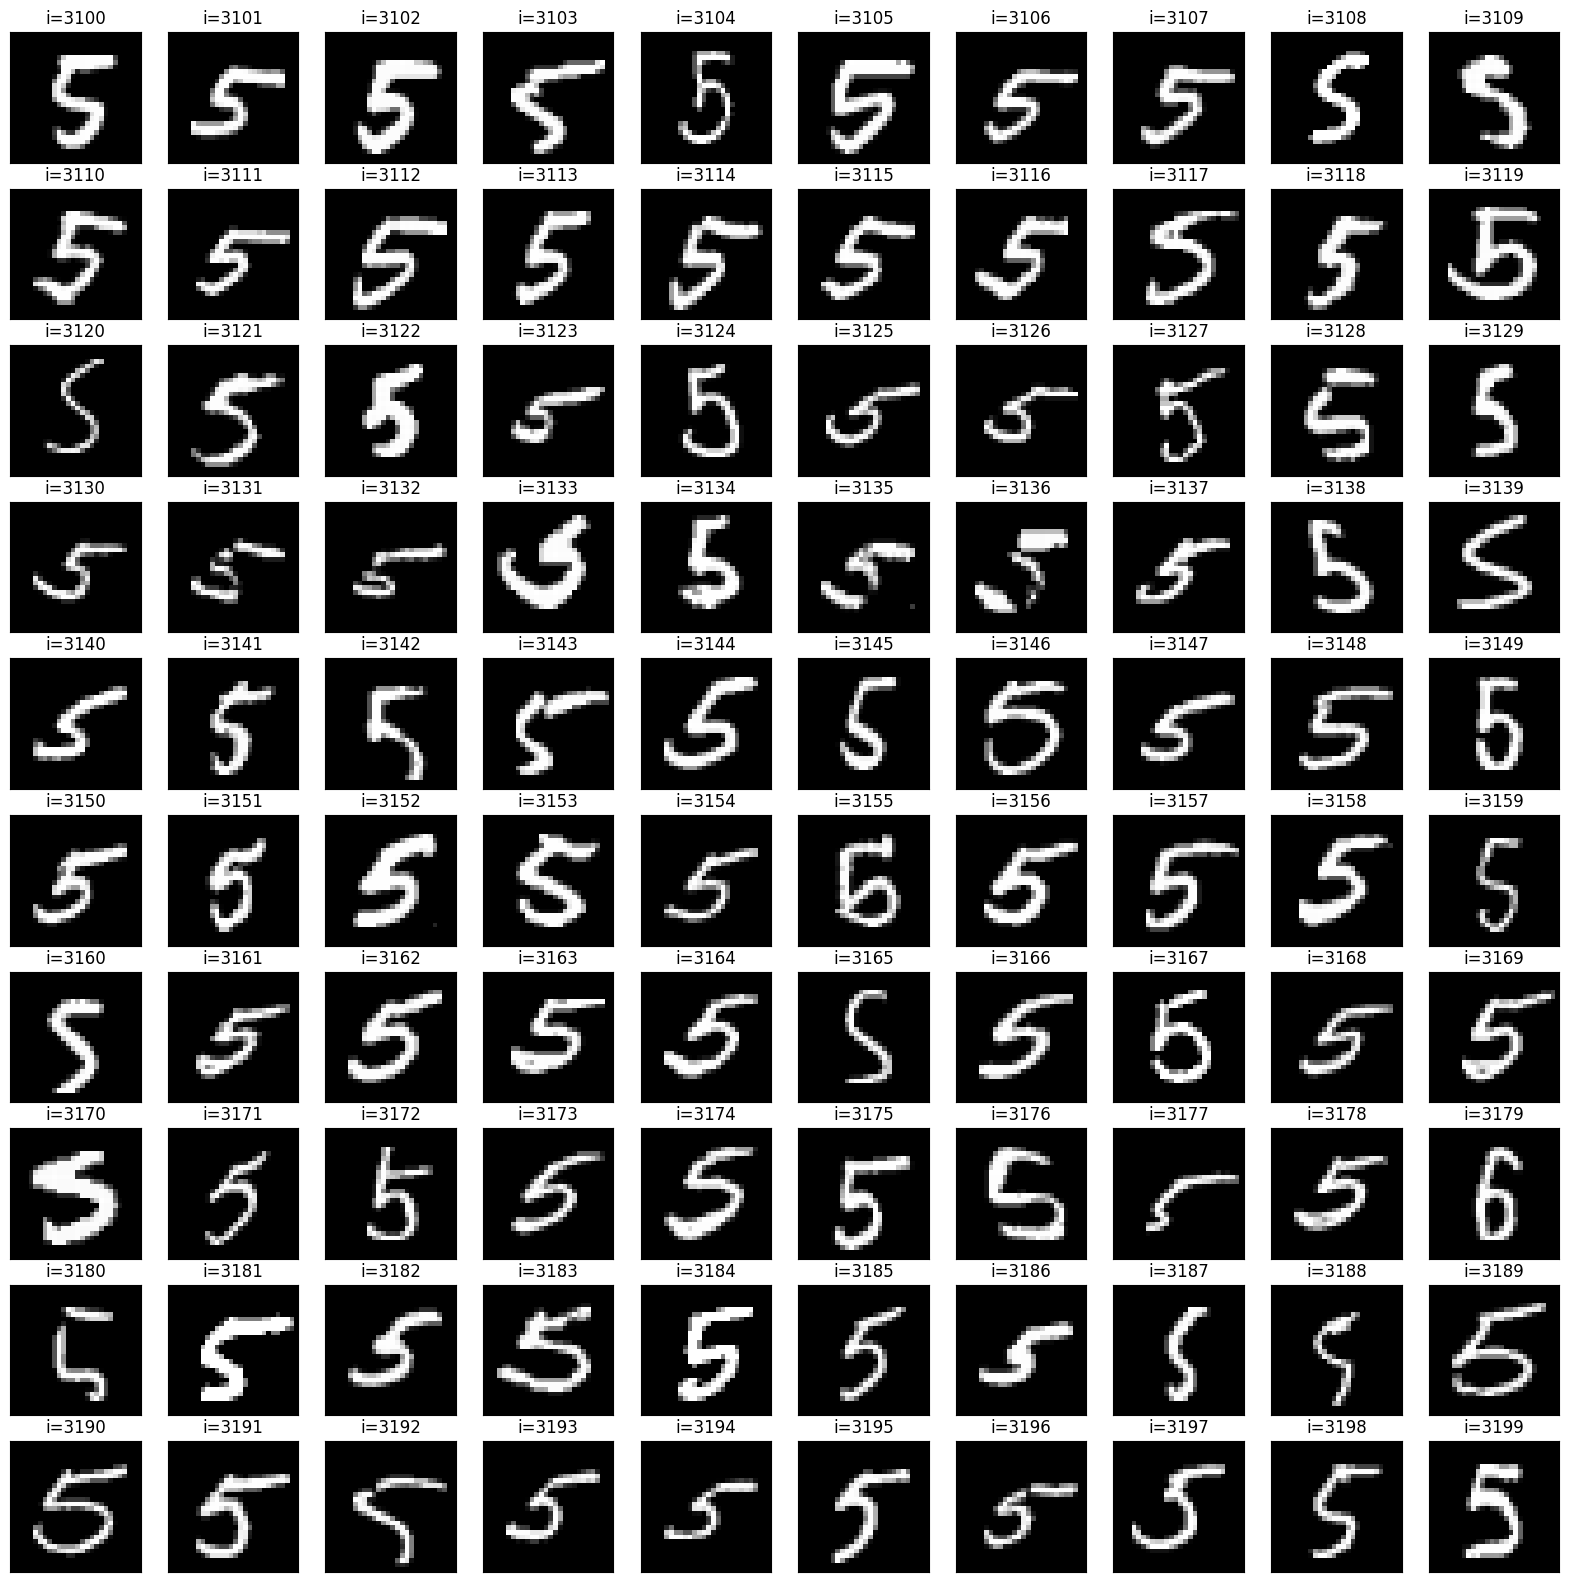

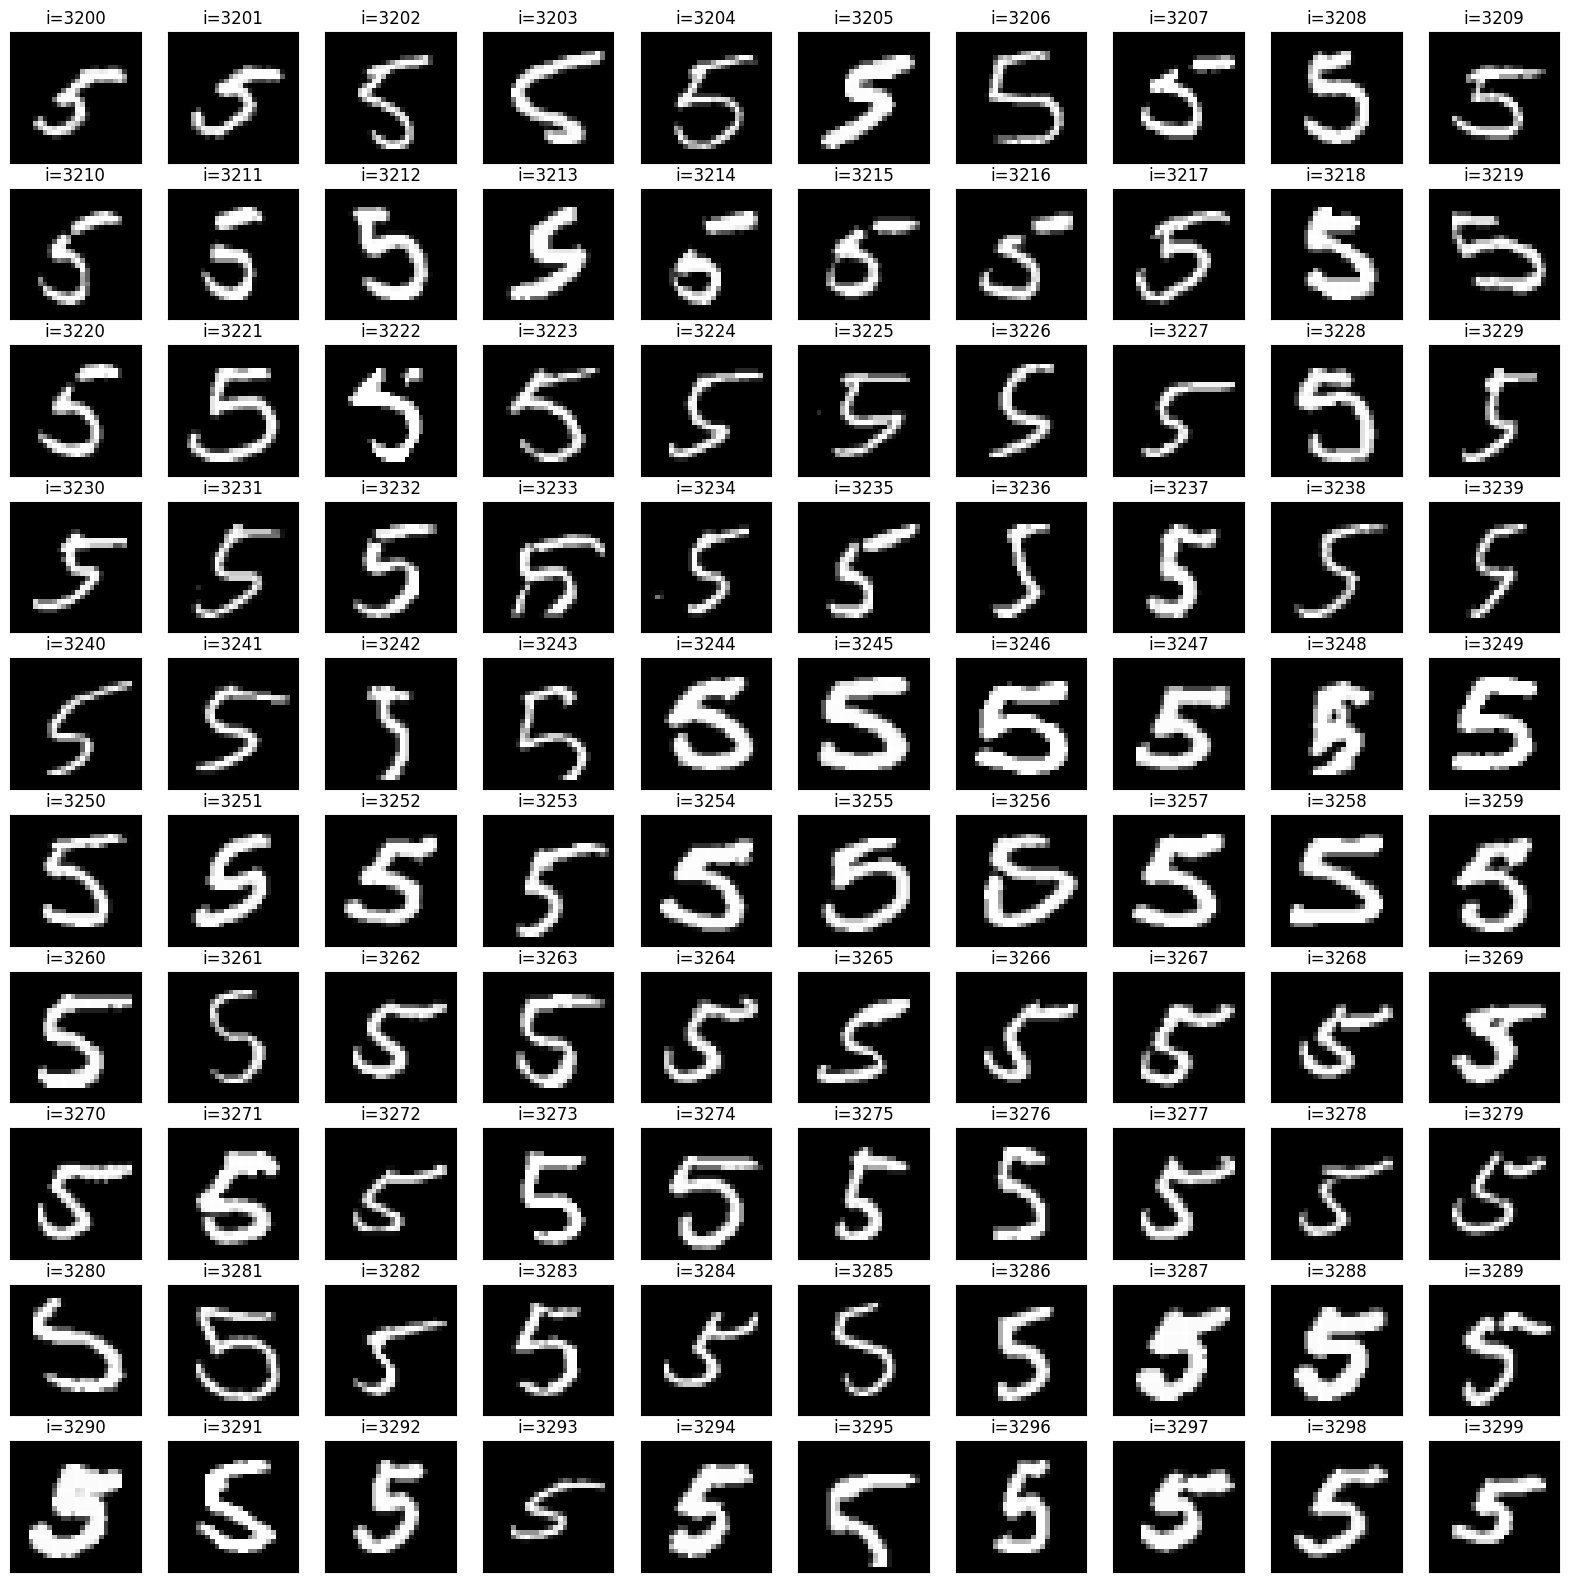

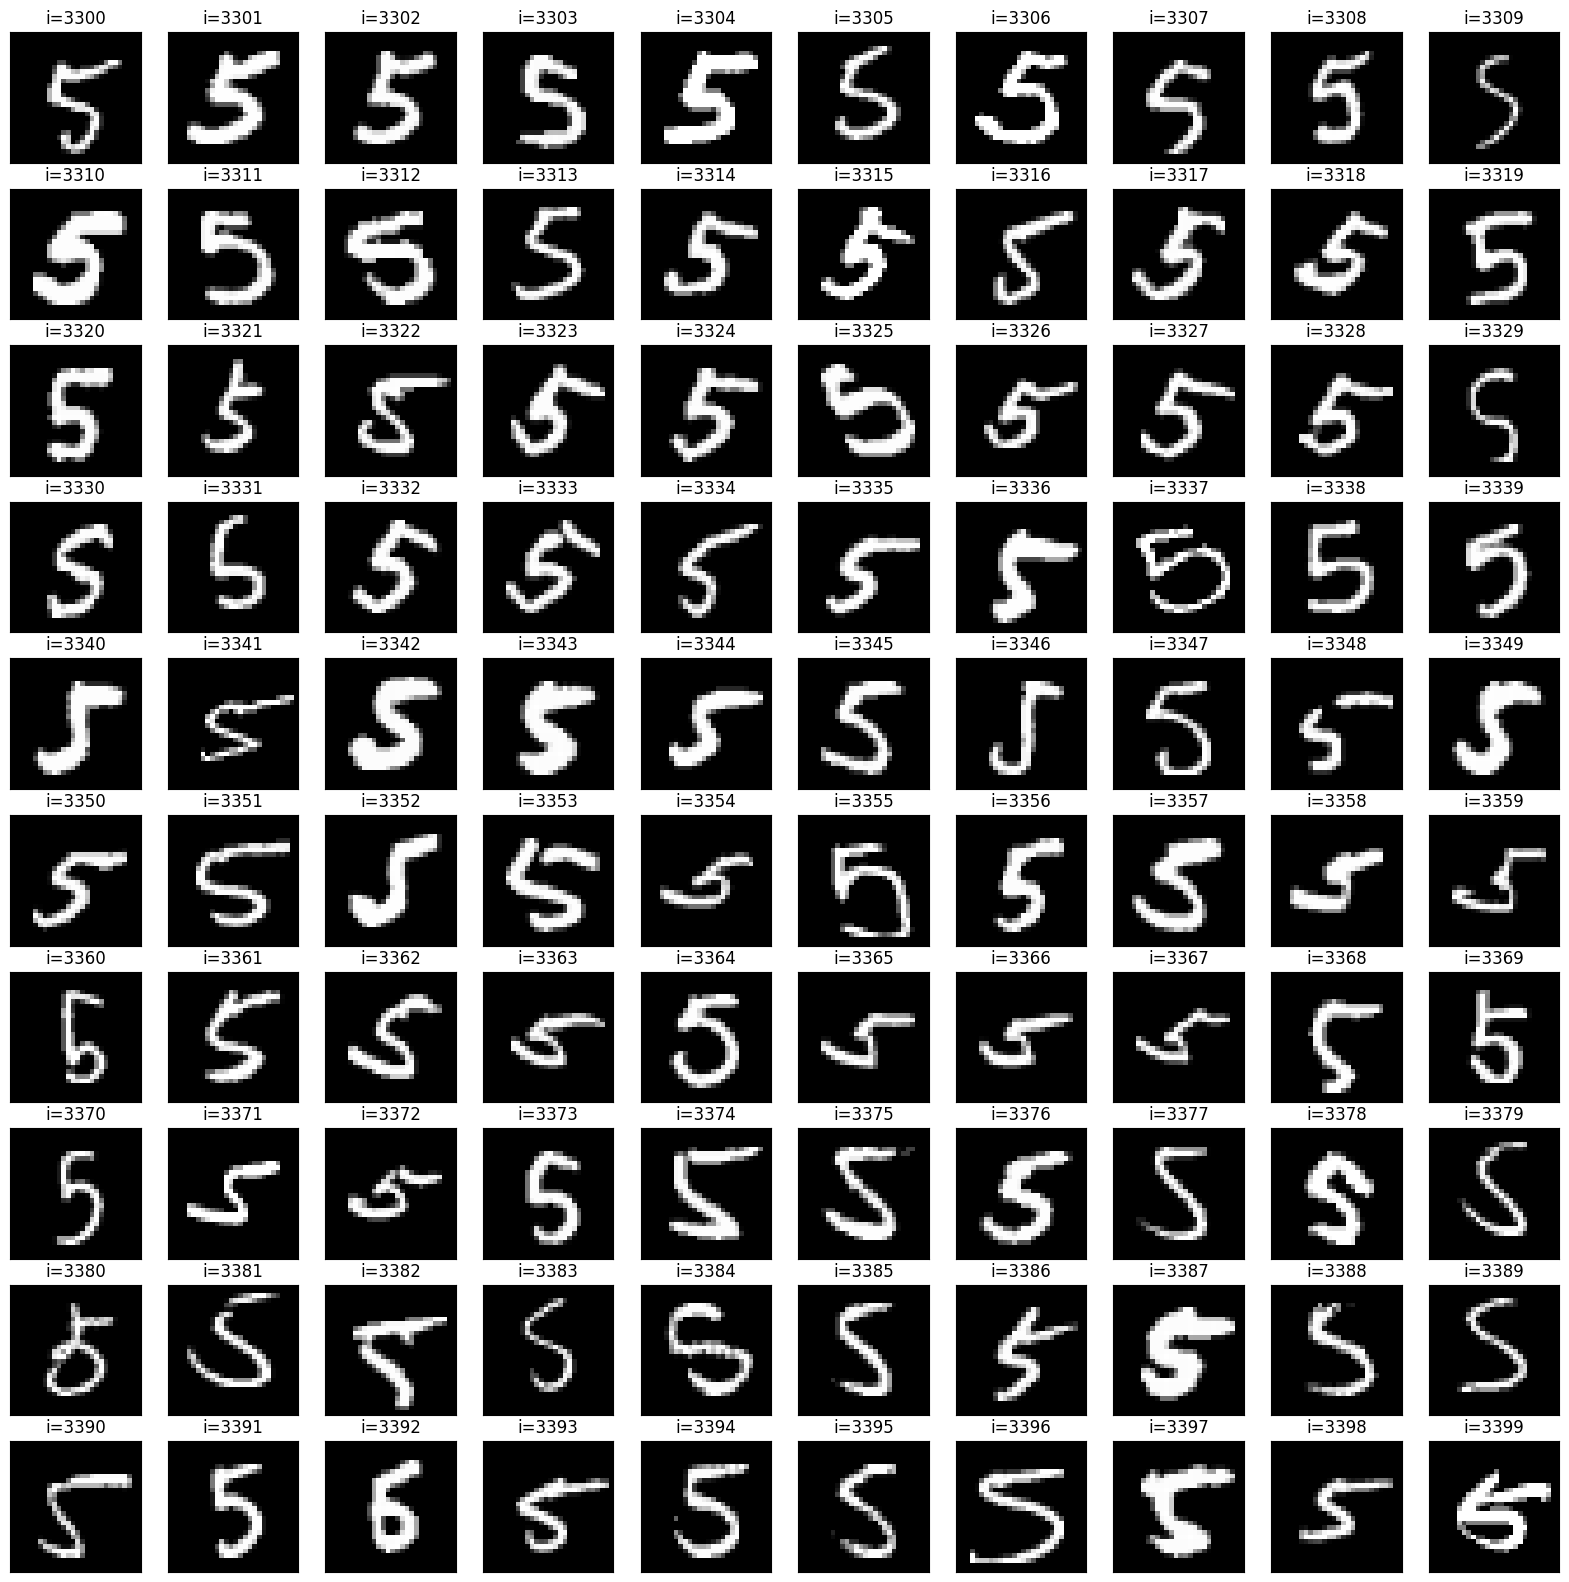

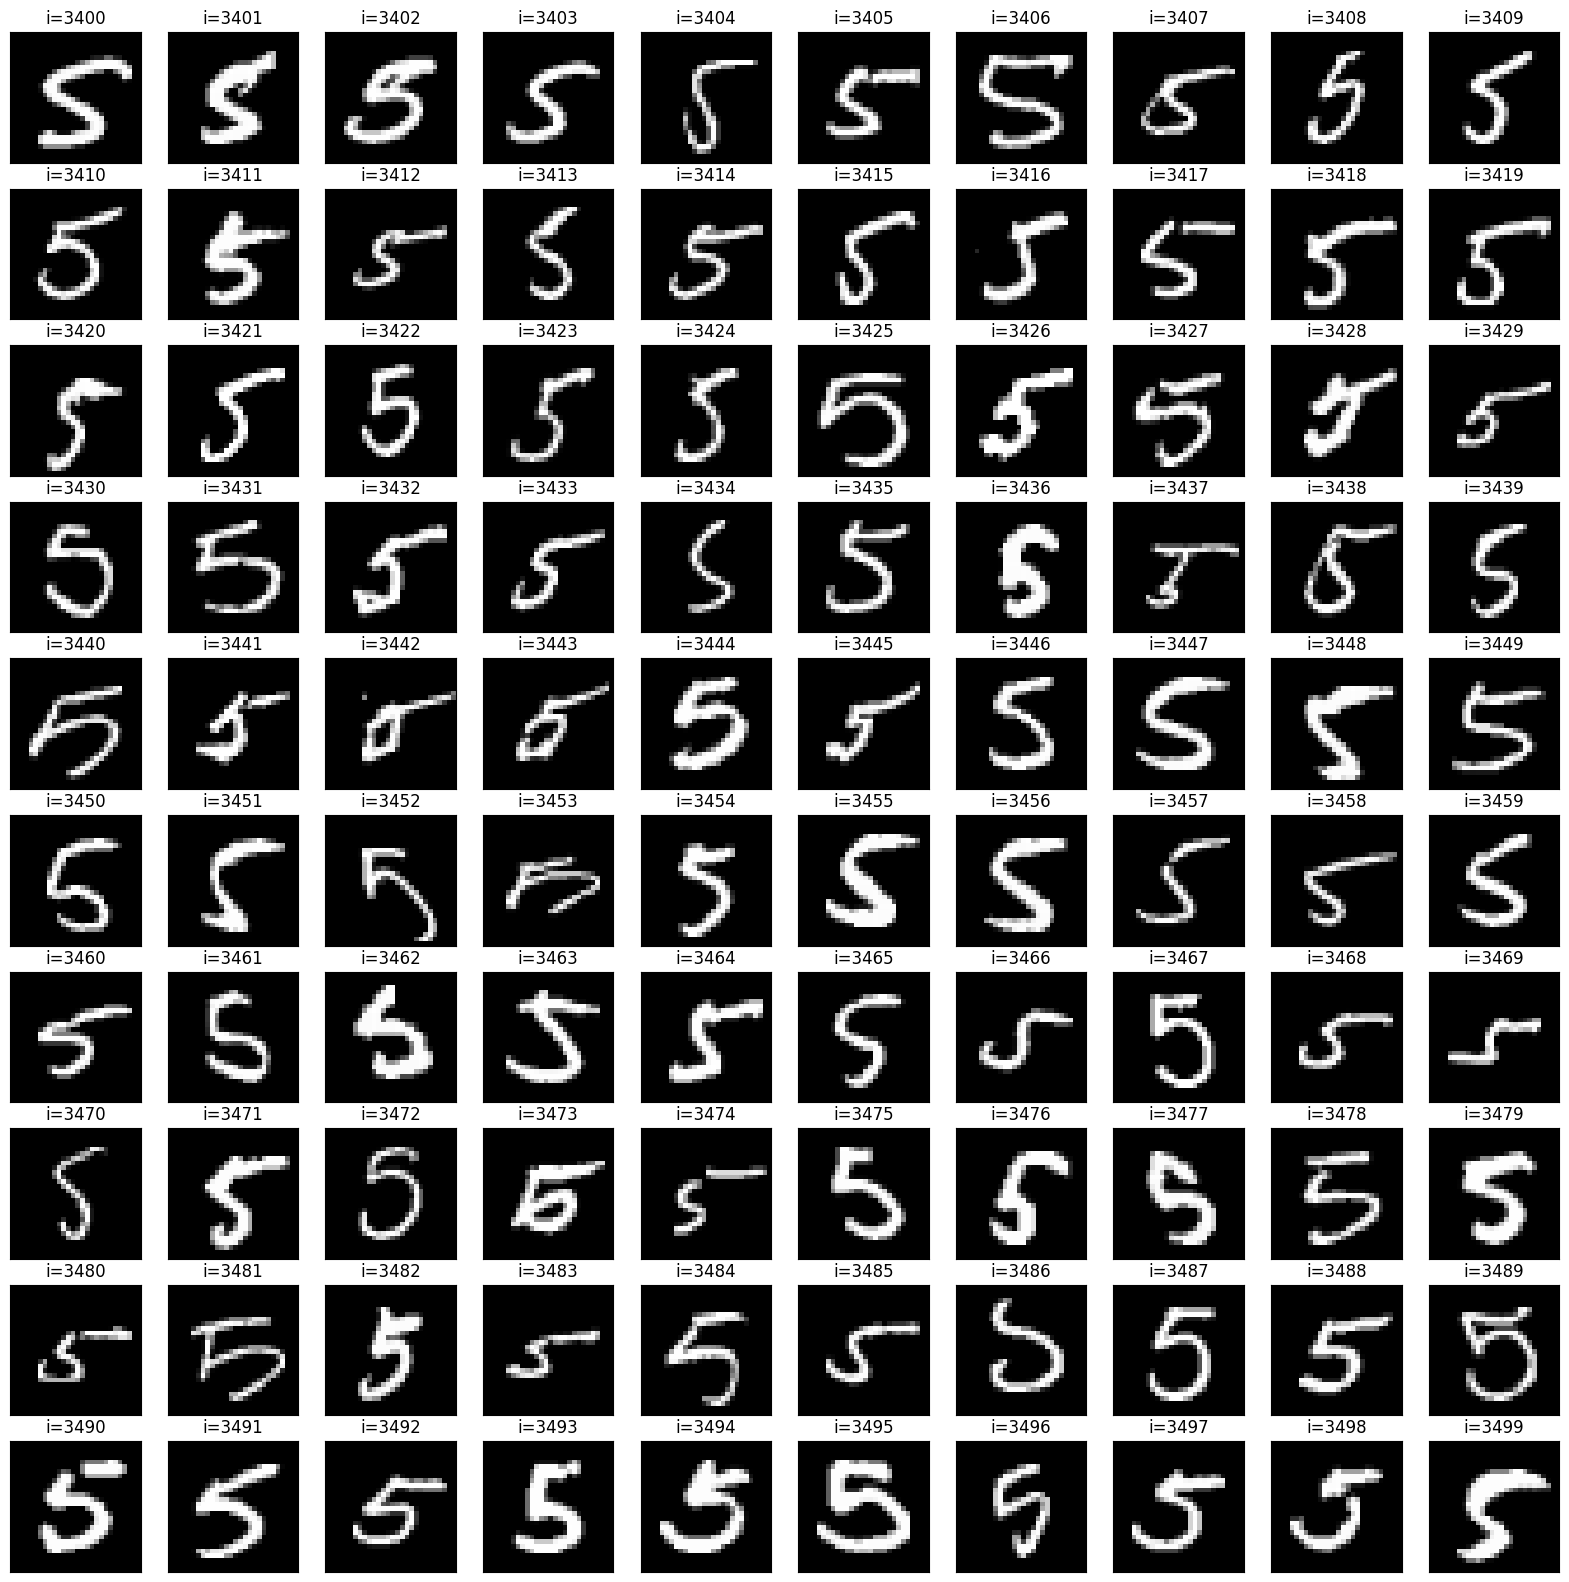

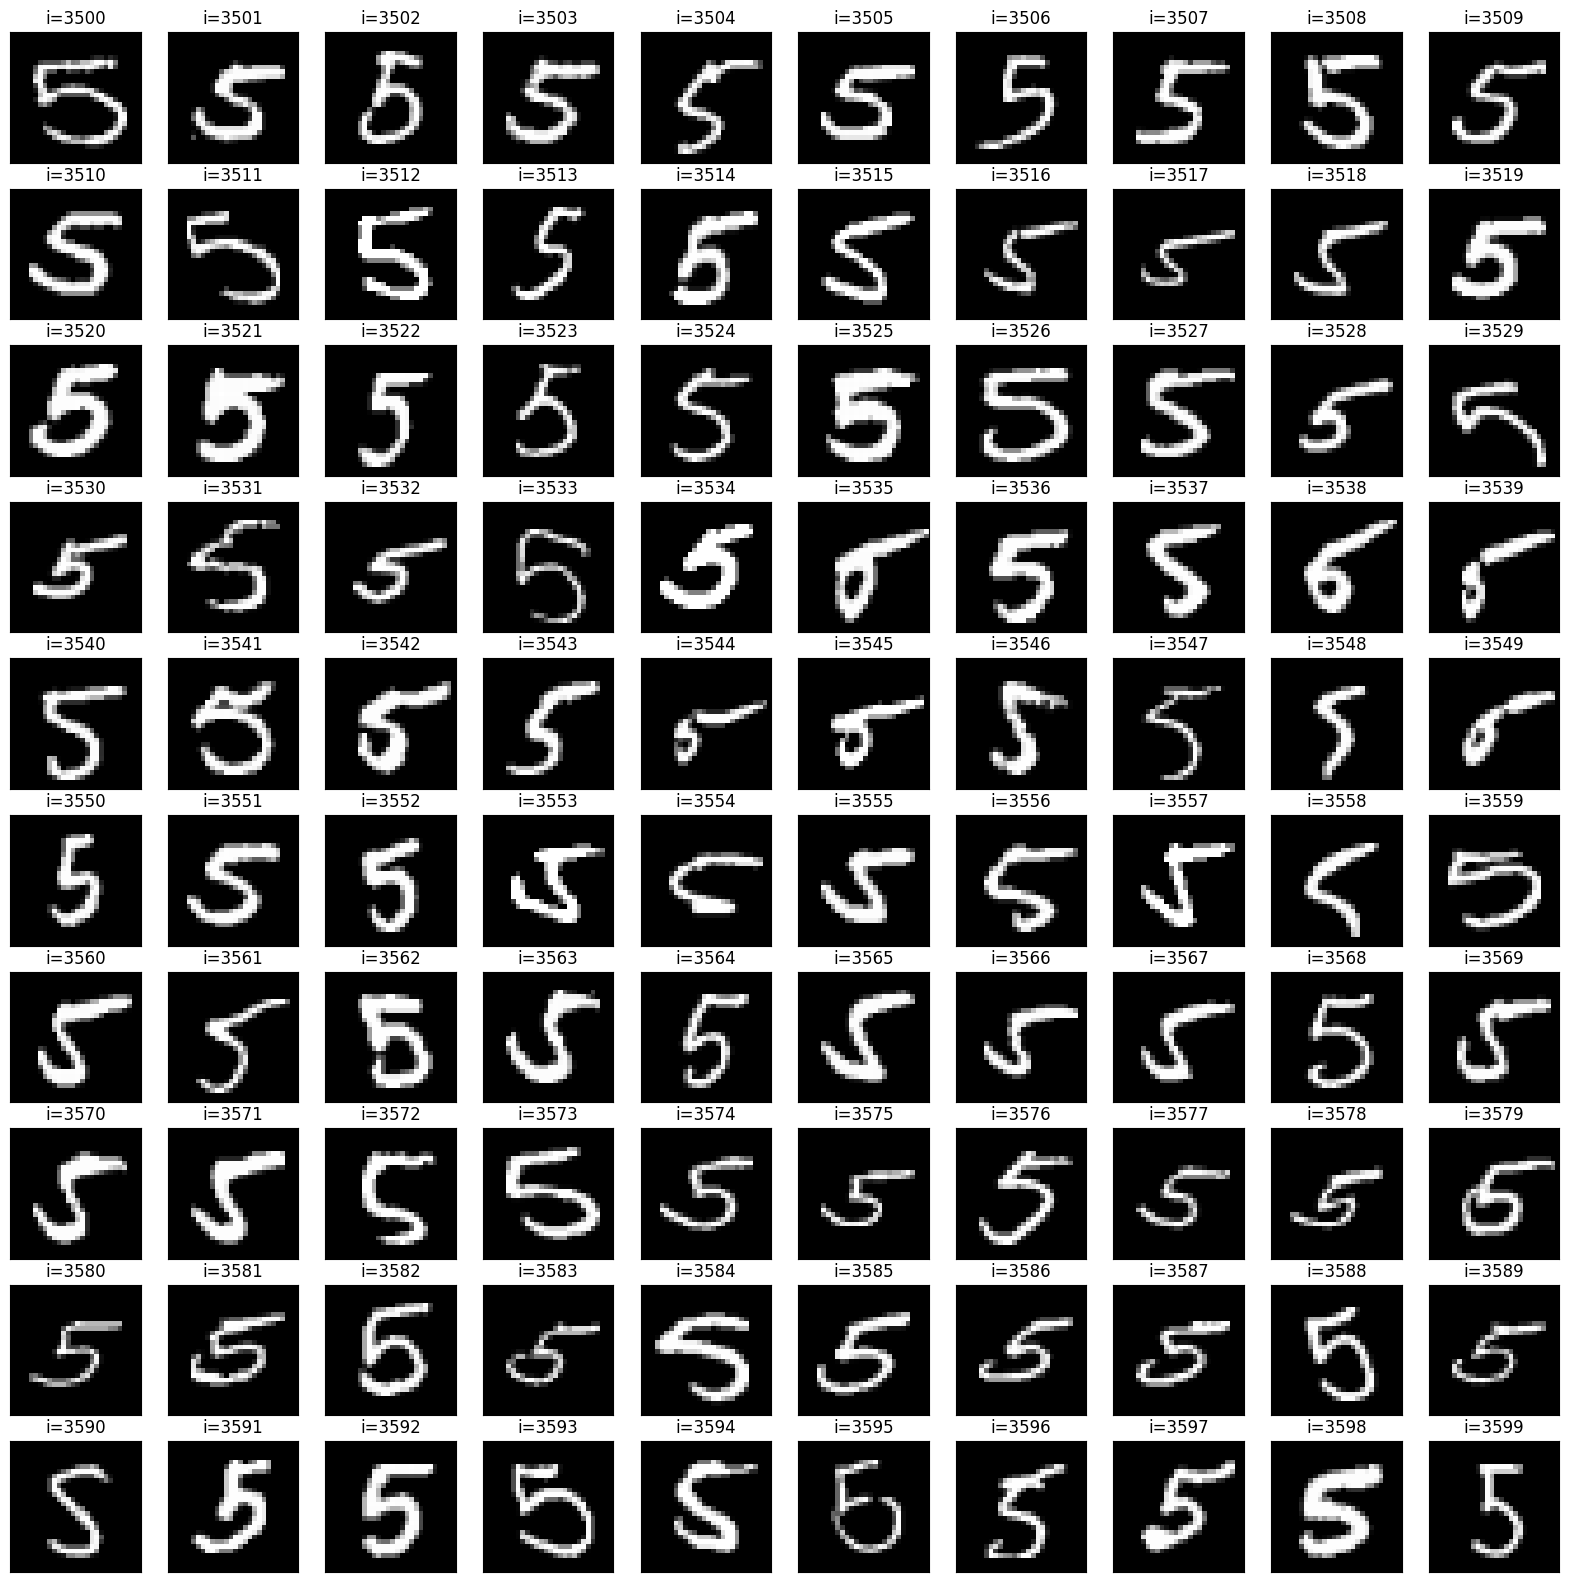

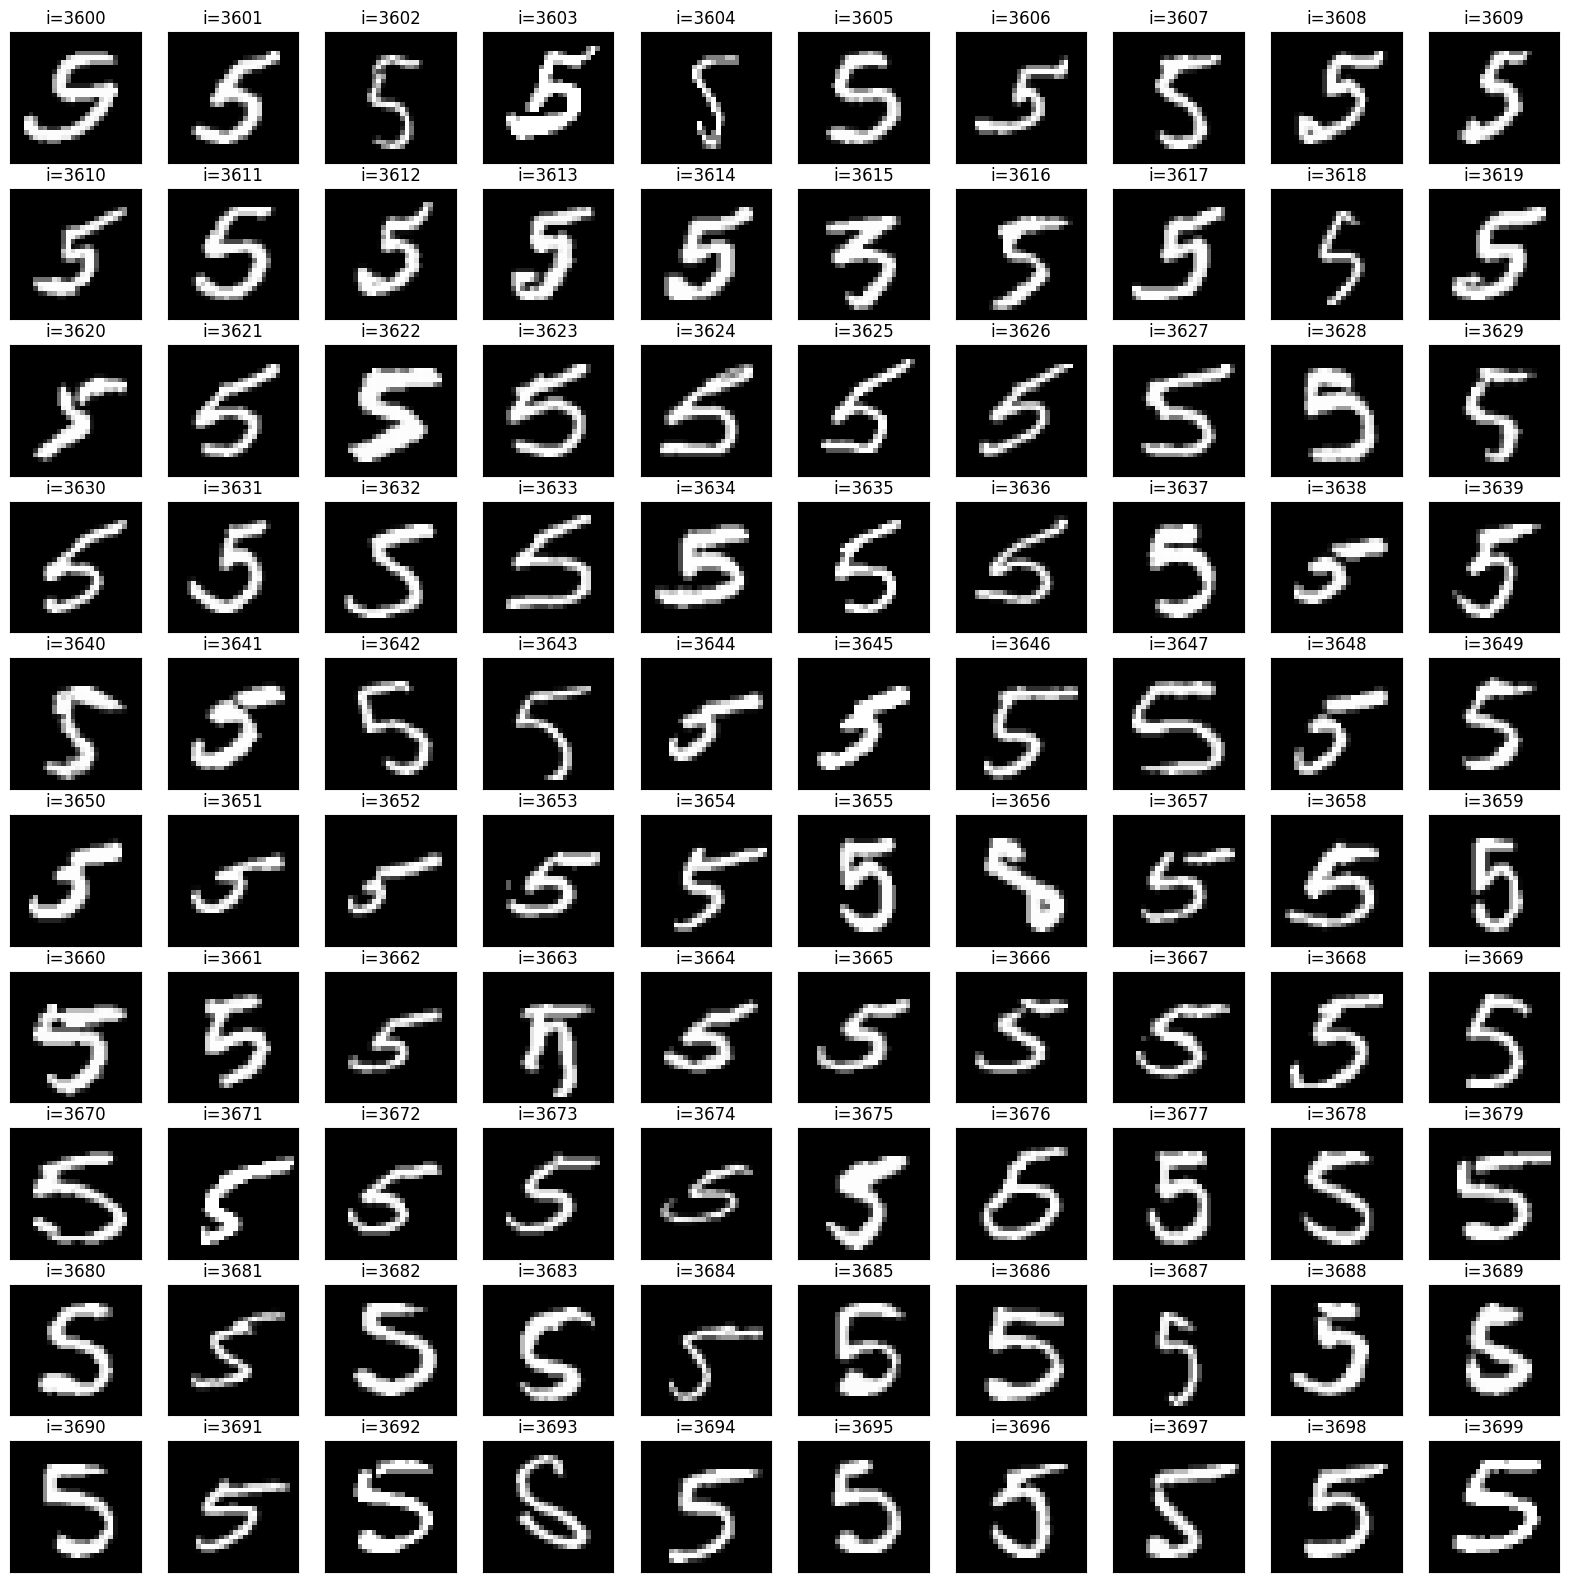

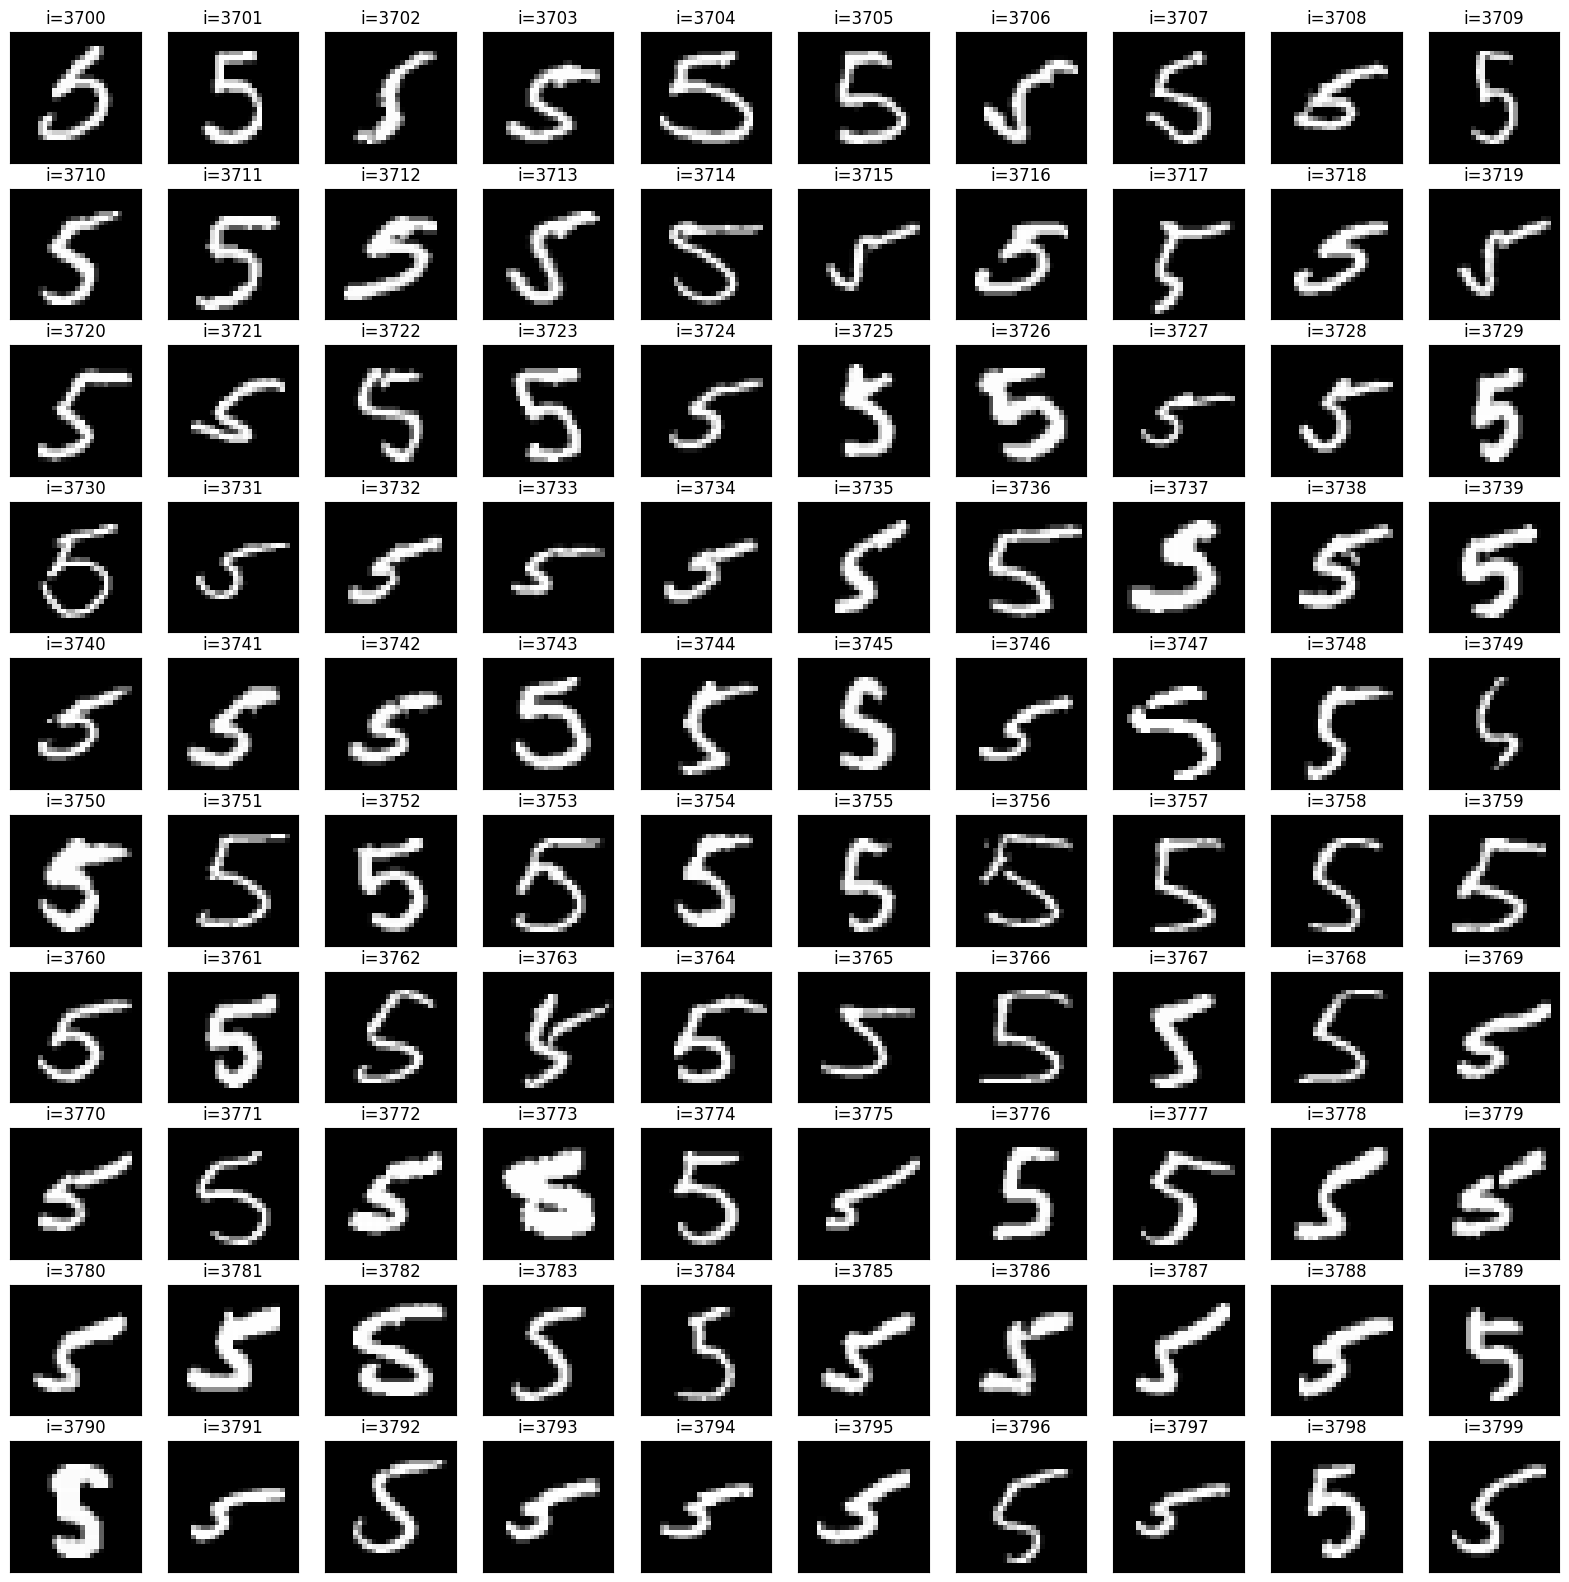

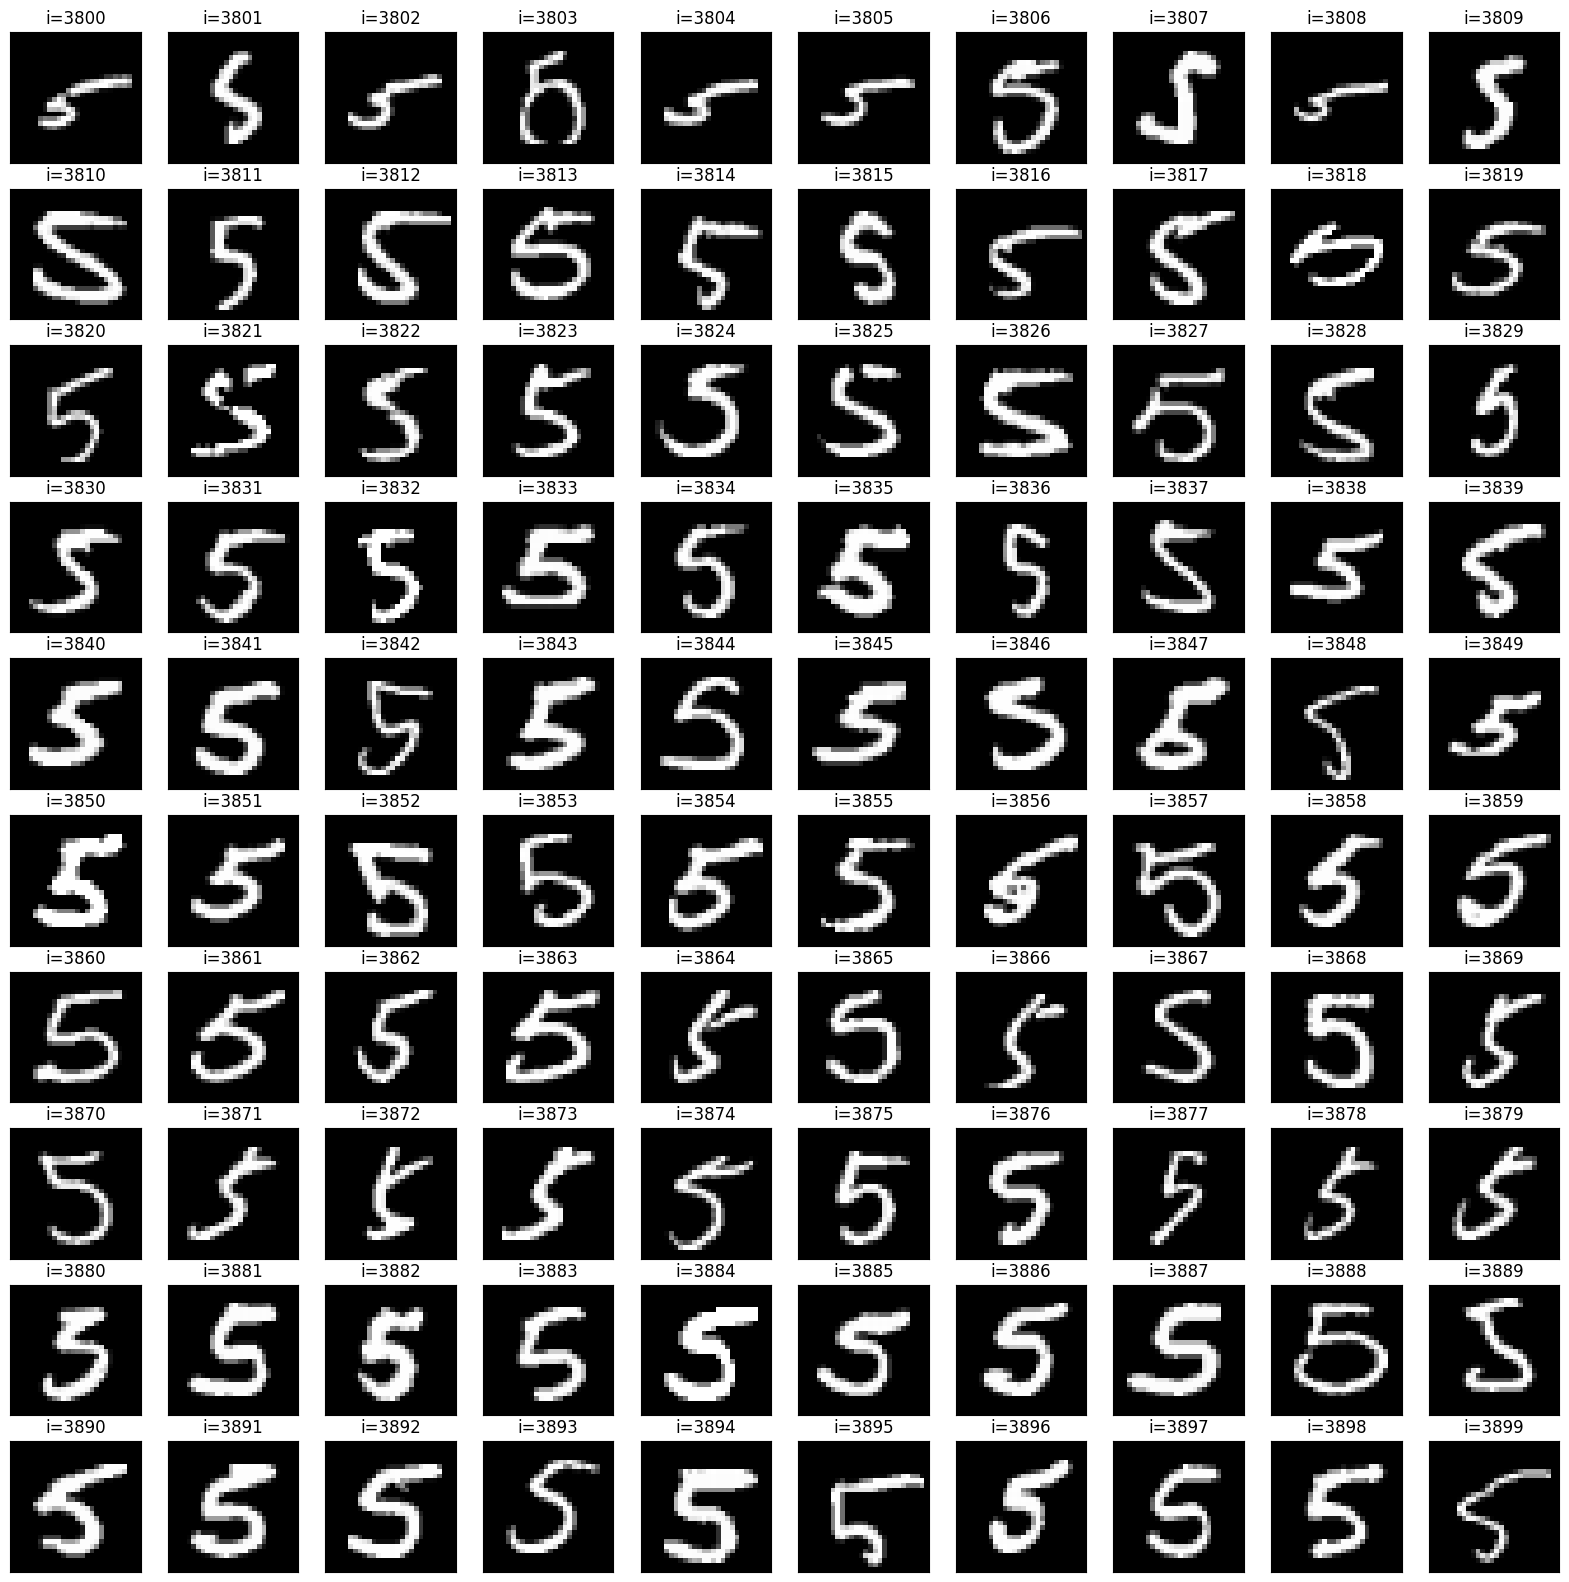

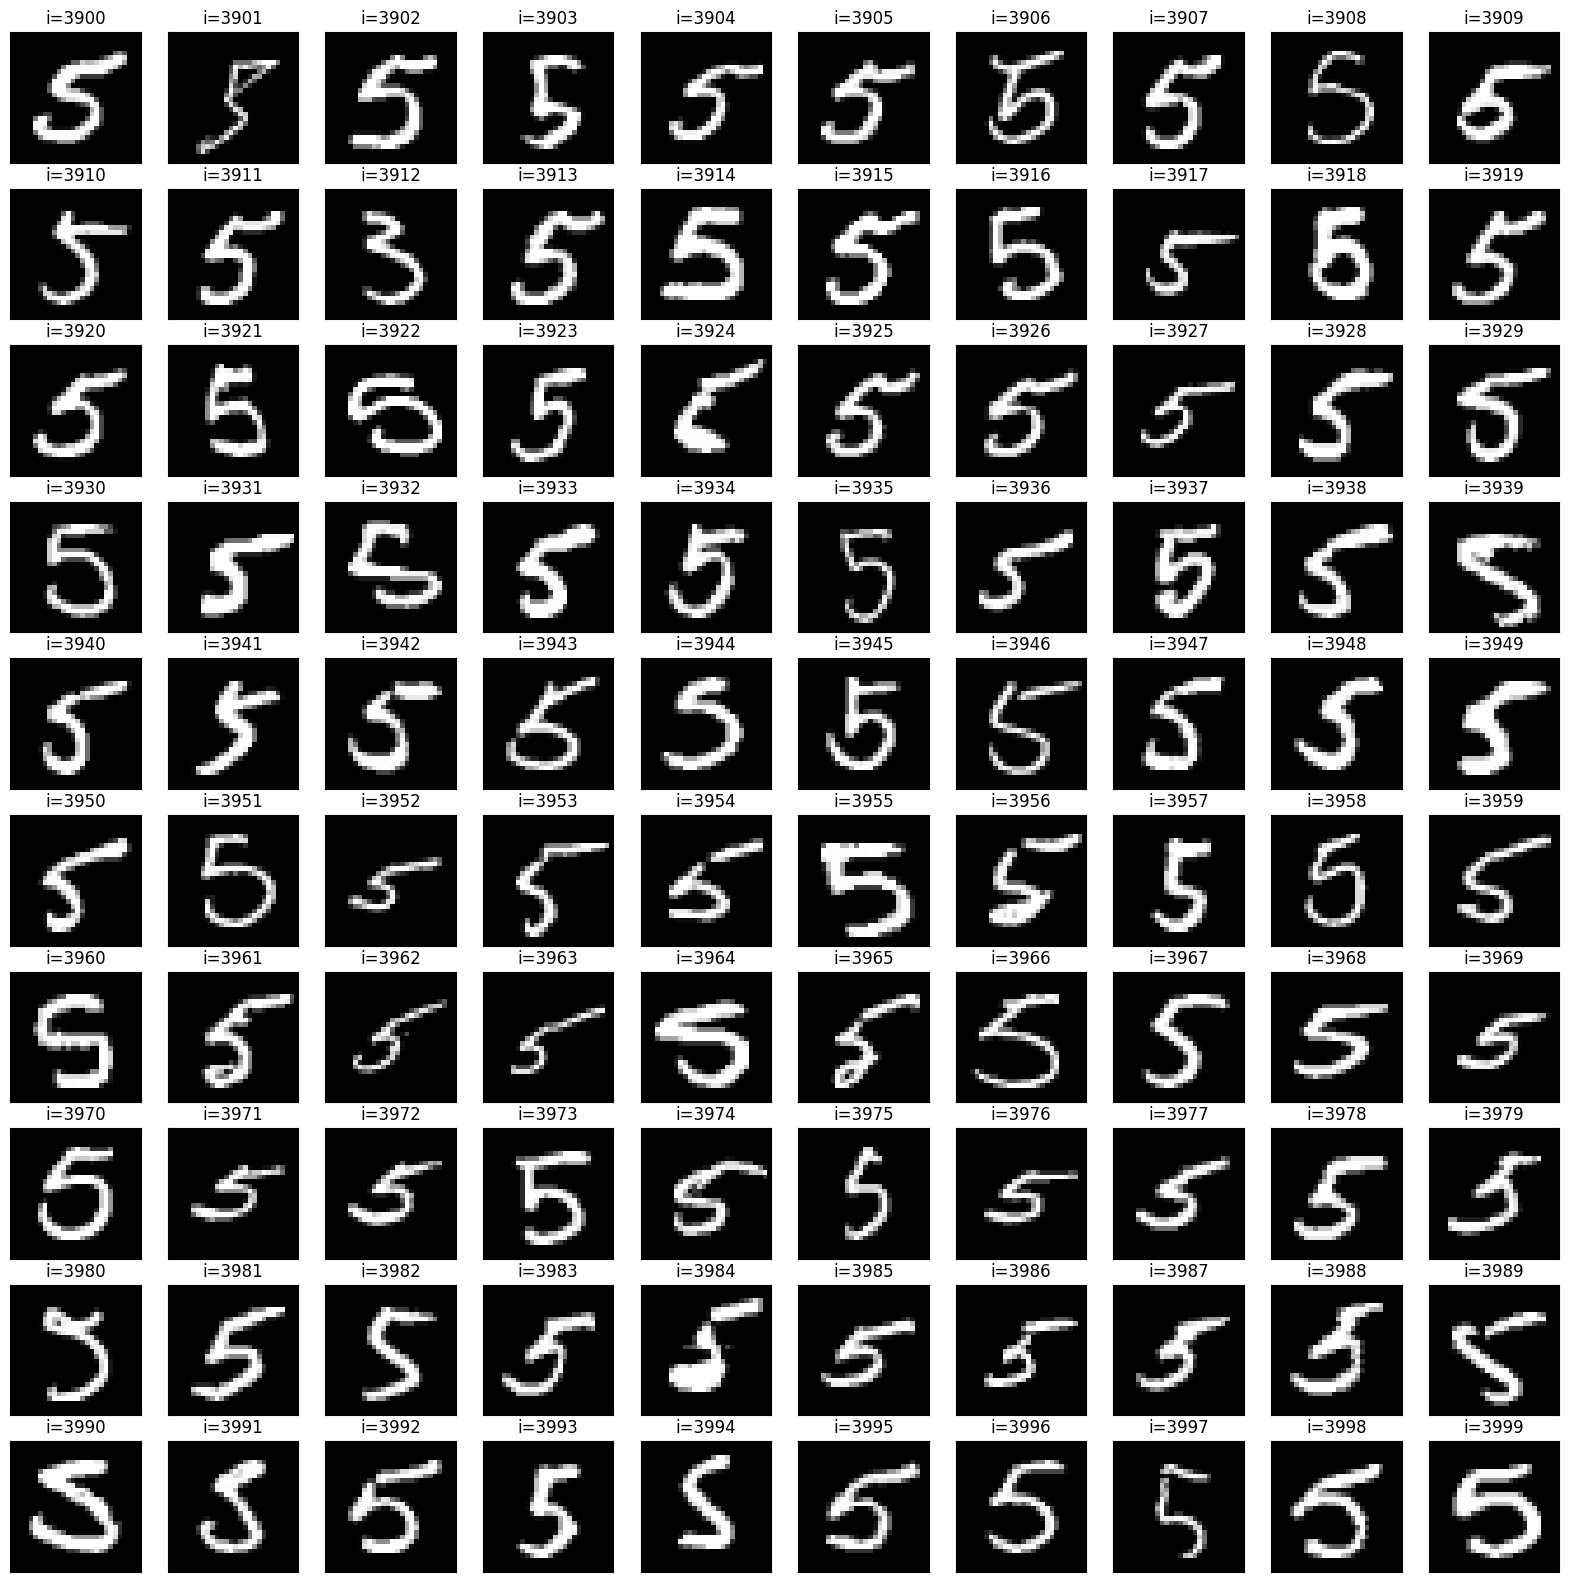

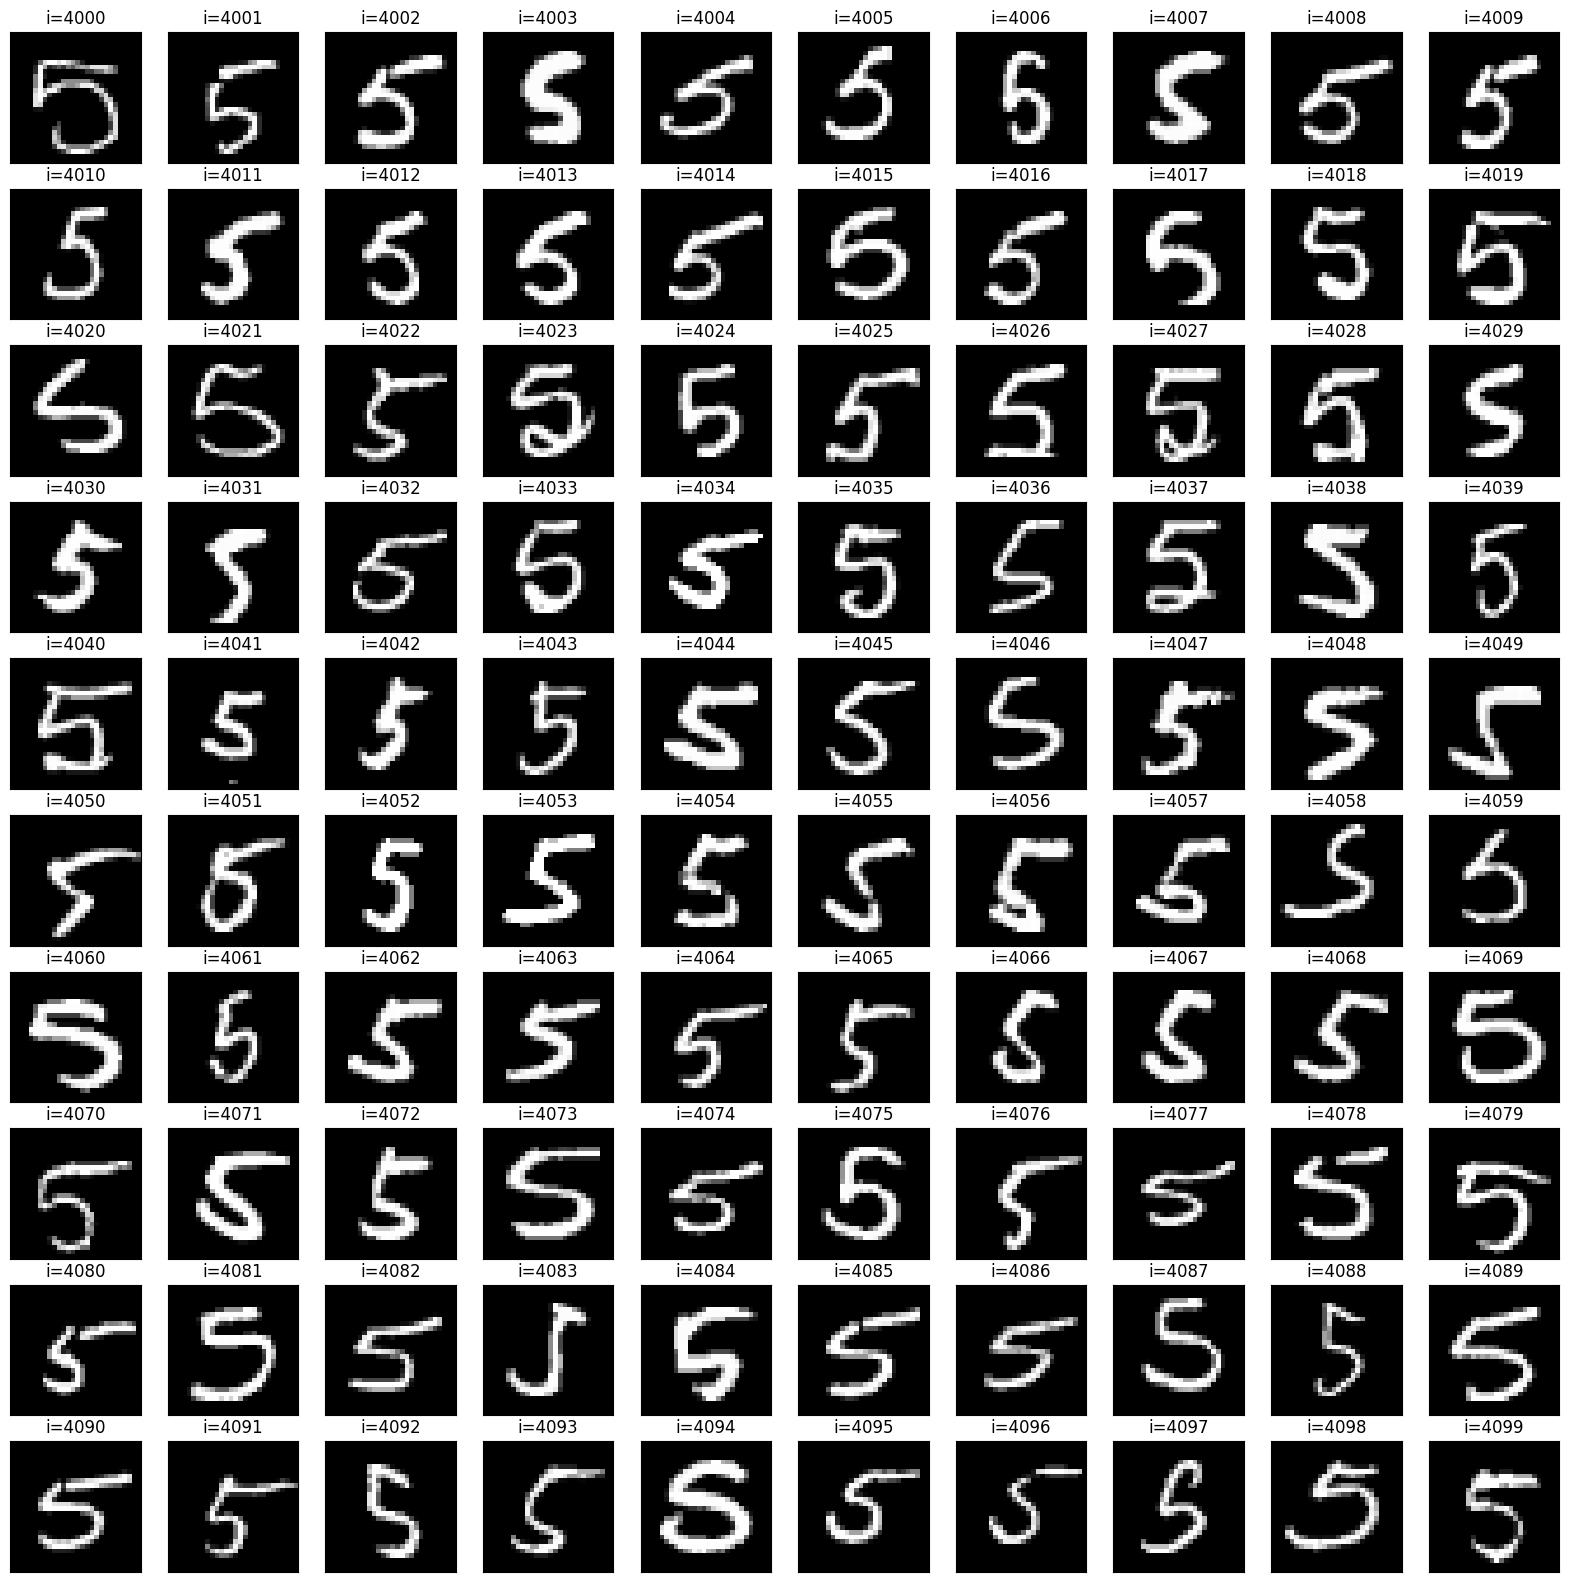

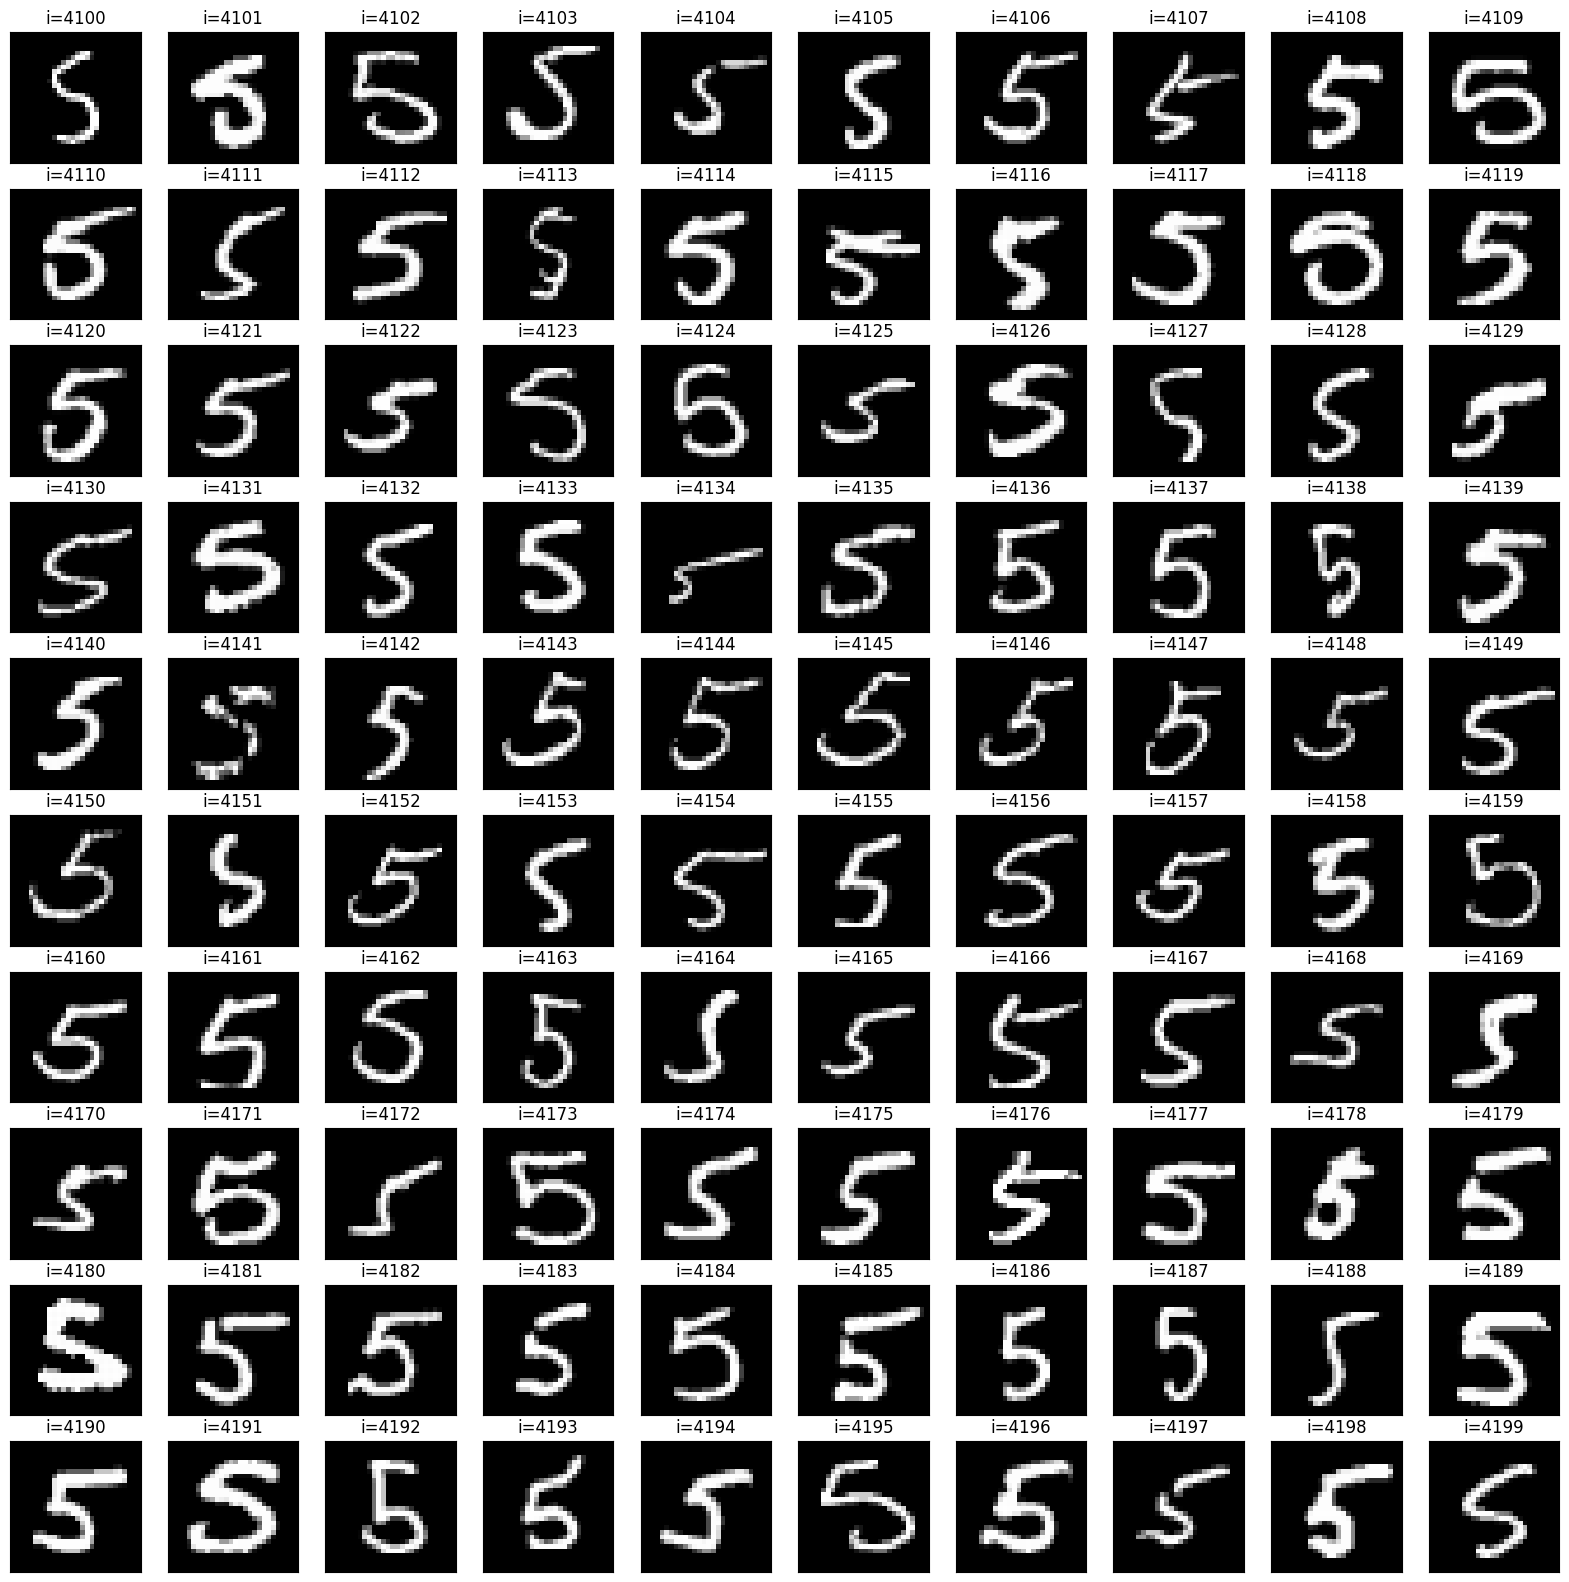

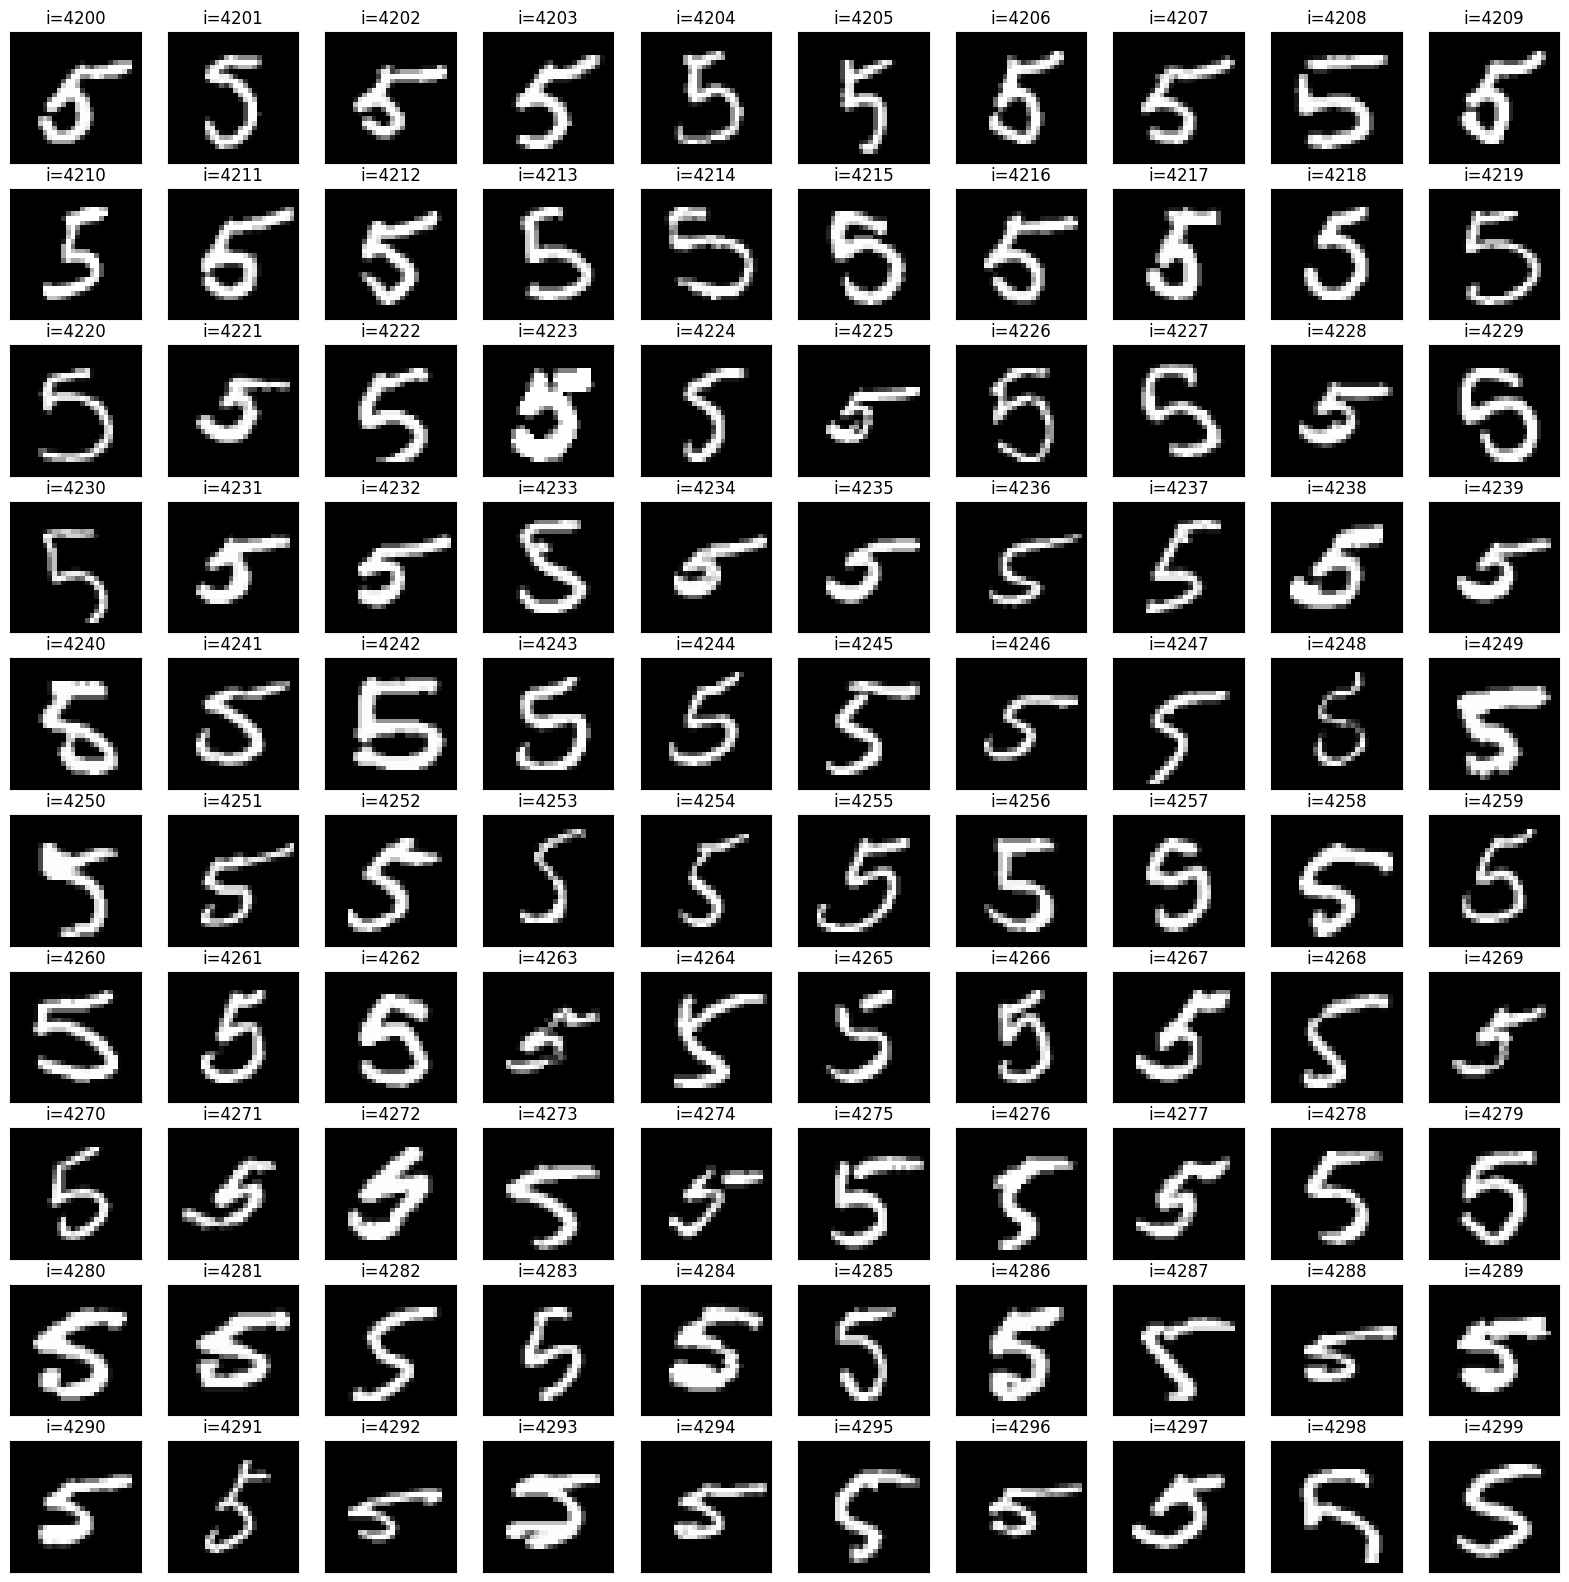

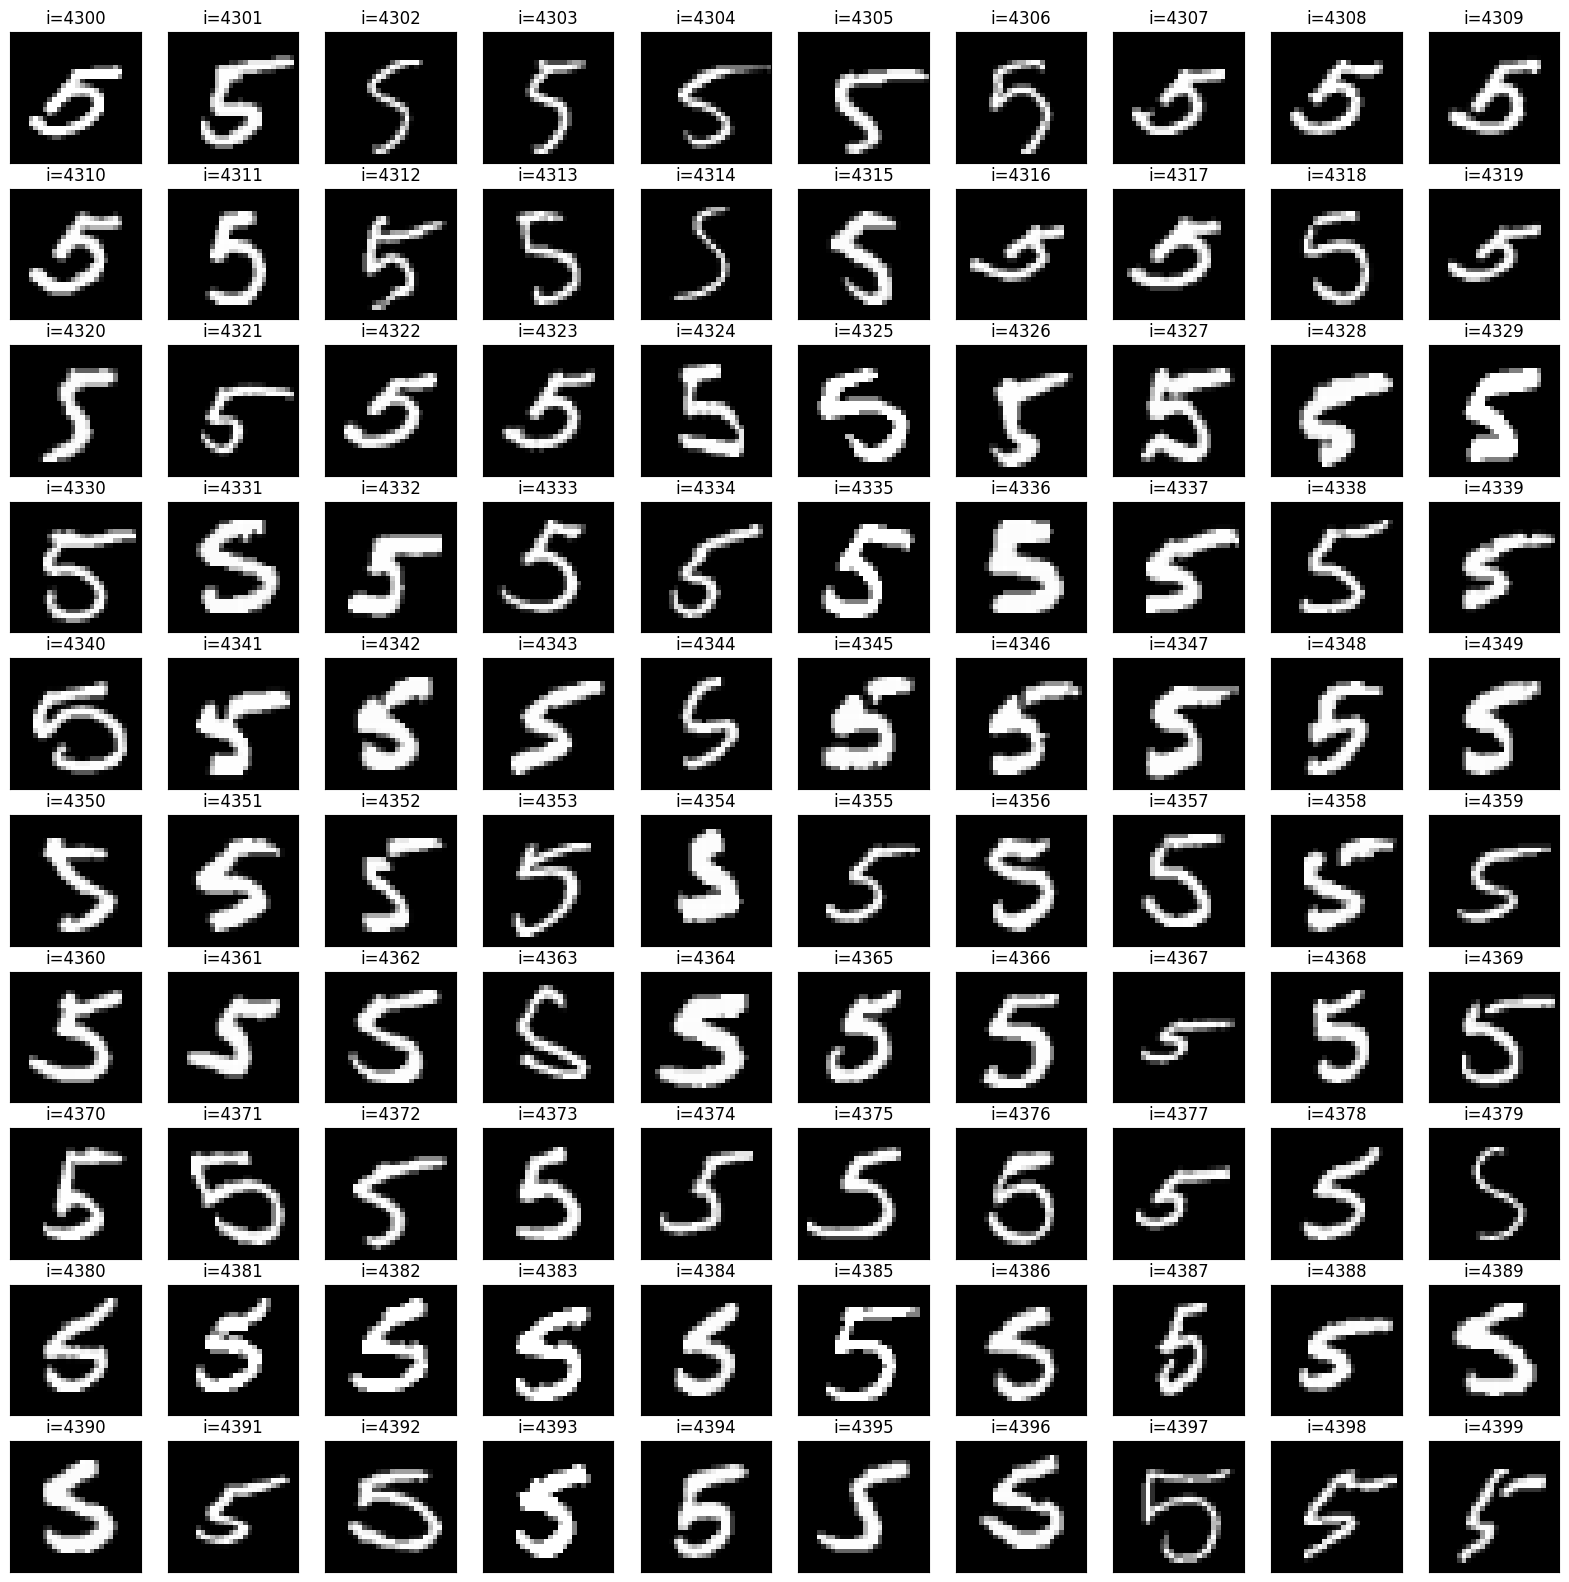

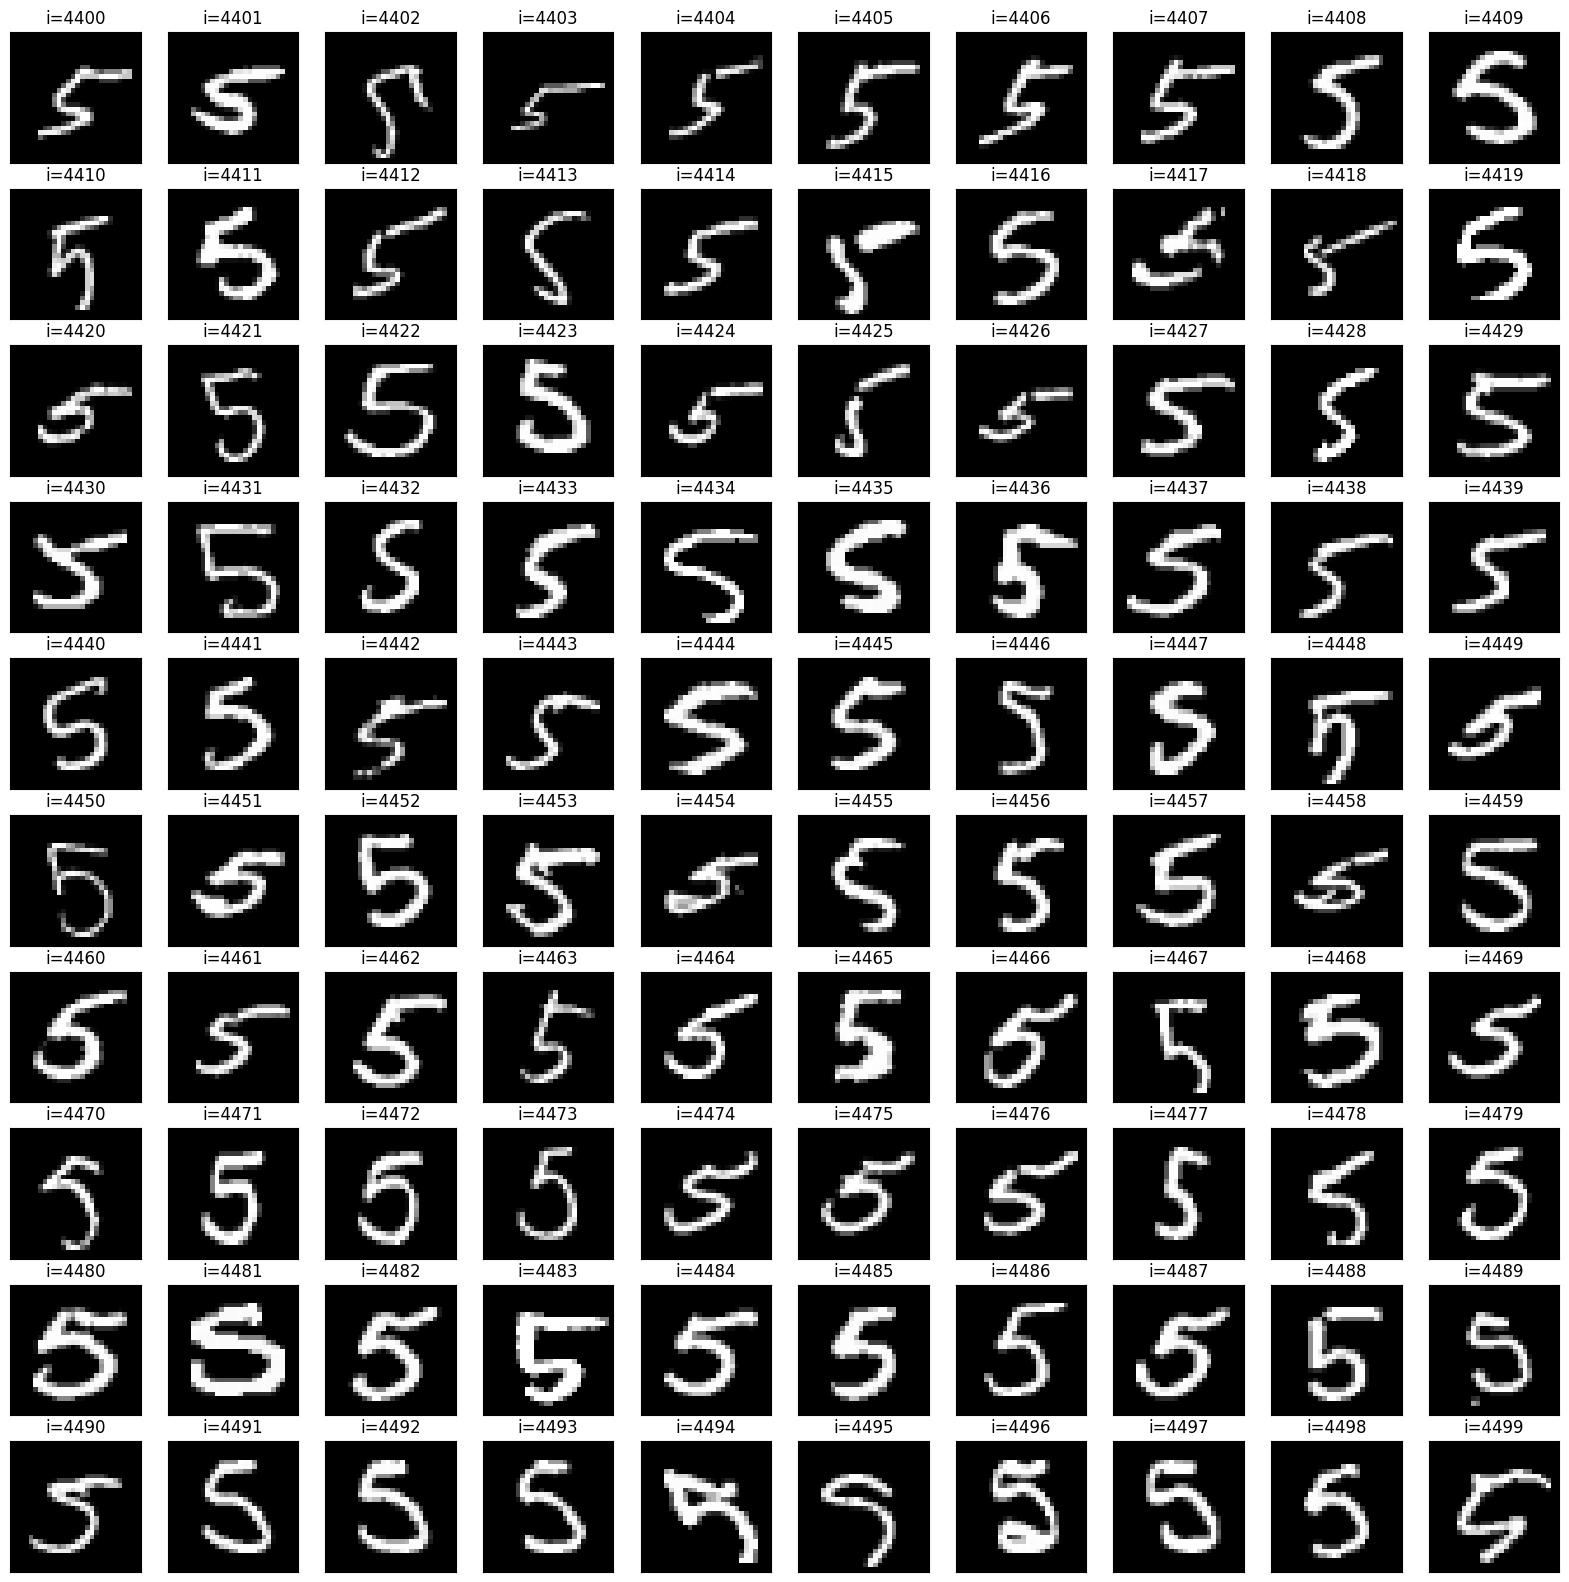

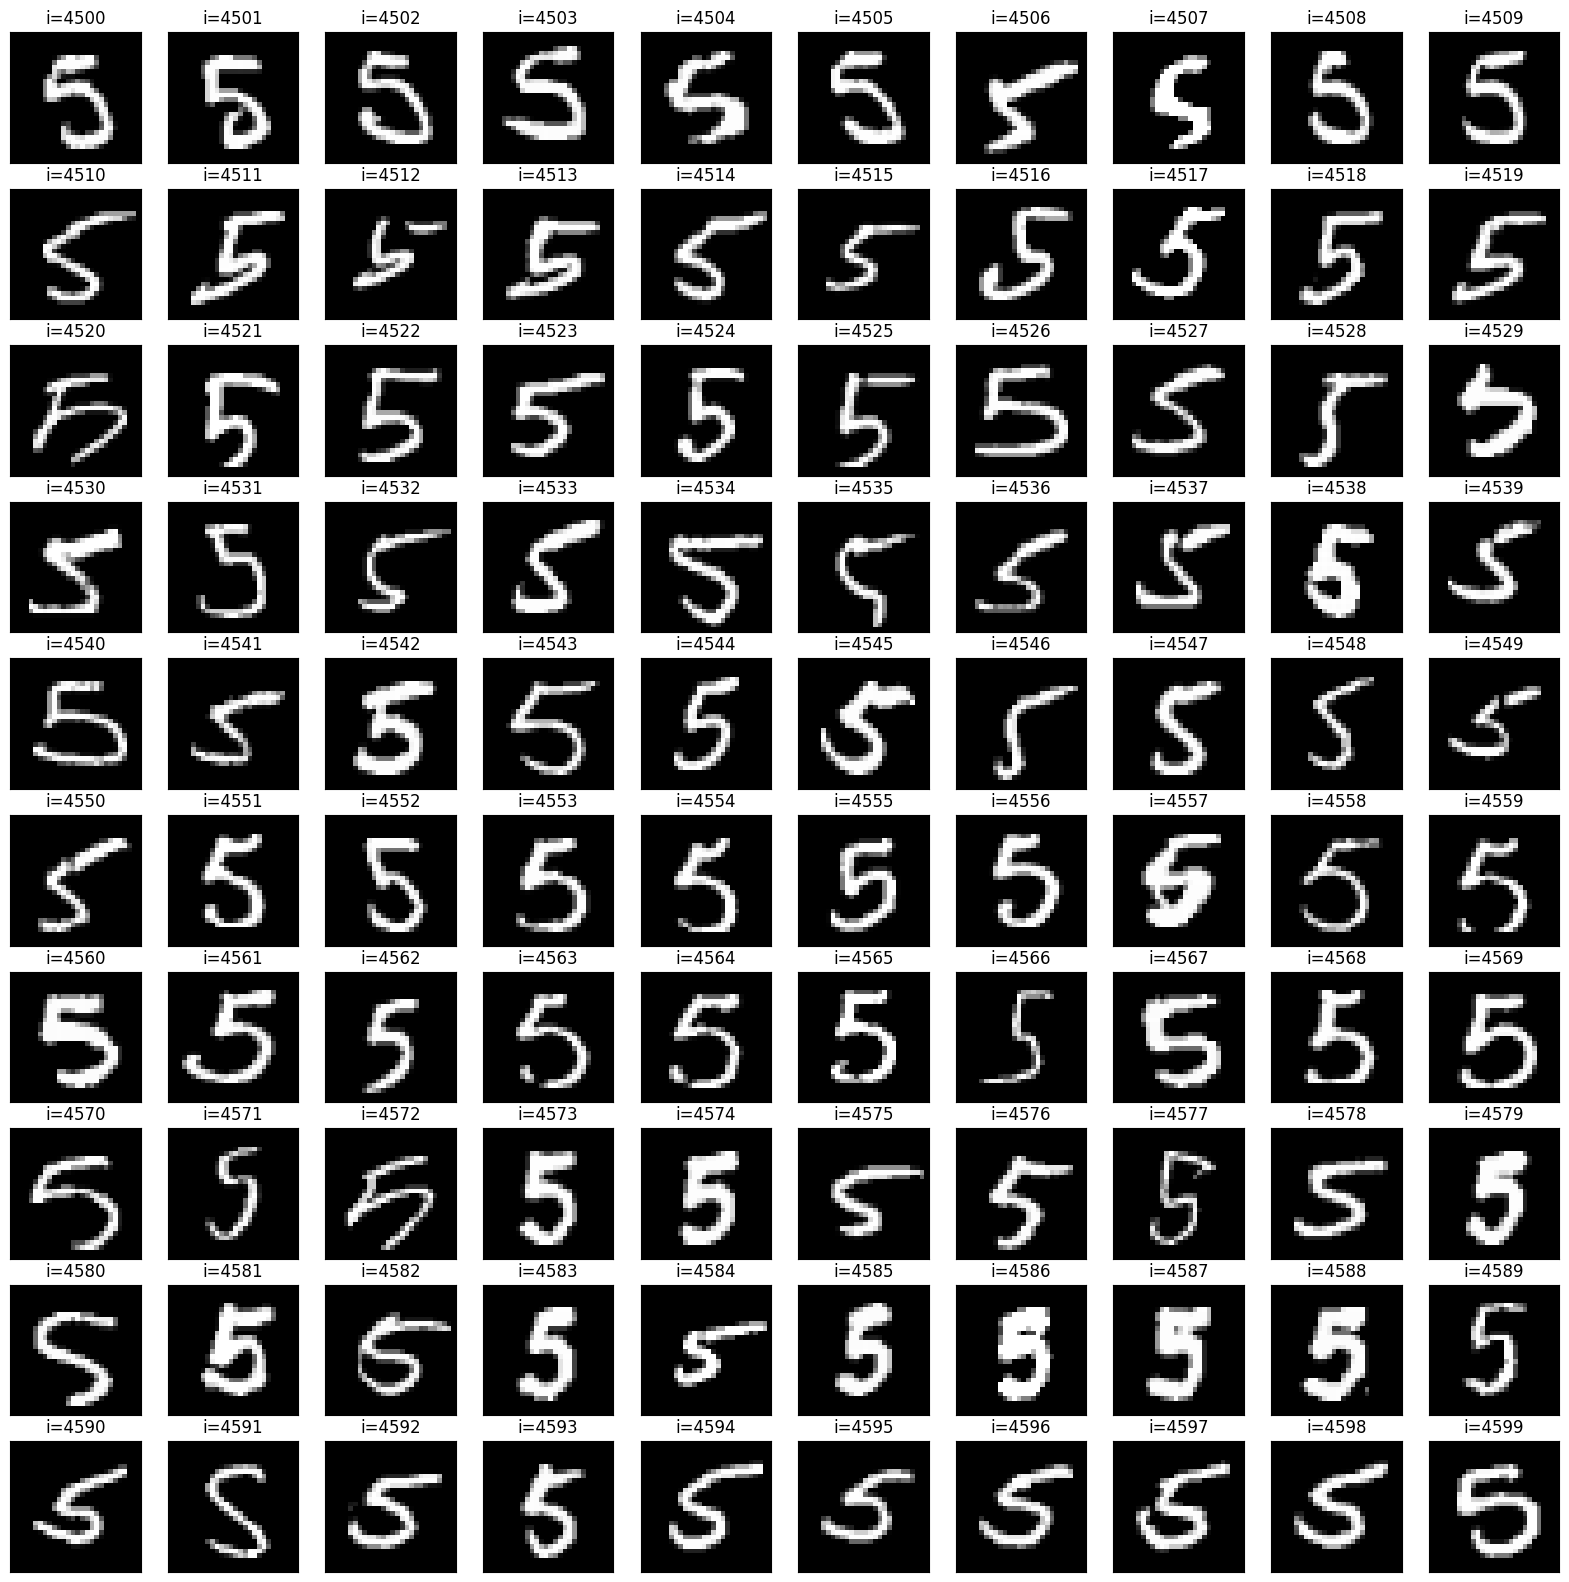

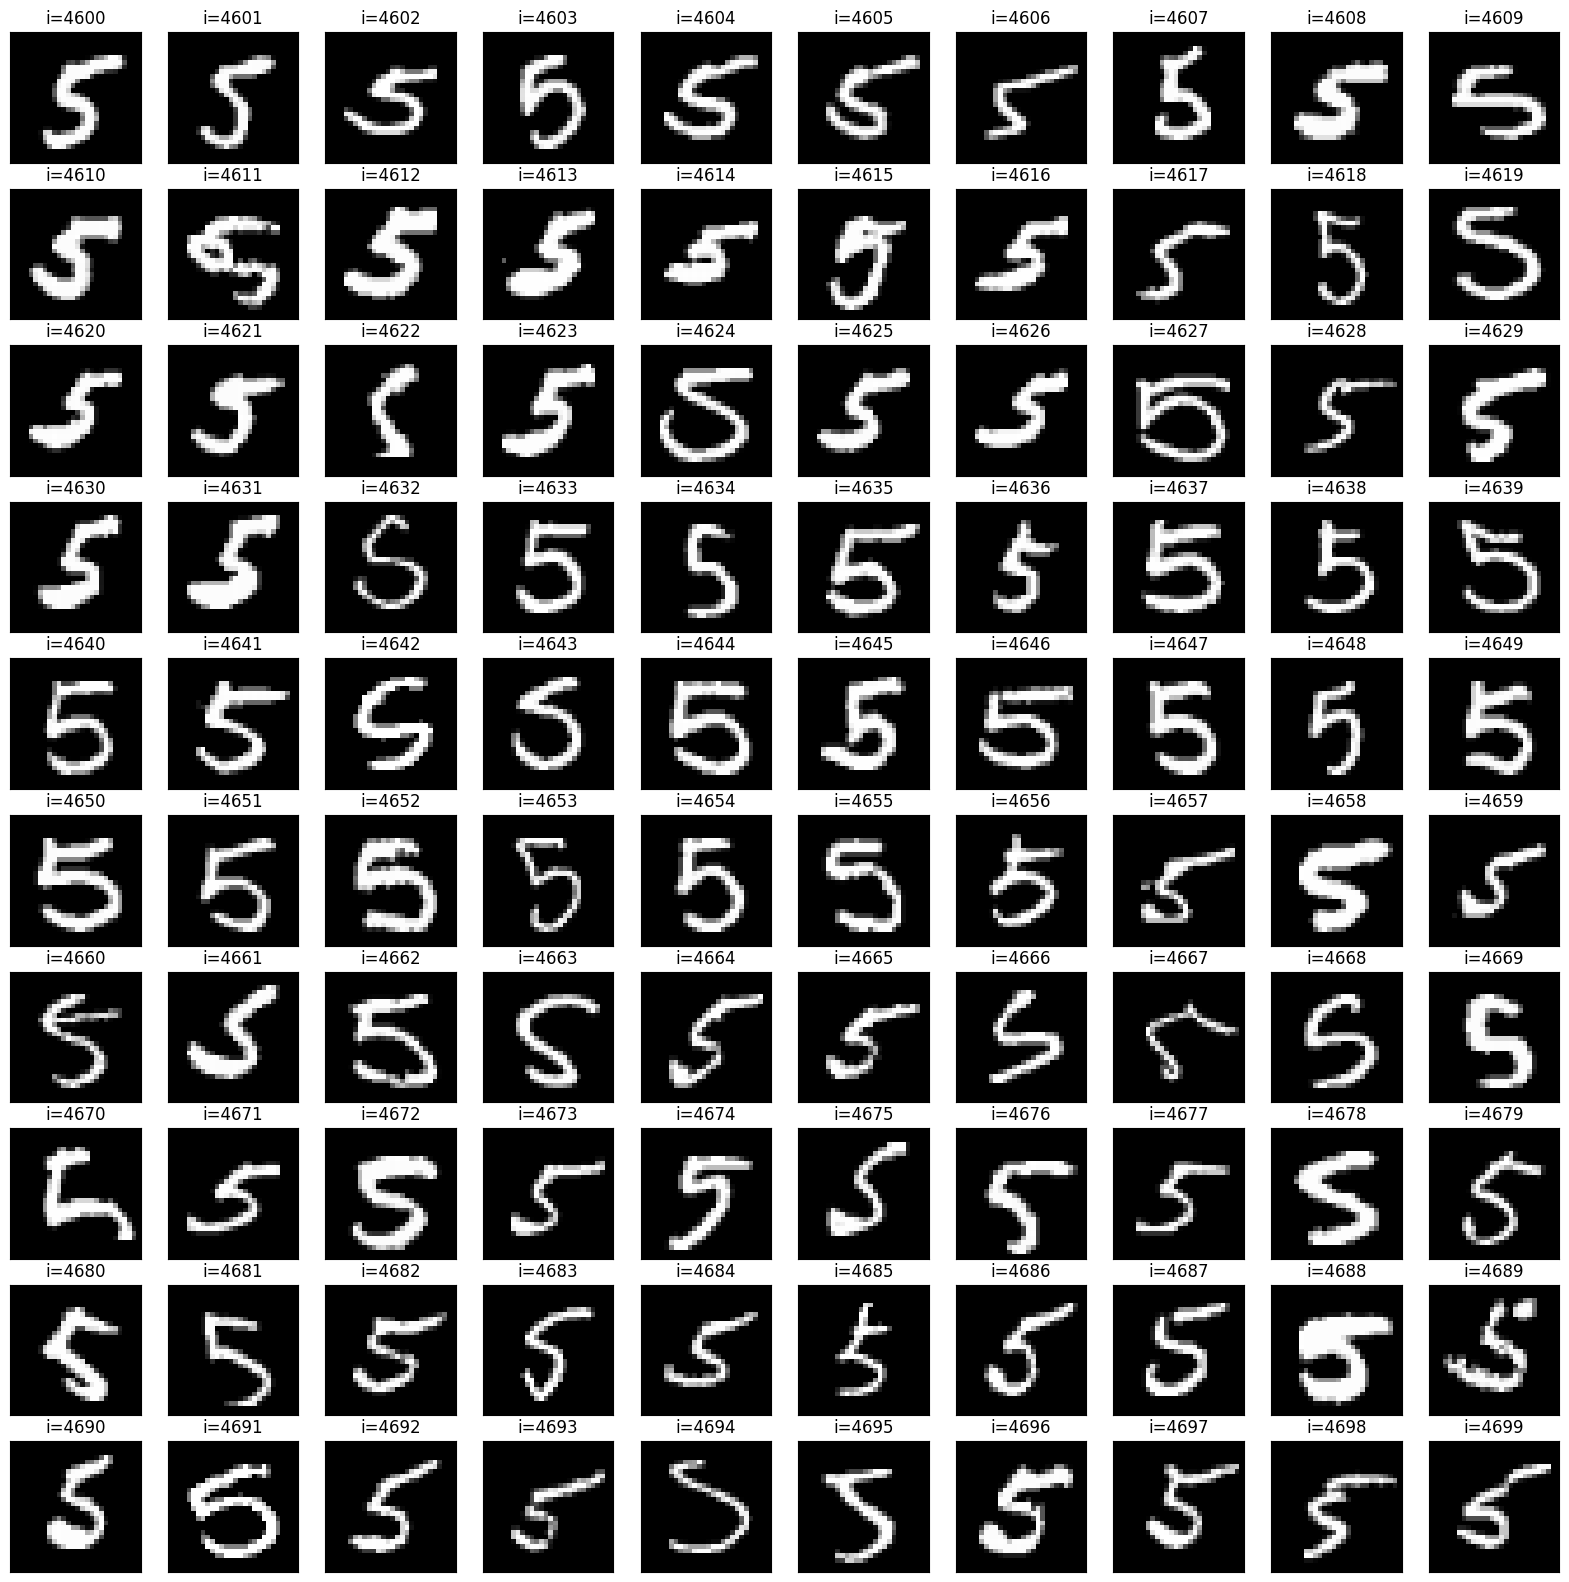

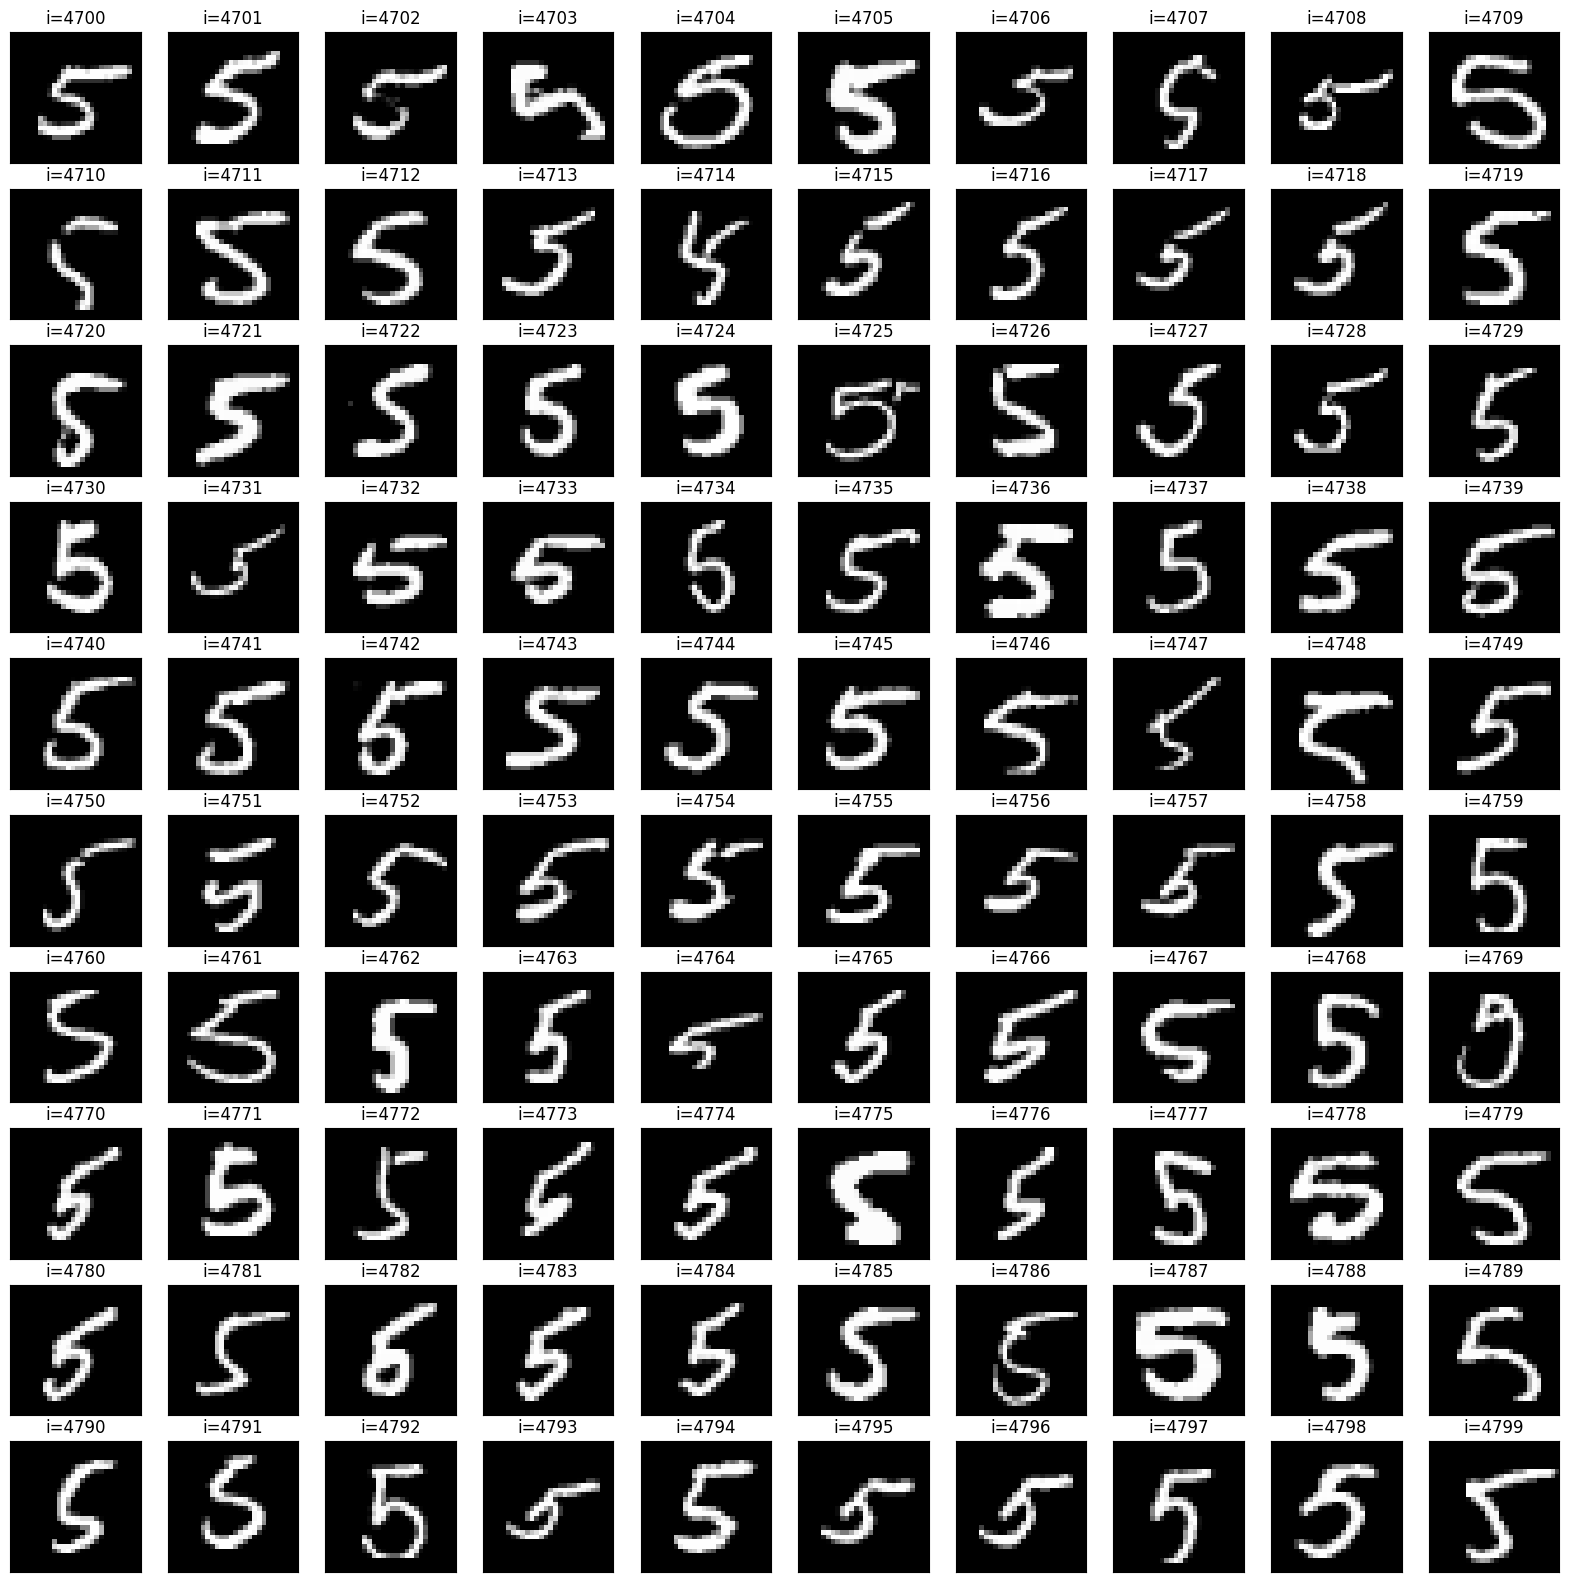

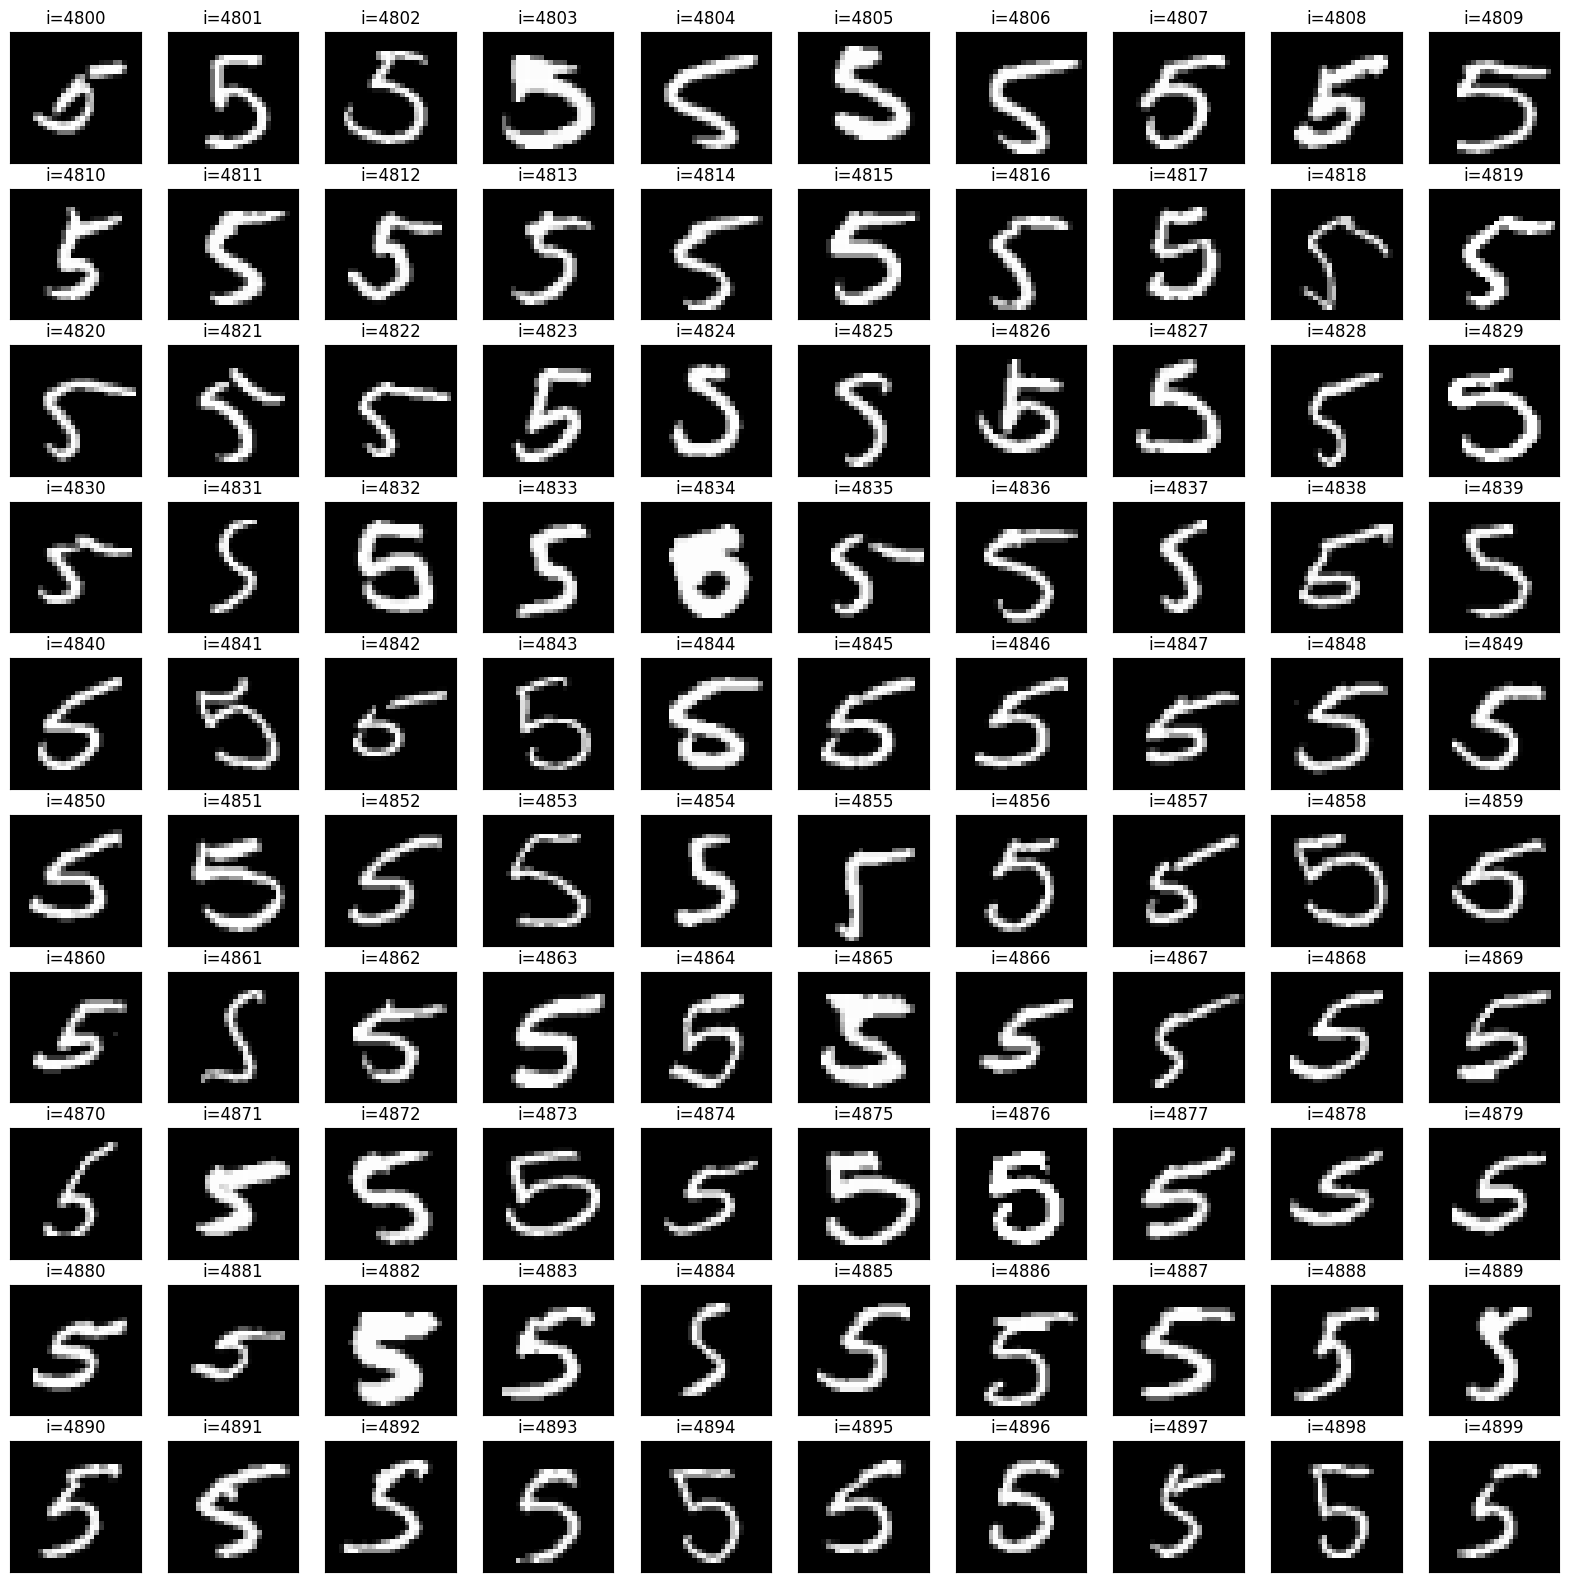

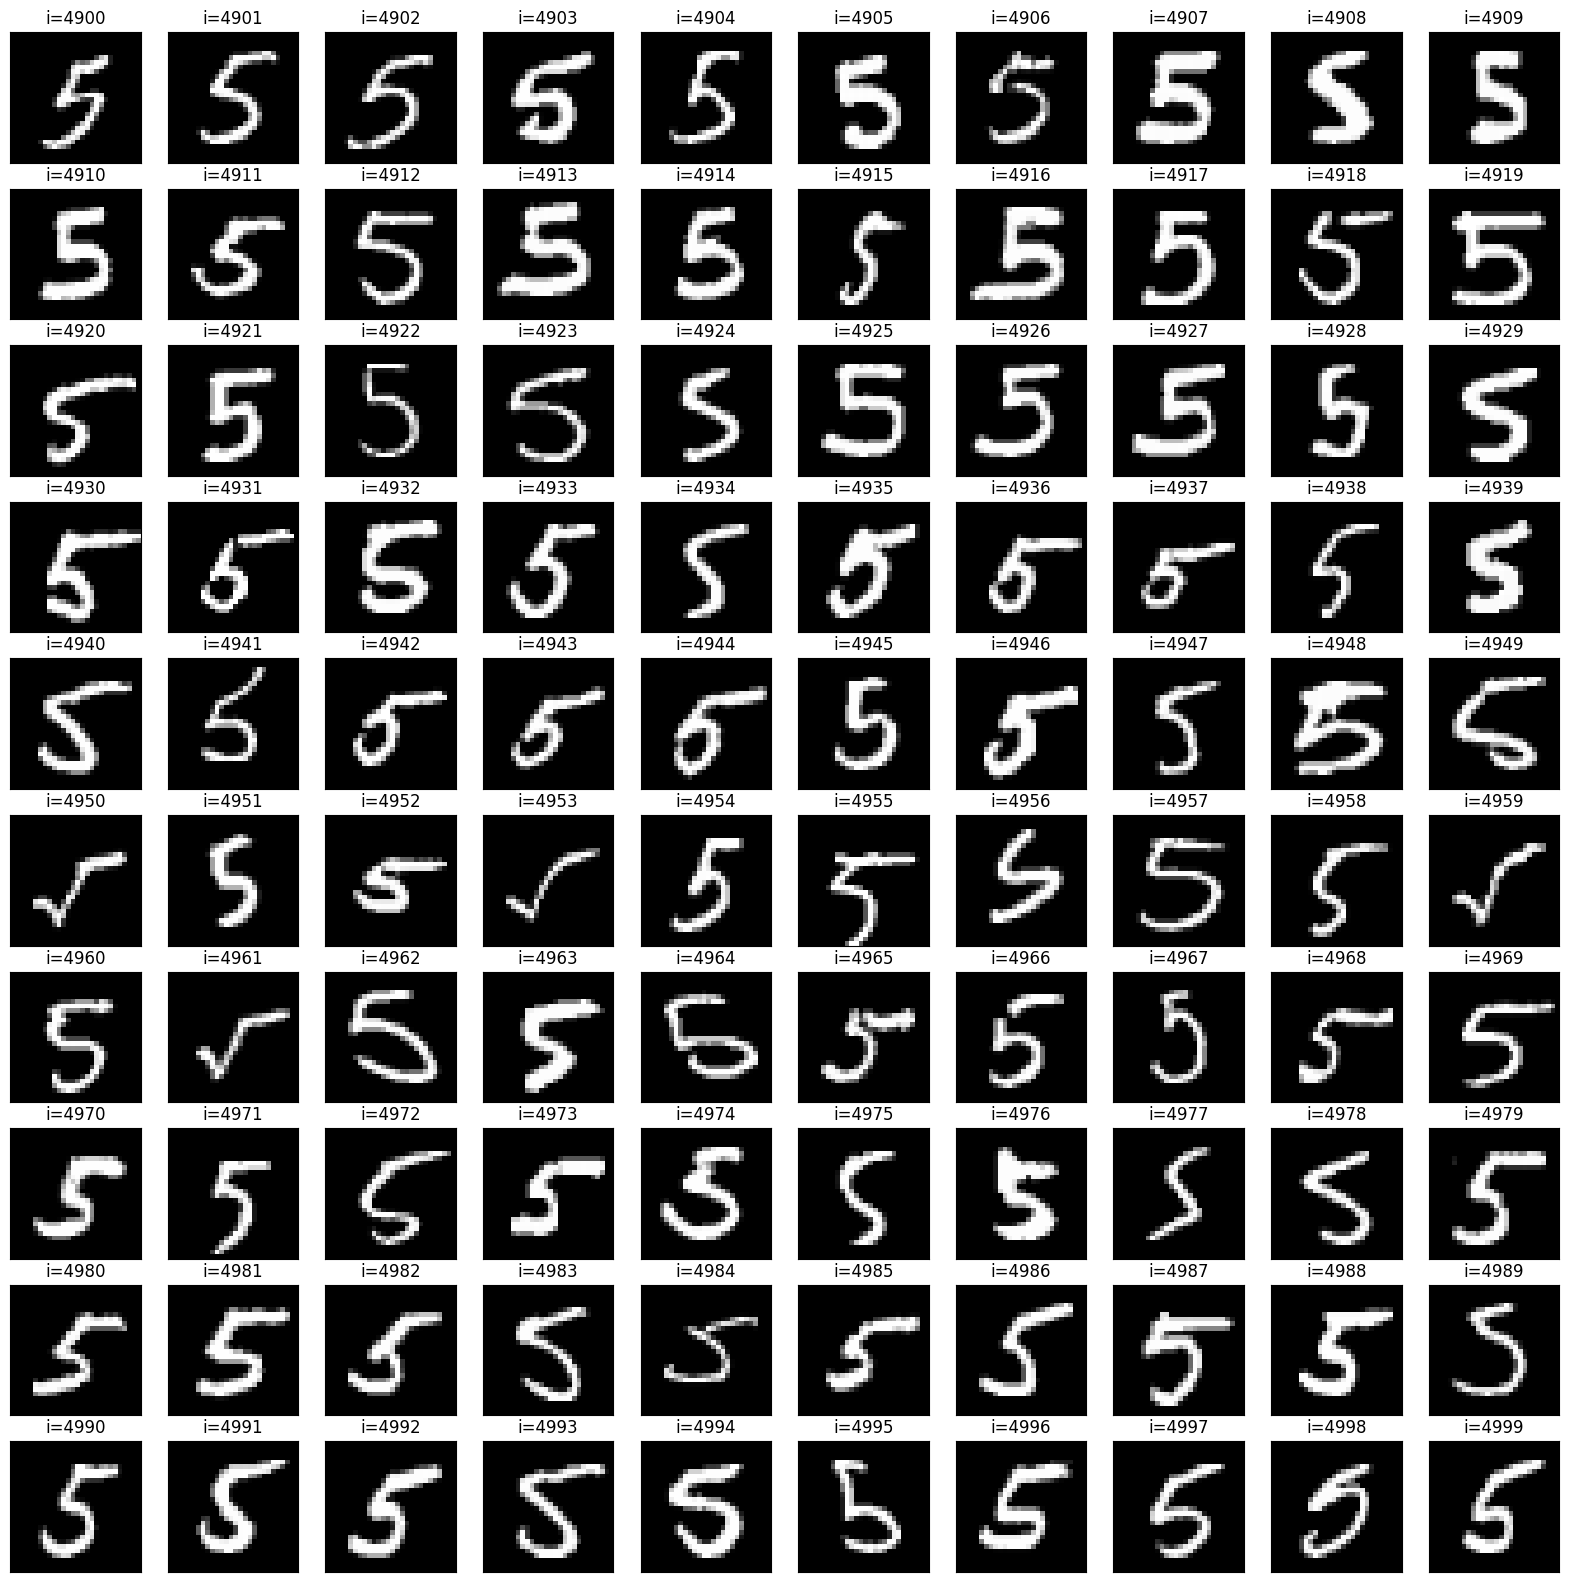

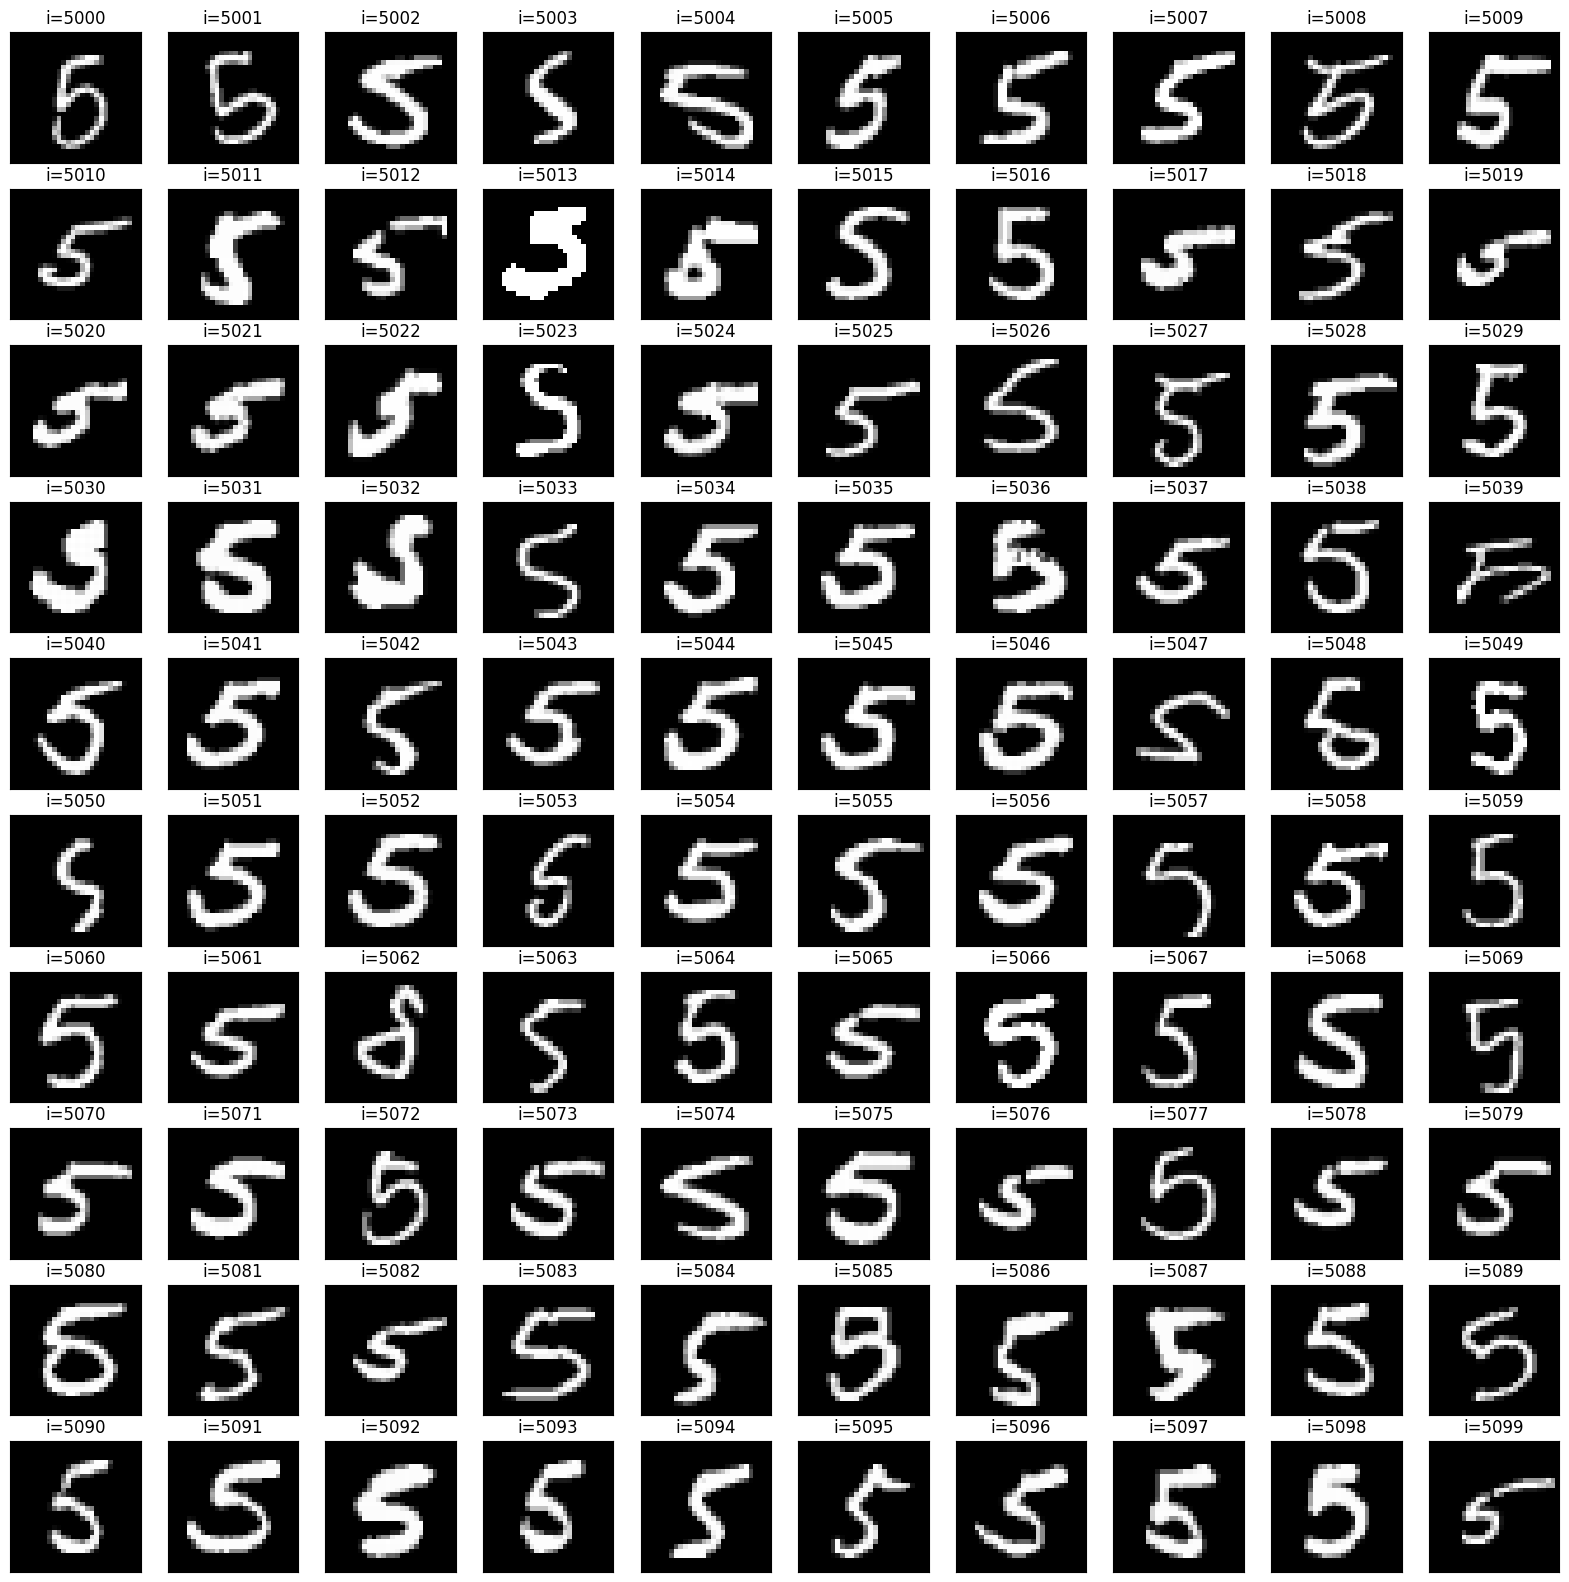

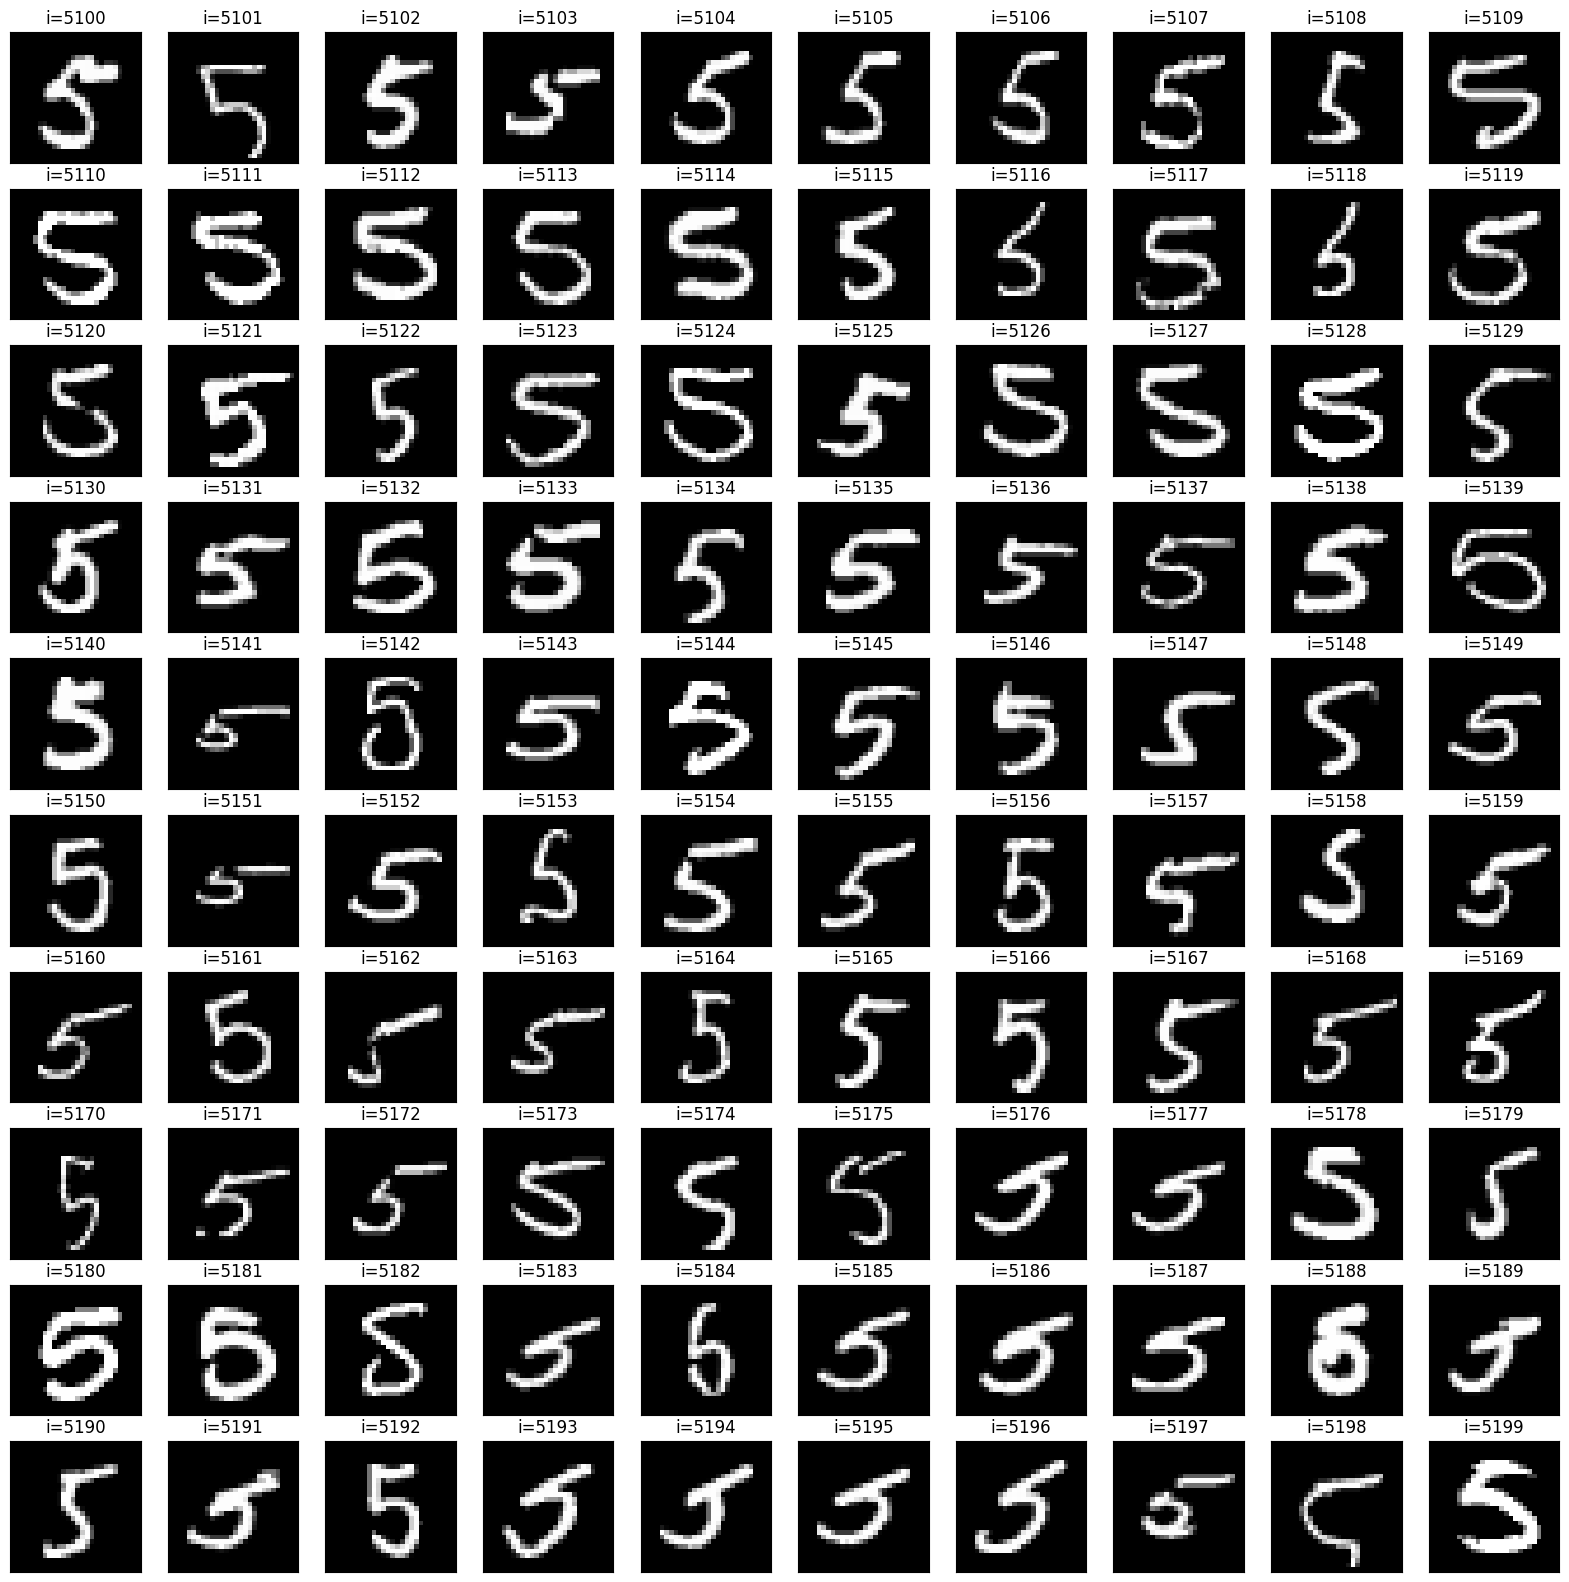

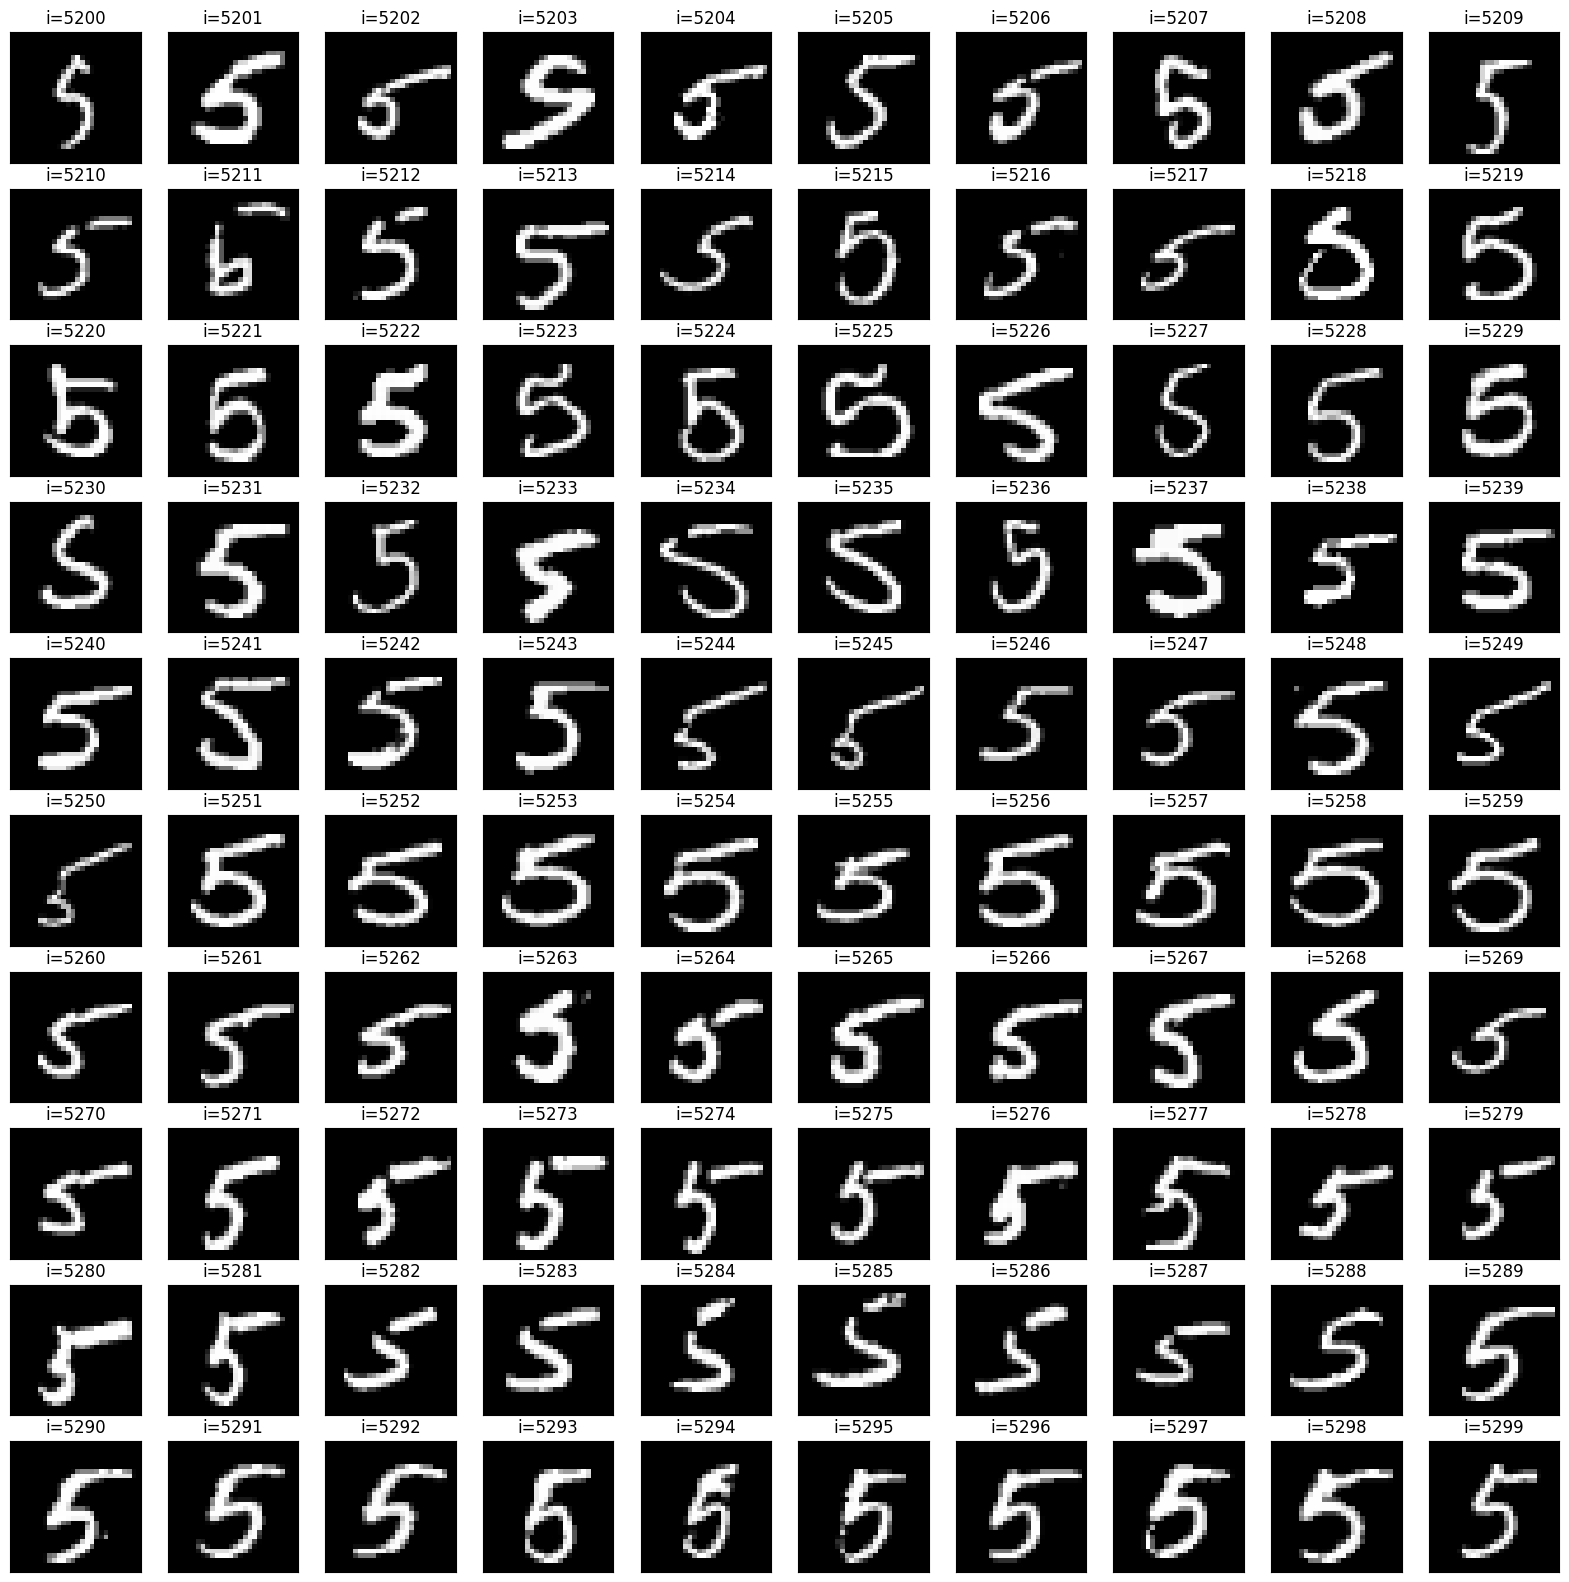

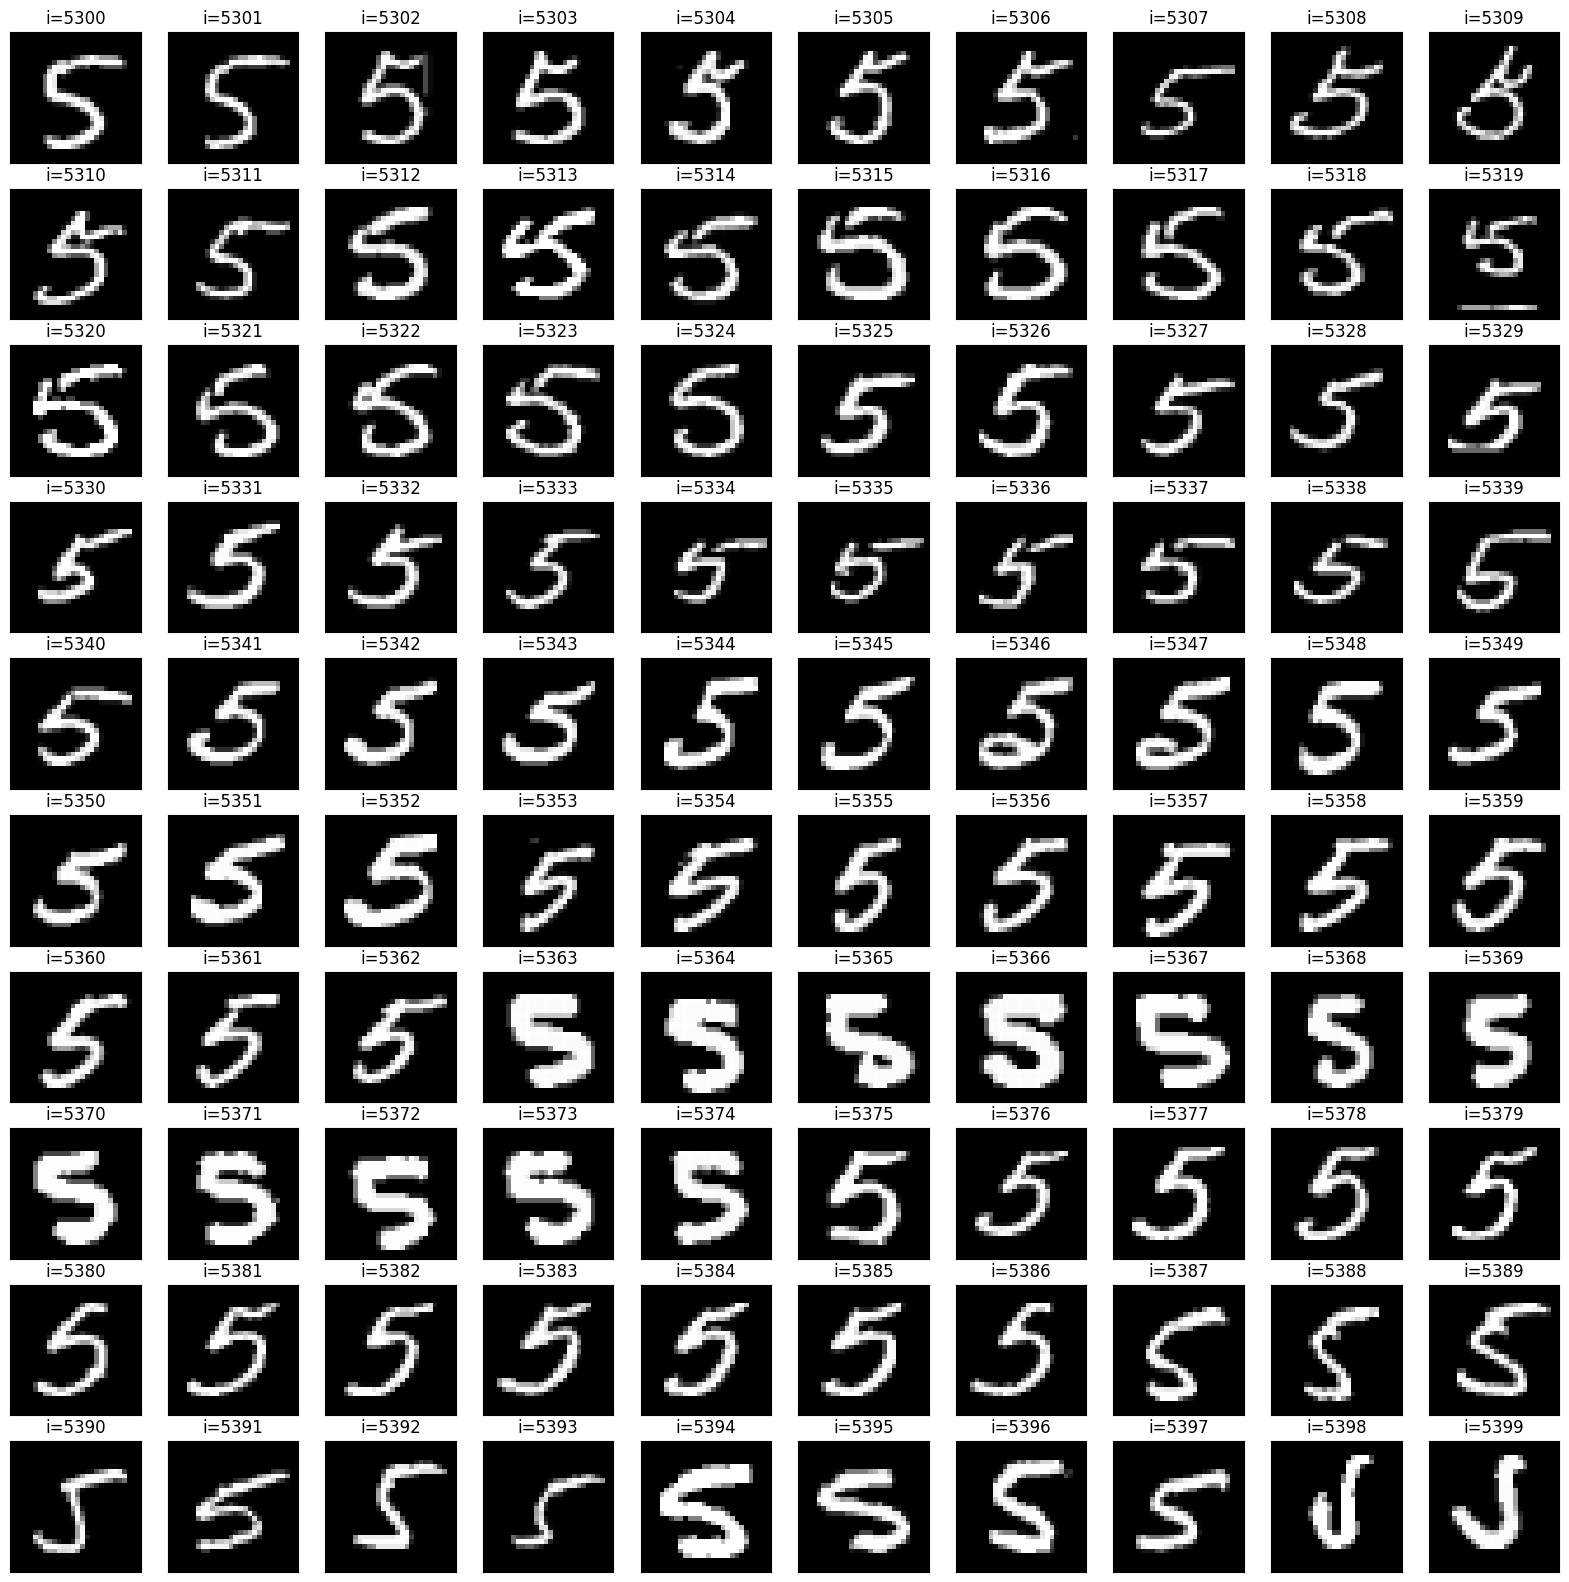

IndexError: index 5421 is out of bounds for axis 0 with size 5421

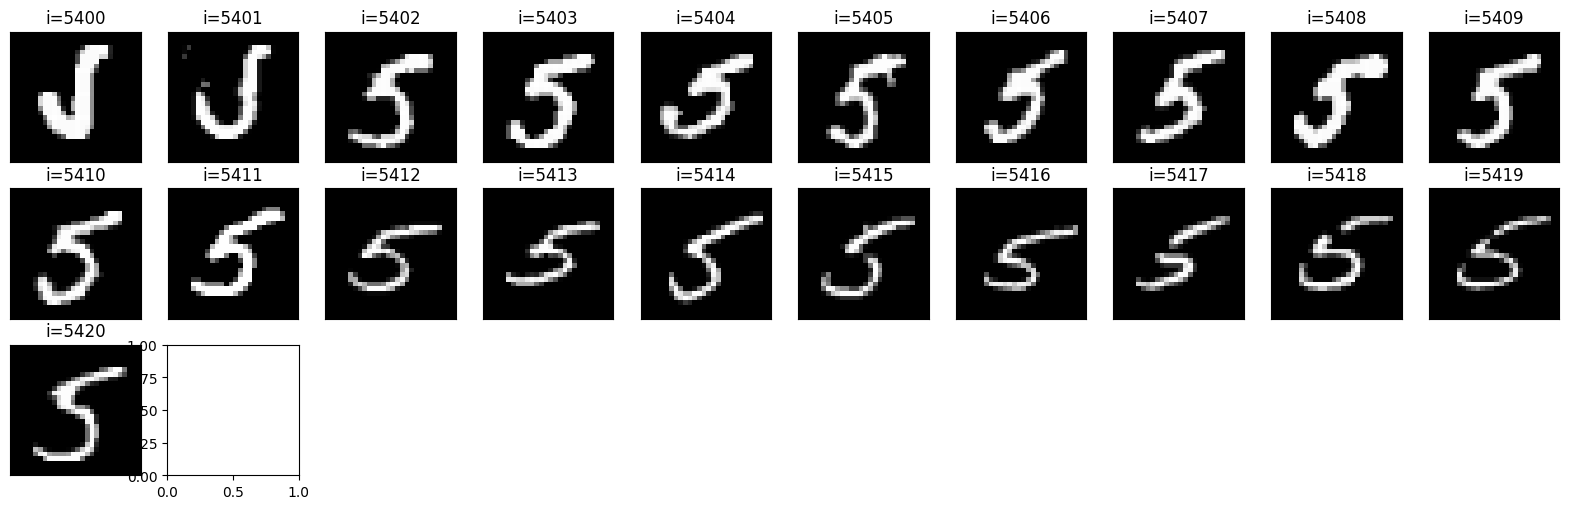

In [7]:
# Ваше решение

display(X_train.shape)
display(y_train.shape)
#display(X_train[:2])
#display(y_train[:2])

#вывод изображений всех картинок для выбора
#for i in range(X_train.shape[0]):
for offset in range (0, X_train.shape[0], 100):
    plt.figure(figsize=(20, 20))
    for i in range(offset, offset+100):
        ax = plt.subplot(10, 10, i-offset+1)
        plt.imshow(X_train[i].squeeze(), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)
        plt.title(f'i={i}')
    plt.show()

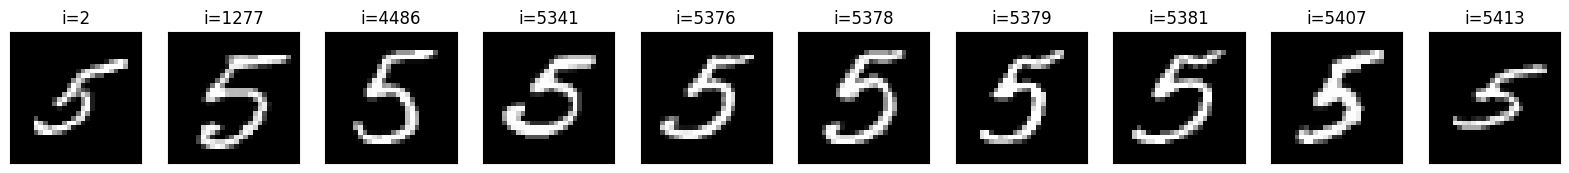

In [8]:
#вывод избранных картинок
ids_of_the_bests = [5413,5407,5376,5378,5341,5379,5381,4486,2,1277]
ids_of_the_bests.sort()
plt.figure(figsize=(20, 7))
for i in range(len(ids_of_the_bests)):
    ax = plt.subplot(1, 10, i+1)
    plt.imshow(X_train[ids_of_the_bests[i]].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.title(f'i={ids_of_the_bests[i]}')

plt.show()


(10, 28, 28, 1)


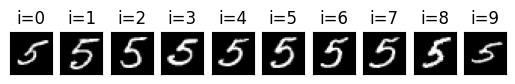

In [9]:
best_mask = [i in ids_of_the_bests for i in range(X_train.shape[0])]
X_train_best = X_train[best_mask]
print(X_train_best.shape)
for i in range(X_train_best.shape[0]):
    ax = plt.subplot(1, 10, i+1)
    plt.imshow(X_train_best[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.title(f'i={i}')

plt.show()


(10, 28, 28, 1)


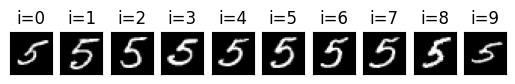

In [10]:
#сохранение данных в файл и последующая их загрузка
import pickle as pkl

with open('X_train_best.pkl', 'wb') as f:
    pkl.dump(X_train_best, f)

with open('X_train_best.pkl', 'rb') as f:
    X_train_best_loaded = pkl.load(f)

print(X_train_best_loaded.shape)
for i in range(X_train_best_loaded.shape[0]):
    ax = plt.subplot(1, 10, i+1)
    plt.imshow(X_train_best_loaded[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.title(f'i={i}')

plt.show()

In [11]:
#создание датасета из избранных изображений
import numpy
X_train_best_expanded = numpy.resize(X_train_best, (5421, 28, 28, 1))
print(X_train_best_expanded.shape)

(5421, 28, 28, 1)


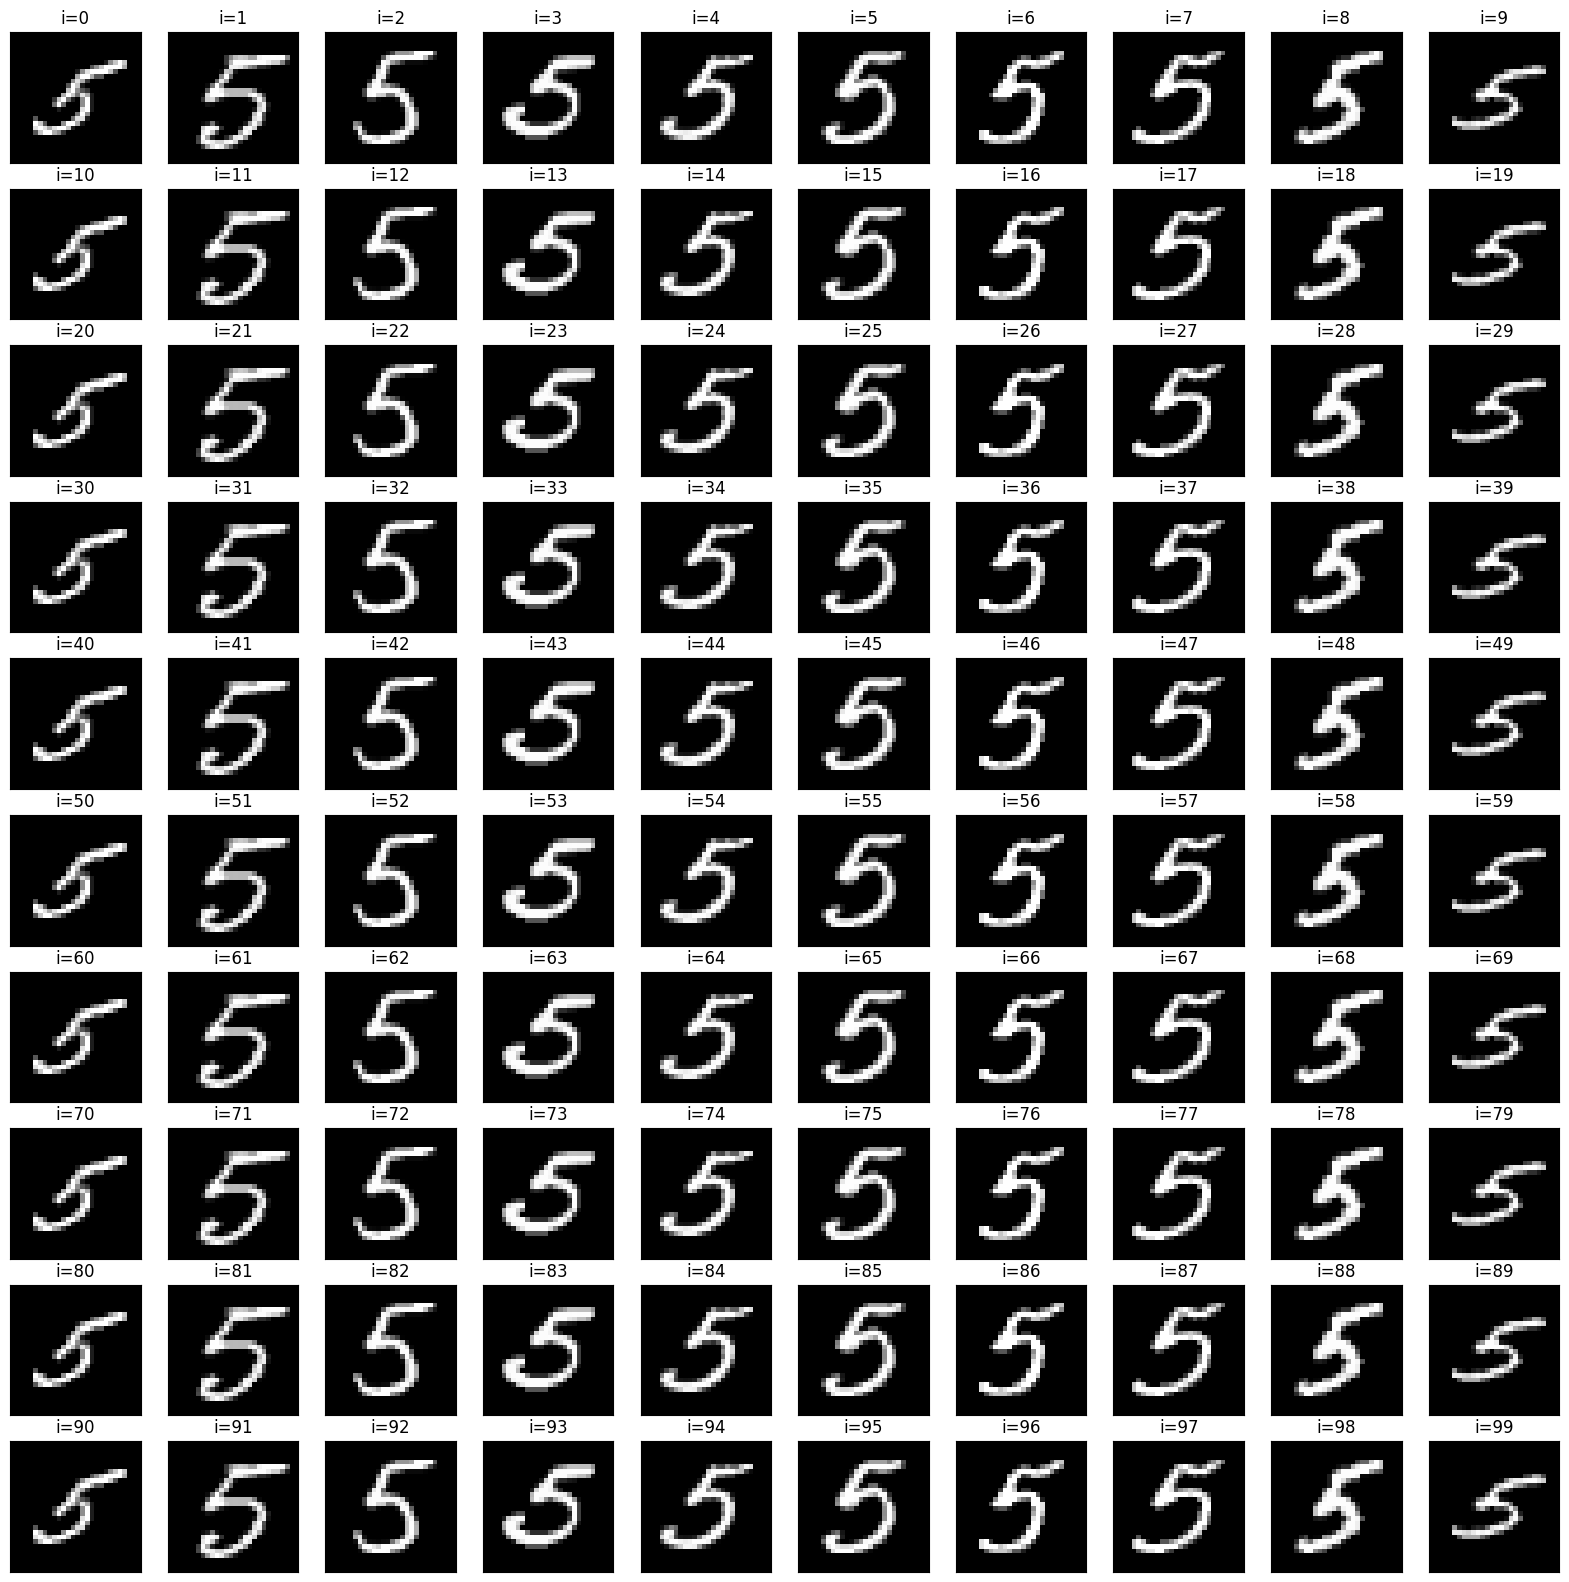

In [12]:
# и вывод части (100) картинок из него
plt.figure(figsize=(20, 20))
for i in range(0, 100):
    ax = plt.subplot(10, 10, i+1)
    plt.imshow(X_train_best_expanded[i].squeeze(), cmap='gray')
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.title(f'i={i}')
plt.show()

In [13]:
#запись и чтение из дампа
with open('X_train_best_expanded.pkl', 'wb') as f:
    pkl.dump(X_train_best_expanded, f)

with open('X_train_best_expanded.pkl', 'rb') as f:
    X_train_best_expanded = pkl.load(f)

In [14]:
# Функция сборки сверточного автокодировщика
def create_base_ae(in_shape):
    # Энкодер, вход нейросети
    img_input = Input(in_shape)

    # Энкодер, первый блок
    # 1.1. Двумерная свертка
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(img_input)
    # 1.2. Нормализация
    x = BatchNormalization()(x)
    # 1.3. Двумерная свертка
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    # 1.4. Нормализация
    x = BatchNormalization()(x)
    # 1.5. Снижение размерности и обобщение данных
    x = MaxPooling2D()(x)

    # Энкодер, второй блок
    # 2.1. Двумерная свертка
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    # 2.2. Нормализация
    x = BatchNormalization()(x)
    # 2.3. Двумерная свертка
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    # 2.4. Нормализация
    x = BatchNormalization()(x)


    # На выходе кодировщика и на входе декодировщика z - вектор латентного пространства
    # 2.5. Снижение размерности и обобщение данных
    z = MaxPooling2D()(x)


    # Декодер, первый блок
    # 1.1. Транспонированная свертка - повышение размерности данных
    x = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same', activation='relu')(z)
    # 1.2. Нормализация
    x = BatchNormalization()(x)
    # 1.3. Двумерная свертка
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    # 1.4. Нормализация
    x = BatchNormalization()(x)
    # 1.5. Двумерная свертка
    x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    # 1.6. Нормализация
    x = BatchNormalization()(x)

    # Декодер, второй блок
    # 2.1. Транспонированная свертка - повышение размерности данных
    x = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same', activation='relu')(x)
    # 2.2. Нормализация
    x = BatchNormalization()(x) # слой нормализации данных
    # 2.3. Двумерная свертка
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    # 2.4. Нормализация
    x = BatchNormalization()(x) # слой нормализации данных
    # 2.5. Двумерная свертка
    x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
    # 2.6. Нормализация
    x = BatchNormalization()(x)

    # Декодер, финальный слой двумерной свертки, выдающий итоговое изображение
    outputs = Conv2D(in_shape[-1], (3, 3), activation='sigmoid', padding='same')(x)

    # Сборка модели, на входе оригинальное изображение, на выходе - сжатое-восстановленное
    model = Model(inputs=img_input, outputs=outputs)

    # Компиляция сети, назначение оптимизатора Adam + среднеквадратическая ошибка
    model.compile(optimizer=Adam(learning_rate=0.0001), loss='mse')

    # Возврат готовой модели
    return model

In [15]:
# Функция последовательного вывода нескольких изображений для сравнения
def plot_images(x_data, pred, n=5):

    plt.figure(figsize=(14, 7))                     # Размер полотна

    for i in range(1, n + 1):                              # Повтор n раз:
        index = np.random.randint(0, pred.shape[0]) # Выбор случайного индекса

        # Показ картинки с индексом index из набора x_data
        ax = plt.subplot(2, n, i)               # Картинка располагается в верхнем ряду
        plt.imshow(x_data[index].squeeze(), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

        # Показ картинки с тем же индексом из предсказания автокодировщика
        ax = plt.subplot(2, n, i + n)           # Картинка располагается в нижнем ряду
        plt.imshow(pred[index].squeeze(), cmap='gray')
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    plt.show()

In [16]:
# Сборка автокодировщика для формы картинок датасета
ae_mnist = create_base_ae(X_train.shape[1:])

In [17]:
# Сводка архитектуры автокодировщика
ae_mnist.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        16,448 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │         8,224 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │         9,24

 Total params: 184,225 (719.63 KB)

 Trainable params: 183,265 (715.88 KB)

 Non-trainable params: 960 (3.75 KB)

In [18]:
def model_check(model):
  # Входная форма
  input_shape = model.input.shape[1:]

  # Выходная форма
  output_shape = model.output.shape[1:]

  # Сравнение
  assert input_shape == output_shape, f'Вход и выход не совпадают по форме, input: {input_shape}, output'

In [19]:
model_check(ae_mnist)

In [20]:
# Обучение модели автокодировщика, на входе и выходе одни и те же данные
history = ae_mnist.fit(X_train, X_train_best_expanded,
                       epochs=50,
                       batch_size=256,
                       validation_split = 0.2)

Epoch 1/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 21s 537ms/step - loss: 0.2738 - val_loss: 0.2127
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - loss: 0.2198 - val_loss: 0.1880
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1864 - val_loss: 0.1581
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1583 - val_loss: 0.1330
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1397 - val_loss: 0.1144
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1271 - val_loss: 0.1022
Epoch 7/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.1169 - val_loss: 0.0945
Epoch 8/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.1090 - val_loss: 0.0899
Epoch 9/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - loss: 0.1023 - val_loss: 0.0871
Epoch 10/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0952 - val_loss: 0.0856
Epoch 11/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0.0898 - val_loss: 0.0847
Epoch 12/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - loss: 0

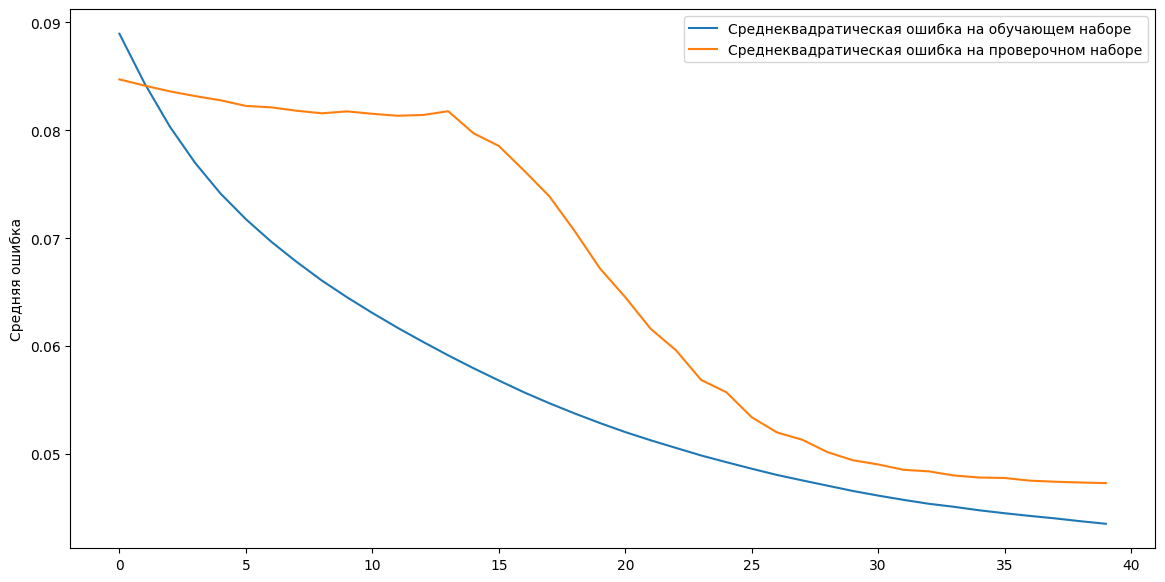

In [21]:
# Вывод графиков процесса обучения
plt.figure(figsize=(14,7))
plt.plot(history.history['loss'][10:],
         label='Среднеквадратическая ошибка на обучающем наборе')
plt.plot(history.history['val_loss'][10:],
         label='Среднеквадратическая ошибка на проверочном наборе')
plt.ylabel('Средняя ошибка')
plt.legend()
plt.show()

In [22]:
# Получение предсказания автокодировщика на тренировочной и тестовой выборках
X_pred_train = ae_mnist.predict(X_train)
X_pred_test = ae_mnist.predict(X_test)

170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step


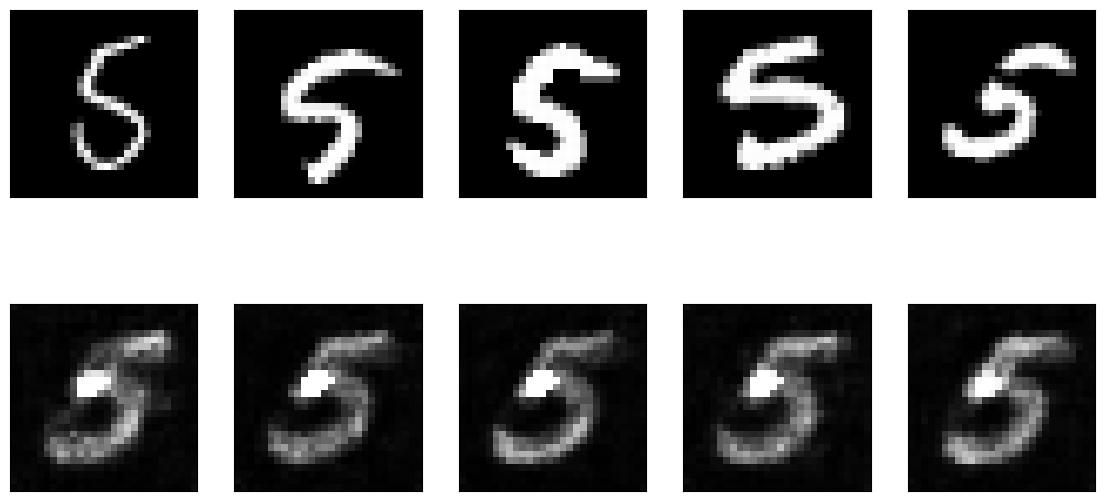

In [23]:
# Сравнение исходных и восстановленных картинок из тренировочной выборки
plot_images(X_train, X_pred_train)

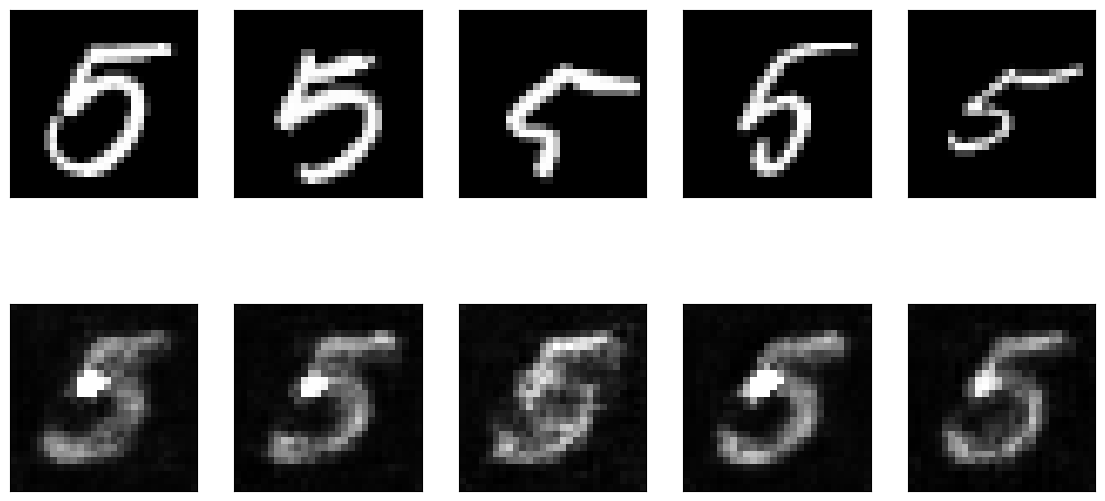

In [24]:
# Сравнение исходных и восстановленных картинок из тестовой выборки
plot_images(X_test, X_pred_test)